In [ ]:
# ============================================================
# PART 1 — Mount Google Drive and define project paths
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/UNSW_NB15_Project")
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

OUTPUT_DIRS = {
    "audit": RESULTS_DIR / "01_dataset_audit",
    "preprocessing": RESULTS_DIR / "02_preprocessing",
    "models": RESULTS_DIR / "03_models",
    "classification": RESULTS_DIR / "04_classification",
    "calibration": RESULTS_DIR / "05_calibration",
    "shap": RESULTS_DIR / "06_shap",
    "evidence": RESULTS_DIR / "07_evidence_bundles",
    "reports": RESULTS_DIR / "08_generated_reports",
    "verifier": RESULTS_DIR / "09_verifier",
    "figures": RESULTS_DIR / "10_figures",
    "configs": PROJECT_ROOT / "configs",
}

for folder in OUTPUT_DIRS.values():
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_PATH = DATA_DIR / "UNSW_NB15_testing-set.csv"
FEATURES_PATH = DATA_DIR / "NUSW-NB15_features.csv"

print("Project root:", PROJECT_ROOT)
print("Folders created successfully.")

Mounted at /content/drive
Project root: /content/drive/MyDrive/UNSW_NB15_Project
Folders created successfully.


In [ ]:
# ============================================================
# PART 2 — Reproducibility settings and environment information
# ============================================================

import os
import sys
import random
import platform

import numpy as np
import pandas as pd
import sklearn

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("Python version       :", platform.python_version())
print("Pandas version       :", pd.__version__)
print("NumPy version        :", np.__version__)
print("Scikit-learn version :", sklearn.__version__)
print("Operating system     :", platform.platform())
print("Random seed          :", SEED)

Python version       : 3.12.13
Pandas version       : 2.2.2
NumPy version        : 2.0.2
Scikit-learn version : 1.6.1
Operating system     : Linux-6.6.122+-x86_64-with-glibc2.35
Random seed          : 42


In [ ]:
# ============================================================
# PART 3 — Verify dataset files
# ============================================================

required_files = {
    "Training dataset": TRAIN_PATH,
    "Testing dataset": TEST_PATH,
    "Feature description": FEATURES_PATH,
}

all_files_found = True

for name, path in required_files.items():
    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"✅ {name}: {path.name} ({size_mb:.2f} MB)")
    else:
        all_files_found = False
        print(f"❌ Missing: {path}")

if not all_files_found:
    raise FileNotFoundError(
        "One or more required dataset files were not found. "
        "Check the Google Drive folder and filenames."
    )

print("\nAll required files were found successfully.")

✅ Training dataset: UNSW_NB15_training-set.csv (30.80 MB)
✅ Testing dataset: UNSW_NB15_testing-set.csv (14.67 MB)
✅ Feature description: NUSW-NB15_features.csv (0.00 MB)

All required files were found successfully.


In [ ]:
# ============================================================
# PART 4 — Load official UNSW-NB15 train/test partitions
# ============================================================

import pandas as pd

# Main datasets use normal CSV/UTF-8-compatible encoding
train_df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_PATH,
    low_memory=False
)

# The feature-description file contains Windows-encoded characters
feature_description_df = pd.read_csv(
    FEATURES_PATH,
    encoding="cp1252",
    low_memory=False
)

# Clean column names
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()
feature_description_df.columns = (
    feature_description_df.columns
    .astype(str)
    .str.strip()
)

# Clean surrounding spaces without converting missing values to "nan"
for dataframe in [train_df, test_df]:
    object_columns = dataframe.select_dtypes(
        include=["object", "string"]
    ).columns

    for column in object_columns:
        dataframe[column] = dataframe[column].apply(
            lambda value: value.strip()
            if isinstance(value, str)
            else value
        )

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)
print("Feature-description shape:", feature_description_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nFeature-description columns:")
print(feature_description_df.columns.tolist())

print("\n✅ All three UNSW-NB15 files loaded successfully.")

Training shape: (175341, 45)
Testing shape : (82332, 45)
Feature-description shape: (49, 4)

Training columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Feature-description columns:
['No.', 'Name', 'Type', 'Description']

✅ All three UNSW-NB15 files loaded successfully.


In [ ]:
# ============================================================
# PART 5 — Schema, datatype, missing-value and target audit
# ============================================================

required_target_columns = {"attack_cat", "label"}

missing_train_targets = required_target_columns - set(train_df.columns)
missing_test_targets = required_target_columns - set(test_df.columns)

if missing_train_targets:
    raise ValueError(
        f"Training dataset is missing target columns: {missing_train_targets}"
    )

if missing_test_targets:
    raise ValueError(
        f"Testing dataset is missing target columns: {missing_test_targets}"
    )

print("Training datatypes:")
print(train_df.dtypes.value_counts())

print("\nTesting datatypes:")
print(test_df.dtypes.value_counts())

print("\nCategorical columns:")
print(train_df.select_dtypes(include=["object"]).columns.tolist())

print("\nTotal missing values:")
print("Training:", int(train_df.isna().sum().sum()))
print("Testing :", int(test_df.isna().sum().sum()))

numeric_train = train_df.select_dtypes(include=[np.number])
numeric_test = test_df.select_dtypes(include=[np.number])

print("\nInfinite values:")
print("Training:", int(np.isinf(numeric_train.to_numpy()).sum()))
print("Testing :", int(np.isinf(numeric_test.to_numpy()).sum()))

print("\nBinary labels in training:")
print(train_df["label"].value_counts(dropna=False).sort_index())

print("\nBinary labels in testing:")
print(test_df["label"].value_counts(dropna=False).sort_index())

print("\nAttack categories in training:")
print(sorted(train_df["attack_cat"].dropna().unique().tolist()))

print("\nAttack categories in testing:")
print(sorted(test_df["attack_cat"].dropna().unique().tolist()))

Training datatypes:
int64      30
float64    11
object      4
Name: count, dtype: int64

Testing datatypes:
int64      30
float64    11
object      4
Name: count, dtype: int64

Categorical columns:
['proto', 'service', 'state', 'attack_cat']

Total missing values:
Training: 0
Testing : 0

Infinite values:
Training: 0
Testing : 0

Binary labels in training:
label
0     56000
1    119341
Name: count, dtype: int64

Binary labels in testing:
label
0    37000
1    45332
Name: count, dtype: int64

Attack categories in training:
['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']

Attack categories in testing:
['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [ ]:
# ============================================================
# PART 6 — Multiclass attack distribution
# ============================================================

def build_class_distribution(dataframe, split_name):
    counts = dataframe["attack_cat"].value_counts(dropna=False)
    percentages = dataframe["attack_cat"].value_counts(
        dropna=False,
        normalize=True
    ) * 100

    result = pd.DataFrame({
        "split": split_name,
        "attack_category": counts.index.astype(str),
        "events": counts.values,
        "percentage": percentages.values,
    })

    return result


train_distribution = build_class_distribution(train_df, "Training")
test_distribution = build_class_distribution(test_df, "Testing")

class_distribution = pd.concat(
    [train_distribution, test_distribution],
    ignore_index=True
)

print(class_distribution.to_string(index=False))

distribution_path = (
    OUTPUT_DIRS["audit"] /
    "unsw_nb15_train_test_class_distribution.csv"
)

class_distribution.to_csv(distribution_path, index=False)

print("\nSaved class distribution to:")
print(distribution_path)

   split attack_category  events  percentage
Training          Normal   56000   31.937767
Training         Generic   40000   22.812691
Training        Exploits   33393   19.044605
Training         Fuzzers   18184   10.370649
Training             DoS   12264    6.994371
Training  Reconnaissance   10491    5.983198
Training        Analysis    2000    1.140635
Training        Backdoor    1746    0.995774
Training       Shellcode    1133    0.646169
Training           Worms     130    0.074141
 Testing          Normal   37000   44.939999
 Testing         Generic   18871   22.920614
 Testing        Exploits   11132   13.520867
 Testing         Fuzzers    6062    7.362872
 Testing             DoS    4089    4.966477
 Testing  Reconnaissance    3496    4.246223
 Testing        Analysis     677    0.822281
 Testing        Backdoor     583    0.708109
 Testing       Shellcode     378    0.459117
 Testing           Worms      44    0.053442

Saved class distribution to:
/content/drive/MyDrive/UN

In [ ]:
# ============================================================
# PART 7 — Duplicate and cross-split overlap audit
# ============================================================

# Exclude identifiers and target columns before checking
excluded_columns = {"id", "attack_cat", "label"}

feature_columns_for_audit = [
    column
    for column in train_df.columns
    if column not in excluded_columns
]

missing_in_test = set(feature_columns_for_audit) - set(test_df.columns)

if missing_in_test:
    raise ValueError(
        f"Testing data is missing feature columns: {sorted(missing_in_test)}"
    )

train_feature_view = train_df[feature_columns_for_audit]
test_feature_view = test_df[feature_columns_for_audit]

train_duplicate_count = int(train_feature_view.duplicated().sum())
test_duplicate_count = int(test_feature_view.duplicated().sum())

# Hash each feature row for an efficient cross-split overlap check
train_hashes = pd.util.hash_pandas_object(
    train_feature_view,
    index=False
)

test_hashes = pd.util.hash_pandas_object(
    test_feature_view,
    index=False
)

train_hash_set = set(train_hashes.tolist())
test_hash_set = set(test_hashes.tolist())

overlapping_hashes = train_hash_set.intersection(test_hash_set)

print("Duplicate feature rows inside training set:", train_duplicate_count)
print("Duplicate feature rows inside testing set :", test_duplicate_count)
print("Unique feature rows appearing in both splits:", len(overlapping_hashes))

audit_summary = pd.DataFrame({
    "metric": [
        "training_rows",
        "testing_rows",
        "training_duplicate_feature_rows",
        "testing_duplicate_feature_rows",
        "unique_feature_rows_in_both_splits",
    ],
    "value": [
        len(train_df),
        len(test_df),
        train_duplicate_count,
        test_duplicate_count,
        len(overlapping_hashes),
    ],
})

audit_path = OUTPUT_DIRS["audit"] / "unsw_nb15_duplicate_overlap_audit.csv"
audit_summary.to_csv(audit_path, index=False)

print("\nSaved audit summary to:")
print(audit_path)

Duplicate feature rows inside training set: 74301
Duplicate feature rows inside testing set : 28386
Unique feature rows appearing in both splits: 1302

Saved audit summary to:
/content/drive/MyDrive/UNSW_NB15_Project/results/01_dataset_audit/unsw_nb15_duplicate_overlap_audit.csv


In [ ]:
# ============================================================
# PART 8 — Detailed duplicate and cross-split leakage audit
# ============================================================

import numpy as np
import pandas as pd

TARGET_COLUMNS = ["attack_cat", "label"]
EXCLUDED_COLUMNS = {"id", "attack_cat", "label"}

feature_columns = [
    column
    for column in train_df.columns
    if column not in EXCLUDED_COLUMNS
]

print("Number of predictor columns before encoding:", len(feature_columns))

# ------------------------------------------------------------
# 1. Create deterministic feature hashes
# ------------------------------------------------------------

train_feature_hash = pd.util.hash_pandas_object(
    train_df[feature_columns],
    index=False
).astype("uint64")

test_feature_hash = pd.util.hash_pandas_object(
    test_df[feature_columns],
    index=False
).astype("uint64")

# Hash features together with their targets.
# These identify fully identical supervised-learning records.
full_columns = feature_columns + TARGET_COLUMNS

train_full_hash = pd.util.hash_pandas_object(
    train_df[full_columns],
    index=False
).astype("uint64")

test_full_hash = pd.util.hash_pandas_object(
    test_df[full_columns],
    index=False
).astype("uint64")

# ------------------------------------------------------------
# 2. Within-split duplicate analysis
# ------------------------------------------------------------

def duplicate_summary(
    dataframe,
    feature_hash,
    full_hash,
    split_name
):
    audit_frame = pd.DataFrame({
        "feature_hash": feature_hash,
        "attack_cat": dataframe["attack_cat"].astype(str),
        "label": dataframe["label"].astype(int),
    })

    grouped = (
        audit_frame
        .groupby("feature_hash", as_index=False)
        .agg(
            rows=("feature_hash", "size"),
            attack_category_count=("attack_cat", "nunique"),
            binary_label_count=("label", "nunique"),
        )
    )

    duplicate_groups = grouped[grouped["rows"] > 1]

    conflicting_groups = grouped[
        (grouped["attack_category_count"] > 1) |
        (grouped["binary_label_count"] > 1)
    ]

    return {
        "split": split_name,
        "total_rows": len(dataframe),

        # Additional occurrences after the first feature record
        "duplicate_feature_extra_rows": int(
            feature_hash.duplicated(keep="first").sum()
        ),

        # All records belonging to duplicated feature groups
        "rows_in_duplicate_feature_groups": int(
            feature_hash.duplicated(keep=False).sum()
        ),

        # Fully identical features + attack_cat + binary label
        "exact_supervised_duplicate_extra_rows": int(
            full_hash.duplicated(keep="first").sum()
        ),

        "duplicate_feature_groups": int(len(duplicate_groups)),
        "conflicting_feature_groups": int(len(conflicting_groups)),
        "rows_in_conflicting_feature_groups": int(
            conflicting_groups["rows"].sum()
        ),
    }


train_duplicate_summary = duplicate_summary(
    train_df,
    train_feature_hash,
    train_full_hash,
    "Training"
)

test_duplicate_summary = duplicate_summary(
    test_df,
    test_feature_hash,
    test_full_hash,
    "Testing"
)

within_split_summary = pd.DataFrame([
    train_duplicate_summary,
    test_duplicate_summary
])

print("\nWITHIN-SPLIT DUPLICATE SUMMARY")
print(within_split_summary.to_string(index=False))

# ------------------------------------------------------------
# 3. Cross-split feature-overlap analysis
# ------------------------------------------------------------

train_feature_hash_set = set(
    train_feature_hash.astype("uint64").tolist()
)

test_overlap_mask = test_feature_hash.isin(
    train_feature_hash_set
)

test_rows_with_training_feature = int(test_overlap_mask.sum())

# Check whether both the feature vector and attack category exist
# in the training split.
train_feature_attack_pairs = set(
    zip(
        train_feature_hash.astype("uint64").tolist(),
        train_df["attack_cat"].astype(str).tolist()
    )
)

same_attack_category_mask = pd.Series(
    [
        (int(feature_hash), str(attack_category))
        in train_feature_attack_pairs
        for feature_hash, attack_category in zip(
            test_feature_hash,
            test_df["attack_cat"]
        )
    ],
    index=test_df.index
)

same_feature_same_attack_test_rows = int(
    same_attack_category_mask.sum()
)

same_feature_conflicting_attack_test_rows = int(
    (
        test_overlap_mask &
        ~same_attack_category_mask
    ).sum()
)

# ------------------------------------------------------------
# 4. Summarize labels associated with each overlapping pattern
# ------------------------------------------------------------

train_hash_labels = pd.DataFrame({
    "feature_hash": train_feature_hash,
    "attack_cat": train_df["attack_cat"].astype(str),
    "label": train_df["label"].astype(int),
})

test_hash_labels = pd.DataFrame({
    "feature_hash": test_feature_hash,
    "attack_cat": test_df["attack_cat"].astype(str),
    "label": test_df["label"].astype(int),
})

train_grouped = (
    train_hash_labels
    .groupby("feature_hash", as_index=False)
    .agg(
        training_rows=("feature_hash", "size"),
        training_attack_categories=(
            "attack_cat",
            lambda values: "|".join(
                sorted(set(values))
            )
        ),
        training_binary_labels=(
            "label",
            lambda values: "|".join(
                map(str, sorted(set(values)))
            )
        ),
    )
)

test_grouped = (
    test_hash_labels
    .groupby("feature_hash", as_index=False)
    .agg(
        testing_rows=("feature_hash", "size"),
        testing_attack_categories=(
            "attack_cat",
            lambda values: "|".join(
                sorted(set(values))
            )
        ),
        testing_binary_labels=(
            "label",
            lambda values: "|".join(
                map(str, sorted(set(values)))
            )
        ),
    )
)

cross_split_groups = train_grouped.merge(
    test_grouped,
    on="feature_hash",
    how="inner"
)

def compare_label_sets(row):
    training_labels = set(
        row["training_attack_categories"].split("|")
    )

    testing_labels = set(
        row["testing_attack_categories"].split("|")
    )

    if training_labels == testing_labels:
        return "identical_attack_label_set"

    if training_labels.intersection(testing_labels):
        return "partially_overlapping_attack_labels"

    return "conflicting_attack_labels"


cross_split_groups["label_relationship"] = (
    cross_split_groups.apply(
        compare_label_sets,
        axis=1
    )
)

cross_relation_counts = (
    cross_split_groups["label_relationship"]
    .value_counts()
    .rename_axis("label_relationship")
    .reset_index(name="feature_patterns")
)

print("\nCROSS-SPLIT OVERLAP SUMMARY")
print(
    "Unique feature patterns found in both splits:",
    len(cross_split_groups)
)

print(
    "Testing rows whose feature vector exists in training:",
    test_rows_with_training_feature
)

print(
    "Testing rows with same feature and same attack category:",
    same_feature_same_attack_test_rows
)

print(
    "Testing rows with overlapping features but conflicting "
    "attack category:",
    same_feature_conflicting_attack_test_rows
)

print("\nCross-split label relationships:")
print(cross_relation_counts.to_string(index=False))

# ------------------------------------------------------------
# 5. Save audit artifacts
# ------------------------------------------------------------

within_split_path = (
    OUTPUT_DIRS["audit"] /
    "unsw_nb15_detailed_within_split_duplicate_audit.csv"
)

cross_split_path = (
    OUTPUT_DIRS["audit"] /
    "unsw_nb15_cross_split_overlap_groups.csv"
)

cross_relation_path = (
    OUTPUT_DIRS["audit"] /
    "unsw_nb15_cross_split_label_relationships.csv"
)

within_split_summary.to_csv(
    within_split_path,
    index=False
)

cross_split_groups.to_csv(
    cross_split_path,
    index=False
)

cross_relation_counts.to_csv(
    cross_relation_path,
    index=False
)

print("\nSaved:")
print(within_split_path)
print(cross_split_path)
print(cross_relation_path)

Number of predictor columns before encoding: 42

WITHIN-SPLIT DUPLICATE SUMMARY
   split  total_rows  duplicate_feature_extra_rows  rows_in_duplicate_feature_groups  exact_supervised_duplicate_extra_rows  duplicate_feature_groups  conflicting_feature_groups  rows_in_conflicting_feature_groups
Training      175341                         74301                             84049                                  67601                      9748                        1772                               30528
 Testing       82332                         28386                             34704                                  26387                      6318                         575                                8809

CROSS-SPLIT OVERLAP SUMMARY
Unique feature patterns found in both splits: 1302
Testing rows whose feature vector exists in training: 8541
Testing rows with same feature and same attack category: 4247
Testing rows with overlapping features but conflicting attack category: 4294


In [ ]:
# ============================================================
# PART 9 — Preview leakage-controlled cleaning impact
# ============================================================

import pandas as pd
import numpy as np

TARGET_COLUMNS = ["attack_cat", "label"]

FEATURE_COLUMNS = [
    column
    for column in train_df.columns
    if column not in {"id", "attack_cat", "label"}
]

SUPERVISED_COLUMNS = FEATURE_COLUMNS + TARGET_COLUMNS


def identify_conflicting_feature_hashes(dataframe):
    """
    Find feature vectors associated with more than one attack category
    or more than one binary label.
    """

    feature_hash = pd.util.hash_pandas_object(
        dataframe[FEATURE_COLUMNS],
        index=False
    ).astype("uint64")

    audit_frame = pd.DataFrame({
        "feature_hash": feature_hash,
        "attack_cat": dataframe["attack_cat"].astype(str),
        "label": dataframe["label"].astype(int),
    })

    grouped = (
        audit_frame
        .groupby("feature_hash", as_index=False)
        .agg(
            attack_category_count=("attack_cat", "nunique"),
            binary_label_count=("label", "nunique"),
            rows=("feature_hash", "size"),
        )
    )

    conflicting_hashes = set(
        grouped.loc[
            (grouped["attack_category_count"] > 1) |
            (grouped["binary_label_count"] > 1),
            "feature_hash"
        ].astype("uint64").tolist()
    )

    return feature_hash, conflicting_hashes


def create_within_split_clean_candidate(dataframe, split_name):
    """
    Preview a split after:
    1. removing all conflicting-label feature groups;
    2. retaining one copy of each exact supervised record.
    """

    feature_hash, conflicting_hashes = (
        identify_conflicting_feature_hashes(dataframe)
    )

    conflict_mask = feature_hash.isin(conflicting_hashes)

    without_conflicts = dataframe.loc[
        ~conflict_mask
    ].copy()

    before_exact_deduplication = len(without_conflicts)

    cleaned = without_conflicts.drop_duplicates(
        subset=SUPERVISED_COLUMNS,
        keep="first"
    ).copy()

    summary = {
        "split": split_name,
        "original_rows": len(dataframe),
        "removed_conflicting_rows": int(conflict_mask.sum()),
        "rows_after_conflict_removal": len(without_conflicts),
        "removed_exact_duplicate_rows": (
            before_exact_deduplication - len(cleaned)
        ),
        "rows_after_within_split_cleaning": len(cleaned),
    }

    return cleaned, summary


# ------------------------------------------------------------
# 1. Preview within-split cleaning
# ------------------------------------------------------------

train_candidate, train_cleaning_summary = (
    create_within_split_clean_candidate(
        train_df,
        "Training"
    )
)

test_candidate_before_overlap, test_cleaning_summary = (
    create_within_split_clean_candidate(
        test_df,
        "Testing"
    )
)

# ------------------------------------------------------------
# 2. Remove remaining cross-split feature overlap from testing
# ------------------------------------------------------------

clean_train_hash = pd.util.hash_pandas_object(
    train_candidate[FEATURE_COLUMNS],
    index=False
).astype("uint64")

clean_test_hash = pd.util.hash_pandas_object(
    test_candidate_before_overlap[FEATURE_COLUMNS],
    index=False
).astype("uint64")

clean_train_hash_set = set(
    clean_train_hash.tolist()
)

cross_split_overlap_mask = clean_test_hash.isin(
    clean_train_hash_set
)

strict_test_candidate = (
    test_candidate_before_overlap
    .loc[~cross_split_overlap_mask]
    .copy()
)

test_cleaning_summary[
    "removed_cross_split_overlap_rows"
] = int(cross_split_overlap_mask.sum())

test_cleaning_summary[
    "final_strict_rows"
] = len(strict_test_candidate)

train_cleaning_summary[
    "removed_cross_split_overlap_rows"
] = 0

train_cleaning_summary[
    "final_strict_rows"
] = len(train_candidate)

cleaning_summary = pd.DataFrame([
    train_cleaning_summary,
    test_cleaning_summary
])

# ------------------------------------------------------------
# 3. Compare class counts before and after cleaning
# ------------------------------------------------------------

def build_retention_table(
    original_dataframe,
    cleaned_dataframe,
    split_name
):
    original_counts = (
        original_dataframe["attack_cat"]
        .value_counts()
        .rename("original_events")
    )

    cleaned_counts = (
        cleaned_dataframe["attack_cat"]
        .value_counts()
        .rename("strict_events")
    )

    result = pd.concat(
        [original_counts, cleaned_counts],
        axis=1
    ).fillna(0)

    result["original_events"] = (
        result["original_events"].astype(int)
    )

    result["strict_events"] = (
        result["strict_events"].astype(int)
    )

    result["removed_events"] = (
        result["original_events"] -
        result["strict_events"]
    )

    result["retained_percentage"] = np.where(
        result["original_events"] > 0,
        (
            result["strict_events"] /
            result["original_events"]
        ) * 100,
        0
    )

    result = (
        result
        .reset_index()
        .rename(columns={"attack_cat": "attack_category"})
    )

    result.insert(0, "split", split_name)

    return result


train_retention = build_retention_table(
    train_df,
    train_candidate,
    "Training"
)

test_retention = build_retention_table(
    test_df,
    strict_test_candidate,
    "Testing"
)

class_retention = pd.concat(
    [train_retention, test_retention],
    ignore_index=True
)

# ------------------------------------------------------------
# 4. Rare-class safety checks
# ------------------------------------------------------------

minimum_recommended_test_events = 20

rare_class_warning = class_retention[
    (class_retention["split"] == "Testing") &
    (
        class_retention["strict_events"] <
        minimum_recommended_test_events
    )
]

print("STRICT CLEANING SUMMARY")
print(cleaning_summary.to_string(index=False))

print("\nCLASS RETENTION AFTER PROPOSED CLEANING")
print(
    class_retention
    .sort_values(
        ["split", "strict_events"],
        ascending=[True, False]
    )
    .to_string(index=False)
)

if rare_class_warning.empty:
    print(
        "\n✅ Every test class retains at least "
        f"{minimum_recommended_test_events} events."
    )
else:
    print(
        "\n⚠️ The following test classes retain fewer than "
        f"{minimum_recommended_test_events} events:"
    )

    print(
        rare_class_warning[
            [
                "attack_category",
                "original_events",
                "strict_events",
                "retained_percentage"
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# 5. Save preview artifacts
# ------------------------------------------------------------

summary_path = (
    OUTPUT_DIRS["audit"] /
    "unsw_nb15_proposed_strict_cleaning_summary.csv"
)

retention_path = (
    OUTPUT_DIRS["audit"] /
    "unsw_nb15_proposed_strict_class_retention.csv"
)

cleaning_summary.to_csv(
    summary_path,
    index=False
)

class_retention.to_csv(
    retention_path,
    index=False
)

print("\nSaved:")
print(summary_path)
print(retention_path)

print(
    "\nNo original dataframe has been modified."
)

STRICT CLEANING SUMMARY
   split  original_rows  removed_conflicting_rows  rows_after_conflict_removal  removed_exact_duplicate_rows  rows_after_within_split_cleaning  removed_cross_split_overlap_rows  final_strict_rows
Training         175341                     30528                       144813                         45545                             99268                                 0              99268
 Testing          82332                      8809                        73523                         20152                             53371                               953              52418

CLASS RETENTION AFTER PROPOSED CLEANING
   split attack_category  original_events  strict_events  removed_events  retained_percentage
 Testing          Normal            37000          33756            3244            91.232432
 Testing        Exploits            11132           7041            4091            63.250090
 Testing         Fuzzers             6062           4321         

In [ ]:
# ============================================================
# PART 10 — Conservative leakage-controlled protocol preview
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

FEATURE_COLUMNS = [
    column
    for column in train_df.columns
    if column not in {"id", "attack_cat", "label"}
]

TARGET_COLUMNS = ["attack_cat", "label"]

SUPERVISED_COLUMNS = FEATURE_COLUMNS + TARGET_COLUMNS

print("Predictor columns:", len(FEATURE_COLUMNS))

# ------------------------------------------------------------
# 1. Remove only exact supervised duplicates
# ------------------------------------------------------------

conservative_train = (
    train_df
    .drop_duplicates(
        subset=SUPERVISED_COLUMNS,
        keep="first"
    )
    .copy()
)

conservative_test_before_overlap = (
    test_df
    .drop_duplicates(
        subset=SUPERVISED_COLUMNS,
        keep="first"
    )
    .copy()
)

training_exact_duplicates_removed = (
    len(train_df) - len(conservative_train)
)

testing_exact_duplicates_removed = (
    len(test_df) - len(conservative_test_before_overlap)
)

# ------------------------------------------------------------
# 2. Remove cross-split feature overlap from the testing set
# ------------------------------------------------------------

train_feature_hash = pd.util.hash_pandas_object(
    conservative_train[FEATURE_COLUMNS],
    index=False
).astype("uint64")

test_feature_hash = pd.util.hash_pandas_object(
    conservative_test_before_overlap[FEATURE_COLUMNS],
    index=False
).astype("uint64")

train_feature_hash_set = set(
    train_feature_hash.tolist()
)

cross_split_overlap_mask = test_feature_hash.isin(
    train_feature_hash_set
)

cross_split_test_rows_removed = int(
    cross_split_overlap_mask.sum()
)

conservative_test = (
    conservative_test_before_overlap
    .loc[~cross_split_overlap_mask]
    .copy()
)

# ------------------------------------------------------------
# 3. Measure remaining internally ambiguous feature patterns
# ------------------------------------------------------------

def find_ambiguous_feature_groups(dataframe):
    feature_hash = pd.util.hash_pandas_object(
        dataframe[FEATURE_COLUMNS],
        index=False
    ).astype("uint64")

    audit_frame = pd.DataFrame({
        "feature_hash": feature_hash,
        "attack_cat": dataframe["attack_cat"].astype(str),
        "label": dataframe["label"].astype(int),
    })

    grouped = (
        audit_frame
        .groupby("feature_hash", as_index=False)
        .agg(
            rows=("feature_hash", "size"),
            attack_categories=("attack_cat", "nunique"),
            binary_labels=("label", "nunique"),
        )
    )

    ambiguous_groups = grouped[
        (grouped["attack_categories"] > 1) |
        (grouped["binary_labels"] > 1)
    ].copy()

    ambiguous_hashes = set(
        ambiguous_groups["feature_hash"].tolist()
    )

    rows_in_ambiguous_groups = int(
        feature_hash.isin(ambiguous_hashes).sum()
    )

    return ambiguous_groups, rows_in_ambiguous_groups


train_ambiguous_groups, train_ambiguous_rows = (
    find_ambiguous_feature_groups(conservative_train)
)

test_ambiguous_groups, test_ambiguous_rows = (
    find_ambiguous_feature_groups(conservative_test)
)

# ------------------------------------------------------------
# 4. Summary
# ------------------------------------------------------------

protocol_summary = pd.DataFrame({
    "split": ["Training", "Testing"],
    "official_rows": [
        len(train_df),
        len(test_df),
    ],
    "exact_duplicates_removed": [
        training_exact_duplicates_removed,
        testing_exact_duplicates_removed,
    ],
    "cross_split_overlap_removed": [
        0,
        cross_split_test_rows_removed,
    ],
    "conservative_rows": [
        len(conservative_train),
        len(conservative_test),
    ],
    "retained_percentage": [
        len(conservative_train) / len(train_df) * 100,
        len(conservative_test) / len(test_df) * 100,
    ],
    "remaining_ambiguous_groups": [
        len(train_ambiguous_groups),
        len(test_ambiguous_groups),
    ],
    "rows_in_remaining_ambiguous_groups": [
        train_ambiguous_rows,
        test_ambiguous_rows,
    ],
})

print("\nCONSERVATIVE PROTOCOL SUMMARY")
print(protocol_summary.to_string(index=False))

# ------------------------------------------------------------
# 5. Class-retention table
# ------------------------------------------------------------

def class_retention_table(
    original_dataframe,
    processed_dataframe,
    split_name
):
    original_counts = (
        original_dataframe["attack_cat"]
        .value_counts()
        .rename("official_events")
    )

    processed_counts = (
        processed_dataframe["attack_cat"]
        .value_counts()
        .rename("conservative_events")
    )

    result = pd.concat(
        [original_counts, processed_counts],
        axis=1
    ).fillna(0)

    result["official_events"] = (
        result["official_events"].astype(int)
    )

    result["conservative_events"] = (
        result["conservative_events"].astype(int)
    )

    result["removed_events"] = (
        result["official_events"] -
        result["conservative_events"]
    )

    result["retained_percentage"] = (
        result["conservative_events"] /
        result["official_events"] *
        100
    )

    result = (
        result
        .reset_index()
        .rename(columns={"attack_cat": "attack_category"})
    )

    result.insert(0, "split", split_name)

    return result


train_retention = class_retention_table(
    train_df,
    conservative_train,
    "Training"
)

test_retention = class_retention_table(
    test_df,
    conservative_test,
    "Testing"
)

conservative_retention = pd.concat(
    [train_retention, test_retention],
    ignore_index=True
)

print("\nCLASS RETENTION — CONSERVATIVE PROTOCOL")

print(
    conservative_retention
    .sort_values(
        ["split", "conservative_events"],
        ascending=[True, False]
    )
    .to_string(index=False)
)

# ------------------------------------------------------------
# 6. Verify that all classes remain
# ------------------------------------------------------------

official_train_classes = set(
    train_df["attack_cat"].astype(str).unique()
)

official_test_classes = set(
    test_df["attack_cat"].astype(str).unique()
)

conservative_train_classes = set(
    conservative_train["attack_cat"].astype(str).unique()
)

conservative_test_classes = set(
    conservative_test["attack_cat"].astype(str).unique()
)

missing_train_classes = (
    official_train_classes -
    conservative_train_classes
)

missing_test_classes = (
    official_test_classes -
    conservative_test_classes
)

print("\nMissing training classes:", missing_train_classes)
print("Missing testing classes :", missing_test_classes)

if not missing_train_classes and not missing_test_classes:
    print("✅ All ten attack categories remain in both splits.")
else:
    print("⚠️ One or more attack categories were lost.")

# ------------------------------------------------------------
# 7. Save audit outputs
# ------------------------------------------------------------

protocol_summary_path = (
    OUTPUT_DIRS["audit"] /
    "unsw_nb15_conservative_protocol_summary.csv"
)

retention_path = (
    OUTPUT_DIRS["audit"] /
    "unsw_nb15_conservative_class_retention.csv"
)

train_ambiguity_path = (
    OUTPUT_DIRS["audit"] /
    "unsw_nb15_conservative_train_ambiguous_groups.csv"
)

test_ambiguity_path = (
    OUTPUT_DIRS["audit"] /
    "unsw_nb15_conservative_test_ambiguous_groups.csv"
)

protocol_summary.to_csv(
    protocol_summary_path,
    index=False
)

conservative_retention.to_csv(
    retention_path,
    index=False
)

train_ambiguous_groups.to_csv(
    train_ambiguity_path,
    index=False
)

test_ambiguous_groups.to_csv(
    test_ambiguity_path,
    index=False
)

print("\nSaved:")
print(protocol_summary_path)
print(retention_path)
print(train_ambiguity_path)
print(test_ambiguity_path)

print("\nOriginal train_df and test_df remain unchanged.")

Predictor columns: 42

CONSERVATIVE PROTOCOL SUMMARY
   split  official_rows  exact_duplicates_removed  cross_split_overlap_removed  conservative_rows  retained_percentage  remaining_ambiguous_groups  rows_in_remaining_ambiguous_groups
Training         175341                     67601                            0             107740            61.445982                        1772                                8472
 Testing          82332                     26387                         2030              53915            65.484866                         361                                1632

CLASS RETENTION — CONSERVATIVE PROTOCOL
   split attack_category  official_events  conservative_events  removed_events  retained_percentage
 Testing          Normal            37000                33666            3334            90.989189
 Testing        Exploits            11132                 7391            3741            66.394179
 Testing         Fuzzers             6062                

In [ ]:
# ============================================================
# PART 11 — Freeze official and conservative dataset protocols
# ============================================================

from pathlib import Path
import hashlib
import json
import pandas as pd

# ------------------------------------------------------------
# 1. Create protocol directory
# ------------------------------------------------------------

PROTOCOL_DIR = DATA_DIR / "protocols"
PROTOCOL_DIR.mkdir(parents=True, exist_ok=True)

CONSERVATIVE_TRAIN_PATH = (
    PROTOCOL_DIR /
    "UNSW_NB15_conservative_training-set.csv"
)

CONSERVATIVE_TEST_PATH = (
    PROTOCOL_DIR /
    "UNSW_NB15_conservative_testing-set.csv"
)

PROTOCOL_MANIFEST_PATH = (
    PROTOCOL_DIR /
    "unsw_nb15_protocol_manifest.json"
)

# ------------------------------------------------------------
# 2. Save conservative datasets
# ------------------------------------------------------------

conservative_train.to_csv(
    CONSERVATIVE_TRAIN_PATH,
    index=False
)

conservative_test.to_csv(
    CONSERVATIVE_TEST_PATH,
    index=False
)

print("Saved conservative training set:")
print(CONSERVATIVE_TRAIN_PATH)

print("\nSaved conservative testing set:")
print(CONSERVATIVE_TEST_PATH)

# ------------------------------------------------------------
# 3. Calculate SHA-256 file hashes
# ------------------------------------------------------------

def calculate_sha256(file_path, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        while True:
            chunk = file_handle.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


official_train_sha256 = calculate_sha256(TRAIN_PATH)
official_test_sha256 = calculate_sha256(TEST_PATH)

conservative_train_sha256 = calculate_sha256(
    CONSERVATIVE_TRAIN_PATH
)

conservative_test_sha256 = calculate_sha256(
    CONSERVATIVE_TEST_PATH
)

# ------------------------------------------------------------
# 4. Build class-count dictionaries
# ------------------------------------------------------------

def class_count_dictionary(dataframe):
    return {
        str(label): int(count)
        for label, count in dataframe[
            "attack_cat"
        ].value_counts().sort_index().items()
    }


official_train_class_counts = class_count_dictionary(
    train_df
)

official_test_class_counts = class_count_dictionary(
    test_df
)

conservative_train_class_counts = class_count_dictionary(
    conservative_train
)

conservative_test_class_counts = class_count_dictionary(
    conservative_test
)

# ------------------------------------------------------------
# 5. Create reproducibility manifest
# ------------------------------------------------------------

protocol_manifest = {
    "dataset": "UNSW-NB15",
    "target_column": "attack_cat",
    "binary_label_column_excluded_from_features": "label",
    "identifier_column_excluded_from_features": "id",
    "predictor_count_before_encoding": len(FEATURE_COLUMNS),
    "categorical_predictors": [
        "proto",
        "service",
        "state"
    ],
    "random_seed": SEED,

    "protocol_A_official": {
        "purpose": "Primary benchmark evaluation",
        "training_file": str(TRAIN_PATH),
        "testing_file": str(TEST_PATH),
        "training_rows": int(len(train_df)),
        "testing_rows": int(len(test_df)),
        "training_sha256": official_train_sha256,
        "testing_sha256": official_test_sha256,
        "training_class_counts": official_train_class_counts,
        "testing_class_counts": official_test_class_counts,
        "operations": [
            "Use official predefined training and testing partitions",
            "No duplicate removal",
            "No cross-split overlap removal"
        ]
    },

    "protocol_B_conservative": {
        "purpose": "Leakage-sensitivity evaluation",
        "training_file": str(CONSERVATIVE_TRAIN_PATH),
        "testing_file": str(CONSERVATIVE_TEST_PATH),
        "training_rows": int(len(conservative_train)),
        "testing_rows": int(len(conservative_test)),
        "training_sha256": conservative_train_sha256,
        "testing_sha256": conservative_test_sha256,
        "training_class_counts": conservative_train_class_counts,
        "testing_class_counts": conservative_test_class_counts,
        "operations": [
            "Remove exact supervised duplicates within training",
            "Remove exact supervised duplicates within testing",
            "Remove testing feature vectors found in cleaned training",
            "Retain conflicting feature patterns as label ambiguity"
        ],
        "remaining_ambiguous_training_groups": int(
            len(train_ambiguous_groups)
        ),
        "remaining_ambiguous_testing_groups": int(
            len(test_ambiguous_groups)
        ),
        "rows_in_ambiguous_training_groups": int(
            train_ambiguous_rows
        ),
        "rows_in_ambiguous_testing_groups": int(
            test_ambiguous_rows
        )
    },

    "unused_strict_candidate": {
        "status": "Not used for model training",
        "reason": (
            "Aggressive conflict-group removal caused excessive "
            "and class-dependent record loss."
        )
    }
}

with open(
    PROTOCOL_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as manifest_file:
    json.dump(
        protocol_manifest,
        manifest_file,
        indent=2,
        ensure_ascii=False
    )

# ------------------------------------------------------------
# 6. Verify saved files by reloading
# ------------------------------------------------------------

reloaded_conservative_train = pd.read_csv(
    CONSERVATIVE_TRAIN_PATH,
    low_memory=False
)

reloaded_conservative_test = pd.read_csv(
    CONSERVATIVE_TEST_PATH,
    low_memory=False
)

assert len(reloaded_conservative_train) == len(
    conservative_train
)

assert len(reloaded_conservative_test) == len(
    conservative_test
)

assert list(reloaded_conservative_train.columns) == list(
    conservative_train.columns
)

assert list(reloaded_conservative_test.columns) == list(
    conservative_test.columns
)

print("\nPROTOCOL SUMMARY")
print(
    f"Protocol A — Official: "
    f"{len(train_df):,} training / "
    f"{len(test_df):,} testing"
)

print(
    f"Protocol B — Conservative: "
    f"{len(conservative_train):,} training / "
    f"{len(conservative_test):,} testing"
)

print("\nSHA-256 hashes:")

print(
    "Official training     :",
    official_train_sha256
)

print(
    "Official testing      :",
    official_test_sha256
)

print(
    "Conservative training :",
    conservative_train_sha256
)

print(
    "Conservative testing  :",
    conservative_test_sha256
)

print("\nManifest saved to:")
print(PROTOCOL_MANIFEST_PATH)

print("\n✅ Both dataset protocols are now frozen.")

Saved conservative training set:
/content/drive/MyDrive/UNSW_NB15_Project/data/protocols/UNSW_NB15_conservative_training-set.csv

Saved conservative testing set:
/content/drive/MyDrive/UNSW_NB15_Project/data/protocols/UNSW_NB15_conservative_testing-set.csv

PROTOCOL SUMMARY
Protocol A — Official: 175,341 training / 82,332 testing
Protocol B — Conservative: 107,740 training / 53,915 testing

SHA-256 hashes:
Official training     : bec7dd5ec88dc2a0ccc7a07879d338395ed7421750f675fd0339e07dfe0648fa
Official testing      : 734fe6642edf758f7c94d7d9149426b49d202fe8e7bf0bef47392489c3c0a559
Conservative training : b40deb259e151d61cb336ab743c7aa4bf8dd1d618589ecdbe5506bdbd30c1a02
Conservative testing  : 783330ec42bd1e335e4692dc0806d87daf6b3263b960506eb411c5f4ce6946c8

Manifest saved to:
/content/drive/MyDrive/UNSW_NB15_Project/data/protocols/unsw_nb15_protocol_manifest.json

✅ Both dataset protocols are now frozen.


In [ ]:
# ============================================================
# PART 12 — Prepare protocol datasets and audit feature schema
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load the frozen protocol manifest
# ------------------------------------------------------------

PROTOCOL_MANIFEST_PATH = (
    DATA_DIR /
    "protocols" /
    "unsw_nb15_protocol_manifest.json"
)

if not PROTOCOL_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Protocol manifest not found: {PROTOCOL_MANIFEST_PATH}"
    )

with open(
    PROTOCOL_MANIFEST_PATH,
    "r",
    encoding="utf-8"
) as manifest_file:
    protocol_manifest = json.load(manifest_file)

print("Loaded manifest:", PROTOCOL_MANIFEST_PATH)

# ------------------------------------------------------------
# 2. Load both frozen protocols from disk
# ------------------------------------------------------------

official_train = pd.read_csv(
    protocol_manifest[
        "protocol_A_official"
    ]["training_file"],
    low_memory=False
)

official_test = pd.read_csv(
    protocol_manifest[
        "protocol_A_official"
    ]["testing_file"],
    low_memory=False
)

conservative_train_frozen = pd.read_csv(
    protocol_manifest[
        "protocol_B_conservative"
    ]["training_file"],
    low_memory=False
)

conservative_test_frozen = pd.read_csv(
    protocol_manifest[
        "protocol_B_conservative"
    ]["testing_file"],
    low_memory=False
)

# ------------------------------------------------------------
# 3. Clean surrounding spaces safely
# ------------------------------------------------------------

def clean_text_columns(dataframe):
    dataframe = dataframe.copy()

    dataframe.columns = (
        dataframe.columns
        .astype(str)
        .str.strip()
    )

    text_columns = dataframe.select_dtypes(
        include=["object", "string"]
    ).columns

    for column in text_columns:
        dataframe[column] = dataframe[column].apply(
            lambda value: value.strip()
            if isinstance(value, str)
            else value
        )

    return dataframe


official_train = clean_text_columns(official_train)
official_test = clean_text_columns(official_test)

conservative_train_frozen = clean_text_columns(
    conservative_train_frozen
)

conservative_test_frozen = clean_text_columns(
    conservative_test_frozen
)

# ------------------------------------------------------------
# 4. Define the fixed experiment schema
# ------------------------------------------------------------

ID_COLUMN = "id"
TARGET_COLUMN = "attack_cat"
BINARY_LABEL_COLUMN = "label"

EXCLUDED_COLUMNS = {
    ID_COLUMN,
    TARGET_COLUMN,
    BINARY_LABEL_COLUMN
}

CATEGORICAL_COLUMNS = [
    "proto",
    "service",
    "state"
]

FEATURE_COLUMNS = [
    column
    for column in official_train.columns
    if column not in EXCLUDED_COLUMNS
]

NUMERIC_COLUMNS = [
    column
    for column in FEATURE_COLUMNS
    if column not in CATEGORICAL_COLUMNS
]

# Fixed label order shared by every protocol and later experiment
CANONICAL_CLASSES = [
    "Analysis",
    "Backdoor",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Normal",
    "Reconnaissance",
    "Shellcode",
    "Worms"
]

CLASS_TO_ID = {
    class_name: class_id
    for class_id, class_name in enumerate(
        CANONICAL_CLASSES
    )
}

ID_TO_CLASS = {
    class_id: class_name
    for class_name, class_id in CLASS_TO_ID.items()
}

# ------------------------------------------------------------
# 5. Define the protocol dictionary
# ------------------------------------------------------------

PROTOCOL_DATA = {
    "official": {
        "name": "Protocol A — Official",
        "train": official_train,
        "test": official_test,
    },
    "conservative": {
        "name": "Protocol B — Conservative",
        "train": conservative_train_frozen,
        "test": conservative_test_frozen,
    },
}

# ------------------------------------------------------------
# 6. Validate both protocols
# ------------------------------------------------------------

reference_columns = list(official_train.columns)

for protocol_key, protocol in PROTOCOL_DATA.items():
    train_part = protocol["train"]
    test_part = protocol["test"]

    if list(train_part.columns) != reference_columns:
        raise ValueError(
            f"{protocol_key}: training columns differ "
            "from the official schema."
        )

    if list(test_part.columns) != reference_columns:
        raise ValueError(
            f"{protocol_key}: testing columns differ "
            "from the official schema."
        )

    train_classes = set(
        train_part[TARGET_COLUMN]
        .astype(str)
        .unique()
    )

    test_classes = set(
        test_part[TARGET_COLUMN]
        .astype(str)
        .unique()
    )

    expected_classes = set(CANONICAL_CLASSES)

    if train_classes != expected_classes:
        raise ValueError(
            f"{protocol_key}: unexpected training classes. "
            f"Found: {sorted(train_classes)}"
        )

    if test_classes != expected_classes:
        raise ValueError(
            f"{protocol_key}: unexpected testing classes. "
            f"Found: {sorted(test_classes)}"
        )

    if train_part[BINARY_LABEL_COLUMN].isna().any():
        raise ValueError(
            f"{protocol_key}: missing binary labels in training."
        )

    if test_part[BINARY_LABEL_COLUMN].isna().any():
        raise ValueError(
            f"{protocol_key}: missing binary labels in testing."
        )

# ------------------------------------------------------------
# 7. Audit unseen categorical values in testing
# ------------------------------------------------------------

categorical_audit_rows = []

for protocol_key, protocol in PROTOCOL_DATA.items():
    train_part = protocol["train"]
    test_part = protocol["test"]

    for column in CATEGORICAL_COLUMNS:
        training_values = set(
            train_part[column]
            .astype(str)
            .unique()
        )

        testing_values = set(
            test_part[column]
            .astype(str)
            .unique()
        )

        unseen_testing_values = sorted(
            testing_values - training_values
        )

        categorical_audit_rows.append({
            "protocol": protocol_key,
            "column": column,
            "training_categories": len(training_values),
            "testing_categories": len(testing_values),
            "unseen_testing_categories": len(
                unseen_testing_values
            ),
            "unseen_values": (
                "|".join(unseen_testing_values)
                if unseen_testing_values
                else ""
            ),
        })

categorical_audit = pd.DataFrame(
    categorical_audit_rows
)

# ------------------------------------------------------------
# 8. Encode targets using the fixed mapping
# ------------------------------------------------------------

for protocol_key, protocol in PROTOCOL_DATA.items():
    train_part = protocol["train"]
    test_part = protocol["test"]

    protocol["X_train_raw"] = train_part[
        FEATURE_COLUMNS
    ].copy()

    protocol["X_test_raw"] = test_part[
        FEATURE_COLUMNS
    ].copy()

    protocol["y_train"] = (
        train_part[TARGET_COLUMN]
        .map(CLASS_TO_ID)
        .to_numpy(dtype=np.int64)
    )

    protocol["y_test"] = (
        test_part[TARGET_COLUMN]
        .map(CLASS_TO_ID)
        .to_numpy(dtype=np.int64)
    )

    protocol["train_metadata"] = train_part[
        [ID_COLUMN, TARGET_COLUMN, BINARY_LABEL_COLUMN]
    ].copy()

    protocol["test_metadata"] = test_part[
        [ID_COLUMN, TARGET_COLUMN, BINARY_LABEL_COLUMN]
    ].copy()

    if np.isnan(protocol["y_train"]).any():
        raise ValueError(
            f"{protocol_key}: failed to encode training labels."
        )

    if np.isnan(protocol["y_test"]).any():
        raise ValueError(
            f"{protocol_key}: failed to encode testing labels."
        )

# ------------------------------------------------------------
# 9. Save the preprocessing configuration
# ------------------------------------------------------------

PREPROCESSING_CONFIG_PATH = (
    OUTPUT_DIRS["configs"] /
    "unsw_nb15_preprocessing_config.json"
)

preprocessing_config = {
    "dataset": "UNSW-NB15",
    "random_seed": SEED,
    "identifier_column": ID_COLUMN,
    "target_column": TARGET_COLUMN,
    "binary_label_column_excluded": BINARY_LABEL_COLUMN,
    "feature_count_before_encoding": len(FEATURE_COLUMNS),
    "numeric_feature_count": len(NUMERIC_COLUMNS),
    "categorical_feature_count": len(
        CATEGORICAL_COLUMNS
    ),
    "feature_columns": FEATURE_COLUMNS,
    "numeric_columns": NUMERIC_COLUMNS,
    "categorical_columns": CATEGORICAL_COLUMNS,
    "canonical_classes": CANONICAL_CLASSES,
    "class_to_id": CLASS_TO_ID,
    "numeric_imputation": "training median",
    "categorical_imputation": "training most frequent",
    "numeric_clipping_lower_quantile": 0.001,
    "numeric_clipping_upper_quantile": 0.999,
    "categorical_encoding": (
        "OneHotEncoder(handle_unknown='ignore')"
    ),
    "fit_policy": (
        "All preprocessing parameters fitted only "
        "on the corresponding training partition"
    )
}

with open(
    PREPROCESSING_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as config_file:
    json.dump(
        preprocessing_config,
        config_file,
        indent=2,
        ensure_ascii=False
    )

categorical_audit_path = (
    OUTPUT_DIRS["preprocessing"] /
    "unsw_nb15_categorical_train_test_audit.csv"
)

categorical_audit.to_csv(
    categorical_audit_path,
    index=False
)

# ------------------------------------------------------------
# 10. Print final preparation summary
# ------------------------------------------------------------

print("\nFEATURE SCHEMA")
print("Predictor columns    :", len(FEATURE_COLUMNS))
print("Numeric predictors   :", len(NUMERIC_COLUMNS))
print("Categorical predictors:", CATEGORICAL_COLUMNS)

print("\nFIXED CLASS MAPPING")

for class_name, class_id in CLASS_TO_ID.items():
    print(f"{class_id}: {class_name}")

print("\nPROTOCOL DATA")

for protocol_key, protocol in PROTOCOL_DATA.items():
    print(
        f"{protocol['name']}: "
        f"{len(protocol['X_train_raw']):,} training / "
        f"{len(protocol['X_test_raw']):,} testing"
    )

print("\nCATEGORICAL TRAIN/TEST AUDIT")
print(categorical_audit.to_string(index=False))

print("\nSaved:")
print(PREPROCESSING_CONFIG_PATH)
print(categorical_audit_path)

print(
    "\n✅ Both protocols are prepared for "
    "train-only preprocessing."
)

Loaded manifest: /content/drive/MyDrive/UNSW_NB15_Project/data/protocols/unsw_nb15_protocol_manifest.json

FEATURE SCHEMA
Predictor columns    : 42
Numeric predictors   : 39
Categorical predictors: ['proto', 'service', 'state']

FIXED CLASS MAPPING
0: Analysis
1: Backdoor
2: DoS
3: Exploits
4: Fuzzers
5: Generic
6: Normal
7: Reconnaissance
8: Shellcode
9: Worms

PROTOCOL DATA
Protocol A — Official: 175,341 training / 82,332 testing
Protocol B — Conservative: 107,740 training / 53,915 testing

CATEGORICAL TRAIN/TEST AUDIT
    protocol  column  training_categories  testing_categories  unseen_testing_categories unseen_values
    official   proto                  133                 131                          0              
    official service                   13                  13                          0              
    official   state                    9                   7                          2       ACC|CLO
conservative   proto                  133                 131

In [ ]:
# ============================================================
# PART 13 — Train-only preprocessing for both protocols
# ============================================================

import gc
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


LOWER_QUANTILE = 0.001
UPPER_QUANTILE = 0.999

PREPROCESSED_ROOT = (
    OUTPUT_DIRS["preprocessing"] /
    "processed_protocols"
)

PREPROCESSED_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


def make_one_hot_encoder():
    """
    Create a version-compatible OneHotEncoder.
    """

    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype=np.float32
        )
    except TypeError:
        # Compatibility with older scikit-learn releases
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            dtype=np.float32
        )


def clean_numeric_dataframe(dataframe):
    """
    Convert all numerical columns to numeric values and replace
    positive/negative infinity with missing values.
    """

    cleaned = dataframe.copy()

    for column in cleaned.columns:
        cleaned[column] = pd.to_numeric(
            cleaned[column],
            errors="coerce"
        )

    cleaned = cleaned.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return cleaned


def prepare_protocol(
    protocol_key,
    protocol_information
):
    """
    Fit every preprocessing parameter using only the training
    partition, then transform training and testing data.
    """

    protocol_name = protocol_information["name"]

    protocol_output_dir = (
        PREPROCESSED_ROOT /
        protocol_key
    )

    protocol_output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    print("\n" + "=" * 72)
    print(protocol_name)
    print("=" * 72)

    X_train_raw = (
        protocol_information["X_train_raw"]
        .copy()
    )

    X_test_raw = (
        protocol_information["X_test_raw"]
        .copy()
    )

    y_train = np.asarray(
        protocol_information["y_train"],
        dtype=np.int64
    )

    y_test = np.asarray(
        protocol_information["y_test"],
        dtype=np.int64
    )

    train_metadata = (
        protocol_information["train_metadata"]
        .copy()
    )

    test_metadata = (
        protocol_information["test_metadata"]
        .copy()
    )

    # --------------------------------------------------------
    # 1. Numerical preprocessing
    # --------------------------------------------------------

    numeric_train = clean_numeric_dataframe(
        X_train_raw[NUMERIC_COLUMNS]
    )

    numeric_test = clean_numeric_dataframe(
        X_test_raw[NUMERIC_COLUMNS]
    )

    # Fit medians only on training data
    training_medians = numeric_train.median(
        axis=0
    )

    missing_training_medians = (
        training_medians[
            training_medians.isna()
        ].index.tolist()
    )

    if missing_training_medians:
        raise ValueError(
            "The following numerical columns contain no valid "
            f"training values: {missing_training_medians}"
        )

    numeric_train = numeric_train.fillna(
        training_medians
    )

    numeric_test = numeric_test.fillna(
        training_medians
    )

    # Fit clipping limits only on training data
    lower_bounds = numeric_train.quantile(
        LOWER_QUANTILE
    )

    upper_bounds = numeric_train.quantile(
        UPPER_QUANTILE
    )

    invalid_bounds = lower_bounds > upper_bounds

    if invalid_bounds.any():
        invalid_features = (
            invalid_bounds[
                invalid_bounds
            ].index.tolist()
        )

        raise ValueError(
            "Invalid clipping limits for features: "
            f"{invalid_features}"
        )

    numeric_train = numeric_train.clip(
        lower=lower_bounds,
        upper=upper_bounds,
        axis=1
    )

    numeric_test = numeric_test.clip(
        lower=lower_bounds,
        upper=upper_bounds,
        axis=1
    )

    X_train_numeric = numeric_train.to_numpy(
        dtype=np.float32
    )

    X_test_numeric = numeric_test.to_numpy(
        dtype=np.float32
    )

    # --------------------------------------------------------
    # 2. Categorical preprocessing
    # --------------------------------------------------------

    categorical_train = (
        X_train_raw[CATEGORICAL_COLUMNS]
        .copy()
    )

    categorical_test = (
        X_test_raw[CATEGORICAL_COLUMNS]
        .copy()
    )

    categorical_modes = {}

    for column in CATEGORICAL_COLUMNS:
        non_missing_training_values = (
            categorical_train[column]
            .dropna()
            .astype(str)
        )

        if non_missing_training_values.empty:
            raise ValueError(
                f"No valid training category exists for {column}."
            )

        training_mode = (
            non_missing_training_values
            .mode()
            .iloc[0]
        )

        categorical_modes[column] = (
            str(training_mode)
        )

        categorical_train[column] = (
            categorical_train[column]
            .fillna(training_mode)
            .astype(str)
        )

        categorical_test[column] = (
            categorical_test[column]
            .fillna(training_mode)
            .astype(str)
        )

    categorical_encoder = (
        make_one_hot_encoder()
    )

    # Fit only on the training partition
    X_train_categorical = (
        categorical_encoder
        .fit_transform(categorical_train)
        .astype(np.float32)
    )

    X_test_categorical = (
        categorical_encoder
        .transform(categorical_test)
        .astype(np.float32)
    )

    # --------------------------------------------------------
    # 3. Combine numeric and encoded categorical features
    # --------------------------------------------------------

    encoded_categorical_names = list(
        categorical_encoder.get_feature_names_out(
            CATEGORICAL_COLUMNS
        )
    )

    transformed_feature_names = (
        list(NUMERIC_COLUMNS) +
        encoded_categorical_names
    )

    X_train_processed = np.concatenate(
        [
            X_train_numeric,
            X_train_categorical
        ],
        axis=1
    ).astype(np.float32)

    X_test_processed = np.concatenate(
        [
            X_test_numeric,
            X_test_categorical
        ],
        axis=1
    ).astype(np.float32)

    # --------------------------------------------------------
    # 4. Validation checks
    # --------------------------------------------------------

    if X_train_processed.shape[0] != len(y_train):
        raise ValueError(
            "Training feature and target lengths differ."
        )

    if X_test_processed.shape[0] != len(y_test):
        raise ValueError(
            "Testing feature and target lengths differ."
        )

    if (
        X_train_processed.shape[1] !=
        len(transformed_feature_names)
    ):
        raise ValueError(
            "Training feature count does not match "
            "the feature-name count."
        )

    if (
        X_test_processed.shape[1] !=
        len(transformed_feature_names)
    ):
        raise ValueError(
            "Testing feature count does not match "
            "the feature-name count."
        )

    if not np.isfinite(
        X_train_processed
    ).all():
        raise ValueError(
            "Training matrix contains NaN or infinity."
        )

    if not np.isfinite(
        X_test_processed
    ).all():
        raise ValueError(
            "Testing matrix contains NaN or infinity."
        )

    if set(np.unique(y_train)) != set(
        range(len(CANONICAL_CLASSES))
    ):
        raise ValueError(
            "Training target does not contain all ten classes."
        )

    if set(np.unique(y_test)) != set(
        range(len(CANONICAL_CLASSES))
    ):
        raise ValueError(
            "Testing target does not contain all ten classes."
        )

    # --------------------------------------------------------
    # 5. Save transformed matrices and targets
    # --------------------------------------------------------

    np.save(
        protocol_output_dir /
        "X_train_float32.npy",
        X_train_processed
    )

    np.save(
        protocol_output_dir /
        "X_test_float32.npy",
        X_test_processed
    )

    np.save(
        protocol_output_dir /
        "y_train_int64.npy",
        y_train
    )

    np.save(
        protocol_output_dir /
        "y_test_int64.npy",
        y_test
    )

    # --------------------------------------------------------
    # 6. Save metadata
    # --------------------------------------------------------

    train_metadata.to_csv(
        protocol_output_dir /
        "train_metadata.csv",
        index=False
    )

    test_metadata.to_csv(
        protocol_output_dir /
        "test_metadata.csv",
        index=False
    )

    feature_name_table = pd.DataFrame({
        "feature_index": np.arange(
            len(transformed_feature_names)
        ),
        "transformed_feature_name":
            transformed_feature_names,
        "feature_group": (
            ["numeric"] * len(NUMERIC_COLUMNS) +
            ["one_hot_categorical"] *
            len(encoded_categorical_names)
        )
    })

    feature_name_table.to_csv(
        protocol_output_dir /
        "transformed_feature_names.csv",
        index=False
    )

    # --------------------------------------------------------
    # 7. Save preprocessing parameters
    # --------------------------------------------------------

    numeric_statistics = pd.DataFrame({
        "feature": NUMERIC_COLUMNS,
        "training_median": [
            float(training_medians[column])
            for column in NUMERIC_COLUMNS
        ],
        "lower_quantile_0_001": [
            float(lower_bounds[column])
            for column in NUMERIC_COLUMNS
        ],
        "upper_quantile_0_999": [
            float(upper_bounds[column])
            for column in NUMERIC_COLUMNS
        ]
    })

    numeric_statistics.to_csv(
        protocol_output_dir /
        "numeric_training_statistics.csv",
        index=False
    )

    joblib.dump(
        categorical_encoder,
        protocol_output_dir /
        "categorical_onehot_encoder.joblib"
    )

    category_dictionary = {
        column: [
            str(value)
            for value in categories
        ]
        for column, categories in zip(
            CATEGORICAL_COLUMNS,
            categorical_encoder.categories_
        )
    }

    categorical_configuration = {
        "categorical_columns":
            CATEGORICAL_COLUMNS,
        "training_modes":
            categorical_modes,
        "encoder_categories":
            category_dictionary,
        "handle_unknown":
            "ignore",
        "testing_only_state_values": [
            "ACC",
            "CLO"
        ]
    }

    with open(
        protocol_output_dir /
        "categorical_configuration.json",
        "w",
        encoding="utf-8"
    ) as configuration_file:
        json.dump(
            categorical_configuration,
            configuration_file,
            indent=2,
            ensure_ascii=False
        )

    # --------------------------------------------------------
    # 8. Save protocol preprocessing summary
    # --------------------------------------------------------

    summary = {
        "protocol_key":
            protocol_key,
        "protocol_name":
            protocol_name,
        "training_rows":
            int(X_train_processed.shape[0]),
        "testing_rows":
            int(X_test_processed.shape[0]),
        "raw_predictors":
            int(len(FEATURE_COLUMNS)),
        "numeric_predictors":
            int(len(NUMERIC_COLUMNS)),
        "categorical_predictors":
            int(len(CATEGORICAL_COLUMNS)),
        "encoded_categorical_features":
            int(len(encoded_categorical_names)),
        "total_transformed_features":
            int(X_train_processed.shape[1]),
        "training_matrix_dtype":
            str(X_train_processed.dtype),
        "testing_matrix_dtype":
            str(X_test_processed.dtype),
        "training_matrix_size_mb":
            float(
                X_train_processed.nbytes /
                (1024 ** 2)
            ),
        "testing_matrix_size_mb":
            float(
                X_test_processed.nbytes /
                (1024 ** 2)
            ),
        "numeric_imputation":
            "training median",
        "numeric_clipping":
            "training 0.1st–99.9th percentiles",
        "categorical_imputation":
            "training most frequent",
        "categorical_encoding":
            "one-hot; unknown test categories ignored",
        "all_training_values_finite":
            bool(
                np.isfinite(
                    X_train_processed
                ).all()
            ),
        "all_testing_values_finite":
            bool(
                np.isfinite(
                    X_test_processed
                ).all()
            )
    }

    summary_path = (
        protocol_output_dir /
        "preprocessing_summary.json"
    )

    with open(
        summary_path,
        "w",
        encoding="utf-8"
    ) as summary_file:
        json.dump(
            summary,
            summary_file,
            indent=2,
            ensure_ascii=False
        )

    print(
        "Raw feature count            :",
        len(FEATURE_COLUMNS)
    )

    print(
        "Encoded categorical features :",
        len(encoded_categorical_names)
    )

    print(
        "Total transformed features   :",
        X_train_processed.shape[1]
    )

    print(
        "Training matrix shape        :",
        X_train_processed.shape
    )

    print(
        "Testing matrix shape         :",
        X_test_processed.shape
    )

    print(
        "Training matrix size         :",
        f"{summary['training_matrix_size_mb']:.2f} MB"
    )

    print(
        "Testing matrix size          :",
        f"{summary['testing_matrix_size_mb']:.2f} MB"
    )

    print(
        "All values finite            :",
        summary["all_training_values_finite"] and
        summary["all_testing_values_finite"]
    )

    print(
        "Saved to                     :",
        protocol_output_dir
    )

    # Return only the compact summary.
    # Large matrices are stored on disk.
    return summary


# ============================================================
# Run preprocessing for both protocols
# ============================================================

preprocessing_summaries = []

for protocol_key, protocol_information in (
    PROTOCOL_DATA.items()
):
    protocol_summary = prepare_protocol(
        protocol_key,
        protocol_information
    )

    preprocessing_summaries.append(
        protocol_summary
    )

    gc.collect()


preprocessing_summary_table = pd.DataFrame(
    preprocessing_summaries
)

overall_summary_path = (
    OUTPUT_DIRS["preprocessing"] /
    "unsw_nb15_all_protocol_preprocessing_summary.csv"
)

preprocessing_summary_table.to_csv(
    overall_summary_path,
    index=False
)

print("\n" + "=" * 72)
print("FINAL PREPROCESSING SUMMARY")
print("=" * 72)

print(
    preprocessing_summary_table[
        [
            "protocol_key",
            "training_rows",
            "testing_rows",
            "raw_predictors",
            "encoded_categorical_features",
            "total_transformed_features",
            "training_matrix_size_mb",
            "testing_matrix_size_mb",
            "all_training_values_finite",
            "all_testing_values_finite"
        ]
    ].to_string(index=False)
)

print("\nSaved combined summary:")
print(overall_summary_path)

print(
    "\n✅ Train-only preprocessing completed "
    "for both protocols."
)


Protocol A — Official
Raw feature count            : 42
Encoded categorical features : 155
Total transformed features   : 194
Training matrix shape        : (175341, 194)
Testing matrix shape         : (82332, 194)
Training matrix size         : 129.76 MB
Testing matrix size          : 60.93 MB
All values finite            : True
Saved to                     : /content/drive/MyDrive/UNSW_NB15_Project/results/02_preprocessing/processed_protocols/official

Protocol B — Conservative
Raw feature count            : 42
Encoded categorical features : 155
Total transformed features   : 194
Training matrix shape        : (107740, 194)
Testing matrix shape         : (53915, 194)
Training matrix size         : 79.73 MB
Testing matrix size          : 39.90 MB
All values finite            : True
Saved to                     : /content/drive/MyDrive/UNSW_NB15_Project/results/02_preprocessing/processed_protocols/conservative

FINAL PREPROCESSING SUMMARY
protocol_key  training_rows  testing_rows  raw

In [ ]:
# ============================================================
# PART 14 — Load Protocol A processed data
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd

OFFICIAL_PROCESSED_DIR = (
    OUTPUT_DIRS["preprocessing"] /
    "processed_protocols" /
    "official"
)

OFFICIAL_MODEL_DIR = (
    OUTPUT_DIRS["models"] /
    "official_random_forest"
)

OFFICIAL_CLASSIFICATION_DIR = (
    OUTPUT_DIRS["classification"] /
    "official_random_forest"
)

OFFICIAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OFFICIAL_CLASSIFICATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Load with memory mapping to reduce unnecessary RAM use
X_train_official = np.load(
    OFFICIAL_PROCESSED_DIR /
    "X_train_float32.npy",
    mmap_mode="r"
)

X_test_official = np.load(
    OFFICIAL_PROCESSED_DIR /
    "X_test_float32.npy",
    mmap_mode="r"
)

y_train_official = np.load(
    OFFICIAL_PROCESSED_DIR /
    "y_train_int64.npy"
)

y_test_official = np.load(
    OFFICIAL_PROCESSED_DIR /
    "y_test_int64.npy"
)

official_train_metadata = pd.read_csv(
    OFFICIAL_PROCESSED_DIR /
    "train_metadata.csv"
)

official_test_metadata = pd.read_csv(
    OFFICIAL_PROCESSED_DIR /
    "test_metadata.csv"
)

official_feature_names = pd.read_csv(
    OFFICIAL_PROCESSED_DIR /
    "transformed_feature_names.csv"
)

print("X_train shape:", X_train_official.shape)
print("X_test shape :", X_test_official.shape)
print("y_train shape:", y_train_official.shape)
print("y_test shape :", y_test_official.shape)

print("\nFeature count:", len(official_feature_names))
print("Training classes:", np.unique(y_train_official))
print("Testing classes :", np.unique(y_test_official))

# Validation
assert X_train_official.shape == (175341, 194)
assert X_test_official.shape == (82332, 194)

assert len(y_train_official) == len(X_train_official)
assert len(y_test_official) == len(X_test_official)

assert len(official_feature_names) == 194

assert set(np.unique(y_train_official)) == set(range(10))
assert set(np.unique(y_test_official)) == set(range(10))

print("\n✅ Protocol A matrices loaded and validated.")

X_train shape: (175341, 194)
X_test shape : (82332, 194)
y_train shape: (175341,)
y_test shape : (82332,)

Feature count: 194
Training classes: [0 1 2 3 4 5 6 7 8 9]
Testing classes : [0 1 2 3 4 5 6 7 8 9]

✅ Protocol A matrices loaded and validated.


In [ ]:
# ============================================================
# PART 15 — Train Protocol A Random Forest backbone
# ============================================================

import os
import time
import platform

import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.ensemble import RandomForestClassifier


RF_PARAMETERS = {
    "n_estimators": 150,
    "criterion": "gini",
    "max_depth": 20,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "bootstrap": True,
    "class_weight": "balanced_subsample",
    "random_state": SEED,
    "n_jobs": -1,
}


official_rf_model = RandomForestClassifier(
    **RF_PARAMETERS
)

print("Training Random Forest...")
print("Training rows :", f"{len(X_train_official):,}")
print("Features      :", X_train_official.shape[1])
print("Trees         :", RF_PARAMETERS["n_estimators"])
print("Maximum depth :", RF_PARAMETERS["max_depth"])
print("CPU cores     :", os.cpu_count())

training_start = time.perf_counter()

official_rf_model.fit(
    X_train_official,
    y_train_official
)

training_seconds = (
    time.perf_counter() -
    training_start
)

print("\n✅ Random Forest training completed.")
print(
    "Training time:",
    f"{training_seconds:.2f} seconds"
)

print(
    "Learned classes:",
    official_rf_model.classes_
)

assert np.array_equal(
    official_rf_model.classes_,
    np.arange(10)
)

# Save the trained model
official_model_path = (
    OFFICIAL_MODEL_DIR /
    "unsw_nb15_official_random_forest.joblib"
)

joblib.dump(
    official_rf_model,
    official_model_path,
    compress=3
)

# Save model configuration
model_configuration = {
    "dataset": "UNSW-NB15",
    "protocol": "Protocol A — Official",
    "model": "RandomForestClassifier",
    "parameters": RF_PARAMETERS,
    "training_rows": int(
        X_train_official.shape[0]
    ),
    "transformed_features": int(
        X_train_official.shape[1]
    ),
    "training_seconds": float(
        training_seconds
    ),
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
    "cpu_count": os.cpu_count(),
}

model_config_path = (
    OFFICIAL_MODEL_DIR /
    "model_configuration.json"
)

with open(
    model_config_path,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        model_configuration,
        configuration_file,
        indent=2,
        ensure_ascii=False
    )

print("\nModel saved to:")
print(official_model_path)

print("\nConfiguration saved to:")
print(model_config_path)

Training Random Forest...
Training rows : 175,341
Features      : 194
Trees         : 150
Maximum depth : 20
CPU cores     : 2

✅ Random Forest training completed.
Training time: 44.34 seconds
Learned classes: [0 1 2 3 4 5 6 7 8 9]

Model saved to:
/content/drive/MyDrive/UNSW_NB15_Project/results/03_models/official_random_forest/unsw_nb15_official_random_forest.joblib

Configuration saved to:
/content/drive/MyDrive/UNSW_NB15_Project/results/03_models/official_random_forest/model_configuration.json


In [ ]:
# ============================================================
# PART 16 — Evaluate Protocol A Random Forest
# ============================================================

import json
import time

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


print("Generating test predictions...")

inference_start = time.perf_counter()

y_pred_official = official_rf_model.predict(
    X_test_official
)

prediction_seconds = (
    time.perf_counter() -
    inference_start
)

print("Generating class probabilities...")

probability_start = time.perf_counter()

y_proba_official = official_rf_model.predict_proba(
    X_test_official
)

probability_seconds = (
    time.perf_counter() -
    probability_start
)

# Maximum class probability used later as confidence
official_prediction_confidence = (
    y_proba_official.max(axis=1)
)

# ------------------------------------------------------------
# Main metrics
# ------------------------------------------------------------

official_accuracy = accuracy_score(
    y_test_official,
    y_pred_official
)

official_macro_precision = precision_score(
    y_test_official,
    y_pred_official,
    average="macro",
    zero_division=0
)

official_macro_recall = recall_score(
    y_test_official,
    y_pred_official,
    average="macro",
    zero_division=0
)

official_macro_f1 = f1_score(
    y_test_official,
    y_pred_official,
    average="macro",
    zero_division=0
)

official_weighted_f1 = f1_score(
    y_test_official,
    y_pred_official,
    average="weighted",
    zero_division=0
)

official_correct_predictions = int(
    np.sum(
        y_test_official ==
        y_pred_official
    )
)

official_error_count = int(
    np.sum(
        y_test_official !=
        y_pred_official
    )
)

official_error_rate = (
    official_error_count /
    len(y_test_official)
)

inference_ms_per_event = (
    prediction_seconds /
    len(y_test_official) *
    1000
)

probability_ms_per_event = (
    probability_seconds /
    len(y_test_official) *
    1000
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

official_report_dictionary = classification_report(
    y_test_official,
    y_pred_official,
    labels=np.arange(10),
    target_names=CANONICAL_CLASSES,
    output_dict=True,
    zero_division=0
)

official_report_table = (
    pd.DataFrame(
        official_report_dictionary
    )
    .transpose()
    .reset_index()
    .rename(columns={"index": "class_or_average"})
)

# ------------------------------------------------------------
# Confusion matrices
# ------------------------------------------------------------

official_confusion_raw = confusion_matrix(
    y_test_official,
    y_pred_official,
    labels=np.arange(10)
)

official_confusion_normalized = confusion_matrix(
    y_test_official,
    y_pred_official,
    labels=np.arange(10),
    normalize="true"
)

official_confusion_raw_table = pd.DataFrame(
    official_confusion_raw,
    index=CANONICAL_CLASSES,
    columns=CANONICAL_CLASSES
)

official_confusion_normalized_table = pd.DataFrame(
    official_confusion_normalized,
    index=CANONICAL_CLASSES,
    columns=CANONICAL_CLASSES
)

# ------------------------------------------------------------
# Save arrays
# ------------------------------------------------------------

np.save(
    OFFICIAL_CLASSIFICATION_DIR /
    "y_pred_int64.npy",
    y_pred_official.astype(np.int64)
)

np.save(
    OFFICIAL_CLASSIFICATION_DIR /
    "y_proba_float32.npy",
    y_proba_official.astype(np.float32)
)

np.save(
    OFFICIAL_CLASSIFICATION_DIR /
    "prediction_confidence_float32.npy",
    official_prediction_confidence.astype(
        np.float32
    )
)

# ------------------------------------------------------------
# Save tabular outputs
# ------------------------------------------------------------

official_report_table.to_csv(
    OFFICIAL_CLASSIFICATION_DIR /
    "classification_report.csv",
    index=False
)

official_confusion_raw_table.to_csv(
    OFFICIAL_CLASSIFICATION_DIR /
    "confusion_matrix_raw.csv",
    index=True
)

official_confusion_normalized_table.to_csv(
    OFFICIAL_CLASSIFICATION_DIR /
    "confusion_matrix_normalized.csv",
    index=True
)

# Per-event prediction table
official_predictions_table = (
    official_test_metadata.copy()
)

official_predictions_table[
    "true_class_id"
] = y_test_official

official_predictions_table[
    "predicted_class_id"
] = y_pred_official

official_predictions_table[
    "predicted_class"
] = [
    ID_TO_CLASS[int(class_id)]
    for class_id in y_pred_official
]

official_predictions_table[
    "prediction_confidence"
] = official_prediction_confidence

official_predictions_table[
    "correct_prediction"
] = (
    y_test_official ==
    y_pred_official
)

official_predictions_table.to_csv(
    OFFICIAL_CLASSIFICATION_DIR /
    "per_event_predictions.csv",
    index=False
)

# ------------------------------------------------------------
# Save summary JSON
# ------------------------------------------------------------

official_metric_summary = {
    "dataset": "UNSW-NB15",
    "protocol": "Protocol A — Official",
    "model": "Random Forest",
    "training_rows": int(
        X_train_official.shape[0]
    ),
    "testing_rows": int(
        X_test_official.shape[0]
    ),
    "classes": 10,
    "transformed_features": int(
        X_train_official.shape[1]
    ),
    "accuracy": float(
        official_accuracy
    ),
    "macro_precision": float(
        official_macro_precision
    ),
    "macro_recall": float(
        official_macro_recall
    ),
    "macro_f1": float(
        official_macro_f1
    ),
    "weighted_f1": float(
        official_weighted_f1
    ),
    "correct_predictions": int(
        official_correct_predictions
    ),
    "incorrect_predictions": int(
        official_error_count
    ),
    "error_rate": float(
        official_error_rate
    ),
    "mean_prediction_confidence": float(
        official_prediction_confidence.mean()
    ),
    "training_seconds": float(
        training_seconds
    ),
    "label_prediction_seconds": float(
        prediction_seconds
    ),
    "probability_prediction_seconds": float(
        probability_seconds
    ),
    "label_inference_ms_per_event": float(
        inference_ms_per_event
    ),
    "probability_inference_ms_per_event": float(
        probability_ms_per_event
    ),
}

official_metric_summary_path = (
    OFFICIAL_CLASSIFICATION_DIR /
    "classification_summary.json"
)

with open(
    official_metric_summary_path,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        official_metric_summary,
        summary_file,
        indent=2,
        ensure_ascii=False
    )

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\n" + "=" * 66)
print("UNSW-NB15 PROTOCOL A — RANDOM FOREST RESULTS")
print("=" * 66)

print(
    f"Accuracy        : {official_accuracy:.6f}"
)

print(
    f"Macro precision : {official_macro_precision:.6f}"
)

print(
    f"Macro recall    : {official_macro_recall:.6f}"
)

print(
    f"Macro-F1        : {official_macro_f1:.6f}"
)

print(
    f"Weighted-F1     : {official_weighted_f1:.6f}"
)

print(
    f"Correct events  : "
    f"{official_correct_predictions:,}"
)

print(
    f"Incorrect events: "
    f"{official_error_count:,}"
)

print(
    f"Mean confidence : "
    f"{official_prediction_confidence.mean():.6f}"
)

print(
    f"Training time   : "
    f"{training_seconds:.2f} seconds"
)

print(
    f"Prediction time : "
    f"{prediction_seconds:.2f} seconds"
)

print(
    f"Probability time: "
    f"{probability_seconds:.2f} seconds"
)

print("\nPER-CLASS RESULTS")

display_columns = [
    "class_or_average",
    "precision",
    "recall",
    "f1-score",
    "support",
]

print(
    official_report_table[
        display_columns
    ].to_string(index=False)
)

print("\nSaved to:")
print(OFFICIAL_CLASSIFICATION_DIR)

print(
    "\n✅ Protocol A Random Forest evaluation completed."
)

Generating test predictions...
Generating class probabilities...

UNSW-NB15 PROTOCOL A — RANDOM FOREST RESULTS
Accuracy        : 0.680574
Macro precision : 0.494089
Macro recall    : 0.566443
Macro-F1        : 0.479517
Weighted-F1     : 0.732170
Correct events  : 56,033
Incorrect events: 26,299
Mean confidence : 0.791685
Training time   : 44.34 seconds
Prediction time : 1.34 seconds
Probability time: 1.24 seconds

PER-CLASS RESULTS
class_or_average  precision   recall  f1-score      support
        Analysis   0.011628 0.042836  0.018291   677.000000
        Backdoor   0.037541 0.355060  0.067902   583.000000
             DoS   0.312983 0.198092  0.242624  4089.000000
        Exploits   0.771641 0.632591  0.695232 11132.000000
         Fuzzers   0.250119 0.693500  0.367643  6062.000000
         Generic   0.999725 0.963701  0.981383 18871.000000
          Normal   0.987227 0.601622  0.747632 37000.000000
  Reconnaissance   0.835795 0.841533  0.838655  3496.000000
       Shellcode   0.221

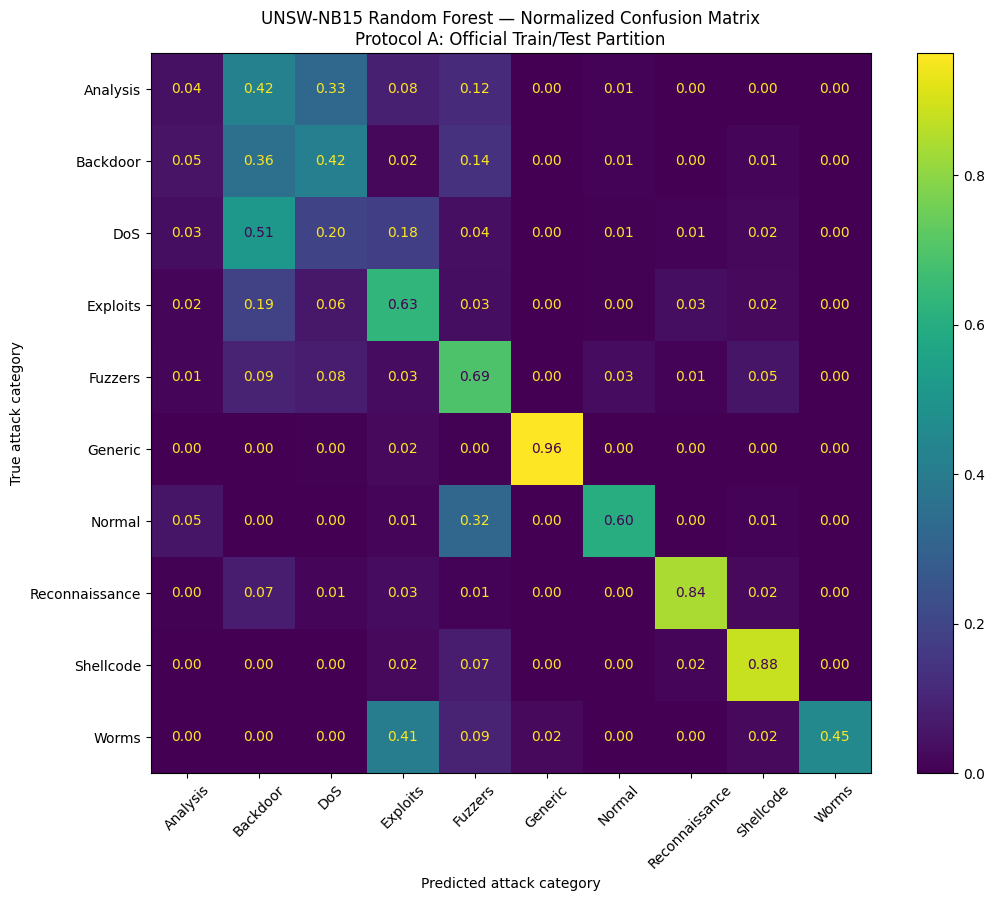

Saved 600-DPI figure to:
/content/drive/MyDrive/UNSW_NB15_Project/results/10_figures/unsw_nb15_official_rf_normalized_confusion_matrix.png


In [ ]:
# ============================================================
# PART 17 — Protocol A normalized confusion matrix
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


figure_path = (
    OUTPUT_DIRS["figures"] /
    "unsw_nb15_official_rf_normalized_confusion_matrix.png"
)

fig, ax = plt.subplots(
    figsize=(11, 9)
)

display = ConfusionMatrixDisplay(
    confusion_matrix=official_confusion_normalized,
    display_labels=CANONICAL_CLASSES
)

display.plot(
    ax=ax,
    values_format=".2f",
    xticks_rotation=45,
    colorbar=True
)

ax.set_title(
    "UNSW-NB15 Random Forest — Normalized Confusion Matrix\n"
    "Protocol A: Official Train/Test Partition"
)

ax.set_xlabel("Predicted attack category")
ax.set_ylabel("True attack category")

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved 600-DPI figure to:")
print(figure_path)

In [ ]:
# ============================================================
# PART 18 — Load Protocol B processed data
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd


CONSERVATIVE_PROCESSED_DIR = (
    OUTPUT_DIRS["preprocessing"]
    / "processed_protocols"
    / "conservative"
)

CONSERVATIVE_MODEL_DIR = (
    OUTPUT_DIRS["models"]
    / "conservative_random_forest"
)

CONSERVATIVE_CLASSIFICATION_DIR = (
    OUTPUT_DIRS["classification"]
    / "conservative_random_forest"
)

CONSERVATIVE_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CONSERVATIVE_CLASSIFICATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Load arrays using memory mapping
X_train_conservative = np.load(
    CONSERVATIVE_PROCESSED_DIR
    / "X_train_float32.npy",
    mmap_mode="r"
)

X_test_conservative = np.load(
    CONSERVATIVE_PROCESSED_DIR
    / "X_test_float32.npy",
    mmap_mode="r"
)

y_train_conservative = np.load(
    CONSERVATIVE_PROCESSED_DIR
    / "y_train_int64.npy"
)

y_test_conservative = np.load(
    CONSERVATIVE_PROCESSED_DIR
    / "y_test_int64.npy"
)

conservative_train_metadata = pd.read_csv(
    CONSERVATIVE_PROCESSED_DIR
    / "train_metadata.csv"
)

conservative_test_metadata = pd.read_csv(
    CONSERVATIVE_PROCESSED_DIR
    / "test_metadata.csv"
)

conservative_feature_names = pd.read_csv(
    CONSERVATIVE_PROCESSED_DIR
    / "transformed_feature_names.csv"
)

print("X_train shape:", X_train_conservative.shape)
print("X_test shape :", X_test_conservative.shape)
print("y_train shape:", y_train_conservative.shape)
print("y_test shape :", y_test_conservative.shape)

print("\nFeature count:", len(conservative_feature_names))
print("Training classes:", np.unique(y_train_conservative))
print("Testing classes :", np.unique(y_test_conservative))

# Validation
assert X_train_conservative.shape == (107740, 194)
assert X_test_conservative.shape == (53915, 194)

assert len(y_train_conservative) == len(
    X_train_conservative
)

assert len(y_test_conservative) == len(
    X_test_conservative
)

assert len(conservative_feature_names) == 194

assert set(np.unique(y_train_conservative)) == set(
    range(10)
)

assert set(np.unique(y_test_conservative)) == set(
    range(10)
)

# Verify identical transformed feature order across protocols
official_feature_list = (
    official_feature_names[
        "transformed_feature_name"
    ].tolist()
)

conservative_feature_list = (
    conservative_feature_names[
        "transformed_feature_name"
    ].tolist()
)

assert official_feature_list == conservative_feature_list

print(
    "\n✅ Protocol B matrices loaded and validated."
)

print(
    "✅ Official and conservative feature order is identical."
)

X_train shape: (107740, 194)
X_test shape : (53915, 194)
y_train shape: (107740,)
y_test shape : (53915,)

Feature count: 194
Training classes: [0 1 2 3 4 5 6 7 8 9]
Testing classes : [0 1 2 3 4 5 6 7 8 9]

✅ Protocol B matrices loaded and validated.
✅ Official and conservative feature order is identical.


In [ ]:
# ============================================================
# PART 19 — Train Protocol B Random Forest
# ============================================================

import json
import os
import platform
import time

import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.ensemble import RandomForestClassifier


OFFICIAL_MODEL_CONFIG_PATH = (
    OFFICIAL_MODEL_DIR
    / "model_configuration.json"
)

with open(
    OFFICIAL_MODEL_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as configuration_file:
    official_model_configuration = json.load(
        configuration_file
    )

RF_PARAMETERS_CONSERVATIVE = (
    official_model_configuration[
        "parameters"
    ].copy()
)

print("Random Forest parameters copied from Protocol A:")

for parameter_name, parameter_value in (
    RF_PARAMETERS_CONSERVATIVE.items()
):
    print(
        f"{parameter_name}: {parameter_value}"
    )

conservative_rf_model = RandomForestClassifier(
    **RF_PARAMETERS_CONSERVATIVE
)

print("\nTraining Protocol B Random Forest...")
print(
    "Training rows :",
    f"{len(X_train_conservative):,}"
)
print(
    "Features      :",
    X_train_conservative.shape[1]
)
print(
    "Trees         :",
    RF_PARAMETERS_CONSERVATIVE[
        "n_estimators"
    ]
)
print(
    "Maximum depth :",
    RF_PARAMETERS_CONSERVATIVE[
        "max_depth"
    ]
)
print(
    "CPU cores     :",
    os.cpu_count()
)

training_start = time.perf_counter()

conservative_rf_model.fit(
    X_train_conservative,
    y_train_conservative
)

conservative_training_seconds = (
    time.perf_counter()
    - training_start
)

print(
    "\n✅ Protocol B Random Forest training completed."
)

print(
    "Training time:",
    f"{conservative_training_seconds:.2f} seconds"
)

print(
    "Learned classes:",
    conservative_rf_model.classes_
)

assert np.array_equal(
    conservative_rf_model.classes_,
    np.arange(10)
)

# Save trained model
conservative_model_path = (
    CONSERVATIVE_MODEL_DIR
    / "unsw_nb15_conservative_random_forest.joblib"
)

joblib.dump(
    conservative_rf_model,
    conservative_model_path,
    compress=3
)

# Save configuration
conservative_model_configuration = {
    "dataset": "UNSW-NB15",
    "protocol": "Protocol B — Conservative",
    "model": "RandomForestClassifier",
    "parameters": RF_PARAMETERS_CONSERVATIVE,
    "training_rows": int(
        X_train_conservative.shape[0]
    ),
    "transformed_features": int(
        X_train_conservative.shape[1]
    ),
    "training_seconds": float(
        conservative_training_seconds
    ),
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
    "cpu_count": os.cpu_count(),
    "parameter_source": (
        "Copied from Protocol A model configuration"
    )
}

conservative_model_config_path = (
    CONSERVATIVE_MODEL_DIR
    / "model_configuration.json"
)

with open(
    conservative_model_config_path,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        conservative_model_configuration,
        configuration_file,
        indent=2,
        ensure_ascii=False
    )

print("\nModel saved to:")
print(conservative_model_path)

print("\nConfiguration saved to:")
print(conservative_model_config_path)

Random Forest parameters copied from Protocol A:
n_estimators: 150
criterion: gini
max_depth: 20
min_samples_split: 2
min_samples_leaf: 1
max_features: sqrt
bootstrap: True
class_weight: balanced_subsample
random_state: 42
n_jobs: -1

Training Protocol B Random Forest...
Training rows : 107,740
Features      : 194
Trees         : 150
Maximum depth : 20
CPU cores     : 2

✅ Protocol B Random Forest training completed.
Training time: 28.41 seconds
Learned classes: [0 1 2 3 4 5 6 7 8 9]

Model saved to:
/content/drive/MyDrive/UNSW_NB15_Project/results/03_models/conservative_random_forest/unsw_nb15_conservative_random_forest.joblib

Configuration saved to:
/content/drive/MyDrive/UNSW_NB15_Project/results/03_models/conservative_random_forest/model_configuration.json


In [ ]:
# ============================================================
# PART 20 — Evaluate Protocol B Random Forest
# ============================================================

import json
import time

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


print("Generating Protocol B predictions...")

prediction_start = time.perf_counter()

y_pred_conservative = (
    conservative_rf_model.predict(
        X_test_conservative
    )
)

conservative_prediction_seconds = (
    time.perf_counter()
    - prediction_start
)

print("Generating Protocol B class probabilities...")

probability_start = time.perf_counter()

y_proba_conservative = (
    conservative_rf_model.predict_proba(
        X_test_conservative
    )
)

conservative_probability_seconds = (
    time.perf_counter()
    - probability_start
)

conservative_prediction_confidence = (
    y_proba_conservative.max(axis=1)
)

# ------------------------------------------------------------
# Aggregate metrics
# ------------------------------------------------------------

conservative_accuracy = accuracy_score(
    y_test_conservative,
    y_pred_conservative
)

conservative_macro_precision = precision_score(
    y_test_conservative,
    y_pred_conservative,
    average="macro",
    zero_division=0
)

conservative_macro_recall = recall_score(
    y_test_conservative,
    y_pred_conservative,
    average="macro",
    zero_division=0
)

conservative_macro_f1 = f1_score(
    y_test_conservative,
    y_pred_conservative,
    average="macro",
    zero_division=0
)

conservative_weighted_f1 = f1_score(
    y_test_conservative,
    y_pred_conservative,
    average="weighted",
    zero_division=0
)

conservative_correct_predictions = int(
    np.sum(
        y_test_conservative
        == y_pred_conservative
    )
)

conservative_error_count = int(
    np.sum(
        y_test_conservative
        != y_pred_conservative
    )
)

conservative_error_rate = (
    conservative_error_count
    / len(y_test_conservative)
)

conservative_inference_ms_per_event = (
    conservative_prediction_seconds
    / len(y_test_conservative)
    * 1000
)

conservative_probability_ms_per_event = (
    conservative_probability_seconds
    / len(y_test_conservative)
    * 1000
)

# ------------------------------------------------------------
# Per-class report
# ------------------------------------------------------------

conservative_report_dictionary = (
    classification_report(
        y_test_conservative,
        y_pred_conservative,
        labels=np.arange(10),
        target_names=CANONICAL_CLASSES,
        output_dict=True,
        zero_division=0
    )
)

conservative_report_table = (
    pd.DataFrame(
        conservative_report_dictionary
    )
    .transpose()
    .reset_index()
    .rename(
        columns={
            "index": "class_or_average"
        }
    )
)

# ------------------------------------------------------------
# Confusion matrices
# ------------------------------------------------------------

conservative_confusion_raw = confusion_matrix(
    y_test_conservative,
    y_pred_conservative,
    labels=np.arange(10)
)

conservative_confusion_normalized = confusion_matrix(
    y_test_conservative,
    y_pred_conservative,
    labels=np.arange(10),
    normalize="true"
)

conservative_confusion_raw_table = pd.DataFrame(
    conservative_confusion_raw,
    index=CANONICAL_CLASSES,
    columns=CANONICAL_CLASSES
)

conservative_confusion_normalized_table = (
    pd.DataFrame(
        conservative_confusion_normalized,
        index=CANONICAL_CLASSES,
        columns=CANONICAL_CLASSES
    )
)

# ------------------------------------------------------------
# Save arrays
# ------------------------------------------------------------

np.save(
    CONSERVATIVE_CLASSIFICATION_DIR
    / "y_pred_int64.npy",
    y_pred_conservative.astype(np.int64)
)

np.save(
    CONSERVATIVE_CLASSIFICATION_DIR
    / "y_proba_float32.npy",
    y_proba_conservative.astype(np.float32)
)

np.save(
    CONSERVATIVE_CLASSIFICATION_DIR
    / "prediction_confidence_float32.npy",
    conservative_prediction_confidence.astype(
        np.float32
    )
)

# ------------------------------------------------------------
# Save reports
# ------------------------------------------------------------

conservative_report_table.to_csv(
    CONSERVATIVE_CLASSIFICATION_DIR
    / "classification_report.csv",
    index=False
)

conservative_confusion_raw_table.to_csv(
    CONSERVATIVE_CLASSIFICATION_DIR
    / "confusion_matrix_raw.csv",
    index=True
)

conservative_confusion_normalized_table.to_csv(
    CONSERVATIVE_CLASSIFICATION_DIR
    / "confusion_matrix_normalized.csv",
    index=True
)

# ------------------------------------------------------------
# Save per-event predictions
# ------------------------------------------------------------

conservative_predictions_table = (
    conservative_test_metadata.copy()
)

conservative_predictions_table[
    "true_class_id"
] = y_test_conservative

conservative_predictions_table[
    "predicted_class_id"
] = y_pred_conservative

conservative_predictions_table[
    "predicted_class"
] = [
    ID_TO_CLASS[int(class_id)]
    for class_id in y_pred_conservative
]

conservative_predictions_table[
    "prediction_confidence"
] = conservative_prediction_confidence

conservative_predictions_table[
    "correct_prediction"
] = (
    y_test_conservative
    == y_pred_conservative
)

conservative_predictions_table.to_csv(
    CONSERVATIVE_CLASSIFICATION_DIR
    / "per_event_predictions.csv",
    index=False
)

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

conservative_metric_summary = {
    "dataset": "UNSW-NB15",
    "protocol": "Protocol B — Conservative",
    "model": "Random Forest",
    "training_rows": int(
        X_train_conservative.shape[0]
    ),
    "testing_rows": int(
        X_test_conservative.shape[0]
    ),
    "classes": 10,
    "transformed_features": int(
        X_train_conservative.shape[1]
    ),
    "accuracy": float(
        conservative_accuracy
    ),
    "macro_precision": float(
        conservative_macro_precision
    ),
    "macro_recall": float(
        conservative_macro_recall
    ),
    "macro_f1": float(
        conservative_macro_f1
    ),
    "weighted_f1": float(
        conservative_weighted_f1
    ),
    "correct_predictions": int(
        conservative_correct_predictions
    ),
    "incorrect_predictions": int(
        conservative_error_count
    ),
    "error_rate": float(
        conservative_error_rate
    ),
    "mean_prediction_confidence": float(
        conservative_prediction_confidence.mean()
    ),
    "training_seconds": float(
        conservative_training_seconds
    ),
    "label_prediction_seconds": float(
        conservative_prediction_seconds
    ),
    "probability_prediction_seconds": float(
        conservative_probability_seconds
    ),
    "label_inference_ms_per_event": float(
        conservative_inference_ms_per_event
    ),
    "probability_inference_ms_per_event": float(
        conservative_probability_ms_per_event
    ),
}

conservative_metric_summary_path = (
    CONSERVATIVE_CLASSIFICATION_DIR
    / "classification_summary.json"
)

with open(
    conservative_metric_summary_path,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        conservative_metric_summary,
        summary_file,
        indent=2,
        ensure_ascii=False
    )

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print(
    "UNSW-NB15 PROTOCOL B — RANDOM FOREST RESULTS"
)
print("=" * 70)

print(
    f"Accuracy        : "
    f"{conservative_accuracy:.6f}"
)

print(
    f"Macro precision : "
    f"{conservative_macro_precision:.6f}"
)

print(
    f"Macro recall    : "
    f"{conservative_macro_recall:.6f}"
)

print(
    f"Macro-F1        : "
    f"{conservative_macro_f1:.6f}"
)

print(
    f"Weighted-F1     : "
    f"{conservative_weighted_f1:.6f}"
)

print(
    f"Correct events  : "
    f"{conservative_correct_predictions:,}"
)

print(
    f"Incorrect events: "
    f"{conservative_error_count:,}"
)

print(
    f"Mean confidence : "
    f"{conservative_prediction_confidence.mean():.6f}"
)

print(
    f"Training time   : "
    f"{conservative_training_seconds:.2f} seconds"
)

print(
    f"Prediction time : "
    f"{conservative_prediction_seconds:.2f} seconds"
)

print(
    f"Probability time: "
    f"{conservative_probability_seconds:.2f} seconds"
)

print("\nPER-CLASS RESULTS")

display_columns = [
    "class_or_average",
    "precision",
    "recall",
    "f1-score",
    "support",
]

print(
    conservative_report_table[
        display_columns
    ].to_string(index=False)
)

print("\nSaved to:")
print(CONSERVATIVE_CLASSIFICATION_DIR)

print(
    "\n✅ Protocol B Random Forest evaluation completed."
)

Generating Protocol B predictions...
Generating Protocol B class probabilities...

UNSW-NB15 PROTOCOL B — RANDOM FOREST RESULTS
Accuracy        : 0.667180
Macro precision : 0.560214
Macro recall    : 0.634320
Macro-F1        : 0.529269
Weighted-F1     : 0.717554
Correct events  : 35,971
Incorrect events: 17,944
Mean confidence : 0.788246
Training time   : 28.41 seconds
Prediction time : 1.25 seconds
Probability time: 0.84 seconds

PER-CLASS RESULTS
class_or_average  precision   recall  f1-score     support
        Analysis   0.045557 0.307927  0.079371   328.00000
        Backdoor   0.212351 0.568116  0.309148   345.00000
             DoS   0.588697 0.253207  0.354108  1481.00000
        Exploits   0.745601 0.825599  0.783563  7391.00000
         Fuzzers   0.247641 0.777514  0.375640  4625.00000
         Generic   0.992318 0.837607  0.908423  3393.00000
          Normal   0.992615 0.606844  0.753207 33666.00000
  Reconnaissance   0.806869 0.877031  0.840488  2277.00000
       Shellcode

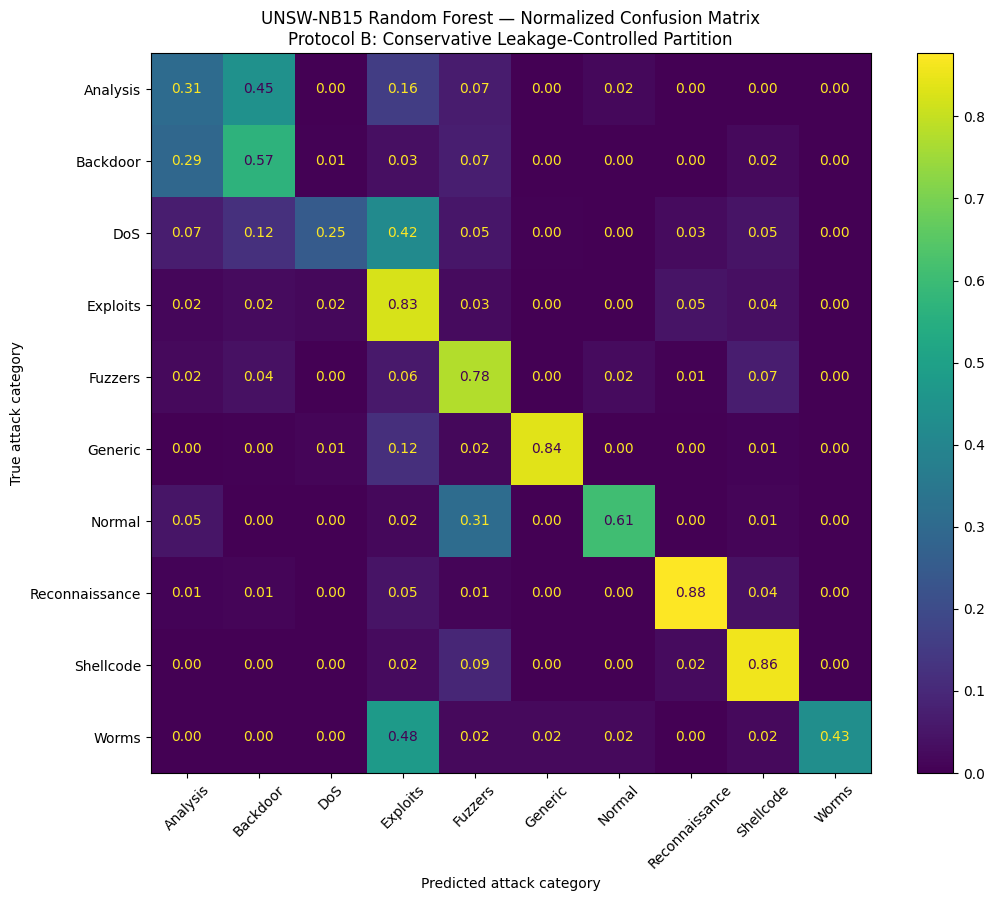

Saved 600-DPI figure to:
/content/drive/MyDrive/UNSW_NB15_Project/results/10_figures/unsw_nb15_conservative_rf_normalized_confusion_matrix.png


In [ ]:
# ============================================================
# PART 21 — Protocol B normalized confusion matrix
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


conservative_figure_path = (
    OUTPUT_DIRS["figures"]
    / "unsw_nb15_conservative_rf_normalized_confusion_matrix.png"
)

fig, ax = plt.subplots(
    figsize=(11, 9)
)

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=(
        conservative_confusion_normalized
    ),
    display_labels=CANONICAL_CLASSES
)

confusion_display.plot(
    ax=ax,
    values_format=".2f",
    xticks_rotation=45,
    colorbar=True
)

ax.set_title(
    "UNSW-NB15 Random Forest — Normalized Confusion Matrix\n"
    "Protocol B: Conservative Leakage-Controlled Partition"
)

ax.set_xlabel(
    "Predicted attack category"
)

ax.set_ylabel(
    "True attack category"
)

plt.tight_layout()

plt.savefig(
    conservative_figure_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved 600-DPI figure to:")
print(conservative_figure_path)

In [ ]:
# ============================================================
# PART 22 — Official versus conservative comparison
# ============================================================

import json

import numpy as np
import pandas as pd


OFFICIAL_SUMMARY_PATH = (
    OFFICIAL_CLASSIFICATION_DIR
    / "classification_summary.json"
)

CONSERVATIVE_SUMMARY_PATH = (
    CONSERVATIVE_CLASSIFICATION_DIR
    / "classification_summary.json"
)

with open(
    OFFICIAL_SUMMARY_PATH,
    "r",
    encoding="utf-8"
) as summary_file:
    official_summary = json.load(
        summary_file
    )

with open(
    CONSERVATIVE_SUMMARY_PATH,
    "r",
    encoding="utf-8"
) as summary_file:
    conservative_summary = json.load(
        summary_file
    )

comparison_metrics = [
    "training_rows",
    "testing_rows",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "error_rate",
    "mean_prediction_confidence",
    "training_seconds",
    "label_inference_ms_per_event",
    "probability_inference_ms_per_event",
]

protocol_comparison_rows = []

for metric in comparison_metrics:
    official_value = official_summary[metric]
    conservative_value = conservative_summary[metric]

    if isinstance(
        official_value,
        (int, float)
    ):
        difference = (
            conservative_value
            - official_value
        )
    else:
        difference = np.nan

    protocol_comparison_rows.append({
        "metric": metric,
        "official_protocol": official_value,
        "conservative_protocol": conservative_value,
        "conservative_minus_official": difference,
    })

protocol_comparison_table = pd.DataFrame(
    protocol_comparison_rows
)

comparison_output_path = (
    OUTPUT_DIRS["classification"]
    / "unsw_nb15_official_vs_conservative_summary.csv"
)

protocol_comparison_table.to_csv(
    comparison_output_path,
    index=False
)

print(
    "OFFICIAL VERSUS CONSERVATIVE SUMMARY"
)

print(
    protocol_comparison_table.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Per-class comparison
# ------------------------------------------------------------

official_class_report = pd.read_csv(
    OFFICIAL_CLASSIFICATION_DIR
    / "classification_report.csv"
)

conservative_class_report = pd.read_csv(
    CONSERVATIVE_CLASSIFICATION_DIR
    / "classification_report.csv"
)

official_class_only = (
    official_class_report[
        official_class_report[
            "class_or_average"
        ].isin(CANONICAL_CLASSES)
    ]
    .copy()
)

conservative_class_only = (
    conservative_class_report[
        conservative_class_report[
            "class_or_average"
        ].isin(CANONICAL_CLASSES)
    ]
    .copy()
)

official_class_only = (
    official_class_only.rename(
        columns={
            "precision": "official_precision",
            "recall": "official_recall",
            "f1-score": "official_f1",
            "support": "official_support",
        }
    )
)

conservative_class_only = (
    conservative_class_only.rename(
        columns={
            "precision": "conservative_precision",
            "recall": "conservative_recall",
            "f1-score": "conservative_f1",
            "support": "conservative_support",
        }
    )
)

per_class_comparison = (
    official_class_only[
        [
            "class_or_average",
            "official_precision",
            "official_recall",
            "official_f1",
            "official_support",
        ]
    ]
    .merge(
        conservative_class_only[
            [
                "class_or_average",
                "conservative_precision",
                "conservative_recall",
                "conservative_f1",
                "conservative_support",
            ]
        ],
        on="class_or_average",
        how="inner"
    )
)

per_class_comparison[
    "recall_difference"
] = (
    per_class_comparison[
        "conservative_recall"
    ]
    - per_class_comparison[
        "official_recall"
    ]
)

per_class_comparison[
    "f1_difference"
] = (
    per_class_comparison[
        "conservative_f1"
    ]
    - per_class_comparison[
        "official_f1"
    ]
)

per_class_comparison_path = (
    OUTPUT_DIRS["classification"]
    / "unsw_nb15_official_vs_conservative_per_class.csv"
)

per_class_comparison.to_csv(
    per_class_comparison_path,
    index=False
)

print("\nPER-CLASS COMPARISON")

print(
    per_class_comparison[
        [
            "class_or_average",
            "official_recall",
            "conservative_recall",
            "recall_difference",
            "official_f1",
            "conservative_f1",
            "f1_difference",
        ]
    ].to_string(index=False)
)

print("\nSaved:")
print(comparison_output_path)
print(per_class_comparison_path)

print(
    "\n✅ Official-versus-conservative comparison completed."
)

OFFICIAL VERSUS CONSERVATIVE SUMMARY
                            metric  official_protocol  conservative_protocol  conservative_minus_official
                     training_rows      175341.000000          107740.000000                -67601.000000
                      testing_rows       82332.000000           53915.000000                -28417.000000
                          accuracy           0.680574               0.667180                    -0.013394
                   macro_precision           0.494089               0.560214                     0.066125
                      macro_recall           0.566443               0.634320                     0.067876
                          macro_f1           0.479517               0.529269                     0.049752
                       weighted_f1           0.732170               0.717554                    -0.014616
                        error_rate           0.319426               0.332820                     0.013394
        m

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# PART 23 — Reload paths and validate probability artifacts
# Self-contained recovery version for a restarted Colab runtime
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Mount Google Drive when necessary
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive")

if not DRIVE_ROOT.exists():
    from google.colab import drive
    drive.mount("/content/drive")

# ------------------------------------------------------------
# 2. Recreate project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

OUTPUT_DIRS = {
    "audit": RESULTS_DIR / "01_dataset_audit",
    "preprocessing": RESULTS_DIR / "02_preprocessing",
    "models": RESULTS_DIR / "03_models",
    "classification": RESULTS_DIR / "04_classification",
    "calibration": RESULTS_DIR / "05_calibration",
    "shap": RESULTS_DIR / "06_shap",
    "evidence": RESULTS_DIR / "07_evidence_bundles",
    "reports": RESULTS_DIR / "08_generated_reports",
    "verifier": RESULTS_DIR / "09_verifier",
    "figures": RESULTS_DIR / "10_figures",
    "configs": PROJECT_ROOT / "configs",
}

for folder in OUTPUT_DIRS.values():
    folder.mkdir(parents=True, exist_ok=True)

CALIBRATION_DIR = OUTPUT_DIRS["calibration"]
CALIBRATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 3. Define Protocol A paths
# ------------------------------------------------------------

OFFICIAL_PROCESSED_DIR = (
    OUTPUT_DIRS["preprocessing"]
    / "processed_protocols"
    / "official"
)

OFFICIAL_CLASSIFICATION_DIR = (
    OUTPUT_DIRS["classification"]
    / "official_random_forest"
)

# ------------------------------------------------------------
# 4. Define Protocol B paths
# ------------------------------------------------------------

CONSERVATIVE_PROCESSED_DIR = (
    OUTPUT_DIRS["preprocessing"]
    / "processed_protocols"
    / "conservative"
)

CONSERVATIVE_CLASSIFICATION_DIR = (
    OUTPUT_DIRS["classification"]
    / "conservative_random_forest"
)

# ------------------------------------------------------------
# 5. Verify required files before loading
# ------------------------------------------------------------

required_files = [
    OFFICIAL_PROCESSED_DIR / "y_test_int64.npy",
    OFFICIAL_PROCESSED_DIR / "test_metadata.csv",
    OFFICIAL_CLASSIFICATION_DIR / "y_pred_int64.npy",
    OFFICIAL_CLASSIFICATION_DIR / "y_proba_float32.npy",

    CONSERVATIVE_PROCESSED_DIR / "y_test_int64.npy",
    CONSERVATIVE_PROCESSED_DIR / "test_metadata.csv",
    CONSERVATIVE_CLASSIFICATION_DIR / "y_pred_int64.npy",
    CONSERVATIVE_CLASSIFICATION_DIR / "y_proba_float32.npy",
]

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files were not found:\n"
        + "\n".join(missing_files)
    )

print("✅ All required probability files were found.")

# ------------------------------------------------------------
# 6. Load Protocol A artifacts
# ------------------------------------------------------------

y_true_official = np.load(
    OFFICIAL_PROCESSED_DIR
    / "y_test_int64.npy"
)

y_pred_official_saved = np.load(
    OFFICIAL_CLASSIFICATION_DIR
    / "y_pred_int64.npy"
)

y_proba_official_saved = np.load(
    OFFICIAL_CLASSIFICATION_DIR
    / "y_proba_float32.npy"
)

official_event_metadata = pd.read_csv(
    OFFICIAL_PROCESSED_DIR
    / "test_metadata.csv"
)

# ------------------------------------------------------------
# 7. Load Protocol B artifacts
# ------------------------------------------------------------

y_true_conservative = np.load(
    CONSERVATIVE_PROCESSED_DIR
    / "y_test_int64.npy"
)

y_pred_conservative_saved = np.load(
    CONSERVATIVE_CLASSIFICATION_DIR
    / "y_pred_int64.npy"
)

y_proba_conservative_saved = np.load(
    CONSERVATIVE_CLASSIFICATION_DIR
    / "y_proba_float32.npy"
)

conservative_event_metadata = pd.read_csv(
    CONSERVATIVE_PROCESSED_DIR
    / "test_metadata.csv"
)

# ------------------------------------------------------------
# 8. Validation function
# ------------------------------------------------------------

def validate_probability_artifacts(
    protocol_name,
    y_true,
    y_pred,
    y_proba,
    metadata
):
    if y_true.ndim != 1:
        raise ValueError(
            f"{protocol_name}: y_true must be one-dimensional."
        )

    if y_pred.ndim != 1:
        raise ValueError(
            f"{protocol_name}: y_pred must be one-dimensional."
        )

    if y_proba.ndim != 2:
        raise ValueError(
            f"{protocol_name}: y_proba must be two-dimensional."
        )

    if len(y_true) != len(y_pred):
        raise ValueError(
            f"{protocol_name}: true/predicted lengths differ."
        )

    if len(y_true) != y_proba.shape[0]:
        raise ValueError(
            f"{protocol_name}: probability row count differs."
        )

    if len(y_true) != len(metadata):
        raise ValueError(
            f"{protocol_name}: metadata row count differs."
        )

    if y_proba.shape[1] != 10:
        raise ValueError(
            f"{protocol_name}: expected 10 probability columns."
        )

    if not np.isfinite(y_proba).all():
        raise ValueError(
            f"{protocol_name}: probabilities contain NaN or infinity."
        )

    if np.any(y_proba < 0) or np.any(y_proba > 1):
        raise ValueError(
            f"{protocol_name}: probabilities fall outside [0, 1]."
        )

    probability_sums = y_proba.sum(axis=1)

    if not np.allclose(
        probability_sums,
        1.0,
        atol=1e-5
    ):
        raise ValueError(
            f"{protocol_name}: probability rows do not sum to 1."
        )

    argmax_predictions = np.argmax(
        y_proba,
        axis=1
    )

    if not np.array_equal(
        argmax_predictions,
        y_pred
    ):
        raise ValueError(
            f"{protocol_name}: predictions do not match "
            "the probability argmax."
        )

    print(
        f"✅ {protocol_name}: "
        f"{len(y_true):,} events, "
        f"{y_proba.shape[1]} classes."
    )


# ------------------------------------------------------------
# 9. Validate both packages
# ------------------------------------------------------------

validate_probability_artifacts(
    "Protocol A — Official",
    y_true_official,
    y_pred_official_saved,
    y_proba_official_saved,
    official_event_metadata
)

validate_probability_artifacts(
    "Protocol B — Conservative",
    y_true_conservative,
    y_pred_conservative_saved,
    y_proba_conservative_saved,
    conservative_event_metadata
)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nCalibration output directory:")
print(CALIBRATION_DIR)

print("\n✅ Both probability packages are valid.")

✅ All required probability files were found.
✅ Protocol A — Official: 82,332 events, 10 classes.
✅ Protocol B — Conservative: 53,915 events, 10 classes.

Project root:
/content/drive/MyDrive/UNSW_NB15_Project

Calibration output directory:
/content/drive/MyDrive/UNSW_NB15_Project/results/05_calibration

✅ Both probability packages are valid.


In [ ]:
# ============================================================
# PART 24 — Calibration and uncertainty helper functions
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    log_loss,
    roc_auc_score,
)


def calculate_multiclass_brier_score(
    y_true,
    y_proba,
    number_of_classes=10
):
    """
    Multiclass Brier score:
    mean over events of the summed squared probability error.
    Lower is better.
    """

    one_hot_targets = np.eye(
        number_of_classes,
        dtype=np.float64
    )[y_true]

    squared_error = (
        y_proba.astype(np.float64)
        - one_hot_targets
    ) ** 2

    return float(
        np.mean(
            np.sum(
                squared_error,
                axis=1
            )
        )
    )


def build_top_label_reliability_table(
    y_true,
    y_pred,
    confidence,
    number_of_bins=15
):
    """
    Equal-width top-label reliability bins.
    """

    confidence = np.asarray(
        confidence,
        dtype=np.float64
    )

    correct = (
        np.asarray(y_true)
        == np.asarray(y_pred)
    ).astype(np.float64)

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1
    )

    bin_ids = np.digitize(
        confidence,
        bin_edges,
        right=False
    ) - 1

    bin_ids = np.clip(
        bin_ids,
        0,
        number_of_bins - 1
    )

    reliability_rows = []

    for bin_id in range(number_of_bins):
        bin_mask = bin_ids == bin_id
        bin_count = int(bin_mask.sum())

        if bin_count == 0:
            mean_confidence = np.nan
            empirical_accuracy = np.nan
            absolute_gap = np.nan
        else:
            mean_confidence = float(
                confidence[bin_mask].mean()
            )

            empirical_accuracy = float(
                correct[bin_mask].mean()
            )

            absolute_gap = abs(
                empirical_accuracy
                - mean_confidence
            )

        reliability_rows.append({
            "bin_id": bin_id,
            "lower_bound": float(
                bin_edges[bin_id]
            ),
            "upper_bound": float(
                bin_edges[bin_id + 1]
            ),
            "event_count": bin_count,
            "mean_confidence": mean_confidence,
            "empirical_accuracy": empirical_accuracy,
            "absolute_gap": absolute_gap,
        })

    return pd.DataFrame(
        reliability_rows
    )


def calculate_top_label_ece(
    reliability_table,
    total_events
):
    valid_rows = reliability_table[
        reliability_table["event_count"] > 0
    ].copy()

    weights = (
        valid_rows["event_count"]
        / total_events
    )

    ece = np.sum(
        weights
        * valid_rows["absolute_gap"]
    )

    return float(ece)


def build_review_routing_table(
    y_true,
    y_pred,
    confidence,
    thresholds
):
    """
    Events below a confidence threshold are sent to review.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    confidence = np.asarray(confidence)

    error_mask = y_true != y_pred
    total_errors = int(error_mask.sum())

    routing_rows = []

    for threshold in thresholds:
        review_mask = confidence < threshold
        automatic_mask = ~review_mask

        reviewed_events = int(
            review_mask.sum()
        )

        errors_captured = int(
            (
                review_mask
                & error_mask
            ).sum()
        )

        if total_errors > 0:
            error_capture_rate = (
                errors_captured
                / total_errors
            )
        else:
            error_capture_rate = np.nan

        if automatic_mask.sum() > 0:
            retained_accuracy = float(
                (
                    y_true[automatic_mask]
                    == y_pred[automatic_mask]
                ).mean()
            )
        else:
            retained_accuracy = np.nan

        routing_rows.append({
            "review_threshold": float(threshold),
            "reviewed_events": reviewed_events,
            "review_fraction": float(
                reviewed_events / len(y_true)
            ),
            "errors_captured": errors_captured,
            "error_capture_rate": float(
                error_capture_rate
            ),
            "automatic_events": int(
                automatic_mask.sum()
            ),
            "automatic_fraction": float(
                automatic_mask.mean()
            ),
            "retained_accuracy": retained_accuracy,
        })

    return pd.DataFrame(
        routing_rows
    )


def build_risk_coverage_curve(
    y_true,
    y_pred,
    confidence
):
    """
    Retain predictions from highest to lowest confidence.
    Selective risk is the error rate among retained events.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    confidence = np.asarray(confidence)

    order = np.argsort(
        -confidence,
        kind="mergesort"
    )

    sorted_errors = (
        y_true[order]
        != y_pred[order]
    ).astype(np.float64)

    sorted_confidence = confidence[order]

    retained_count = np.arange(
        1,
        len(y_true) + 1
    )

    coverage = (
        retained_count
        / len(y_true)
    )

    cumulative_errors = np.cumsum(
        sorted_errors
    )

    selective_risk = (
        cumulative_errors
        / retained_count
    )

    risk_coverage_table = pd.DataFrame({
        "coverage_retained": coverage,
        "retained_events": retained_count,
        "selective_error_rate": selective_risk,
        "minimum_retained_confidence":
            sorted_confidence,
    })

    aurc = float(
        np.trapezoid(
            selective_risk,
            coverage
        )
    )

    return risk_coverage_table, aurc


def evaluate_uncertainty_protocol(
    protocol_key,
    protocol_name,
    y_true,
    y_pred,
    y_proba,
    metadata,
    output_directory
):
    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    confidence = y_proba.max(axis=1)
    error_score = 1.0 - confidence

    correct_mask = y_true == y_pred
    error_mask = ~correct_mask

    reliability_table = (
        build_top_label_reliability_table(
            y_true=y_true,
            y_pred=y_pred,
            confidence=confidence,
            number_of_bins=15
        )
    )

    ece = calculate_top_label_ece(
        reliability_table,
        len(y_true)
    )

    brier = calculate_multiclass_brier_score(
        y_true=y_true,
        y_proba=y_proba,
        number_of_classes=10
    )

    multiclass_log_loss = log_loss(
        y_true,
        y_proba,
        labels=np.arange(10)
    )

    error_labels = error_mask.astype(int)

    error_detection_auroc = roc_auc_score(
        error_labels,
        error_score
    )

    error_detection_auprc = (
        average_precision_score(
            error_labels,
            error_score
        )
    )

    total_errors = int(error_mask.sum())

    high_confidence_error_count = int(
        (
            error_mask
            & (confidence > 0.99)
        ).sum()
    )

    if total_errors > 0:
        high_confidence_error_fraction = (
            high_confidence_error_count
            / total_errors
        )

        mean_confidence_on_errors = float(
            confidence[error_mask].mean()
        )
    else:
        high_confidence_error_fraction = np.nan
        mean_confidence_on_errors = np.nan

    mean_confidence_on_correct = float(
        confidence[correct_mask].mean()
    )

    routing_thresholds = [
        0.50,
        0.60,
        0.70,
        0.80,
        0.90,
        0.95,
        0.99,
    ]

    routing_table = build_review_routing_table(
        y_true=y_true,
        y_pred=y_pred,
        confidence=confidence,
        thresholds=routing_thresholds
    )

    deployed_routing_row = (
        routing_table[
            np.isclose(
                routing_table[
                    "review_threshold"
                ],
                0.70
            )
        ]
        .iloc[0]
    )

    risk_coverage_table, aurc = (
        build_risk_coverage_curve(
            y_true=y_true,
            y_pred=y_pred,
            confidence=confidence
        )
    )

    summary = {
        "protocol_key": protocol_key,
        "protocol_name": protocol_name,
        "events": int(len(y_true)),
        "correct_predictions": int(
            correct_mask.sum()
        ),
        "incorrect_predictions": total_errors,
        "accuracy": float(
            correct_mask.mean()
        ),
        "mean_confidence": float(
            confidence.mean()
        ),
        "mean_confidence_on_correct":
            mean_confidence_on_correct,
        "mean_confidence_on_errors":
            mean_confidence_on_errors,
        "multiclass_brier_score":
            float(brier),
        "multiclass_log_loss":
            float(multiclass_log_loss),
        "top_label_ece_15_bins":
            float(ece),
        "errors_above_0_99_confidence":
            high_confidence_error_count,
        "fraction_of_errors_above_0_99":
            float(
                high_confidence_error_fraction
            ),
        "error_detection_auroc":
            float(error_detection_auroc),
        "error_detection_auprc":
            float(error_detection_auprc),
        "error_prevalence":
            float(error_mask.mean()),
        "review_threshold":
            0.70,
        "events_reviewed_at_0_70":
            int(
                deployed_routing_row[
                    "reviewed_events"
                ]
            ),
        "review_fraction_at_0_70":
            float(
                deployed_routing_row[
                    "review_fraction"
                ]
            ),
        "errors_captured_at_0_70":
            int(
                deployed_routing_row[
                    "errors_captured"
                ]
            ),
        "error_capture_rate_at_0_70":
            float(
                deployed_routing_row[
                    "error_capture_rate"
                ]
            ),
        "retained_accuracy_at_0_70":
            float(
                deployed_routing_row[
                    "retained_accuracy"
                ]
            ),
        "area_under_risk_coverage_curve":
            float(aurc),
    }

    per_event_uncertainty = metadata.copy()

    per_event_uncertainty[
        "true_class_id"
    ] = y_true

    per_event_uncertainty[
        "predicted_class_id"
    ] = y_pred

    per_event_uncertainty[
        "prediction_confidence"
    ] = confidence

    per_event_uncertainty[
        "error_score"
    ] = error_score

    per_event_uncertainty[
        "correct_prediction"
    ] = correct_mask

    reliability_table.to_csv(
        output_directory
        / "reliability_table_15_bins.csv",
        index=False
    )

    routing_table.to_csv(
        output_directory
        / "review_routing_threshold_sweep.csv",
        index=False
    )

    risk_coverage_table.to_csv(
        output_directory
        / "risk_coverage_curve.csv",
        index=False
    )

    per_event_uncertainty.to_csv(
        output_directory
        / "per_event_uncertainty.csv",
        index=False
    )

    pd.DataFrame(
        [summary]
    ).to_csv(
        output_directory
        / "uncertainty_summary.csv",
        index=False
    )

    return {
        "summary": summary,
        "reliability": reliability_table,
        "routing": routing_table,
        "risk_coverage": risk_coverage_table,
        "per_event": per_event_uncertainty,
    }


print("✅ Calibration and uncertainty functions defined.")

✅ Calibration and uncertainty functions defined.


In [ ]:
# ============================================================
# PART 25 — Run uncertainty evaluation on both protocols
# ============================================================

import json
import pandas as pd


OFFICIAL_CALIBRATION_DIR = (
    CALIBRATION_DIR
    / "official_random_forest"
)

CONSERVATIVE_CALIBRATION_DIR = (
    CALIBRATION_DIR
    / "conservative_random_forest"
)

official_uncertainty_results = (
    evaluate_uncertainty_protocol(
        protocol_key="official",
        protocol_name="Protocol A — Official",
        y_true=y_true_official,
        y_pred=y_pred_official_saved,
        y_proba=y_proba_official_saved,
        metadata=official_event_metadata,
        output_directory=(
            OFFICIAL_CALIBRATION_DIR
        )
    )
)

conservative_uncertainty_results = (
    evaluate_uncertainty_protocol(
        protocol_key="conservative",
        protocol_name=(
            "Protocol B — Conservative"
        ),
        y_true=y_true_conservative,
        y_pred=y_pred_conservative_saved,
        y_proba=y_proba_conservative_saved,
        metadata=conservative_event_metadata,
        output_directory=(
            CONSERVATIVE_CALIBRATION_DIR
        )
    )
)

combined_uncertainty_summary = pd.DataFrame([
    official_uncertainty_results["summary"],
    conservative_uncertainty_results["summary"],
])

combined_summary_path = (
    CALIBRATION_DIR
    / "unsw_nb15_rf_uncertainty_summary.csv"
)

combined_uncertainty_summary.to_csv(
    combined_summary_path,
    index=False
)

combined_summary_json_path = (
    CALIBRATION_DIR
    / "unsw_nb15_rf_uncertainty_summary.json"
)

with open(
    combined_summary_json_path,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        combined_uncertainty_summary.to_dict(
            orient="records"
        ),
        summary_file,
        indent=2,
        ensure_ascii=False
    )

display_columns = [
    "protocol_key",
    "accuracy",
    "multiclass_brier_score",
    "multiclass_log_loss",
    "top_label_ece_15_bins",
    "mean_confidence_on_correct",
    "mean_confidence_on_errors",
    "fraction_of_errors_above_0_99",
    "error_detection_auroc",
    "error_detection_auprc",
    "review_fraction_at_0_70",
    "error_capture_rate_at_0_70",
    "retained_accuracy_at_0_70",
    "area_under_risk_coverage_curve",
]

print("\nUNSW-NB15 RANDOM FOREST UNCERTAINTY SUMMARY")
print(
    combined_uncertainty_summary[
        display_columns
    ].to_string(index=False)
)

print("\nOFFICIAL PROTOCOL REVIEW-ROUTING SWEEP")
print(
    official_uncertainty_results[
        "routing"
    ].to_string(index=False)
)

print("\nCONSERVATIVE PROTOCOL REVIEW-ROUTING SWEEP")
print(
    conservative_uncertainty_results[
        "routing"
    ].to_string(index=False)
)

print("\nSaved:")
print(combined_summary_path)
print(combined_summary_json_path)

print(
    "\n✅ Calibration and uncertainty evaluation completed."
)


UNSW-NB15 RANDOM FOREST UNCERTAINTY SUMMARY
protocol_key  accuracy  multiclass_brier_score  multiclass_log_loss  top_label_ece_15_bins  mean_confidence_on_correct  mean_confidence_on_errors  fraction_of_errors_above_0_99  error_detection_auroc  error_detection_auprc  review_fraction_at_0_70  error_capture_rate_at_0_70  retained_accuracy_at_0_70  area_under_risk_coverage_curve
    official  0.680574                0.363901             0.676950               0.113060                    0.909739                   0.540158                            0.0               0.923198               0.780934                 0.328026                    0.766379                   0.888947                        0.081034
conservative  0.667180                0.384104             0.670632               0.121066                    0.887197                   0.589887                            0.0               0.882235               0.705208                 0.353482                    0.728489          

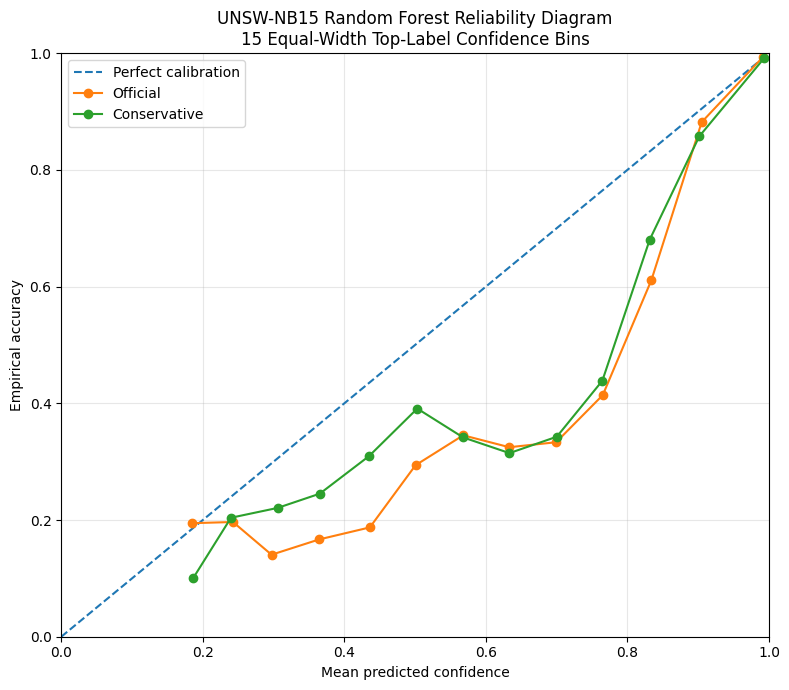

Saved 600-DPI reliability diagram:
/content/drive/MyDrive/UNSW_NB15_Project/results/10_figures/unsw_nb15_rf_reliability_comparison.png


In [ ]:
# ============================================================
# PART 26 — Reliability diagram for both protocols
# ============================================================

import matplotlib.pyplot as plt


reliability_figure_path = (
    OUTPUT_DIRS["figures"]
    / "unsw_nb15_rf_reliability_comparison.png"
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

for protocol_label, results in [
    (
        "Official",
        official_uncertainty_results
    ),
    (
        "Conservative",
        conservative_uncertainty_results
    ),
]:
    table = results["reliability"]
    valid = table["event_count"] > 0

    ax.plot(
        table.loc[
            valid,
            "mean_confidence"
        ],
        table.loc[
            valid,
            "empirical_accuracy"
        ],
        marker="o",
        label=protocol_label
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel(
    "Mean predicted confidence"
)

ax.set_ylabel(
    "Empirical accuracy"
)

ax.set_title(
    "UNSW-NB15 Random Forest Reliability Diagram\n"
    "15 Equal-Width Top-Label Confidence Bins"
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    reliability_figure_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved 600-DPI reliability diagram:")
print(reliability_figure_path)

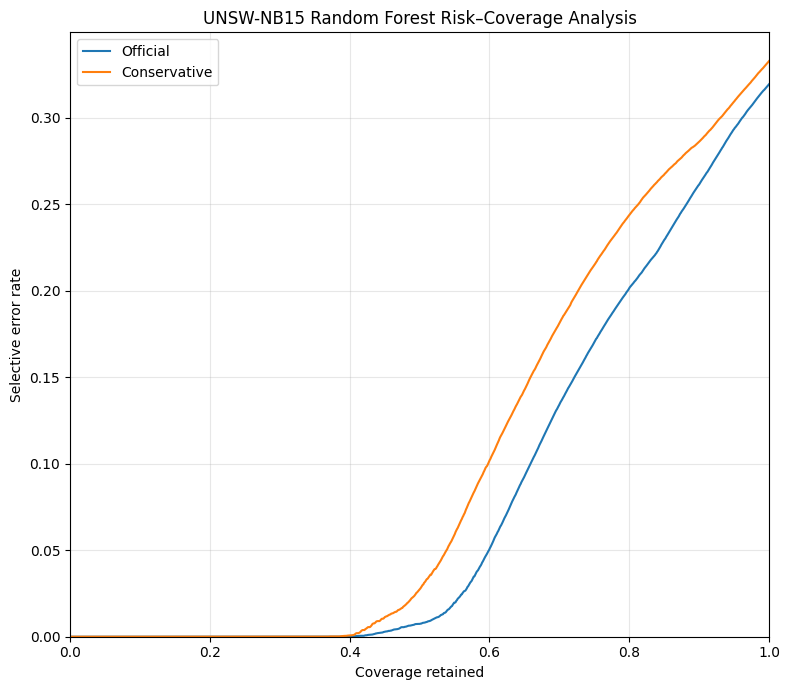

Saved 600-DPI risk–coverage figure:
/content/drive/MyDrive/UNSW_NB15_Project/results/10_figures/unsw_nb15_rf_risk_coverage_comparison.png


In [ ]:
# ============================================================
# PART 27 — Risk–coverage comparison
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


risk_coverage_figure_path = (
    OUTPUT_DIRS["figures"]
    / "unsw_nb15_rf_risk_coverage_comparison.png"
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

for protocol_label, results in [
    (
        "Official",
        official_uncertainty_results
    ),
    (
        "Conservative",
        conservative_uncertainty_results
    ),
]:
    curve = results["risk_coverage"]

    # Plot a compact subset of points for efficiency
    plot_indices = np.linspace(
        0,
        len(curve) - 1,
        1000,
        dtype=int
    )

    ax.plot(
        curve.iloc[
            plot_indices
        ]["coverage_retained"],
        curve.iloc[
            plot_indices
        ]["selective_error_rate"],
        label=protocol_label
    )

ax.set_xlabel(
    "Coverage retained"
)

ax.set_ylabel(
    "Selective error rate"
)

ax.set_title(
    "UNSW-NB15 Random Forest Risk–Coverage Analysis"
)

ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    risk_coverage_figure_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved 600-DPI risk–coverage figure:")
print(risk_coverage_figure_path)

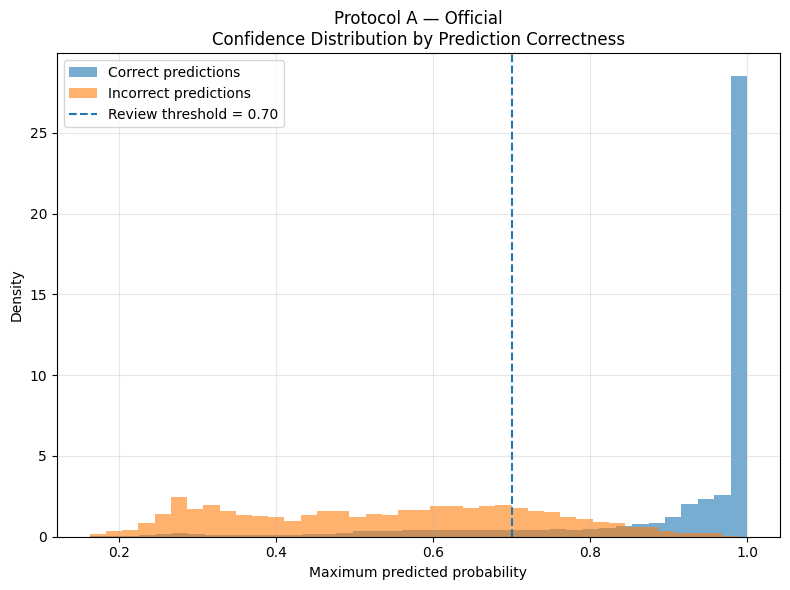

Saved:
/content/drive/MyDrive/UNSW_NB15_Project/results/10_figures/unsw_nb15_official_rf_confidence_distribution.png


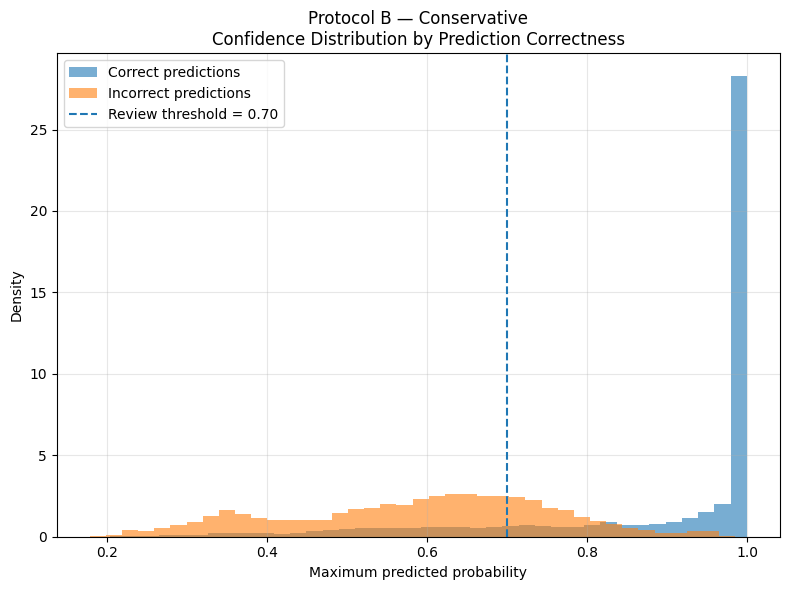

Saved:
/content/drive/MyDrive/UNSW_NB15_Project/results/10_figures/unsw_nb15_conservative_rf_confidence_distribution.png


In [ ]:
# ============================================================
# PART 28 — Confidence distributions by correctness
# ============================================================

import matplotlib.pyplot as plt


def save_confidence_distribution(
    per_event_table,
    protocol_title,
    file_name
):
    figure_path = (
        OUTPUT_DIRS["figures"]
        / file_name
    )

    correct_confidence = (
        per_event_table.loc[
            per_event_table[
                "correct_prediction"
            ],
            "prediction_confidence"
        ]
    )

    incorrect_confidence = (
        per_event_table.loc[
            ~per_event_table[
                "correct_prediction"
            ],
            "prediction_confidence"
        ]
    )

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    ax.hist(
        correct_confidence,
        bins=40,
        alpha=0.6,
        density=True,
        label="Correct predictions"
    )

    ax.hist(
        incorrect_confidence,
        bins=40,
        alpha=0.6,
        density=True,
        label="Incorrect predictions"
    )

    ax.axvline(
        0.70,
        linestyle="--",
        label="Review threshold = 0.70"
    )

    ax.set_xlabel(
        "Maximum predicted probability"
    )

    ax.set_ylabel(
        "Density"
    )

    ax.set_title(
        f"{protocol_title}\n"
        "Confidence Distribution by Prediction Correctness"
    )

    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        figure_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("Saved:")
    print(figure_path)


save_confidence_distribution(
    official_uncertainty_results[
        "per_event"
    ],
    "Protocol A — Official",
    "unsw_nb15_official_rf_confidence_distribution.png"
)

save_confidence_distribution(
    conservative_uncertainty_results[
        "per_event"
    ],
    "Protocol B — Conservative",
    "unsw_nb15_conservative_rf_confidence_distribution.png"
)

In [ ]:
# ============================================================
# PART 29 — Freeze UNSW-NB15 stage mapping and risk policy
# ============================================================

from pathlib import Path
import json
import pandas as pd

# ------------------------------------------------------------
# 1. Recreate project paths if the runtime was restarted
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

OUTPUT_DIRS = {
    "audit": RESULTS_DIR / "01_dataset_audit",
    "preprocessing": RESULTS_DIR / "02_preprocessing",
    "models": RESULTS_DIR / "03_models",
    "classification": RESULTS_DIR / "04_classification",
    "calibration": RESULTS_DIR / "05_calibration",
    "shap": RESULTS_DIR / "06_shap",
    "evidence": RESULTS_DIR / "07_evidence_bundles",
    "reports": RESULTS_DIR / "08_generated_reports",
    "verifier": RESULTS_DIR / "09_verifier",
    "figures": RESULTS_DIR / "10_figures",
    "configs": PROJECT_ROOT / "configs",
    "policy": RESULTS_DIR / "11_policy_risk",
}

for folder in OUTPUT_DIRS.values():
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

POLICY_DIR = OUTPUT_DIRS["policy"]
CONFIG_DIR = OUTPUT_DIRS["configs"]

# ------------------------------------------------------------
# 2. Define fixed UNSW class order
# ------------------------------------------------------------

CANONICAL_CLASSES = [
    "Analysis",
    "Backdoor",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Normal",
    "Reconnaissance",
    "Shellcode",
    "Worms",
]

# ------------------------------------------------------------
# 3. Dataset-specific class-to-stage mapping
# ------------------------------------------------------------

UNSW_CLASS_TO_STAGE = {
    "Normal": "Normal",
    "Analysis": "Reconnaissance",
    "Reconnaissance": "Reconnaissance",
    "Fuzzers": "Exploitation",
    "Exploits": "Exploitation",
    "Generic": "Exploitation",
    "DoS": "Impact / Availability",
    "Backdoor": "Command and Control",
    "Shellcode": "Advanced Intrusion",
    "Worms": "Advanced Intrusion",
}

MAPPING_RATIONALE = {
    "Normal": (
        "Legitimate traffic with no assigned attack stage."
    ),
    "Analysis": (
        "Grouped with reconnaissance as an operational "
        "information-gathering and discovery activity."
    ),
    "Reconnaissance": (
        "Directly represents network or service discovery."
    ),
    "Fuzzers": (
        "Malformed or unexpected inputs intended to identify "
        "or trigger exploitable behavior."
    ),
    "Exploits": (
        "Direct attempts to exploit a vulnerability."
    ),
    "Generic": (
        "Grouped with exploitation as an active attack "
        "against cryptographic or protocol mechanisms."
    ),
    "DoS": (
        "Targets service availability and operational impact."
    ),
    "Backdoor": (
        "Grouped under command and control as post-compromise "
        "remote-access or control behavior."
    ),
    "Shellcode": (
        "Represents code execution behavior and is treated as "
        "an advanced intrusion."
    ),
    "Worms": (
        "Self-propagating compromise behavior treated as an "
        "advanced intrusion."
    ),
}

# ------------------------------------------------------------
# 4. Shared operational-stage severity
# ------------------------------------------------------------

STAGE_SEVERITY = {
    "Normal": 0.0,
    "Reconnaissance": 3.0,
    "Credential Access": 6.0,
    "Exploitation": 6.5,
    "Impact / Availability": 7.0,
    "Command and Control": 8.0,
    "Advanced Intrusion": 8.5,
}

STAGE_ORDER = [
    "Normal",
    "Reconnaissance",
    "Credential Access",
    "Exploitation",
    "Impact / Availability",
    "Command and Control",
    "Advanced Intrusion",
]

# Credential Access is retained in the shared ontology even though
# UNSW-NB15 has no direct class assigned to it.

# ------------------------------------------------------------
# 5. Risk-policy thresholds and actions
# ------------------------------------------------------------

ASSET_CRITICALITY = 1.0
PRIMARY_REVIEW_THRESHOLD = 0.70
SENSITIVITY_REVIEW_THRESHOLD = 0.80

POLICY_ZONES = [
    {
        "zone": "Monitor",
        "lower_bound": 0.0,
        "upper_bound": 2.0,
        "recommended_action": (
            "Log the event and continue monitoring."
        ),
    },
    {
        "zone": "Alert",
        "lower_bound": 2.0,
        "upper_bound": 5.0,
        "recommended_action": (
            "Raise a SOC alert and enrich the event context."
        ),
    },
    {
        "zone": "Block",
        "lower_bound": 5.0,
        "upper_bound": 7.0,
        "recommended_action": (
            "Block the suspected source and initiate investigation."
        ),
    },
    {
        "zone": "Isolation",
        "lower_bound": 7.0,
        "upper_bound": 8.5,
        "recommended_action": (
            "Isolate the affected asset and escalate to "
            "incident response."
        ),
    },
    {
        "zone": "Critical Escalation",
        "lower_bound": 8.5,
        "upper_bound": None,
        "recommended_action": (
            "Initiate immediate containment and critical "
            "incident escalation."
        ),
    },
]

POLICY_ZONE_ORDER = [
    "Monitor",
    "Alert",
    "Block",
    "Isolation",
    "Critical Escalation",
]

# ------------------------------------------------------------
# 6. Validation
# ------------------------------------------------------------

if set(UNSW_CLASS_TO_STAGE) != set(CANONICAL_CLASSES):
    missing = (
        set(CANONICAL_CLASSES)
        - set(UNSW_CLASS_TO_STAGE)
    )

    extra = (
        set(UNSW_CLASS_TO_STAGE)
        - set(CANONICAL_CLASSES)
    )

    raise ValueError(
        f"Invalid class mapping. Missing={missing}, Extra={extra}"
    )

mapped_stages = set(
    UNSW_CLASS_TO_STAGE.values()
)

undefined_stages = (
    mapped_stages
    - set(STAGE_SEVERITY)
)

if undefined_stages:
    raise ValueError(
        f"Missing severity values for: {undefined_stages}"
    )

# ------------------------------------------------------------
# 7. Save configuration
# ------------------------------------------------------------

policy_configuration = {
    "dataset": "UNSW-NB15",
    "mapping_type": (
        "Study-defined operational abstraction; "
        "not original dataset lifecycle ground truth"
    ),
    "class_to_stage": UNSW_CLASS_TO_STAGE,
    "mapping_rationale": MAPPING_RATIONALE,
    "stage_severity": STAGE_SEVERITY,
    "stage_order": STAGE_ORDER,
    "asset_criticality": ASSET_CRITICALITY,
    "risk_formula": (
        "min(10, stage_severity * prediction_confidence "
        "* asset_criticality)"
    ),
    "primary_review_threshold": PRIMARY_REVIEW_THRESHOLD,
    "sensitivity_review_threshold": (
        SENSITIVITY_REVIEW_THRESHOLD
    ),
    "policy_zones": POLICY_ZONES,
}

POLICY_CONFIG_PATH = (
    CONFIG_DIR /
    "unsw_nb15_stage_policy_config.json"
)

with open(
    POLICY_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        policy_configuration,
        configuration_file,
        indent=2,
        ensure_ascii=False
    )

# ------------------------------------------------------------
# 8. Save human-readable mapping table
# ------------------------------------------------------------

mapping_rows = []

for attack_class in CANONICAL_CLASSES:
    stage = UNSW_CLASS_TO_STAGE[
        attack_class
    ]

    mapping_rows.append({
        "unsw_attack_category": attack_class,
        "operational_stage": stage,
        "stage_severity": STAGE_SEVERITY[stage],
        "mapping_rationale": MAPPING_RATIONALE[
            attack_class
        ],
    })

stage_mapping_table = pd.DataFrame(
    mapping_rows
)

STAGE_MAPPING_PATH = (
    POLICY_DIR /
    "unsw_nb15_stage_mapping.csv"
)

stage_mapping_table.to_csv(
    STAGE_MAPPING_PATH,
    index=False
)

print("UNSW-NB15 OPERATIONAL STAGE MAPPING")
print(stage_mapping_table.to_string(index=False))

print("\nSaved:")
print(POLICY_CONFIG_PATH)
print(STAGE_MAPPING_PATH)

print("\n✅ Stage mapping and risk policy are frozen.")

UNSW-NB15 OPERATIONAL STAGE MAPPING
unsw_attack_category     operational_stage  stage_severity                                                                           mapping_rationale
            Analysis        Reconnaissance             3.0 Grouped with reconnaissance as an operational information-gathering and discovery activity.
            Backdoor   Command and Control             8.0     Grouped under command and control as post-compromise remote-access or control behavior.
                 DoS Impact / Availability             7.0                                        Targets service availability and operational impact.
            Exploits          Exploitation             6.5                                                 Direct attempts to exploit a vulnerability.
             Fuzzers          Exploitation             6.5        Malformed or unexpected inputs intended to identify or trigger exploitable behavior.
             Generic          Exploitation             6.5

In [ ]:
# ============================================================
# PART 30 — Generate event-level stage and risk decisions
# ============================================================

import numpy as np
import pandas as pd


OFFICIAL_PREDICTION_PATH = (
    OUTPUT_DIRS["classification"]
    / "official_random_forest"
    / "per_event_predictions.csv"
)

CONSERVATIVE_PREDICTION_PATH = (
    OUTPUT_DIRS["classification"]
    / "conservative_random_forest"
    / "per_event_predictions.csv"
)

required_prediction_files = [
    OFFICIAL_PREDICTION_PATH,
    CONSERVATIVE_PREDICTION_PATH,
]

missing_files = [
    str(path)
    for path in required_prediction_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing prediction files:\n"
        + "\n".join(missing_files)
    )


def determine_policy_zone(risk_score):
    """
    Convert a risk score into a policy zone and recommended action.
    """

    for policy in POLICY_ZONES:
        lower = policy["lower_bound"]
        upper = policy["upper_bound"]

        if upper is None:
            match = risk_score >= lower
        else:
            match = (
                risk_score >= lower
                and risk_score < upper
            )

        if match:
            return (
                policy["zone"],
                policy["recommended_action"]
            )

    raise ValueError(
        f"No policy zone matched risk score {risk_score}"
    )


def apply_stage_and_risk_policy(
    prediction_path,
    protocol_key,
    protocol_name
):
    dataframe = pd.read_csv(
        prediction_path,
        low_memory=False
    )

    required_columns = {
        "id",
        "attack_cat",
        "predicted_class",
        "prediction_confidence",
    }

    missing_columns = (
        required_columns
        - set(dataframe.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{protocol_name}: missing columns "
            f"{sorted(missing_columns)}"
        )

    result = dataframe.copy()

    # --------------------------------------------------------
    # 1. Standardize labels
    # --------------------------------------------------------

    result["true_label"] = (
        result["attack_cat"]
        .astype(str)
        .str.strip()
    )

    result["predicted_label"] = (
        result["predicted_class"]
        .astype(str)
        .str.strip()
    )

    unknown_true_labels = (
        set(result["true_label"])
        - set(UNSW_CLASS_TO_STAGE)
    )

    unknown_predicted_labels = (
        set(result["predicted_label"])
        - set(UNSW_CLASS_TO_STAGE)
    )

    if unknown_true_labels:
        raise ValueError(
            f"Unknown true labels: {unknown_true_labels}"
        )

    if unknown_predicted_labels:
        raise ValueError(
            "Unknown predicted labels: "
            f"{unknown_predicted_labels}"
        )

    # --------------------------------------------------------
    # 2. Confidence validation
    # --------------------------------------------------------

    result["prediction_confidence"] = pd.to_numeric(
        result["prediction_confidence"],
        errors="coerce"
    )

    if result["prediction_confidence"].isna().any():
        raise ValueError(
            f"{protocol_name}: missing confidence values."
        )

    if not result[
        "prediction_confidence"
    ].between(0.0, 1.0).all():
        raise ValueError(
            f"{protocol_name}: confidence outside [0, 1]."
        )

    # --------------------------------------------------------
    # 3. Classification and stage evaluation
    # --------------------------------------------------------

    result["classification_correct"] = (
        result["true_label"]
        == result["predicted_label"]
    )

    result["true_stage_evaluation_only"] = (
        result["true_label"]
        .map(UNSW_CLASS_TO_STAGE)
    )

    result["predicted_stage"] = (
        result["predicted_label"]
        .map(UNSW_CLASS_TO_STAGE)
    )

    result["stage_correct"] = (
        result["true_stage_evaluation_only"]
        == result["predicted_stage"]
    )

    # --------------------------------------------------------
    # 4. Risk calculation
    # --------------------------------------------------------

    result["stage_severity"] = (
        result["predicted_stage"]
        .map(STAGE_SEVERITY)
        .astype(float)
    )

    result["asset_criticality"] = (
        ASSET_CRITICALITY
    )

    result["risk_score"] = np.minimum(
        10.0,
        (
            result["stage_severity"]
            * result["prediction_confidence"]
            * result["asset_criticality"]
        )
    )

    result["risk_score"] = (
        result["risk_score"]
        .round(4)
    )

    # --------------------------------------------------------
    # 5. Policy-zone assignment
    # --------------------------------------------------------

    zone_action_pairs = result[
        "risk_score"
    ].apply(determine_policy_zone)

    result["policy_zone"] = [
        pair[0]
        for pair in zone_action_pairs
    ]

    result["recommended_action"] = [
        pair[1]
        for pair in zone_action_pairs
    ]

    # --------------------------------------------------------
    # 6. Human-review routing
    # --------------------------------------------------------

    result["human_review_required"] = (
        result["prediction_confidence"]
        < PRIMARY_REVIEW_THRESHOLD
    )

    result["sensitivity_review_required"] = (
        result["prediction_confidence"]
        < SENSITIVITY_REVIEW_THRESHOLD
    )

    result["review_reason"] = np.where(
        result["human_review_required"],
        (
            "Detector confidence below the fixed "
            f"{PRIMARY_REVIEW_THRESHOLD:.2f} threshold."
        ),
        "No mandatory confidence-based referral."
    )

    # --------------------------------------------------------
    # 7. Stable event identifiers
    # --------------------------------------------------------

    result["protocol_key"] = protocol_key

    result["evidence_event_id"] = (
        "UNSW-"
        + protocol_key.upper()
        + "-"
        + result["id"].astype(str)
    )

    # --------------------------------------------------------
    # 8. Reorder important columns
    # --------------------------------------------------------

    important_columns = [
        "protocol_key",
        "evidence_event_id",
        "id",
        "true_label",
        "predicted_label",
        "classification_correct",
        "prediction_confidence",
        "true_stage_evaluation_only",
        "predicted_stage",
        "stage_correct",
        "stage_severity",
        "asset_criticality",
        "risk_score",
        "policy_zone",
        "recommended_action",
        "human_review_required",
        "sensitivity_review_required",
        "review_reason",
    ]

    remaining_columns = [
        column
        for column in result.columns
        if column not in important_columns
    ]

    result = result[
        important_columns
        + remaining_columns
    ]

    output_path = (
        POLICY_DIR
        / f"{protocol_key}_event_policy_decisions.csv"
    )

    result.to_csv(
        output_path,
        index=False
    )

    print(
        f"✅ {protocol_name}: "
        f"{len(result):,} policy decisions saved."
    )

    print(output_path)

    return result


official_policy_events = (
    apply_stage_and_risk_policy(
        prediction_path=OFFICIAL_PREDICTION_PATH,
        protocol_key="official",
        protocol_name="Protocol A — Official"
    )
)

conservative_policy_events = (
    apply_stage_and_risk_policy(
        prediction_path=CONSERVATIVE_PREDICTION_PATH,
        protocol_key="conservative",
        protocol_name="Protocol B — Conservative"
    )
)

print(
    "\n✅ Event-level stage, risk and policy "
    "decisions completed."
)

✅ Protocol A — Official: 82,332 policy decisions saved.
/content/drive/MyDrive/UNSW_NB15_Project/results/11_policy_risk/official_event_policy_decisions.csv
✅ Protocol B — Conservative: 53,915 policy decisions saved.
/content/drive/MyDrive/UNSW_NB15_Project/results/11_policy_risk/conservative_event_policy_decisions.csv

✅ Event-level stage, risk and policy decisions completed.


In [ ]:
# ============================================================
# PART 31 — Stage-level and policy-level evaluation
# ============================================================

import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)


UNSW_STAGE_LABELS = [
    "Normal",
    "Reconnaissance",
    "Exploitation",
    "Impact / Availability",
    "Command and Control",
    "Advanced Intrusion",
]


def evaluate_stage_and_policy(
    event_table,
    protocol_key,
    protocol_name
):
    protocol_output_dir = (
        POLICY_DIR
        / protocol_key
    )

    protocol_output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    # --------------------------------------------------------
    # 1. Stage accuracy and report
    # --------------------------------------------------------

    stage_accuracy = accuracy_score(
        event_table[
            "true_stage_evaluation_only"
        ],
        event_table[
            "predicted_stage"
        ]
    )

    stage_report_dictionary = (
        classification_report(
            event_table[
                "true_stage_evaluation_only"
            ],
            event_table[
                "predicted_stage"
            ],
            labels=UNSW_STAGE_LABELS,
            output_dict=True,
            zero_division=0
        )
    )

    stage_report_table = (
        pd.DataFrame(
            stage_report_dictionary
        )
        .transpose()
        .reset_index()
        .rename(
            columns={
                "index": "stage_or_average"
            }
        )
    )

    stage_confusion_raw = confusion_matrix(
        event_table[
            "true_stage_evaluation_only"
        ],
        event_table[
            "predicted_stage"
        ],
        labels=UNSW_STAGE_LABELS
    )

    stage_confusion_normalized = confusion_matrix(
        event_table[
            "true_stage_evaluation_only"
        ],
        event_table[
            "predicted_stage"
        ],
        labels=UNSW_STAGE_LABELS,
        normalize="true"
    )

    stage_confusion_raw_table = pd.DataFrame(
        stage_confusion_raw,
        index=UNSW_STAGE_LABELS,
        columns=UNSW_STAGE_LABELS
    )

    stage_confusion_normalized_table = (
        pd.DataFrame(
            stage_confusion_normalized,
            index=UNSW_STAGE_LABELS,
            columns=UNSW_STAGE_LABELS
        )
    )

    # --------------------------------------------------------
    # 2. Policy-zone distribution
    # --------------------------------------------------------

    zone_counts = (
        event_table["policy_zone"]
        .value_counts()
        .reindex(
            POLICY_ZONE_ORDER,
            fill_value=0
        )
    )

    zone_distribution = pd.DataFrame({
        "policy_zone": POLICY_ZONE_ORDER,
        "events": [
            int(zone_counts[zone])
            for zone in POLICY_ZONE_ORDER
        ],
    })

    zone_distribution[
        "percentage"
    ] = (
        zone_distribution["events"]
        / len(event_table)
        * 100
    )

    # --------------------------------------------------------
    # 3. Review-routing and error capture
    # --------------------------------------------------------

    classification_error_mask = (
        ~event_table[
            "classification_correct"
        ]
    )

    stage_error_mask = (
        ~event_table[
            "stage_correct"
        ]
    )

    review_mask = event_table[
        "human_review_required"
    ]

    total_classification_errors = int(
        classification_error_mask.sum()
    )

    classification_errors_reviewed = int(
        (
            classification_error_mask
            & review_mask
        ).sum()
    )

    total_stage_errors = int(
        stage_error_mask.sum()
    )

    stage_errors_reviewed = int(
        (
            stage_error_mask
            & review_mask
        ).sum()
    )

    # --------------------------------------------------------
    # 4. Summary
    # --------------------------------------------------------

    summary = {
        "protocol_key": protocol_key,
        "protocol_name": protocol_name,
        "events": int(len(event_table)),
        "raw_class_accuracy": float(
            event_table[
                "classification_correct"
            ].mean()
        ),
        "operational_stage_accuracy": float(
            stage_accuracy
        ),
        "mean_risk_score": float(
            event_table[
                "risk_score"
            ].mean()
        ),
        "median_risk_score": float(
            event_table[
                "risk_score"
            ].median()
        ),
        "maximum_risk_score": float(
            event_table[
                "risk_score"
            ].max()
        ),
        "human_review_events": int(
            review_mask.sum()
        ),
        "human_review_fraction": float(
            review_mask.mean()
        ),
        "classification_errors": (
            total_classification_errors
        ),
        "classification_errors_reviewed": (
            classification_errors_reviewed
        ),
        "classification_error_capture_rate": (
            float(
                classification_errors_reviewed
                / total_classification_errors
            )
            if total_classification_errors > 0
            else np.nan
        ),
        "stage_errors": total_stage_errors,
        "stage_errors_reviewed": (
            stage_errors_reviewed
        ),
        "stage_error_capture_rate": (
            float(
                stage_errors_reviewed
                / total_stage_errors
            )
            if total_stage_errors > 0
            else np.nan
        ),
    }

    for zone in POLICY_ZONE_ORDER:
        summary[
            "events_in_"
            + zone.lower().replace(
                " ",
                "_"
            )
        ] = int(
            zone_counts[zone]
        )

    # --------------------------------------------------------
    # 5. Save files
    # --------------------------------------------------------

    stage_report_table.to_csv(
        protocol_output_dir
        / "stage_classification_report.csv",
        index=False
    )

    stage_confusion_raw_table.to_csv(
        protocol_output_dir
        / "stage_confusion_matrix_raw.csv",
        index=True
    )

    stage_confusion_normalized_table.to_csv(
        protocol_output_dir
        / "stage_confusion_matrix_normalized.csv",
        index=True
    )

    zone_distribution.to_csv(
        protocol_output_dir
        / "policy_zone_distribution.csv",
        index=False
    )

    with open(
        protocol_output_dir
        / "stage_policy_summary.json",
        "w",
        encoding="utf-8"
    ) as summary_file:
        json.dump(
            summary,
            summary_file,
            indent=2,
            ensure_ascii=False
        )

    return {
        "summary": summary,
        "stage_report": stage_report_table,
        "stage_confusion_raw":
            stage_confusion_raw_table,
        "stage_confusion_normalized":
            stage_confusion_normalized_table,
        "zone_distribution":
            zone_distribution,
    }


official_stage_policy_results = (
    evaluate_stage_and_policy(
        event_table=official_policy_events,
        protocol_key="official",
        protocol_name="Protocol A — Official"
    )
)

conservative_stage_policy_results = (
    evaluate_stage_and_policy(
        event_table=conservative_policy_events,
        protocol_key="conservative",
        protocol_name="Protocol B — Conservative"
    )
)

combined_policy_summary = pd.DataFrame([
    official_stage_policy_results[
        "summary"
    ],
    conservative_stage_policy_results[
        "summary"
    ],
])

COMBINED_POLICY_SUMMARY_PATH = (
    POLICY_DIR
    / "unsw_nb15_stage_policy_summary.csv"
)

combined_policy_summary.to_csv(
    COMBINED_POLICY_SUMMARY_PATH,
    index=False
)

summary_columns = [
    "protocol_key",
    "events",
    "raw_class_accuracy",
    "operational_stage_accuracy",
    "mean_risk_score",
    "median_risk_score",
    "maximum_risk_score",
    "human_review_fraction",
    "classification_error_capture_rate",
    "stage_error_capture_rate",
]

print("UNSW-NB15 STAGE AND POLICY SUMMARY")

print(
    combined_policy_summary[
        summary_columns
    ].to_string(index=False)
)

print("\nOFFICIAL POLICY-ZONE DISTRIBUTION")

print(
    official_stage_policy_results[
        "zone_distribution"
    ].to_string(index=False)
)

print("\nCONSERVATIVE POLICY-ZONE DISTRIBUTION")

print(
    conservative_stage_policy_results[
        "zone_distribution"
    ].to_string(index=False)
)

print("\nOFFICIAL STAGE-LEVEL RESULTS")

print(
    official_stage_policy_results[
        "stage_report"
    ][
        [
            "stage_or_average",
            "precision",
            "recall",
            "f1-score",
            "support",
        ]
    ].to_string(index=False)
)

print("\nCONSERVATIVE STAGE-LEVEL RESULTS")

print(
    conservative_stage_policy_results[
        "stage_report"
    ][
        [
            "stage_or_average",
            "precision",
            "recall",
            "f1-score",
            "support",
        ]
    ].to_string(index=False)
)

print("\nSaved:")
print(COMBINED_POLICY_SUMMARY_PATH)

print(
    "\n✅ Stage and policy evaluation completed."
)

UNSW-NB15 STAGE AND POLICY SUMMARY
protocol_key  events  raw_class_accuracy  operational_stage_accuracy  mean_risk_score  median_risk_score  maximum_risk_score  human_review_fraction  classification_error_capture_rate  stage_error_capture_rate
    official   82332            0.680574                    0.694529         3.301002             3.5428              8.2281               0.328026                           0.766379                  0.761551
conservative   53915            0.667180                    0.685171         2.542117             2.7455              8.1043               0.353482                           0.728489                  0.719218

OFFICIAL POLICY-ZONE DISTRIBUTION
        policy_zone  events  percentage
            Monitor   27565   33.480299
              Alert   27892   33.877472
              Block   26735   32.472186
          Isolation     140    0.170043
Critical Escalation       0    0.000000

CONSERVATIVE POLICY-ZONE DISTRIBUTION
        policy_zone  eve

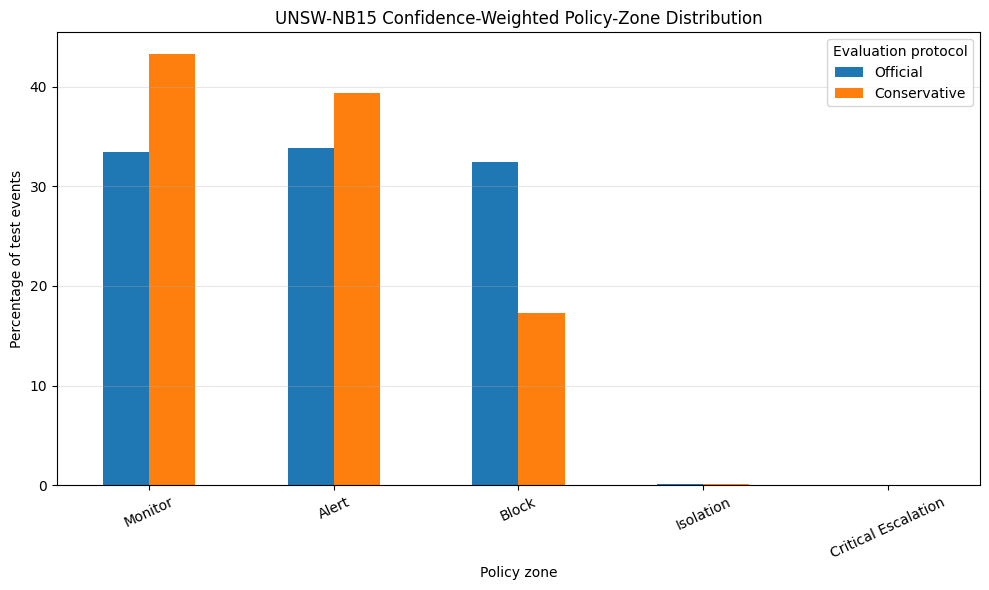

Saved 600-DPI figure:
/content/drive/MyDrive/UNSW_NB15_Project/results/10_figures/unsw_nb15_policy_zone_distribution.png


In [ ]:
# ============================================================
# PART 32 — Policy-zone distribution comparison
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


official_zones = (
    official_stage_policy_results[
        "zone_distribution"
    ]
    .set_index("policy_zone")
    .reindex(POLICY_ZONE_ORDER)
)

conservative_zones = (
    conservative_stage_policy_results[
        "zone_distribution"
    ]
    .set_index("policy_zone")
    .reindex(POLICY_ZONE_ORDER)
)

zone_figure_table = pd.DataFrame({
    "Official": (
        official_zones["percentage"]
    ),
    "Conservative": (
        conservative_zones["percentage"]
    ),
})

zone_figure_path = (
    OUTPUT_DIRS["figures"]
    / "unsw_nb15_policy_zone_distribution.png"
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

zone_figure_table.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel(
    "Policy zone"
)

ax.set_ylabel(
    "Percentage of test events"
)

ax.set_title(
    "UNSW-NB15 Confidence-Weighted Policy-Zone Distribution"
)

ax.tick_params(
    axis="x",
    rotation=25
)

ax.legend(
    title="Evaluation protocol"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    zone_figure_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved 600-DPI figure:")
print(zone_figure_path)

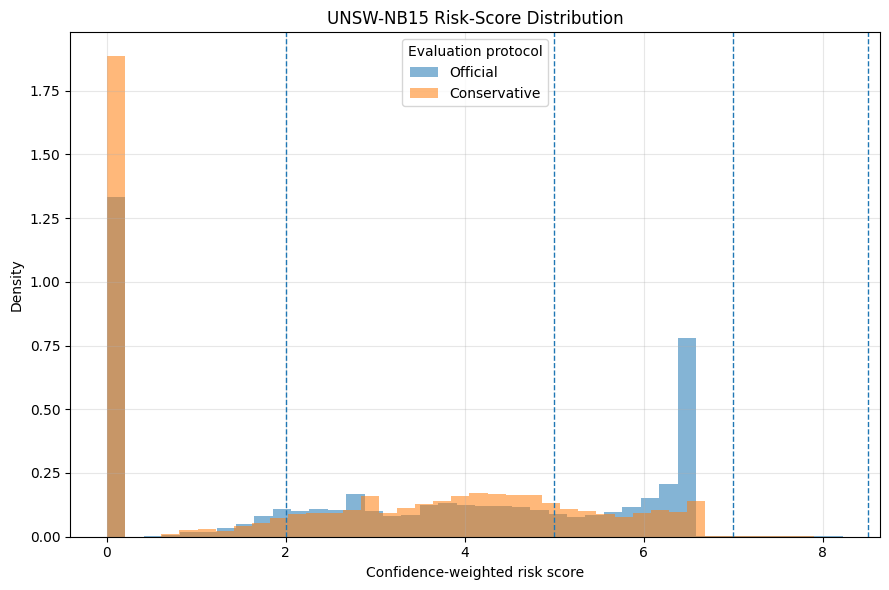

Saved 600-DPI figure:
/content/drive/MyDrive/UNSW_NB15_Project/results/10_figures/unsw_nb15_risk_score_distribution.png


In [ ]:
# ============================================================
# PART 33 — Risk-score distribution comparison
# ============================================================

import matplotlib.pyplot as plt


risk_figure_path = (
    OUTPUT_DIRS["figures"]
    / "unsw_nb15_risk_score_distribution.png"
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.hist(
    official_policy_events[
        "risk_score"
    ],
    bins=40,
    density=True,
    alpha=0.55,
    label="Official"
)

ax.hist(
    conservative_policy_events[
        "risk_score"
    ],
    bins=40,
    density=True,
    alpha=0.55,
    label="Conservative"
)

for boundary in [
    2.0,
    5.0,
    7.0,
    8.5,
]:
    ax.axvline(
        boundary,
        linestyle="--",
        linewidth=1
    )

ax.set_xlabel(
    "Confidence-weighted risk score"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "UNSW-NB15 Risk-Score Distribution"
)

ax.legend(
    title="Evaluation protocol"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    risk_figure_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved 600-DPI figure:")
print(risk_figure_path)

In [ ]:
# ============================================================
# PART 34 — Construct reporting and SHAP evaluation subsets
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


SEED = 42

CANONICAL_CLASSES = [
    "Analysis",
    "Backdoor",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Normal",
    "Reconnaissance",
    "Shellcode",
    "Worms",
]

# ------------------------------------------------------------
# 1. Define paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

POLICY_DIR = RESULTS_DIR / "11_policy_risk"

EVIDENCE_DIR = (
    RESULTS_DIR /
    "07_evidence_bundles"
)

SUBSET_DIR = (
    EVIDENCE_DIR /
    "00_reporting_subsets"
)

SUBSET_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OFFICIAL_POLICY_EVENTS_PATH = (
    POLICY_DIR /
    "official_event_policy_decisions.csv"
)

if not OFFICIAL_POLICY_EVENTS_PATH.exists():
    raise FileNotFoundError(
        "Official event-policy file was not found:\n"
        f"{OFFICIAL_POLICY_EVENTS_PATH}"
    )

# ------------------------------------------------------------
# 2. Load the official event-policy table
# ------------------------------------------------------------

official_events = pd.read_csv(
    OFFICIAL_POLICY_EVENTS_PATH,
    low_memory=False
)

if len(official_events) != 82332:
    raise ValueError(
        "Expected 82,332 official test events, "
        f"but found {len(official_events):,}."
    )

required_columns = {
    "evidence_event_id",
    "true_label",
    "predicted_label",
    "classification_correct",
    "prediction_confidence",
    "predicted_stage",
    "risk_score",
    "policy_zone",
    "recommended_action",
    "human_review_required",
}

missing_columns = (
    required_columns -
    set(official_events.columns)
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        f"{sorted(missing_columns)}"
    )

# The CSV retains the original test-set row order.
official_events[
    "test_row_index"
] = np.arange(
    len(official_events),
    dtype=np.int64
)

# ------------------------------------------------------------
# 3. Normalize Boolean fields after CSV loading
# ------------------------------------------------------------

def normalize_boolean_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    converted = normalized.map(mapping)

    if converted.isna().any():
        invalid_values = sorted(
            normalized[
                converted.isna()
            ].unique().tolist()
        )

        raise ValueError(
            "Could not interpret Boolean values: "
            f"{invalid_values}"
        )

    return converted.astype(bool)


official_events[
    "classification_correct"
] = normalize_boolean_series(
    official_events[
        "classification_correct"
    ]
)

official_events[
    "human_review_required"
] = normalize_boolean_series(
    official_events[
        "human_review_required"
    ]
)

official_events[
    "prediction_confidence"
] = pd.to_numeric(
    official_events[
        "prediction_confidence"
    ],
    errors="raise"
)

# ------------------------------------------------------------
# 4. Deterministic sampling helper
# ------------------------------------------------------------

def deterministic_sample(
    dataframe,
    sample_size,
    random_seed
):
    sample_size = min(
        int(sample_size),
        len(dataframe)
    )

    if sample_size <= 0:
        return dataframe.iloc[0:0].copy()

    return dataframe.sample(
        n=sample_size,
        random_state=random_seed,
        replace=False
    ).copy()


# ------------------------------------------------------------
# 5. Natural-distribution subset
# ------------------------------------------------------------

natural_subset = deterministic_sample(
    official_events,
    sample_size=300,
    random_seed=SEED
)

natural_subset[
    "reporting_subset"
] = "natural_300"

# ------------------------------------------------------------
# 6. Class-balanced, correctness-aware subset
# Up to 30 per class:
# target approximately 15 correct + 15 incorrect.
# ------------------------------------------------------------

balanced_parts = []

for class_index, class_name in enumerate(
    CANONICAL_CLASSES
):
    class_events = official_events[
        official_events[
            "true_label"
        ] == class_name
    ].copy()

    correct_pool = class_events[
        class_events[
            "classification_correct"
        ]
    ]

    incorrect_pool = class_events[
        ~class_events[
            "classification_correct"
        ]
    ]

    selected_correct = deterministic_sample(
        correct_pool,
        sample_size=15,
        random_seed=SEED + class_index
    )

    selected_incorrect = deterministic_sample(
        incorrect_pool,
        sample_size=15,
        random_seed=SEED + 100 + class_index
    )

    selected = pd.concat(
        [
            selected_correct,
            selected_incorrect
        ],
        ignore_index=False
    )

    selected_indices = set(
        selected.index.tolist()
    )

    remaining_needed = (
        30 - len(selected)
    )

    if remaining_needed > 0:
        remaining_pool = class_events[
            ~class_events.index.isin(
                selected_indices
            )
        ]

        filler = deterministic_sample(
            remaining_pool,
            sample_size=remaining_needed,
            random_seed=SEED + 200 + class_index
        )

        selected = pd.concat(
            [
                selected,
                filler
            ],
            ignore_index=False
        )

    selected[
        "reporting_subset"
    ] = "class_balanced"

    balanced_parts.append(
        selected
    )

class_balanced_subset = pd.concat(
    balanced_parts,
    ignore_index=False
)

# ------------------------------------------------------------
# 7. Misclassification-enriched subset
# Up to 20 errors per true class:
# half lowest-confidence and half highest-confidence.
# ------------------------------------------------------------

misclassification_parts = []

for class_name in CANONICAL_CLASSES:
    class_errors = official_events[
        (
            official_events[
                "true_label"
            ] == class_name
        )
        &
        (
            ~official_events[
                "classification_correct"
            ]
        )
    ].sort_values(
        "prediction_confidence",
        ascending=True
    )

    target_count = min(
        20,
        len(class_errors)
    )

    low_count = (
        target_count + 1
    ) // 2

    high_count = (
        target_count -
        low_count
    )

    low_confidence_errors = (
        class_errors.head(
            low_count
        )
    )

    remaining_errors = class_errors[
        ~class_errors.index.isin(
            low_confidence_errors.index
        )
    ]

    high_confidence_errors = (
        remaining_errors.tail(
            high_count
        )
    )

    selected_errors = pd.concat(
        [
            low_confidence_errors,
            high_confidence_errors
        ],
        ignore_index=False
    )

    selected_errors[
        "reporting_subset"
    ] = "misclassification_enriched"

    misclassification_parts.append(
        selected_errors
    )

misclassification_subset = pd.concat(
    misclassification_parts,
    ignore_index=False
)

# ------------------------------------------------------------
# 8. Low-confidence subset
# Up to 20 events per true class below 0.70 confidence.
# ------------------------------------------------------------

low_confidence_parts = []

for class_index, class_name in enumerate(
    CANONICAL_CLASSES
):
    low_confidence_pool = official_events[
        (
            official_events[
                "true_label"
            ] == class_name
        )
        &
        (
            official_events[
                "prediction_confidence"
            ] < 0.70
        )
    ]

    selected_low_confidence = deterministic_sample(
        low_confidence_pool,
        sample_size=20,
        random_seed=SEED + 300 + class_index
    )

    selected_low_confidence[
        "reporting_subset"
    ] = "low_confidence"

    low_confidence_parts.append(
        selected_low_confidence
    )

low_confidence_subset = pd.concat(
    low_confidence_parts,
    ignore_index=False
)

# ------------------------------------------------------------
# 9. High-confidence errors
# Up to 10 per true class at confidence >= 0.90.
# ------------------------------------------------------------

high_confidence_error_parts = []

for class_index, class_name in enumerate(
    CANONICAL_CLASSES
):
    high_confidence_error_pool = official_events[
        (
            official_events[
                "true_label"
            ] == class_name
        )
        &
        (
            ~official_events[
                "classification_correct"
            ]
        )
        &
        (
            official_events[
                "prediction_confidence"
            ] >= 0.90
        )
    ]

    selected_high_confidence_errors = (
        deterministic_sample(
            high_confidence_error_pool,
            sample_size=10,
            random_seed=SEED + 400 + class_index
        )
    )

    selected_high_confidence_errors[
        "reporting_subset"
    ] = "high_confidence_errors"

    high_confidence_error_parts.append(
        selected_high_confidence_errors
    )

high_confidence_error_subset = pd.concat(
    high_confidence_error_parts,
    ignore_index=False
)

# ------------------------------------------------------------
# 10. Save individual subsets
# ------------------------------------------------------------

subset_tables = {
    "natural_300": natural_subset,
    "class_balanced": class_balanced_subset,
    "misclassification_enriched":
        misclassification_subset,
    "low_confidence":
        low_confidence_subset,
    "high_confidence_errors":
        high_confidence_error_subset,
}

for subset_name, subset_table in (
    subset_tables.items()
):
    subset_path = (
        SUBSET_DIR /
        f"{subset_name}.csv"
    )

    subset_table.to_csv(
        subset_path,
        index=False
    )

# ------------------------------------------------------------
# 11. Create a deduplicated union for one-time SHAP processing
# ------------------------------------------------------------

membership_map = {}

for subset_name, subset_table in (
    subset_tables.items()
):
    for row_index in subset_table[
        "test_row_index"
    ].astype(int):
        membership_map.setdefault(
            row_index,
            []
        ).append(
            subset_name
        )

union_indices = sorted(
    membership_map.keys()
)

reporting_union = official_events.iloc[
    union_indices
].copy()

reporting_union[
    "subset_membership"
] = reporting_union[
    "test_row_index"
].map(
    lambda row_index: "|".join(
        sorted(
            membership_map[
                int(row_index)
            ]
        )
    )
)

reporting_union_path = (
    SUBSET_DIR /
    "reporting_union_for_shap.csv"
)

reporting_union.to_csv(
    reporting_union_path,
    index=False
)

print(
    "✅ Reporting subsets and SHAP union created."
)

print(
    "Unique events requiring SHAP:",
    f"{len(reporting_union):,}"
)

print("\nSaved to:")
print(SUBSET_DIR)

✅ Reporting subsets and SHAP union created.
Unique events requiring SHAP: 967

Saved to:
/content/drive/MyDrive/UNSW_NB15_Project/results/07_evidence_bundles/00_reporting_subsets


In [ ]:
# ============================================================
# PART 35 — Audit reporting-subset composition
# ============================================================

import pandas as pd


summary_rows = []

for subset_name, subset_table in (
    subset_tables.items()
):
    for class_name in CANONICAL_CLASSES:
        class_rows = subset_table[
            subset_table[
                "true_label"
            ] == class_name
        ]

        summary_rows.append({
            "subset": subset_name,
            "true_label": class_name,
            "events": int(
                len(class_rows)
            ),
            "correct_events": int(
                class_rows[
                    "classification_correct"
                ].sum()
            ),
            "incorrect_events": int(
                (
                    ~class_rows[
                        "classification_correct"
                    ]
                ).sum()
            ),
            "review_required_events": int(
                class_rows[
                    "human_review_required"
                ].sum()
            ),
            "mean_confidence": (
                float(
                    class_rows[
                        "prediction_confidence"
                    ].mean()
                )
                if len(class_rows) > 0
                else float("nan")
            ),
        })

reporting_subset_summary = pd.DataFrame(
    summary_rows
)

summary_path = (
    SUBSET_DIR /
    "reporting_subset_summary.csv"
)

reporting_subset_summary.to_csv(
    summary_path,
    index=False
)

overall_rows = []

for subset_name, subset_table in (
    subset_tables.items()
):
    overall_rows.append({
        "subset": subset_name,
        "events": int(
            len(subset_table)
        ),
        "correct_events": int(
            subset_table[
                "classification_correct"
            ].sum()
        ),
        "incorrect_events": int(
            (
                ~subset_table[
                    "classification_correct"
                ]
            ).sum()
        ),
        "review_required_events": int(
            subset_table[
                "human_review_required"
            ].sum()
        ),
        "mean_confidence": float(
            subset_table[
                "prediction_confidence"
            ].mean()
        ),
        "unique_true_classes": int(
            subset_table[
                "true_label"
            ].nunique()
        ),
        "unique_predicted_classes": int(
            subset_table[
                "predicted_label"
            ].nunique()
        ),
    })

overall_summary = pd.DataFrame(
    overall_rows
)

overall_summary_path = (
    SUBSET_DIR /
    "reporting_subset_overall_summary.csv"
)

overall_summary.to_csv(
    overall_summary_path,
    index=False
)

print("REPORTING SUBSET OVERALL SUMMARY")
print(
    overall_summary.to_string(
        index=False
    )
)

print("\nCLASS-BALANCED SUBSET COMPOSITION")

print(
    reporting_subset_summary[
        reporting_subset_summary[
            "subset"
        ] == "class_balanced"
    ][
        [
            "true_label",
            "events",
            "correct_events",
            "incorrect_events",
            "review_required_events",
            "mean_confidence",
        ]
    ].to_string(
        index=False
    )
)

print("\nMISCLASSIFICATION-ENRICHED COMPOSITION")

print(
    reporting_subset_summary[
        reporting_subset_summary[
            "subset"
        ] == "misclassification_enriched"
    ][
        [
            "true_label",
            "events",
            "incorrect_events",
            "review_required_events",
            "mean_confidence",
        ]
    ].to_string(
        index=False
    )
)

print(
    "\nUnique union events requiring one-time SHAP:",
    len(reporting_union)
)

print("\nSaved:")
print(summary_path)
print(overall_summary_path)
print(reporting_union_path)

print(
    "\n✅ Reporting-subset audit completed."
)

REPORTING SUBSET OVERALL SUMMARY
                    subset  events  correct_events  incorrect_events  review_required_events  mean_confidence  unique_true_classes  unique_predicted_classes
               natural_300     300             197               103                     101         0.789690                    8                         9
            class_balanced     300             150               150                     219         0.525771                   10                        10
misclassification_enriched     200               0               200                     131         0.508983                   10                        10
            low_confidence     200              67               133                     200         0.444741                   10                        10
    high_confidence_errors      31               0                31                       0         0.933454                    6                         5

CLASS-BALANCED SUBSET CO

In [ ]:
# ============================================================
# PART 36 — Load official Random Forest and SHAP union
# ============================================================

from pathlib import Path
import json
import platform
import subprocess
import sys

import joblib
import numpy as np
import pandas as pd
import sklearn

# ------------------------------------------------------------
# 1. Mount Drive and reconstruct paths
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive")

if not DRIVE_ROOT.exists():
    from google.colab import drive
    drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

MODEL_DIR = (
    RESULTS_DIR /
    "03_models" /
    "official_random_forest"
)

PROCESSED_DIR = (
    RESULTS_DIR /
    "02_preprocessing" /
    "processed_protocols" /
    "official"
)

CLASSIFICATION_DIR = (
    RESULTS_DIR /
    "04_classification" /
    "official_random_forest"
)

SUBSET_DIR = (
    RESULTS_DIR /
    "07_evidence_bundles" /
    "00_reporting_subsets"
)

SHAP_DIR = (
    RESULTS_DIR /
    "06_shap" /
    "official_reporting_union"
)

FIGURE_DIR = RESULTS_DIR / "10_figures"

SHAP_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Import SHAP
# ------------------------------------------------------------

try:
    import shap
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "shap==0.46.0"
    ])

    import shap

# ------------------------------------------------------------
# 3. Define input paths
# ------------------------------------------------------------

MODEL_PATH = (
    MODEL_DIR /
    "unsw_nb15_official_random_forest.joblib"
)

X_TEST_PATH = (
    PROCESSED_DIR /
    "X_test_float32.npy"
)

Y_PROBA_PATH = (
    CLASSIFICATION_DIR /
    "y_proba_float32.npy"
)

FEATURE_NAMES_PATH = (
    PROCESSED_DIR /
    "transformed_feature_names.csv"
)

REPORTING_UNION_PATH = (
    SUBSET_DIR /
    "reporting_union_for_shap.csv"
)

required_paths = [
    MODEL_PATH,
    X_TEST_PATH,
    Y_PROBA_PATH,
    FEATURE_NAMES_PATH,
    REPORTING_UNION_PATH,
]

missing_paths = [
    str(path)
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required SHAP files:\n"
        + "\n".join(missing_paths)
    )

# ------------------------------------------------------------
# 4. Load model, matrix and subset
# ------------------------------------------------------------

official_rf_model = joblib.load(
    MODEL_PATH
)

X_test_shap_source = np.load(
    X_TEST_PATH,
    mmap_mode="r"
)

y_proba_shap_source = np.load(
    Y_PROBA_PATH,
    mmap_mode="r"
)

transformed_feature_table = pd.read_csv(
    FEATURE_NAMES_PATH
)

transformed_feature_names = (
    transformed_feature_table[
        "transformed_feature_name"
    ]
    .astype(str)
    .tolist()
)

reporting_union = pd.read_csv(
    REPORTING_UNION_PATH,
    low_memory=False
)

# ------------------------------------------------------------
# 5. Validate test indices and predicted classes
# ------------------------------------------------------------

CANONICAL_CLASSES = [
    "Analysis",
    "Backdoor",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Normal",
    "Reconnaissance",
    "Shellcode",
    "Worms",
]

CLASS_TO_ID = {
    class_name: class_id
    for class_id, class_name in enumerate(
        CANONICAL_CLASSES
    )
}

if "test_row_index" not in reporting_union.columns:
    raise ValueError(
        "reporting_union_for_shap.csv does not contain "
        "test_row_index."
    )

test_row_indices = pd.to_numeric(
    reporting_union["test_row_index"],
    errors="raise"
).to_numpy(dtype=np.int64)

if test_row_indices.min() < 0:
    raise ValueError("Negative test-row index detected.")

if test_row_indices.max() >= len(X_test_shap_source):
    raise ValueError(
        "A reporting-union index exceeds the test matrix."
    )

if reporting_union["test_row_index"].duplicated().any():
    raise ValueError(
        "The SHAP union contains duplicate test-row indices."
    )

if "predicted_class_id" in reporting_union.columns:
    predicted_class_ids = pd.to_numeric(
        reporting_union["predicted_class_id"],
        errors="raise"
    ).to_numpy(dtype=np.int64)
else:
    predicted_class_ids = (
        reporting_union["predicted_label"]
        .map(CLASS_TO_ID)
        .to_numpy(dtype=np.int64)
    )

if not np.isin(
    predicted_class_ids,
    np.arange(10)
).all():
    raise ValueError(
        "Invalid predicted class IDs in reporting union."
    )

assert len(transformed_feature_names) == 194
assert X_test_shap_source.shape == (82332, 194)
assert y_proba_shap_source.shape == (82332, 10)
assert len(reporting_union) == 967

print("SHAP version             :", shap.__version__)
print("Scikit-learn version     :", sklearn.__version__)
print("Official test matrix     :", X_test_shap_source.shape)
print("Reporting-union events   :", len(reporting_union))
print("Transformed features     :", len(transformed_feature_names))
print("Predicted classes present:", sorted(
    np.unique(predicted_class_ids).tolist()
))

print("\n✅ SHAP inputs loaded and validated.")

SHAP version             : 0.52.0
Scikit-learn version     : 1.6.1
Official test matrix     : (82332, 194)
Reporting-union events   : 967
Transformed features     : 194
Predicted classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

✅ SHAP inputs loaded and validated.


In [ ]:
# ============================================================
# PART 37 — Compute predicted-class TreeSHAP values
# ============================================================

import json
import time

import numpy as np
import pandas as pd


BATCH_SIZE = 64

SHAP_MATRIX_PATH = (
    SHAP_DIR /
    "predicted_class_shap_values_float32.npy"
)

EXPECTED_VALUE_PATH = (
    SHAP_DIR /
    "predicted_class_expected_values_float32.npy"
)

CHECKPOINT_PATH = (
    SHAP_DIR /
    "shap_computation_checkpoint.json"
)

SHAP_AUDIT_PATH = (
    SHAP_DIR /
    "shap_additivity_audit.csv"
)

SHAP_CONFIG_PATH = (
    SHAP_DIR /
    "shap_computation_config.json"
)

# ------------------------------------------------------------
# 1. SHAP output-normalization helpers
# ------------------------------------------------------------

def normalize_multiclass_shap_output(
    raw_shap_output,
    batch_rows,
    feature_count,
    class_count
):
    """
    Convert SHAP output into:
        (batch_rows, feature_count, class_count)

    Supports both older list output and newer ndarray output.
    """

    if isinstance(raw_shap_output, list):
        if len(raw_shap_output) != class_count:
            raise ValueError(
                "Unexpected number of class-specific "
                "SHAP arrays."
            )

        normalized = np.stack(
            raw_shap_output,
            axis=-1
        )

    else:
        normalized = np.asarray(
            raw_shap_output
        )

        if normalized.ndim != 3:
            raise ValueError(
                "Expected a three-dimensional multiclass "
                f"SHAP array, received shape {normalized.shape}."
            )

        if normalized.shape == (
            batch_rows,
            feature_count,
            class_count
        ):
            pass

        elif normalized.shape == (
            batch_rows,
            class_count,
            feature_count
        ):
            normalized = np.transpose(
                normalized,
                (0, 2, 1)
            )

        elif normalized.shape == (
            class_count,
            batch_rows,
            feature_count
        ):
            normalized = np.transpose(
                normalized,
                (1, 2, 0)
            )

        else:
            raise ValueError(
                "Unsupported SHAP output shape: "
                f"{normalized.shape}"
            )

    expected_shape = (
        batch_rows,
        feature_count,
        class_count
    )

    if normalized.shape != expected_shape:
        raise ValueError(
            f"Normalized SHAP shape {normalized.shape} "
            f"does not equal {expected_shape}."
        )

    return normalized


def normalize_expected_values(
    expected_value,
    class_count
):
    values = np.asarray(
        expected_value,
        dtype=np.float64
    ).reshape(-1)

    if len(values) == 1:
        values = np.repeat(
            values,
            class_count
        )

    if len(values) != class_count:
        raise ValueError(
            "Unexpected TreeExplainer expected-value shape: "
            f"{values.shape}"
        )

    return values


# ------------------------------------------------------------
# 2. Initialize TreeExplainer
# ------------------------------------------------------------

explainer = shap.TreeExplainer(
    official_rf_model
)

class_expected_values = (
    normalize_expected_values(
        explainer.expected_value,
        class_count=10
    )
)

print("Class expected values:")
print(class_expected_values)

# ------------------------------------------------------------
# 3. Initialize or resume output arrays
# ------------------------------------------------------------

total_events = len(reporting_union)
feature_count = len(transformed_feature_names)

if SHAP_MATRIX_PATH.exists():
    selected_shap_matrix = np.lib.format.open_memmap(
        SHAP_MATRIX_PATH,
        mode="r+"
    )
else:
    selected_shap_matrix = np.lib.format.open_memmap(
        SHAP_MATRIX_PATH,
        mode="w+",
        dtype=np.float32,
        shape=(
            total_events,
            feature_count
        )
    )

if EXPECTED_VALUE_PATH.exists():
    selected_expected_values = np.lib.format.open_memmap(
        EXPECTED_VALUE_PATH,
        mode="r+"
    )
else:
    selected_expected_values = np.lib.format.open_memmap(
        EXPECTED_VALUE_PATH,
        mode="w+",
        dtype=np.float32,
        shape=(total_events,)
    )

completed_events = 0

if CHECKPOINT_PATH.exists():
    with open(
        CHECKPOINT_PATH,
        "r",
        encoding="utf-8"
    ) as checkpoint_file:
        checkpoint = json.load(
            checkpoint_file
        )

    completed_events = int(
        checkpoint.get(
            "completed_events",
            0
        )
    )

    completed_events = min(
        completed_events,
        total_events
    )

print(
    f"Starting SHAP computation at event "
    f"{completed_events:,} of {total_events:,}."
)

# ------------------------------------------------------------
# 4. Compute SHAP in restart-safe batches
# ------------------------------------------------------------

computation_start = time.perf_counter()

for start_index in range(
    completed_events,
    total_events,
    BATCH_SIZE
):
    end_index = min(
        start_index + BATCH_SIZE,
        total_events
    )

    batch_test_indices = test_row_indices[
        start_index:end_index
    ]

    batch_class_ids = predicted_class_ids[
        start_index:end_index
    ]

    X_batch = np.asarray(
        X_test_shap_source[
            batch_test_indices
        ],
        dtype=np.float32
    )

    raw_batch_shap = explainer.shap_values(
        X_batch,
        check_additivity=False
    )

    normalized_batch_shap = (
        normalize_multiclass_shap_output(
            raw_shap_output=raw_batch_shap,
            batch_rows=len(X_batch),
            feature_count=feature_count,
            class_count=10
        )
    )

    row_positions = np.arange(
        len(X_batch)
    )

    predicted_class_batch_shap = (
        normalized_batch_shap[
            row_positions,
            :,
            batch_class_ids
        ]
    )

    selected_shap_matrix[
        start_index:end_index
    ] = predicted_class_batch_shap.astype(
        np.float32
    )

    selected_expected_values[
        start_index:end_index
    ] = class_expected_values[
        batch_class_ids
    ].astype(np.float32)

    selected_shap_matrix.flush()
    selected_expected_values.flush()

    checkpoint = {
        "completed_events": int(
            end_index
        ),
        "total_events": int(
            total_events
        ),
        "batch_size": int(
            BATCH_SIZE
        ),
    }

    with open(
        CHECKPOINT_PATH,
        "w",
        encoding="utf-8"
    ) as checkpoint_file:
        json.dump(
            checkpoint,
            checkpoint_file,
            indent=2
        )

    print(
        f"Completed {end_index:,}/{total_events:,} events."
    )

computation_seconds = (
    time.perf_counter()
    - computation_start
)

# ------------------------------------------------------------
# 5. Additivity audit
# ------------------------------------------------------------

selected_shap_values = np.load(
    SHAP_MATRIX_PATH,
    mmap_mode="r"
)

selected_base_values = np.load(
    EXPECTED_VALUE_PATH,
    mmap_mode="r"
)

model_predicted_probabilities = (
    y_proba_shap_source[
        test_row_indices,
        predicted_class_ids
    ]
)

reconstructed_outputs = (
    selected_base_values.astype(
        np.float64
    )
    +
    selected_shap_values.astype(
        np.float64
    ).sum(axis=1)
)

absolute_additivity_error = np.abs(
    reconstructed_outputs
    - model_predicted_probabilities
)

additivity_audit = pd.DataFrame({
    "evidence_event_id":
        reporting_union["evidence_event_id"],
    "test_row_index":
        test_row_indices,
    "predicted_class_id":
        predicted_class_ids,
    "model_predicted_probability":
        model_predicted_probabilities,
    "shap_reconstructed_output":
        reconstructed_outputs,
    "absolute_additivity_error":
        absolute_additivity_error,
})

additivity_audit.to_csv(
    SHAP_AUDIT_PATH,
    index=False
)

shap_configuration = {
    "dataset": "UNSW-NB15",
    "protocol": "Protocol A — Official",
    "model": "Random Forest",
    "events": int(total_events),
    "features": int(feature_count),
    "classes": 10,
    "shap_library_version": shap.__version__,
    "scikit_learn_version": sklearn.__version__,
    "explainer": "shap.TreeExplainer",
    "explained_output": (
        "SHAP values for each event's predicted class"
    ),
    "batch_size": int(BATCH_SIZE),
    "computation_seconds_this_run": float(
        computation_seconds
    ),
    "mean_absolute_additivity_error": float(
        absolute_additivity_error.mean()
    ),
    "maximum_absolute_additivity_error": float(
        absolute_additivity_error.max()
    ),
    "events_above_1e_5_additivity_error": int(
        (
            absolute_additivity_error
            > 1e-5
        ).sum()
    ),
}

with open(
    SHAP_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        shap_configuration,
        configuration_file,
        indent=2,
        ensure_ascii=False
    )

print("\nSHAP COMPUTATION SUMMARY")
print("Events processed          :", total_events)
print("Features per event        :", feature_count)
print(
    "Mean additivity error     :",
    f"{absolute_additivity_error.mean():.10f}"
)
print(
    "Maximum additivity error  :",
    f"{absolute_additivity_error.max():.10f}"
)
print(
    "Computation time this run :",
    f"{computation_seconds:.2f} seconds"
)

print("\nSaved:")
print(SHAP_MATRIX_PATH)
print(EXPECTED_VALUE_PATH)
print(SHAP_AUDIT_PATH)
print(SHAP_CONFIG_PATH)

print("\n✅ Predicted-class TreeSHAP completed.")

Class expected values:
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Starting SHAP computation at event 0 of 967.
Completed 64/967 events.
Completed 128/967 events.
Completed 192/967 events.
Completed 256/967 events.
Completed 320/967 events.
Completed 384/967 events.
Completed 448/967 events.
Completed 512/967 events.
Completed 576/967 events.
Completed 640/967 events.
Completed 704/967 events.
Completed 768/967 events.
Completed 832/967 events.
Completed 896/967 events.
Completed 960/967 events.
Completed 967/967 events.

SHAP COMPUTATION SUMMARY
Events processed          : 967
Features per event        : 194
Mean additivity error     : 0.0000000099
Maximum additivity error  : 0.0000000402
Computation time this run : 1257.08 seconds

Saved:
/content/drive/MyDrive/UNSW_NB15_Project/results/06_shap/official_reporting_union/predicted_class_shap_values_float32.npy
/content/drive/MyDrive/UNSW_NB15_Project/results/06_shap/official_reporting_union/predicted_class_expected_values_float32.npy
/co

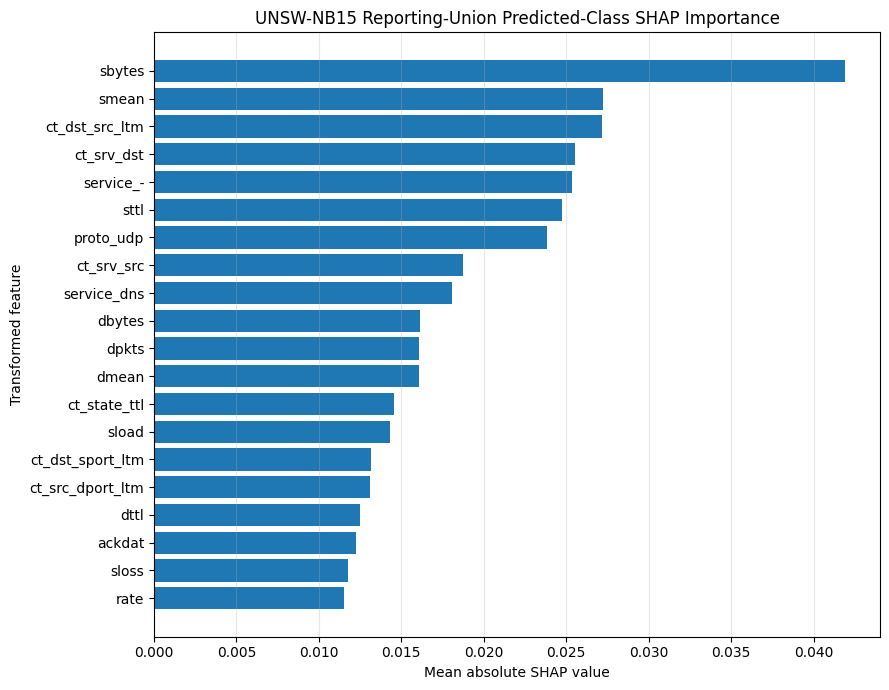

TREE-SHAP EVIDENCE SUMMARY
{
  "dataset": "UNSW-NB15",
  "protocol": "Protocol A \u2014 Official",
  "unique_events": 967,
  "top_features_per_event": 5,
  "expected_evidence_rows": 4835,
  "actual_evidence_rows": 4835,
  "supporting_evidence_rows": 4547,
  "opposing_evidence_rows": 288,
  "neutral_evidence_rows": 0,
  "unique_transformed_features_in_top5": 63,
  "all_events_have_exactly_five_features": true
}

TOP 20 REPORTING-UNION FEATURES
 importance_rank transformed_feature_name  mean_absolute_predicted_class_shap
               1                   sbytes                            0.041933
               2                    smean                            0.027204
               3           ct_dst_src_ltm                            0.027146
               4               ct_srv_dst                            0.025517
               5                service_-                            0.025367
               6                     sttl                            0.024773
       

In [ ]:
# ============================================================
# PART 38 — Extract top-five local SHAP evidence
# ============================================================

import json

import numpy as np
import pandas as pd


TOP_K = 5

TOP5_LONG_PATH = (
    SHAP_DIR /
    "reporting_union_top5_shap_long.csv"
)

TOP5_WIDE_PATH = (
    SHAP_DIR /
    "reporting_union_top5_shap_wide.csv"
)

SHAP_SUMMARY_PATH = (
    SHAP_DIR /
    "reporting_union_shap_summary.json"
)

GLOBAL_IMPORTANCE_PATH = (
    SHAP_DIR /
    "reporting_union_predicted_class_shap_importance.csv"
)

GLOBAL_FIGURE_PATH = (
    FIGURE_DIR /
    "unsw_nb15_reporting_union_shap_importance.png"
)

selected_shap_values = np.load(
    SHAP_MATRIX_PATH,
    mmap_mode="r"
)

# ------------------------------------------------------------
# 1. Human-readable transformed feature descriptions
# ------------------------------------------------------------

def describe_transformed_feature(
    feature_name,
    observed_value
):
    if feature_name.startswith("proto_"):
        category = feature_name[
            len("proto_"):
        ]

        if observed_value >= 0.5:
            return f"Protocol = {category}"

        return f"Protocol is not {category}"

    if feature_name.startswith("service_"):
        category = feature_name[
            len("service_"):
        ]

        if observed_value >= 0.5:
            return f"Service = {category}"

        return f"Service is not {category}"

    if feature_name.startswith("state_"):
        category = feature_name[
            len("state_"):
        ]

        if observed_value >= 0.5:
            return f"Connection state = {category}"

        return f"Connection state is not {category}"

    return (
        f"{feature_name} = "
        f"{float(observed_value):.6g}"
    )


def shap_direction(shap_value):
    if shap_value > 0:
        return "supports predicted class"

    if shap_value < 0:
        return "opposes predicted class"

    return "neutral"


# ------------------------------------------------------------
# 2. Extract top-five features per event
# ------------------------------------------------------------

long_rows = []
wide_rows = []

for union_position in range(
    len(reporting_union)
):
    test_row_index = int(
        test_row_indices[
            union_position
        ]
    )

    event_shap = np.asarray(
        selected_shap_values[
            union_position
        ],
        dtype=np.float64
    )

    event_features = np.asarray(
        X_test_shap_source[
            test_row_index
        ],
        dtype=np.float32
    )

    top_feature_indices = np.argsort(
        np.abs(event_shap)
    )[
        -TOP_K:
    ][::-1]

    base_event = reporting_union.iloc[
        union_position
    ]

    wide_record = {
        "evidence_event_id":
            base_event["evidence_event_id"],
        "test_row_index":
            test_row_index,
        "true_label_evaluation_only":
            base_event["true_label"],
        "predicted_label":
            base_event["predicted_label"],
        "classification_correct":
            base_event["classification_correct"],
        "prediction_confidence":
            base_event["prediction_confidence"],
        "predicted_stage":
            base_event["predicted_stage"],
        "risk_score":
            base_event["risk_score"],
        "policy_zone":
            base_event["policy_zone"],
        "human_review_required":
            base_event["human_review_required"],
        "subset_membership":
            base_event["subset_membership"],
    }

    for rank, feature_index in enumerate(
        top_feature_indices,
        start=1
    ):
        feature_name = transformed_feature_names[
            feature_index
        ]

        observed_value = float(
            event_features[
                feature_index
            ]
        )

        shap_value = float(
            event_shap[
                feature_index
            ]
        )

        absolute_shap_value = abs(
            shap_value
        )

        direction = shap_direction(
            shap_value
        )

        feature_description = (
            describe_transformed_feature(
                feature_name,
                observed_value
            )
        )

        long_rows.append({
            "evidence_event_id":
                base_event["evidence_event_id"],
            "test_row_index":
                test_row_index,
            "true_label_evaluation_only":
                base_event["true_label"],
            "predicted_label":
                base_event["predicted_label"],
            "classification_correct":
                base_event["classification_correct"],
            "prediction_confidence":
                base_event["prediction_confidence"],
            "predicted_stage":
                base_event["predicted_stage"],
            "risk_score":
                base_event["risk_score"],
            "policy_zone":
                base_event["policy_zone"],
            "human_review_required":
                base_event["human_review_required"],
            "subset_membership":
                base_event["subset_membership"],
            "feature_rank":
                rank,
            "transformed_feature_index":
                int(feature_index),
            "transformed_feature_name":
                feature_name,
            "feature_description":
                feature_description,
            "observed_value":
                observed_value,
            "shap_value":
                shap_value,
            "absolute_shap_value":
                absolute_shap_value,
            "direction":
                direction,
        })

        wide_record[
            f"feature_{rank}_name"
        ] = feature_name

        wide_record[
            f"feature_{rank}_description"
        ] = feature_description

        wide_record[
            f"feature_{rank}_value"
        ] = observed_value

        wide_record[
            f"feature_{rank}_shap"
        ] = shap_value

        wide_record[
            f"feature_{rank}_direction"
        ] = direction

    wide_rows.append(
        wide_record
    )

top5_long = pd.DataFrame(
    long_rows
)

top5_wide = pd.DataFrame(
    wide_rows
)

top5_long.to_csv(
    TOP5_LONG_PATH,
    index=False
)

top5_wide.to_csv(
    TOP5_WIDE_PATH,
    index=False
)

# ------------------------------------------------------------
# 3. Reporting-union predicted-class SHAP importance
# ------------------------------------------------------------

mean_absolute_shap = np.asarray(
    np.abs(
        selected_shap_values
    ).mean(axis=0),
    dtype=np.float64
)

global_importance = pd.DataFrame({
    "transformed_feature_name":
        transformed_feature_names,
    "mean_absolute_predicted_class_shap":
        mean_absolute_shap,
})

global_importance = global_importance.sort_values(
    "mean_absolute_predicted_class_shap",
    ascending=False
).reset_index(drop=True)

global_importance[
    "importance_rank"
] = np.arange(
    1,
    len(global_importance) + 1
)

global_importance.to_csv(
    GLOBAL_IMPORTANCE_PATH,
    index=False
)

# ------------------------------------------------------------
# 4. Save summary
# ------------------------------------------------------------

supporting_count = int(
    (
        top5_long["shap_value"] > 0
    ).sum()
)

opposing_count = int(
    (
        top5_long["shap_value"] < 0
    ).sum()
)

neutral_count = int(
    (
        top5_long["shap_value"] == 0
    ).sum()
)

summary = {
    "dataset": "UNSW-NB15",
    "protocol": "Protocol A — Official",
    "unique_events": int(
        len(reporting_union)
    ),
    "top_features_per_event": int(
        TOP_K
    ),
    "expected_evidence_rows": int(
        len(reporting_union) * TOP_K
    ),
    "actual_evidence_rows": int(
        len(top5_long)
    ),
    "supporting_evidence_rows":
        supporting_count,
    "opposing_evidence_rows":
        opposing_count,
    "neutral_evidence_rows":
        neutral_count,
    "unique_transformed_features_in_top5":
        int(
            top5_long[
                "transformed_feature_name"
            ].nunique()
        ),
    "all_events_have_exactly_five_features":
        bool(
            top5_long.groupby(
                "evidence_event_id"
            ).size().eq(TOP_K).all()
        ),
}

with open(
    SHAP_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        summary,
        summary_file,
        indent=2,
        ensure_ascii=False
    )

# ------------------------------------------------------------
# 5. Create top-20 figure
# ------------------------------------------------------------

import matplotlib.pyplot as plt

top_twenty = (
    global_importance
    .head(20)
    .sort_values(
        "mean_absolute_predicted_class_shap",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.barh(
    top_twenty[
        "transformed_feature_name"
    ],
    top_twenty[
        "mean_absolute_predicted_class_shap"
    ]
)

ax.set_xlabel(
    "Mean absolute SHAP value"
)

ax.set_ylabel(
    "Transformed feature"
)

ax.set_title(
    "UNSW-NB15 Reporting-Union Predicted-Class SHAP Importance"
)

ax.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    GLOBAL_FIGURE_PATH,
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

# ------------------------------------------------------------
# 6. Print audit
# ------------------------------------------------------------

print("TREE-SHAP EVIDENCE SUMMARY")
print(json.dumps(
    summary,
    indent=2
))

print("\nTOP 20 REPORTING-UNION FEATURES")

print(
    global_importance[
        [
            "importance_rank",
            "transformed_feature_name",
            "mean_absolute_predicted_class_shap",
        ]
    ].head(20).to_string(
        index=False
    )
)

print("\nSAMPLE TOP-FIVE LOCAL EVIDENCE")

print(
    top5_long[
        [
            "evidence_event_id",
            "predicted_label",
            "feature_rank",
            "feature_description",
            "shap_value",
            "direction",
        ]
    ].head(15).to_string(
        index=False
    )
)

print("\nSaved:")
print(TOP5_LONG_PATH)
print(TOP5_WIDE_PATH)
print(SHAP_SUMMARY_PATH)
print(GLOBAL_IMPORTANCE_PATH)
print(GLOBAL_FIGURE_PATH)

print("\n✅ Top-five local SHAP evidence completed.")

In [ ]:
# ============================================================
# PART 39 — Construct machine-readable evidence bundles
# ============================================================

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Reconstruct project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

SHAP_DIR = (
    RESULTS_DIR
    / "06_shap"
    / "official_reporting_union"
)

POLICY_DIR = (
    RESULTS_DIR
    / "11_policy_risk"
)

SUBSET_DIR = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "00_reporting_subsets"
)

BUNDLE_DIR = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "01_machine_readable_bundles"
)

SUBSET_BUNDLE_DIR = (
    BUNDLE_DIR
    / "subsets"
)

BUNDLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SUBSET_BUNDLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. Define input paths
# ------------------------------------------------------------

TOP5_LONG_PATH = (
    SHAP_DIR
    / "reporting_union_top5_shap_long.csv"
)

OFFICIAL_POLICY_PATH = (
    POLICY_DIR
    / "official_event_policy_decisions.csv"
)

REPORTING_UNION_PATH = (
    SUBSET_DIR
    / "reporting_union_for_shap.csv"
)

required_paths = [
    TOP5_LONG_PATH,
    OFFICIAL_POLICY_PATH,
    REPORTING_UNION_PATH,
]

missing_paths = [
    str(path)
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required evidence files:\n"
        + "\n".join(missing_paths)
    )

# ------------------------------------------------------------
# 3. Load evidence sources
# ------------------------------------------------------------

top5_long = pd.read_csv(
    TOP5_LONG_PATH,
    low_memory=False
)

policy_events = pd.read_csv(
    OFFICIAL_POLICY_PATH,
    low_memory=False
)

reporting_union = pd.read_csv(
    REPORTING_UNION_PATH,
    low_memory=False
)

# ------------------------------------------------------------
# 4. Boolean-normalization helper
# ------------------------------------------------------------

def normalize_boolean(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)

    normalized = str(value).strip().lower()

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    if normalized not in mapping:
        raise ValueError(
            f"Cannot interpret Boolean value: {value}"
        )

    return mapping[normalized]


for column in [
    "classification_correct",
    "human_review_required",
]:
    top5_long[column] = (
        top5_long[column]
        .map(normalize_boolean)
    )

for column in [
    "classification_correct",
    "stage_correct",
    "human_review_required",
    "sensitivity_review_required",
]:
    if column in policy_events.columns:
        policy_events[column] = (
            policy_events[column]
            .map(normalize_boolean)
        )

# ------------------------------------------------------------
# 5. Validate source uniqueness
# ------------------------------------------------------------

if policy_events[
    "evidence_event_id"
].duplicated().any():
    raise ValueError(
        "Duplicate evidence_event_id values in policy table."
    )

if reporting_union[
    "evidence_event_id"
].duplicated().any():
    raise ValueError(
        "Duplicate evidence_event_id values in reporting union."
    )

policy_lookup = (
    policy_events
    .set_index("evidence_event_id")
)

union_lookup = (
    reporting_union
    .set_index("evidence_event_id")
)

missing_policy_events = (
    set(top5_long["evidence_event_id"])
    - set(policy_lookup.index)
)

if missing_policy_events:
    raise ValueError(
        "SHAP events missing from policy table: "
        f"{len(missing_policy_events)}"
    )

# ------------------------------------------------------------
# 6. Human-readable feature helper
# ------------------------------------------------------------

def improve_feature_description(
    feature_name,
    observed_value,
    existing_description
):
    """
    Replace technical one-hot values with clearer SOC wording
    while retaining the exact transformed feature separately.
    """

    if feature_name == "service_-":
        if float(observed_value) >= 0.5:
            return "Service = unspecified"

        return "An application service is identified"

    if feature_name == "state_no":
        if float(observed_value) >= 0.5:
            return "Connection state = unavailable"

        return "Connection state is available"

    return str(existing_description)


# ------------------------------------------------------------
# 7. JSON-safe conversion helper
# ------------------------------------------------------------

def json_safe(value):
    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        value = float(value)

    if isinstance(value, float):
        if not math.isfinite(value):
            raise ValueError(
                f"Non-finite JSON value detected: {value}"
            )

        return value

    if isinstance(value, (np.bool_,)):
        return bool(value)

    if pd.isna(value):
        return None

    return value


# ------------------------------------------------------------
# 8. Bundle constants
# ------------------------------------------------------------

SCHEMA_VERSION = "1.0"
POLICY_VERSION = "UNSW-POLICY-1.0"
MODEL_VERSION = "UNSW-RF-OFFICIAL-1.0"

PROHIBITED_CLAIM_TYPES = [
    "Unobserved IP addresses or hostnames",
    "Unobserved CVE identifiers",
    "Unobserved malware or tool names",
    "Claims that the predicted class is ground truth",
    "Unsupported causal claims",
    "Unsupported remediation steps",
]

SUBSET_NAMES = [
    "natural_300",
    "class_balanced",
    "misclassification_enriched",
    "low_confidence",
    "high_confidence_errors",
]

# ------------------------------------------------------------
# 9. Construct one bundle per event
# ------------------------------------------------------------

llm_bundles = []
evaluation_bundles = []
index_rows = []

grouped_evidence = top5_long.groupby(
    "evidence_event_id",
    sort=False
)

for evidence_event_id, feature_group in grouped_evidence:
    feature_group = feature_group.sort_values(
        "feature_rank"
    )

    if len(feature_group) != 5:
        raise ValueError(
            f"{evidence_event_id} does not have five features."
        )

    policy_row = policy_lookup.loc[
        evidence_event_id
    ]

    union_row = union_lookup.loc[
        evidence_event_id
    ]

    feature_evidence = []

    for _, feature_row in feature_group.iterrows():
        readable_description = (
            improve_feature_description(
                feature_name=feature_row[
                    "transformed_feature_name"
                ],
                observed_value=feature_row[
                    "observed_value"
                ],
                existing_description=feature_row[
                    "feature_description"
                ]
            )
        )

        feature_evidence.append({
            "rank": int(
                feature_row["feature_rank"]
            ),
            "transformed_feature_index": int(
                feature_row[
                    "transformed_feature_index"
                ]
            ),
            "transformed_feature_name": str(
                feature_row[
                    "transformed_feature_name"
                ]
            ),
            "readable_evidence": (
                readable_description
            ),
            "observed_value": json_safe(
                feature_row["observed_value"]
            ),
            "shap_value": json_safe(
                feature_row["shap_value"]
            ),
            "absolute_shap_value": json_safe(
                feature_row[
                    "absolute_shap_value"
                ]
            ),
            "direction": str(
                feature_row["direction"]
            ),
        })

    subset_membership = [
        subset_name
        for subset_name in str(
            union_row["subset_membership"]
        ).split("|")
        if subset_name
    ]

    prediction_confidence = float(
        policy_row[
            "prediction_confidence"
        ]
    )

    llm_bundle = {
        "schema_version": SCHEMA_VERSION,
        "policy_version": POLICY_VERSION,
        "dataset": "UNSW-NB15",
        "evaluation_protocol": (
            "Protocol A — Official"
        ),
        "event_id": evidence_event_id,
        "source_reference": {
            "test_row_index": int(
                union_row["test_row_index"]
            ),
            "subset_membership":
                subset_membership,
        },
        "detector_output": {
            "model_name": "Random Forest",
            "model_version": MODEL_VERSION,
            "predicted_label": str(
                policy_row["predicted_label"]
            ),
            "prediction_confidence":
                prediction_confidence,
            "uncertainty_score": float(
                1.0 - prediction_confidence
            ),
        },
        "operational_decision": {
            "predicted_stage": str(
                policy_row["predicted_stage"]
            ),
            "stage_severity": float(
                policy_row["stage_severity"]
            ),
            "asset_criticality": float(
                policy_row["asset_criticality"]
            ),
            "risk_score": float(
                policy_row["risk_score"]
            ),
            "policy_zone": str(
                policy_row["policy_zone"]
            ),
            "recommended_action": str(
                policy_row[
                    "recommended_action"
                ]
            ),
        },
        "human_review": {
            "required": bool(
                policy_row[
                    "human_review_required"
                ]
            ),
            "confidence_threshold": 0.70,
            "reason": str(
                policy_row["review_reason"]
            ),
        },
        "local_explanation": {
            "method": (
                "TreeSHAP for predicted class"
            ),
            "top_k": 5,
            "features": feature_evidence,
        },
        "grounding_contract": {
            "allowed_predicted_label": str(
                policy_row["predicted_label"]
            ),
            "allowed_stage": str(
                policy_row["predicted_stage"]
            ),
            "allowed_risk_score": float(
                policy_row["risk_score"]
            ),
            "allowed_policy_zone": str(
                policy_row["policy_zone"]
            ),
            "allowed_action": str(
                policy_row[
                    "recommended_action"
                ]
            ),
            "allowed_feature_names": [
                feature[
                    "transformed_feature_name"
                ]
                for feature in feature_evidence
            ],
            "prohibited_claim_types":
                PROHIBITED_CLAIM_TYPES,
        },
    }

    evaluation_bundle = {
        **llm_bundle,
        "evaluation_only": {
            "true_label": str(
                policy_row["true_label"]
            ),
            "classification_correct": bool(
                policy_row[
                    "classification_correct"
                ]
            ),
            "true_stage": str(
                policy_row[
                    "true_stage_evaluation_only"
                ]
            ),
            "stage_correct": bool(
                policy_row["stage_correct"]
            ),
        },
    }

    llm_bundles.append(
        llm_bundle
    )

    evaluation_bundles.append(
        evaluation_bundle
    )

    index_rows.append({
        "event_id": evidence_event_id,
        "test_row_index": int(
            union_row["test_row_index"]
        ),
        "subset_membership": "|".join(
            subset_membership
        ),
        "predicted_label": str(
            policy_row["predicted_label"]
        ),
        "prediction_confidence":
            prediction_confidence,
        "predicted_stage": str(
            policy_row["predicted_stage"]
        ),
        "risk_score": float(
            policy_row["risk_score"]
        ),
        "policy_zone": str(
            policy_row["policy_zone"]
        ),
        "human_review_required": bool(
            policy_row[
                "human_review_required"
            ]
        ),
        "true_label_evaluation_only": str(
            policy_row["true_label"]
        ),
        "classification_correct_evaluation_only":
            bool(
                policy_row[
                    "classification_correct"
                ]
            ),
    })

# ------------------------------------------------------------
# 10. Save JSONL helper
# ------------------------------------------------------------

def write_jsonl(records, file_path):
    with open(
        file_path,
        "w",
        encoding="utf-8"
    ) as output_file:
        for record in records:
            output_file.write(
                json.dumps(
                    record,
                    ensure_ascii=False,
                    allow_nan=False
                )
                + "\n"
            )


LLM_UNION_PATH = (
    BUNDLE_DIR
    / "reporting_union_llm_facing.jsonl"
)

EVALUATION_UNION_PATH = (
    BUNDLE_DIR
    / "reporting_union_evaluation.jsonl"
)

INDEX_PATH = (
    BUNDLE_DIR
    / "evidence_bundle_index.csv"
)

write_jsonl(
    llm_bundles,
    LLM_UNION_PATH
)

write_jsonl(
    evaluation_bundles,
    EVALUATION_UNION_PATH
)

evidence_bundle_index = pd.DataFrame(
    index_rows
)

evidence_bundle_index.to_csv(
    INDEX_PATH,
    index=False
)

# ------------------------------------------------------------
# 11. Save subset-specific JSONL files
# ------------------------------------------------------------

for subset_name in SUBSET_NAMES:
    llm_subset = [
        bundle
        for bundle in llm_bundles
        if subset_name in bundle[
            "source_reference"
        ]["subset_membership"]
    ]

    evaluation_subset = [
        bundle
        for bundle in evaluation_bundles
        if subset_name in bundle[
            "source_reference"
        ]["subset_membership"]
    ]

    write_jsonl(
        llm_subset,
        SUBSET_BUNDLE_DIR
        / f"{subset_name}_llm_facing.jsonl"
    )

    write_jsonl(
        evaluation_subset,
        SUBSET_BUNDLE_DIR
        / f"{subset_name}_evaluation.jsonl"
    )

# ------------------------------------------------------------
# 12. Save schema and sample bundle
# ------------------------------------------------------------

evidence_schema = {
    "schema_version": SCHEMA_VERSION,
    "description": (
        "Machine-readable IDS evidence contract for "
        "grounded incident-report generation."
    ),
    "llm_facing_excludes": [
        "true_label",
        "classification_correct",
        "true_stage",
        "stage_correct",
    ],
    "required_sections": [
        "detector_output",
        "operational_decision",
        "human_review",
        "local_explanation",
        "grounding_contract",
    ],
    "top_local_features": 5,
}

SCHEMA_PATH = (
    BUNDLE_DIR
    / "evidence_bundle_schema.json"
)

SAMPLE_PATH = (
    BUNDLE_DIR
    / "sample_llm_facing_evidence_bundle.json"
)

with open(
    SCHEMA_PATH,
    "w",
    encoding="utf-8"
) as schema_file:
    json.dump(
        evidence_schema,
        schema_file,
        indent=2,
        ensure_ascii=False
    )

with open(
    SAMPLE_PATH,
    "w",
    encoding="utf-8"
) as sample_file:
    json.dump(
        llm_bundles[0],
        sample_file,
        indent=2,
        ensure_ascii=False
    )

print(
    f"✅ Constructed {len(llm_bundles):,} "
    "LLM-facing evidence bundles."
)

print(
    f"✅ Constructed {len(evaluation_bundles):,} "
    "evaluation evidence bundles."
)

print("\nSaved:")
print(LLM_UNION_PATH)
print(EVALUATION_UNION_PATH)
print(INDEX_PATH)
print(SCHEMA_PATH)
print(SAMPLE_PATH)

✅ Constructed 967 LLM-facing evidence bundles.
✅ Constructed 967 evaluation evidence bundles.

Saved:
/content/drive/MyDrive/UNSW_NB15_Project/results/07_evidence_bundles/01_machine_readable_bundles/reporting_union_llm_facing.jsonl
/content/drive/MyDrive/UNSW_NB15_Project/results/07_evidence_bundles/01_machine_readable_bundles/reporting_union_evaluation.jsonl
/content/drive/MyDrive/UNSW_NB15_Project/results/07_evidence_bundles/01_machine_readable_bundles/evidence_bundle_index.csv
/content/drive/MyDrive/UNSW_NB15_Project/results/07_evidence_bundles/01_machine_readable_bundles/evidence_bundle_schema.json
/content/drive/MyDrive/UNSW_NB15_Project/results/07_evidence_bundles/01_machine_readable_bundles/sample_llm_facing_evidence_bundle.json


In [ ]:
# ============================================================
# PART 40 — Validate machine-readable evidence contracts
# ============================================================

from collections import Counter
import json
import math

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Load JSONL helper
# ------------------------------------------------------------

def read_jsonl(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line_number, line in enumerate(
            input_file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(
                    json.loads(line)
                )
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON on line {line_number}: "
                    f"{error}"
                )

    return records


llm_records = read_jsonl(
    LLM_UNION_PATH
)

evaluation_records = read_jsonl(
    EVALUATION_UNION_PATH
)

# ------------------------------------------------------------
# 2. Validate one LLM-facing bundle
# ------------------------------------------------------------

def validate_llm_bundle(bundle):
    required_top_level = {
        "schema_version",
        "policy_version",
        "dataset",
        "evaluation_protocol",
        "event_id",
        "source_reference",
        "detector_output",
        "operational_decision",
        "human_review",
        "local_explanation",
        "grounding_contract",
    }

    missing = (
        required_top_level
        - set(bundle)
    )

    if missing:
        raise ValueError(
            f"{bundle.get('event_id')}: "
            f"missing sections {sorted(missing)}"
        )

    forbidden_keys = {
        "true_label",
        "classification_correct",
        "true_stage",
        "stage_correct",
        "evaluation_only",
    }

    serialized_bundle = json.dumps(
        bundle,
        ensure_ascii=False
    )

    for forbidden_key in forbidden_keys:
        if f'"{forbidden_key}"' in serialized_bundle:
            raise ValueError(
                f"{bundle['event_id']}: "
                f"forbidden evaluation key "
                f"{forbidden_key} found in LLM bundle."
            )

    detector = bundle[
        "detector_output"
    ]

    decision = bundle[
        "operational_decision"
    ]

    review = bundle[
        "human_review"
    ]

    explanation = bundle[
        "local_explanation"
    ]

    confidence = float(
        detector[
            "prediction_confidence"
        ]
    )

    if not 0.0 <= confidence <= 1.0:
        raise ValueError(
            f"{bundle['event_id']}: invalid confidence."
        )

    expected_uncertainty = (
        1.0 - confidence
    )

    if not np.isclose(
        detector["uncertainty_score"],
        expected_uncertainty,
        atol=1e-10
    ):
        raise ValueError(
            f"{bundle['event_id']}: "
            "incorrect uncertainty score."
        )

    expected_review = (
        confidence < 0.70
    )

    if bool(review["required"]) != expected_review:
        raise ValueError(
            f"{bundle['event_id']}: "
            "review routing mismatch."
        )

    expected_risk = min(
        10.0,
        (
            float(
                decision[
                    "stage_severity"
                ]
            )
            * confidence
            * float(
                decision[
                    "asset_criticality"
                ]
            )
        )
    )

    if not np.isclose(
        decision["risk_score"],
        round(expected_risk, 4),
        atol=1e-4
    ):
        raise ValueError(
            f"{bundle['event_id']}: "
            "risk-score mismatch."
        )

    features = explanation[
        "features"
    ]

    if len(features) != 5:
        raise ValueError(
            f"{bundle['event_id']}: "
            "does not contain five SHAP features."
        )

    ranks = [
        feature["rank"]
        for feature in features
    ]

    if ranks != [1, 2, 3, 4, 5]:
        raise ValueError(
            f"{bundle['event_id']}: "
            f"incorrect feature ranks {ranks}."
        )

    absolute_values = [
        float(
            feature[
                "absolute_shap_value"
            ]
        )
        for feature in features
    ]

    if any(
        absolute_values[index]
        <
        absolute_values[index + 1]
        for index in range(
            len(absolute_values) - 1
        )
    ):
        raise ValueError(
            f"{bundle['event_id']}: "
            "SHAP evidence not ordered by magnitude."
        )

    feature_names = [
        feature[
            "transformed_feature_name"
        ]
        for feature in features
    ]

    if len(feature_names) != len(
        set(feature_names)
    ):
        raise ValueError(
            f"{bundle['event_id']}: "
            "duplicate local features."
        )

    allowed_names = bundle[
        "grounding_contract"
    ]["allowed_feature_names"]

    if feature_names != allowed_names:
        raise ValueError(
            f"{bundle['event_id']}: "
            "grounding feature whitelist mismatch."
        )

    # Ensures no NaN/Infinity can enter JSON.
    json.dumps(
        bundle,
        allow_nan=False
    )


# ------------------------------------------------------------
# 3. Validate every bundle
# ------------------------------------------------------------

for bundle in llm_records:
    validate_llm_bundle(
        bundle
    )

if len(llm_records) != 967:
    raise ValueError(
        f"Expected 967 LLM bundles, "
        f"found {len(llm_records)}."
    )

if len(evaluation_records) != 967:
    raise ValueError(
        f"Expected 967 evaluation bundles, "
        f"found {len(evaluation_records)}."
    )

llm_event_ids = [
    bundle["event_id"]
    for bundle in llm_records
]

evaluation_event_ids = [
    bundle["event_id"]
    for bundle in evaluation_records
]

if len(llm_event_ids) != len(
    set(llm_event_ids)
):
    raise ValueError(
        "Duplicate LLM-facing event IDs."
    )

if llm_event_ids != evaluation_event_ids:
    raise ValueError(
        "LLM and evaluation bundles are not aligned."
    )

for evaluation_bundle in evaluation_records:
    if "evaluation_only" not in evaluation_bundle:
        raise ValueError(
            f"{evaluation_bundle['event_id']}: "
            "evaluation_only section missing."
        )

# ------------------------------------------------------------
# 4. Validate subset sizes
# ------------------------------------------------------------

expected_subset_sizes = {
    "natural_300": 300,
    "class_balanced": 300,
    "misclassification_enriched": 200,
    "low_confidence": 200,
    "high_confidence_errors": 31,
}

subset_size_rows = []

for subset_name, expected_size in (
    expected_subset_sizes.items()
):
    subset_path = (
        SUBSET_BUNDLE_DIR
        / f"{subset_name}_llm_facing.jsonl"
    )

    subset_records = read_jsonl(
        subset_path
    )

    actual_size = len(
        subset_records
    )

    if actual_size != expected_size:
        raise ValueError(
            f"{subset_name}: expected "
            f"{expected_size}, found {actual_size}."
        )

    subset_size_rows.append({
        "subset": subset_name,
        "expected_events": expected_size,
        "actual_events": actual_size,
        "validation_passed": (
            expected_size == actual_size
        ),
    })

subset_validation_table = pd.DataFrame(
    subset_size_rows
)

# ------------------------------------------------------------
# 5. Produce summary
# ------------------------------------------------------------

review_count = sum(
    bundle[
        "human_review"
    ]["required"]
    for bundle in llm_records
)

predicted_label_counts = Counter(
    bundle[
        "detector_output"
    ]["predicted_label"]
    for bundle in llm_records
)

policy_zone_counts = Counter(
    bundle[
        "operational_decision"
    ]["policy_zone"]
    for bundle in llm_records
)

validation_summary = {
    "schema_version": SCHEMA_VERSION,
    "llm_facing_bundles": len(
        llm_records
    ),
    "evaluation_bundles": len(
        evaluation_records
    ),
    "unique_event_ids": len(
        set(llm_event_ids)
    ),
    "all_llm_bundles_exclude_ground_truth":
        True,
    "all_bundles_have_five_ranked_features":
        True,
    "all_risk_scores_recomputed_successfully":
        True,
    "all_review_flags_match_threshold":
        True,
    "review_required_events": int(
        review_count
    ),
    "predicted_label_counts": dict(
        sorted(
            predicted_label_counts.items()
        )
    ),
    "policy_zone_counts": dict(
        sorted(
            policy_zone_counts.items()
        )
    ),
    "subset_sizes": {
        row["subset"]: int(
            row["actual_events"]
        )
        for row in subset_size_rows
    },
}

VALIDATION_SUMMARY_PATH = (
    BUNDLE_DIR
    / "evidence_bundle_validation_summary.json"
)

SUBSET_VALIDATION_PATH = (
    BUNDLE_DIR
    / "evidence_bundle_subset_validation.csv"
)

with open(
    VALIDATION_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        validation_summary,
        summary_file,
        indent=2,
        ensure_ascii=False
    )

subset_validation_table.to_csv(
    SUBSET_VALIDATION_PATH,
    index=False
)

print("EVIDENCE-BUNDLE VALIDATION SUMMARY")
print(
    json.dumps(
        validation_summary,
        indent=2,
        ensure_ascii=False
    )
)

print("\nSUBSET VALIDATION")
print(
    subset_validation_table.to_string(
        index=False
    )
)

print("\nSaved:")
print(VALIDATION_SUMMARY_PATH)
print(SUBSET_VALIDATION_PATH)

print(
    "\n✅ All machine-readable evidence "
    "contracts passed validation."
)

EVIDENCE-BUNDLE VALIDATION SUMMARY
{
  "schema_version": "1.0",
  "llm_facing_bundles": 967,
  "evaluation_bundles": 967,
  "unique_event_ids": 967,
  "all_llm_bundles_exclude_ground_truth": true,
  "all_bundles_have_five_ranked_features": true,
  "all_risk_scores_recomputed_successfully": true,
  "all_review_flags_match_threshold": true,
  "review_required_events": 606,
  "predicted_label_counts": {
    "Analysis": 51,
    "Backdoor": 121,
    "DoS": 106,
    "Exploits": 147,
    "Fuzzers": 195,
    "Generic": 89,
    "Normal": 123,
    "Reconnaissance": 38,
    "Shellcode": 77,
    "Worms": 20
  },
  "policy_zone_counts": {
    "Alert": 411,
    "Block": 210,
    "Isolation": 18,
    "Monitor": 328
  },
  "subset_sizes": {
    "natural_300": 300,
    "class_balanced": 300,
    "misclassification_enriched": 200,
    "low_confidence": 200,
    "high_confidence_errors": 31
  }
}

SUBSET VALIDATION
                    subset  expected_events  actual_events  validation_passed
            

In [ ]:
# ============================================================
# PART 41 — Display one LLM-facing evidence bundle
# ============================================================

import json


sample_bundle = llm_records[0]

print(
    "SAMPLE LLM-FACING EVIDENCE BUNDLE"
)

print(
    json.dumps(
        sample_bundle,
        indent=2,
        ensure_ascii=False
    )
)

print(
    "\nContains evaluation ground truth:",
    "evaluation_only" in sample_bundle
)

print(
    "\n✅ The LLM-facing bundle contains only "
    "detector evidence and policy decisions."
)

SAMPLE LLM-FACING EVIDENCE BUNDLE
{
  "schema_version": "1.0",
  "policy_version": "UNSW-POLICY-1.0",
  "dataset": "UNSW-NB15",
  "evaluation_protocol": "Protocol A — Official",
  "event_id": "UNSW-OFFICIAL-67",
  "source_reference": {
    "test_row_index": 66,
    "subset_membership": [
      "low_confidence"
    ]
  },
  "detector_output": {
    "model_name": "Random Forest",
    "model_version": "UNSW-RF-OFFICIAL-1.0",
    "predicted_label": "Fuzzers",
    "prediction_confidence": 0.664324410935333,
    "uncertainty_score": 0.335675589064667
  },
  "operational_decision": {
    "predicted_stage": "Exploitation",
    "stage_severity": 6.5,
    "asset_criticality": 1.0,
    "risk_score": 4.3181,
    "policy_zone": "Alert",
    "recommended_action": "Raise a SOC alert and enrich the event context."
  },
  "human_review": {
    "required": true,
    "confidence_threshold": 0.7,
    "reason": "Detector confidence below the fixed 0.70 threshold."
  },
  "local_explanation": {
    "method"

In [ ]:
# ============================================================
# PART 42 — Freeze the primary LLM ablation design
# ============================================================

from pathlib import Path
import json
import pandas as pd


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

BUNDLE_DIR = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "01_machine_readable_bundles"
)

SUBSET_BUNDLE_DIR = BUNDLE_DIR / "subsets"

GENERATION_DIR = (
    RESULTS_DIR
    / "08_generated_reports"
    / "01_qwen_ablation"
)

PROMPT_DIR = GENERATION_DIR / "prompts"
TEMPLATE_DIR = GENERATION_DIR / "template_baseline"
SMOKE_DIR = GENERATION_DIR / "smoke_test"
FULL_RUN_DIR = GENERATION_DIR / "full_generation"

for directory in [
    GENERATION_DIR,
    PROMPT_DIR,
    TEMPLATE_DIR,
    SMOKE_DIR,
    FULL_RUN_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

CLASS_BALANCED_LLM_PATH = (
    SUBSET_BUNDLE_DIR
    / "class_balanced_llm_facing.jsonl"
)

CLASS_BALANCED_EVALUATION_PATH = (
    SUBSET_BUNDLE_DIR
    / "class_balanced_evaluation.jsonl"
)


def read_jsonl(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line_number, line in enumerate(
            input_file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(
                    json.loads(line)
                )
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON at line {line_number}: {error}"
                )

    return records


class_balanced_llm = read_jsonl(
    CLASS_BALANCED_LLM_PATH
)

class_balanced_evaluation = read_jsonl(
    CLASS_BALANCED_EVALUATION_PATH
)

if len(class_balanced_llm) != 300:
    raise ValueError(
        f"Expected 300 LLM-facing records, "
        f"found {len(class_balanced_llm)}."
    )

if len(class_balanced_evaluation) != 300:
    raise ValueError(
        f"Expected 300 evaluation records, "
        f"found {len(class_balanced_evaluation)}."
    )

llm_ids = [
    record["event_id"]
    for record in class_balanced_llm
]

evaluation_ids = [
    record["event_id"]
    for record in class_balanced_evaluation
]

if llm_ids != evaluation_ids:
    raise ValueError(
        "LLM-facing and evaluation records are not aligned."
    )

if any(
    "evaluation_only" in record
    for record in class_balanced_llm
):
    raise ValueError(
        "Ground-truth information was found in the LLM input set."
    )

REPORT_HEADINGS = [
    "Prediction Summary",
    "Evidence",
    "Risk and Policy",
    "Recommended Action",
    "Human Review",
    "Limitations",
]

ABLATION_CONFIGURATIONS = {
    "A0_template": {
        "name": "Deterministic template",
        "generator_type": "template",
        "includes_prediction": True,
        "includes_risk": True,
        "includes_shap": True,
        "evidence_constraint": True,
        "verifier": False,
        "purpose": "Deterministic reporting baseline",
    },
    "A1_unconstrained_full": {
        "name": "Full-evidence unconstrained LLM",
        "generator_type": "llm",
        "includes_prediction": True,
        "includes_risk": True,
        "includes_shap": True,
        "evidence_constraint": False,
        "verifier": False,
        "purpose": "Hallucination and prompt-constraint baseline",
    },
    "A2_constrained_no_shap": {
        "name": "Constrained prediction-and-risk LLM",
        "generator_type": "llm",
        "includes_prediction": True,
        "includes_risk": True,
        "includes_shap": False,
        "evidence_constraint": True,
        "verifier": False,
        "purpose": "Tests the value of local SHAP evidence",
    },
    "A3_constrained_full": {
        "name": "Full evidence-constrained LLM",
        "generator_type": "llm",
        "includes_prediction": True,
        "includes_risk": True,
        "includes_shap": True,
        "evidence_constraint": True,
        "verifier": False,
        "purpose": "Proposed generator before verification",
    },
    "A4_verified_full": {
        "name": "Full constrained LLM with verifier",
        "generator_type": "post_generation",
        "source_reports": "A3_constrained_full",
        "includes_prediction": True,
        "includes_risk": True,
        "includes_shap": True,
        "evidence_constraint": True,
        "verifier": True,
        "purpose": "Final proposed framework",
    },
}

ablation_manifest = {
    "dataset": "UNSW-NB15",
    "protocol": "Protocol A — Official",
    "evaluation_subset": "class_balanced",
    "events": 300,
    "correct_events": 150,
    "incorrect_events": 150,
    "primary_model": "Qwen/Qwen2.5-1.5B-Instruct",
    "report_headings": REPORT_HEADINGS,
    "configurations": ABLATION_CONFIGURATIONS,
    "generation_policy": {
        "do_sample": False,
        "num_beams": 1,
        "max_new_tokens": 300,
        "repetition_penalty": 1.0,
        "maximum_input_tokens": 4096,
    },
}

ABLATION_MANIFEST_PATH = (
    GENERATION_DIR
    / "ablation_design.json"
)

with open(
    ABLATION_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as manifest_file:
    json.dump(
        ablation_manifest,
        manifest_file,
        indent=2,
        ensure_ascii=False
    )

print("PRIMARY ABLATION DESIGN")

for config_id, configuration in (
    ABLATION_CONFIGURATIONS.items()
):
    print(
        f"{config_id}: "
        f"{configuration['name']}"
    )

print("\nBalanced records:", len(class_balanced_llm))
print("Manifest saved:", ABLATION_MANIFEST_PATH)

print("\n✅ Ablation design frozen.")

PRIMARY ABLATION DESIGN
A0_template: Deterministic template
A1_unconstrained_full: Full-evidence unconstrained LLM
A2_constrained_no_shap: Constrained prediction-and-risk LLM
A3_constrained_full: Full evidence-constrained LLM
A4_verified_full: Full constrained LLM with verifier

Balanced records: 300
Manifest saved: /content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/ablation_design.json

✅ Ablation design frozen.


In [ ]:
# ============================================================
# PART 43 — Template baseline and ablation prompt bank
# ============================================================

import json
import pandas as pd


def feature_lines(bundle):
    lines = []

    for feature in bundle[
        "local_explanation"
    ]["features"]:
        lines.append(
            f"- {feature['readable_evidence']}; "
            f"SHAP={feature['shap_value']:.6f}; "
            f"{feature['direction']}."
        )

    return "\n".join(lines)


def build_template_report(bundle):
    detector = bundle["detector_output"]
    decision = bundle["operational_decision"]
    review = bundle["human_review"]

    report = (
        "Prediction Summary\n"
        f"The detector predicted {detector['predicted_label']} "
        f"with confidence {detector['prediction_confidence']:.4f}.\n\n"

        "Evidence\n"
        f"{feature_lines(bundle)}\n\n"

        "Risk and Policy\n"
        f"The predicted operational stage is "
        f"{decision['predicted_stage']}. "
        f"The confidence-weighted risk score is "
        f"{decision['risk_score']:.4f}, corresponding to the "
        f"{decision['policy_zone']} policy zone.\n\n"

        "Recommended Action\n"
        f"{decision['recommended_action']}\n\n"

        "Human Review\n"
        f"{review['reason']}\n\n"

        "Limitations\n"
        "This report describes the detector output and supplied "
        "evidence. It does not establish that the predicted class "
        "is ground truth."
    )

    return report


def compact_json(value):
    return json.dumps(
        value,
        ensure_ascii=False,
        separators=(",", ":"),
        allow_nan=False
    )


def build_unconstrained_full_prompt(bundle):
    payload = {
        "event_id": bundle["event_id"],
        "detector_output": bundle["detector_output"],
        "operational_decision":
            bundle["operational_decision"],
        "human_review": bundle["human_review"],
        "local_explanation":
            bundle["local_explanation"],
    }

    system_prompt = (
        "You are a cybersecurity analyst writing an incident "
        "report for a security operations centre."
    )

    user_prompt = f"""
Write a professional incident report using the following six headings exactly:

Prediction Summary
Evidence
Risk and Policy
Recommended Action
Human Review
Limitations

Use the supplied event information as context. Explain the event
clearly and provide a useful operational interpretation.

Event information:
{compact_json(payload)}
""".strip()

    return system_prompt, user_prompt


def build_constrained_no_shap_prompt(bundle):
    payload = {
        "event_id": bundle["event_id"],
        "detector_output": bundle["detector_output"],
        "operational_decision":
            bundle["operational_decision"],
        "human_review": bundle["human_review"],
    }

    system_prompt = (
        "You are an evidence-grounded SOC report generator. "
        "Every factual statement must come from the supplied data."
    )

    user_prompt = f"""
Generate a report using these six headings exactly:

Prediction Summary
Evidence
Risk and Policy
Recommended Action
Human Review
Limitations

Rules:
1. Report the detector prediction as a prediction, not ground truth.
2. Use the exact confidence, stage, risk score, policy zone and action.
3. Do not invent features, IP addresses, hostnames, CVEs, malware,
   tools, causes or additional remediation steps.
4. The Evidence section must state that no local feature evidence
   was supplied in this configuration.
5. Mention uncertainty and mandatory review when applicable.
6. Do not add any fact that is absent from the input.

Evidence input:
{compact_json(payload)}
""".strip()

    return system_prompt, user_prompt


def build_constrained_full_prompt(bundle):
    payload = {
        "event_id": bundle["event_id"],
        "detector_output": bundle["detector_output"],
        "operational_decision":
            bundle["operational_decision"],
        "human_review": bundle["human_review"],
        "local_explanation":
            bundle["local_explanation"],
        "grounding_contract":
            bundle["grounding_contract"],
    }

    system_prompt = (
        "You are an evidence-grounded SOC report generator. "
        "Every factual statement must be traceable to the supplied "
        "evidence contract."
    )

    user_prompt = f"""
Generate a concise report using these six headings exactly:

Prediction Summary
Evidence
Risk and Policy
Recommended Action
Human Review
Limitations

Rules:
1. Report the predicted label as a model prediction, not ground truth.
2. Copy the supplied confidence, stage, risk score, zone and action
   accurately.
3. Mention only the supplied five local features.
4. Preserve whether each SHAP feature supports or opposes the
   predicted class.
5. Do not invent IP addresses, hostnames, CVEs, malware, tools,
   causal explanations or remediation steps.
6. When review is required, state that analyst review is required.
7. State that the report is limited to detector evidence.
8. Do not use outside knowledge.

Machine-readable evidence contract:
{compact_json(payload)}
""".strip()

    return system_prompt, user_prompt


PROMPT_BUILDERS = {
    "A1_unconstrained_full":
        build_unconstrained_full_prompt,
    "A2_constrained_no_shap":
        build_constrained_no_shap_prompt,
    "A3_constrained_full":
        build_constrained_full_prompt,
}

# ------------------------------------------------------------
# Generate deterministic template baseline
# ------------------------------------------------------------

template_rows = []

for bundle in class_balanced_llm:
    report_text = build_template_report(
        bundle
    )

    template_rows.append({
        "event_id": bundle["event_id"],
        "configuration_id": "A0_template",
        "generator": "deterministic_template",
        "report_text": report_text,
        "report_characters": len(report_text),
        "report_words": len(
            report_text.split()
        ),
    })

template_reports = pd.DataFrame(
    template_rows
)

TEMPLATE_CSV_PATH = (
    TEMPLATE_DIR
    / "class_balanced_template_reports.csv"
)

template_reports.to_csv(
    TEMPLATE_CSV_PATH,
    index=False
)

# ------------------------------------------------------------
# Generate prompt bank for three LLM configurations
# ------------------------------------------------------------

prompt_records = []

for bundle in class_balanced_llm:
    for configuration_id, builder in (
        PROMPT_BUILDERS.items()
    ):
        system_prompt, user_prompt = builder(
            bundle
        )

        prompt_records.append({
            "event_id": bundle["event_id"],
            "configuration_id":
                configuration_id,
            "system_prompt": system_prompt,
            "user_prompt": user_prompt,
            "user_prompt_characters":
                len(user_prompt),
        })

PROMPT_BANK_PATH = (
    PROMPT_DIR
    / "class_balanced_qwen_prompt_bank.jsonl"
)

with open(
    PROMPT_BANK_PATH,
    "w",
    encoding="utf-8"
) as output_file:
    for record in prompt_records:
        output_file.write(
            json.dumps(
                record,
                ensure_ascii=False,
                allow_nan=False
            )
            + "\n"
        )

prompt_summary = (
    pd.DataFrame(prompt_records)
    .groupby("configuration_id")
    .agg(
        prompts=("event_id", "count"),
        mean_prompt_characters=(
            "user_prompt_characters",
            "mean"
        ),
        maximum_prompt_characters=(
            "user_prompt_characters",
            "max"
        ),
    )
    .reset_index()
)

PROMPT_SUMMARY_PATH = (
    PROMPT_DIR
    / "class_balanced_prompt_summary.csv"
)

prompt_summary.to_csv(
    PROMPT_SUMMARY_PATH,
    index=False
)

print("TEMPLATE BASELINE")
print("Reports:", len(template_reports))
print("Saved:", TEMPLATE_CSV_PATH)

print("\nPROMPT BANK SUMMARY")
print(prompt_summary.to_string(index=False))

print("\nSaved:")
print(PROMPT_BANK_PATH)
print(PROMPT_SUMMARY_PATH)

print("\nSAMPLE TEMPLATE REPORT\n")
print(template_reports.iloc[0]["report_text"])

print("\n✅ Template baseline and prompt bank completed.")

TEMPLATE BASELINE
Reports: 300
Saved: /content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/template_baseline/class_balanced_template_reports.csv

PROMPT BANK SUMMARY
      configuration_id  prompts  mean_prompt_characters  maximum_prompt_characters
 A1_unconstrained_full      300             2227.606667                       2286
A2_constrained_no_shap      300             1211.526667                       1231
   A3_constrained_full      300             3203.370000                       3271

Saved:
/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/prompts/class_balanced_qwen_prompt_bank.jsonl
/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/prompts/class_balanced_prompt_summary.csv

SAMPLE TEMPLATE REPORT

Prediction Summary
The detector predicted Shellcode with confidence 0.7559.

Evidence
- ct_dst_src_ltm = 1; SHAP=0.065428; supports predicted class.
- sbytes = 684; SHAP=0.0

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# PART 43R — Revised concise and grounded prompt bank
# ============================================================

import json
import pandas as pd


PROMPT_BANK_V2_PATH = (
    PROMPT_DIR
    / "class_balanced_qwen_prompt_bank_v2.jsonl"
)

PROMPT_SUMMARY_V2_PATH = (
    PROMPT_DIR
    / "class_balanced_prompt_summary_v2.csv"
)


def compact_json(value):
    return json.dumps(
        value,
        ensure_ascii=False,
        separators=(",", ":"),
        allow_nan=False
    )


def compact_feature_payload(bundle):
    """
    Retain only the local evidence required for reporting.
    This prevents the model from reproducing the complete
    nested evidence contract.
    """

    features = []

    for feature in bundle[
        "local_explanation"
    ]["features"]:
        features.append({
            "feature_name":
                feature[
                    "transformed_feature_name"
                ],
            "readable_evidence":
                feature[
                    "readable_evidence"
                ],
            "observed_value":
                feature[
                    "observed_value"
                ],
            "shap_value":
                feature[
                    "shap_value"
                ],
            "direction":
                feature[
                    "direction"
                ],
        })

    return features


# ------------------------------------------------------------
# A1 — Format-controlled but evidence-unconstrained baseline
# ------------------------------------------------------------

def build_unconstrained_full_prompt_v2(bundle):
    payload = {
        "event_id":
            bundle["event_id"],
        "detector_output":
            bundle["detector_output"],
        "operational_decision":
            bundle["operational_decision"],
        "human_review":
            bundle["human_review"],
        "local_features":
            compact_feature_payload(bundle),
    }

    system_prompt = (
        "You are a cybersecurity analyst preparing a concise "
        "security operations report."
    )

    user_prompt = f"""
Write a professional incident report from the supplied event data.

FORMAT REQUIREMENTS:
- Use exactly the following six headings, each exactly once:
Prediction Summary
Evidence
Risk and Policy
Recommended Action
Human Review
Limitations
- Do not include a title before Prediction Summary.
- Use no more than 180 words.
- Use one short paragraph under each heading.
- Do not reproduce the input JSON.
- Complete the Limitations section before stopping.

Event data:
{compact_json(payload)}
""".strip()

    return system_prompt, user_prompt


# ------------------------------------------------------------
# A2 — Grounded prediction and risk, with no SHAP evidence
# ------------------------------------------------------------

def build_constrained_no_shap_prompt_v2(bundle):
    payload = {
        "predicted_label":
            bundle[
                "detector_output"
            ]["predicted_label"],
        "prediction_confidence":
            bundle[
                "detector_output"
            ]["prediction_confidence"],
        "uncertainty_score":
            bundle[
                "detector_output"
            ]["uncertainty_score"],
        "predicted_stage":
            bundle[
                "operational_decision"
            ]["predicted_stage"],
        "risk_score":
            bundle[
                "operational_decision"
            ]["risk_score"],
        "policy_zone":
            bundle[
                "operational_decision"
            ]["policy_zone"],
        "recommended_action":
            bundle[
                "operational_decision"
            ]["recommended_action"],
        "human_review":
            bundle["human_review"],
    }

    system_prompt = (
        "You are an evidence-grounded SOC report generator. "
        "Every factual statement must come directly from the "
        "provided evidence."
    )

    user_prompt = f"""
Generate a concise evidence-grounded report.

Use exactly these six headings, each exactly once:

Prediction Summary
Evidence
Risk and Policy
Recommended Action
Human Review
Limitations

STRICT RULES:
1. Use no more than 150 words.
2. Do not include a report title.
3. Describe the label only as a model prediction.
4. Do not define, explain or characterize the predicted attack class.
5. Do not introduce qualitative labels such as low, moderate, high,
   severe or critical unless those words appear in the input.
6. Copy the supplied confidence, stage, risk score, policy zone and
   recommended action accurately.
7. Under Evidence, write exactly:
   No local feature evidence was supplied in this configuration.
8. Do not invent features, attack behavior, causes, impacts, IP
   addresses, hostnames, CVEs, malware, tools or remediation steps.
9. Complete the Limitations section before stopping.

Supplied evidence:
{compact_json(payload)}
""".strip()

    return system_prompt, user_prompt


# ------------------------------------------------------------
# A3 — Full grounded prediction, policy and SHAP evidence
# ------------------------------------------------------------

def build_constrained_full_prompt_v2(bundle):
    features = compact_feature_payload(
        bundle
    )

    payload = {
        "predicted_label":
            bundle[
                "detector_output"
            ]["predicted_label"],
        "prediction_confidence":
            bundle[
                "detector_output"
            ]["prediction_confidence"],
        "uncertainty_score":
            bundle[
                "detector_output"
            ]["uncertainty_score"],
        "predicted_stage":
            bundle[
                "operational_decision"
            ]["predicted_stage"],
        "risk_score":
            bundle[
                "operational_decision"
            ]["risk_score"],
        "policy_zone":
            bundle[
                "operational_decision"
            ]["policy_zone"],
        "recommended_action":
            bundle[
                "operational_decision"
            ]["recommended_action"],
        "human_review":
            bundle["human_review"],
        "local_features":
            features,
    }

    allowed_feature_names = [
        feature["feature_name"]
        for feature in features
    ]

    system_prompt = (
        "You are an evidence-grounded SOC report generator. "
        "Every factual statement must be traceable to the supplied "
        "detector, policy or SHAP evidence."
    )

    user_prompt = f"""
Generate a concise evidence-grounded report.

Use exactly these six headings, each exactly once:

Prediction Summary
Evidence
Risk and Policy
Recommended Action
Human Review
Limitations

STRICT RULES:
1. Use no more than 230 words.
2. Do not include a report title.
3. Do not reproduce or summarize the input JSON structure.
4. Describe the label only as a model prediction.
5. Prediction Summary must contain only the predicted label,
   confidence and uncertainty.
6. Evidence must contain exactly five bullet points.
7. Each Evidence bullet must include:
   feature name, observed value, SHAP value and direction.
8. Mention each supplied feature exactly once.
9. Do not mention any feature outside this whitelist:
   {allowed_feature_names}
10. Preserve whether each feature supports or opposes the prediction.
11. Copy the stage, risk score, zone and action accurately.
12. Do not invent attack behavior, causes, impacts, IP addresses,
    hostnames, CVEs, malware, tools or extra remediation.
13. Human Review must follow the supplied review decision.
14. Limitations must state that the report is limited to detector
    and supplied SHAP evidence.
15. Complete the Limitations section before stopping.

Supplied evidence:
{compact_json(payload)}
""".strip()

    return system_prompt, user_prompt


PROMPT_BUILDERS_V2 = {
    "A1_unconstrained_full":
        build_unconstrained_full_prompt_v2,
    "A2_constrained_no_shap":
        build_constrained_no_shap_prompt_v2,
    "A3_constrained_full":
        build_constrained_full_prompt_v2,
}


# ------------------------------------------------------------
# Generate version 2 prompt bank
# ------------------------------------------------------------

prompt_records_v2 = []

for bundle in class_balanced_llm:
    for configuration_id, builder in (
        PROMPT_BUILDERS_V2.items()
    ):
        system_prompt, user_prompt = builder(
            bundle
        )

        prompt_records_v2.append({
            "event_id":
                bundle["event_id"],
            "configuration_id":
                configuration_id,
            "prompt_version":
                "2.0",
            "system_prompt":
                system_prompt,
            "user_prompt":
                user_prompt,
            "user_prompt_characters":
                len(user_prompt),
        })


with open(
    PROMPT_BANK_V2_PATH,
    "w",
    encoding="utf-8"
) as output_file:
    for record in prompt_records_v2:
        output_file.write(
            json.dumps(
                record,
                ensure_ascii=False,
                allow_nan=False
            )
            + "\n"
        )


prompt_summary_v2 = (
    pd.DataFrame(
        prompt_records_v2
    )
    .groupby(
        "configuration_id"
    )
    .agg(
        prompts=("event_id", "count"),
        mean_prompt_characters=(
            "user_prompt_characters",
            "mean"
        ),
        maximum_prompt_characters=(
            "user_prompt_characters",
            "max"
        ),
    )
    .reset_index()
)


prompt_summary_v2.to_csv(
    PROMPT_SUMMARY_V2_PATH,
    index=False
)


print("REVISED PROMPT BANK SUMMARY")
print(
    prompt_summary_v2.to_string(
        index=False
    )
)

print("\nSaved:")
print(PROMPT_BANK_V2_PATH)
print(PROMPT_SUMMARY_V2_PATH)

print(
    "\n✅ Revised prompt bank created."
)

REVISED PROMPT BANK SUMMARY
      configuration_id  prompts  mean_prompt_characters  maximum_prompt_characters
 A1_unconstrained_full      300                 1852.75                       1911
A2_constrained_no_shap      300                 1298.81                       1319
   A3_constrained_full      300                 2464.81                       2522

Saved:
/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/prompts/class_balanced_qwen_prompt_bank_v2.jsonl
/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/prompts/class_balanced_prompt_summary_v2.csv

✅ Revised prompt bank created.


In [ ]:
# ============================================================
# RECOVERY 44A — Clean inference environment
# ============================================================

!pip -q uninstall -y gradio gradio_client

!pip -q install --upgrade \
    "transformers==4.57.6" \
    "accelerate==1.12.0" \
    "huggingface_hub==0.36.2" \
    "safetensors"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 15.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 44B — Load Qwen using the previous CIC-IDS2017 method
# ============================================================

import json
import platform
import random
import time
from pathlib import Path

import numpy as np
import torch
import transformers
import accelerate

from google.colab import userdata
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)

# ------------------------------------------------------------
# 1. Project output directory
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

GENERATION_DIR = (
    PROJECT_ROOT
    / "results"
    / "08_generated_reports"
    / "01_qwen_ablation"
)

GENERATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. Reproducibility settings
# ------------------------------------------------------------

SEED = 42
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is unavailable. Select Runtime → "
        "Change runtime type → T4 GPU."
    )

torch.cuda.manual_seed_all(SEED)

# The earlier CIC-IDS2017 notebook used float16 on GPU
MODEL_DTYPE = torch.float16
DTYPE_NAME = "float16"

# Token is optional because the model is public,
# but use the Colab secret when available.
try:
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None

print("GPU       :", torch.cuda.get_device_name(0))
print("Model     :", MODEL_ID)
print("Data type :", DTYPE_NAME)
print(
    "HF token  :",
    "Available" if HF_TOKEN else "Not used"
)

# ------------------------------------------------------------
# 3. Direct loading—the previous notebook method
# ------------------------------------------------------------

load_start = time.perf_counter()

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    token=HF_TOKEN,
)

qwen_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=MODEL_DTYPE,
    device_map="auto",
    trust_remote_code=True,
    token=HF_TOKEN,
    low_cpu_mem_usage=True,
)

qwen_model.eval()

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

qwen_model.generation_config.pad_token_id = (
    tokenizer.pad_token_id
)

model_load_seconds = (
    time.perf_counter() - load_start
)

# ------------------------------------------------------------
# 4. Basic validation
# ------------------------------------------------------------

model_device = next(
    qwen_model.parameters()
).device

print("\nModel loaded:", MODEL_ID)
print("Model device:", model_device)
print("CUDA available:", torch.cuda.is_available())
print(
    "GPU allocated memory:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)
print(
    "GPU reserved memory :",
    f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

# ------------------------------------------------------------
# 5. Save reproducibility environment
# ------------------------------------------------------------

environment_record = {
    "model_id": MODEL_ID,
    "loading_method": (
        "Direct AutoTokenizer.from_pretrained and "
        "AutoModelForCausalLM.from_pretrained"
    ),
    "model_commit_hash": getattr(
        qwen_model.config,
        "_commit_hash",
        None
    ),
    "torch_version": torch.__version__,
    "transformers_version": transformers.__version__,
    "accelerate_version": accelerate.__version__,
    "python_version": platform.python_version(),
    "gpu": torch.cuda.get_device_name(0),
    "model_dtype": DTYPE_NAME,
    "random_seed": SEED,
    "model_load_seconds": float(
        model_load_seconds
    ),
    "generation": {
        "do_sample": False,
        "num_beams": 1,
        "max_new_tokens": 300,
        "repetition_penalty": 1.0,
        "maximum_input_tokens": 4096,
    },
}

ENVIRONMENT_PATH = (
    GENERATION_DIR
    / "qwen_environment.json"
)

with open(
    ENVIRONMENT_PATH,
    "w",
    encoding="utf-8"
) as environment_file:
    json.dump(
        environment_record,
        environment_file,
        indent=2,
        ensure_ascii=False
    )

print(
    "\n✅ Qwen model loaded successfully in "
    f"{model_load_seconds:.2f} seconds."
)

print("Environment saved:")
print(ENVIRONMENT_PATH)

GPU       : Tesla T4
Model     : Qwen/Qwen2.5-1.5B-Instruct
Data type : float16
HF token  : Available


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


Model loaded: Qwen/Qwen2.5-1.5B-Instruct
Model device: cuda:0
CUDA available: True
GPU allocated memory: 2.88 GB
GPU reserved memory : 2.96 GB

✅ Qwen model loaded successfully in 60.93 seconds.
Environment saved:
/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/qwen_environment.json


In [ ]:
# ============================================================
# PART 45 — Qwen ablation smoke test
# ============================================================

import json
import time

import numpy as np
import pandas as pd
import torch


def load_prompt_bank(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line in input_file:
            line = line.strip()

            if line:
                records.append(
                    json.loads(line)
                )

    return records


prompt_bank = load_prompt_bank(
    PROMPT_BANK_PATH
)

prompt_lookup = {
    (
        record["event_id"],
        record["configuration_id"]
    ): record
    for record in prompt_bank
}

evaluation_lookup = {
    record["event_id"]: record
    for record in class_balanced_evaluation
}


def choose_distinct_examples(
    evaluation_records,
    correctness,
    required_count=3
):
    selected = []
    used_true_labels = set()

    for record in evaluation_records:
        evaluation = record[
            "evaluation_only"
        ]

        if (
            bool(
                evaluation[
                    "classification_correct"
                ]
            )
            != correctness
        ):
            continue

        true_label = evaluation[
            "true_label"
        ]

        if true_label in used_true_labels:
            continue

        selected.append(
            record["event_id"]
        )

        used_true_labels.add(
            true_label
        )

        if len(selected) == required_count:
            break

    if len(selected) != required_count:
        raise ValueError(
            "Could not select enough distinct smoke-test events."
        )

    return selected


smoke_event_ids = (
    choose_distinct_examples(
        class_balanced_evaluation,
        correctness=True,
        required_count=3
    )
    +
    choose_distinct_examples(
        class_balanced_evaluation,
        correctness=False,
        required_count=3
    )
)

print("Smoke-test event IDs:")
print(smoke_event_ids)


def generate_qwen_report(
    system_prompt,
    user_prompt,
    max_new_tokens=300
):
    messages = [
        {
            "role": "system",
            "content": system_prompt,
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer(
        chat_text,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    )

    model_inputs = {
        key: value.to(
            qwen_model.device
        )
        for key, value in model_inputs.items()
    }

    input_tokens = int(
        model_inputs[
            "input_ids"
        ].shape[1]
    )

    torch.cuda.synchronize()
    generation_start = time.perf_counter()

    with torch.inference_mode():
        output_ids = qwen_model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.0,
            use_cache=True,
            pad_token_id=(
                tokenizer.pad_token_id
            ),
            eos_token_id=(
                tokenizer.eos_token_id
            ),
        )

    torch.cuda.synchronize()

    generation_seconds = (
        time.perf_counter()
        - generation_start
    )

    generated_ids = output_ids[
        0,
        input_tokens:
    ]

    output_tokens = int(
        generated_ids.shape[0]
    )

    report_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    return {
        "report_text": report_text,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "generation_seconds":
            generation_seconds,
        "tokens_per_second": (
            output_tokens
            / generation_seconds
            if generation_seconds > 0
            else np.nan
        ),
    }


smoke_rows = []

for event_id in smoke_event_ids:
    evaluation = evaluation_lookup[
        event_id
    ]["evaluation_only"]

    for configuration_id in [
        "A1_unconstrained_full",
        "A2_constrained_no_shap",
        "A3_constrained_full",
    ]:
        prompt_record = prompt_lookup[
            (
                event_id,
                configuration_id
            )
        ]

        generation = generate_qwen_report(
            system_prompt=prompt_record[
                "system_prompt"
            ],
            user_prompt=prompt_record[
                "user_prompt"
            ],
            max_new_tokens=300
        )

        smoke_rows.append({
            "event_id": event_id,
            "configuration_id":
                configuration_id,
            "true_label_evaluation_only":
                evaluation["true_label"],
            "classification_correct_evaluation_only":
                evaluation[
                    "classification_correct"
                ],
            **generation,
        })

        print(
            f"Completed {event_id} / "
            f"{configuration_id} / "
            f"{generation['output_tokens']} tokens / "
            f"{generation['generation_seconds']:.2f} s"
        )


smoke_results = pd.DataFrame(
    smoke_rows
)

SMOKE_CSV_PATH = (
    SMOKE_DIR
    / "qwen_ablation_smoke_test.csv"
)

smoke_results.to_csv(
    SMOKE_CSV_PATH,
    index=False
)

smoke_summary = (
    smoke_results
    .groupby("configuration_id")
    .agg(
        reports=("event_id", "count"),
        mean_input_tokens=(
            "input_tokens",
            "mean"
        ),
        mean_output_tokens=(
            "output_tokens",
            "mean"
        ),
        mean_generation_seconds=(
            "generation_seconds",
            "mean"
        ),
        mean_tokens_per_second=(
            "tokens_per_second",
            "mean"
        ),
    )
    .reset_index()
)

SMOKE_SUMMARY_PATH = (
    SMOKE_DIR
    / "qwen_ablation_smoke_summary.csv"
)

smoke_summary.to_csv(
    SMOKE_SUMMARY_PATH,
    index=False
)

print("\nSMOKE-TEST SUMMARY")
print(
    smoke_summary.to_string(
        index=False
    )
)

for configuration_id in [
    "A1_unconstrained_full",
    "A2_constrained_no_shap",
    "A3_constrained_full",
]:
    example = smoke_results[
        smoke_results[
            "configuration_id"
        ] == configuration_id
    ].iloc[0]

    print(
        "\n"
        + "=" * 72
        + f"\n{configuration_id}\n"
        + "=" * 72
    )

    print(
        example["report_text"]
    )

print("\nSaved:")
print(SMOKE_CSV_PATH)
print(SMOKE_SUMMARY_PATH)

print("\n✅ Qwen ablation smoke test completed.")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Smoke-test event IDs:
['UNSW-OFFICIAL-442', 'UNSW-OFFICIAL-1468', 'UNSW-OFFICIAL-1779', 'UNSW-OFFICIAL-822', 'UNSW-OFFICIAL-862', 'UNSW-OFFICIAL-957']
Completed UNSW-OFFICIAL-442 / A1_unconstrained_full / 300 tokens / 27.49 s
Completed UNSW-OFFICIAL-442 / A2_constrained_no_shap / 300 tokens / 27.65 s
Completed UNSW-OFFICIAL-442 / A3_constrained_full / 300 tokens / 27.26 s
Completed UNSW-OFFICIAL-1468 / A1_unconstrained_full / 300 tokens / 25.94 s
Completed UNSW-OFFICIAL-1468 / A2_constrained_no_shap / 191 tokens / 6.64 s
Completed UNSW-OFFICIAL-1468 / A3_constrained_full / 300 tokens / 11.48 s
Completed UNSW-OFFICIAL-1779 / A1_unconstrained_full / 300 tokens / 11.51 s
Completed UNSW-OFFICIAL-1779 / A2_constrained_no_shap / 228 tokens / 7.83 s
Completed UNSW-OFFICIAL-1779 / A3_constrained_full / 300 tokens / 11.55 s
Completed UNSW-OFFICIAL-822 / A1_unconstrained_full / 300 tokens / 11.51 s
Completed UNSW-OFFICIAL-822 / A2_constrained_no_shap / 191 tokens / 7.19 s
Completed UNSW-OFFICIAL

In [ ]:
# ============================================================
# PART 45R — Revised Qwen smoke test with quality gates
# ============================================================

import json
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

MAX_NEW_TOKENS_V2 = 420

SMOKE_V2_DIR = (
    GENERATION_DIR
    / "smoke_test_v2"
)

SMOKE_V2_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SMOKE_V2_CSV_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_test_v2.csv"
)

SMOKE_V2_SUMMARY_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_summary_v2.csv"
)

SMOKE_V2_GATE_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_quality_gate_v2.csv"
)

SMOKE_V2_MANIFEST_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_manifest_v2.json"
)


# ------------------------------------------------------------
# 2. Validate required runtime objects
# ------------------------------------------------------------

required_runtime_names = [
    "qwen_model",
    "tokenizer",
    "class_balanced_llm",
    "class_balanced_evaluation",
    "PROMPT_BANK_V2_PATH",
]

missing_runtime_names = [
    name
    for name in required_runtime_names
    if name not in globals()
]

if missing_runtime_names:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        + "\n".join(missing_runtime_names)
        + "\n\nRerun Cell 42, Cell 43R, and the successful "
          "Qwen-loading Cell 44B."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is unavailable. Reconnect to the T4 runtime."
    )


# ------------------------------------------------------------
# 3. Load JSONL helper
# ------------------------------------------------------------

def load_jsonl_records(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line_number, line in enumerate(
            input_file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(
                    json.loads(line)
                )
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON on line {line_number}: "
                    f"{error}"
                )

    return records


prompt_bank_v2 = load_jsonl_records(
    PROMPT_BANK_V2_PATH
)

prompt_lookup_v2 = {
    (
        record["event_id"],
        record["configuration_id"]
    ): record
    for record in prompt_bank_v2
}

evaluation_lookup = {
    record["event_id"]: record
    for record in class_balanced_evaluation
}

llm_bundle_lookup = {
    record["event_id"]: record
    for record in class_balanced_llm
}


# ------------------------------------------------------------
# 4. Select three correct and three incorrect events
# ------------------------------------------------------------

def choose_distinct_examples_v2(
    evaluation_records,
    correctness,
    required_count=3
):
    selected = []
    used_true_labels = set()

    for record in evaluation_records:
        evaluation = record[
            "evaluation_only"
        ]

        record_correctness = bool(
            evaluation[
                "classification_correct"
            ]
        )

        if record_correctness != correctness:
            continue

        true_label = str(
            evaluation["true_label"]
        )

        if true_label in used_true_labels:
            continue

        selected.append(
            record["event_id"]
        )

        used_true_labels.add(
            true_label
        )

        if len(selected) == required_count:
            break

    if len(selected) != required_count:
        raise ValueError(
            f"Could not find {required_count} distinct "
            f"examples with correctness={correctness}."
        )

    return selected


smoke_event_ids_v2 = (
    choose_distinct_examples_v2(
        class_balanced_evaluation,
        correctness=True,
        required_count=3
    )
    +
    choose_distinct_examples_v2(
        class_balanced_evaluation,
        correctness=False,
        required_count=3
    )
)

print("Smoke-test event IDs:")
print(smoke_event_ids_v2)


# ------------------------------------------------------------
# 5. Deterministic generation function
# ------------------------------------------------------------

def generate_qwen_report_v2(
    system_prompt,
    user_prompt
):
    messages = [
        {
            "role": "system",
            "content": system_prompt,
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer(
        chat_text,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    )

    model_device = next(
        qwen_model.parameters()
    ).device

    model_inputs = {
        key: value.to(model_device)
        for key, value in model_inputs.items()
    }

    input_tokens = int(
        model_inputs[
            "input_ids"
        ].shape[1]
    )

    torch.cuda.synchronize()
    generation_start = time.perf_counter()

    with torch.inference_mode():
        output_ids = qwen_model.generate(
            **model_inputs,
            max_new_tokens=MAX_NEW_TOKENS_V2,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.0,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    torch.cuda.synchronize()

    generation_seconds = (
        time.perf_counter()
        - generation_start
    )

    generated_ids = output_ids[
        0,
        input_tokens:
    ]

    output_tokens = int(
        generated_ids.shape[0]
    )

    report_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    return {
        "report_text": report_text,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "generation_seconds": float(
            generation_seconds
        ),
        "tokens_per_second": (
            float(
                output_tokens
                / generation_seconds
            )
            if generation_seconds > 0
            else np.nan
        ),
    }


# ------------------------------------------------------------
# 6. Heading-quality helpers
# ------------------------------------------------------------

REQUIRED_HEADINGS = [
    "Prediction Summary",
    "Evidence",
    "Risk and Policy",
    "Recommended Action",
    "Human Review",
    "Limitations",
]


def normalize_heading_line(line):
    normalized = str(line).strip()

    # Remove Markdown heading and bullet characters
    normalized = re.sub(
        r"^[#>*\-\s]+",
        "",
        normalized
    )

    # Remove numbering such as "1." or "1)"
    normalized = re.sub(
        r"^\d+[\.\)]\s*",
        "",
        normalized
    )

    # Remove trailing Markdown markers and colons
    normalized = re.sub(
        r"[*:_\s]+$",
        "",
        normalized
    )

    return normalized.strip()


def heading_counts(report_text):
    counts = {
        heading: 0
        for heading in REQUIRED_HEADINGS
    }

    for line in str(report_text).splitlines():
        normalized = normalize_heading_line(
            line
        )

        if normalized in counts:
            counts[normalized] += 1

    return counts


def detected_heading_order(report_text):
    detected = []

    for line in str(report_text).splitlines():
        normalized = normalize_heading_line(
            line
        )

        if normalized in REQUIRED_HEADINGS:
            detected.append(
                normalized
            )

    return detected


def extract_report_section(
    report_text,
    requested_heading
):
    lines = str(report_text).splitlines()

    start_position = None
    end_position = len(lines)

    for line_index, line in enumerate(lines):
        normalized = normalize_heading_line(
            line
        )

        if normalized == requested_heading:
            start_position = line_index + 1
            break

    if start_position is None:
        return ""

    for line_index in range(
        start_position,
        len(lines)
    ):
        normalized = normalize_heading_line(
            lines[line_index]
        )

        if normalized in REQUIRED_HEADINGS:
            end_position = line_index
            break

    return "\n".join(
        lines[
            start_position:end_position
        ]
    ).strip()


def count_bullet_lines(section_text):
    bullet_pattern = re.compile(
        r"^\s*(?:[-*•]|\d+[\.\)])\s+"
    )

    return sum(
        1
        for line in str(
            section_text
        ).splitlines()
        if bullet_pattern.match(line)
    )


# ------------------------------------------------------------
# 7. Report-quality audit
# ------------------------------------------------------------

NO_SHAP_EVIDENCE_SENTENCE = (
    "No local feature evidence was supplied "
    "in this configuration."
)


def audit_generated_report(
    report_text,
    configuration_id,
    output_tokens,
    evidence_bundle
):
    counts = heading_counts(
        report_text
    )

    detected_order = detected_heading_order(
        report_text
    )

    all_headings_once = all(
        counts[heading] == 1
        for heading in REQUIRED_HEADINGS
    )

    heading_order_correct = (
        detected_order
        == REQUIRED_HEADINGS
    )

    limitations_section = extract_report_section(
        report_text,
        "Limitations"
    )

    evidence_section = extract_report_section(
        report_text,
        "Evidence"
    )

    limitations_present = (
        len(limitations_section.split()) >= 4
    )

    reached_token_limit = (
        int(output_tokens)
        >= MAX_NEW_TOKENS_V2
    )

    report_words = len(
        str(report_text).split()
    )

    evidence_bullet_count = (
        count_bullet_lines(
            evidence_section
        )
    )

    no_shap_sentence_present = (
        NO_SHAP_EVIDENCE_SENTENCE.lower()
        in evidence_section.lower()
    )

    expected_feature_names = [
        str(
            feature[
                "transformed_feature_name"
            ]
        )
        for feature in evidence_bundle[
            "local_explanation"
        ]["features"]
    ]

    feature_name_presence = {
        feature_name: (
            feature_name.lower()
            in evidence_section.lower()
        )
        for feature_name in expected_feature_names
    }

    all_expected_features_present = all(
        feature_name_presence.values()
    )

    # Configuration-specific requirements
    if configuration_id == "A1_unconstrained_full":
        configuration_specific_pass = True

    elif configuration_id == "A2_constrained_no_shap":
        configuration_specific_pass = (
            no_shap_sentence_present
        )

    elif configuration_id == "A3_constrained_full":
        configuration_specific_pass = (
            evidence_bullet_count == 5
            and all_expected_features_present
        )

    else:
        raise ValueError(
            "Unknown configuration: "
            f"{configuration_id}"
        )

    quality_gate_passed = (
        all_headings_once
        and heading_order_correct
        and limitations_present
        and not reached_token_limit
        and configuration_specific_pass
    )

    return {
        "all_six_headings_once":
            bool(all_headings_once),
        "heading_order_correct":
            bool(heading_order_correct),
        "limitations_present":
            bool(limitations_present),
        "reached_token_limit":
            bool(reached_token_limit),
        "report_words":
            int(report_words),
        "evidence_bullet_count":
            int(evidence_bullet_count),
        "no_shap_sentence_present":
            bool(no_shap_sentence_present),
        "all_expected_features_present":
            bool(all_expected_features_present),
        "configuration_specific_pass":
            bool(configuration_specific_pass),
        "quality_gate_passed":
            bool(quality_gate_passed),
        "heading_counts_json":
            json.dumps(
                counts,
                ensure_ascii=False
            ),
        "missing_expected_features":
            "|".join([
                feature_name
                for feature_name, present
                in feature_name_presence.items()
                if not present
            ]),
    }


# ------------------------------------------------------------
# 8. Run the 18-report revised smoke test
# ------------------------------------------------------------

configuration_ids = [
    "A1_unconstrained_full",
    "A2_constrained_no_shap",
    "A3_constrained_full",
]

smoke_rows_v2 = []

total_generations = (
    len(smoke_event_ids_v2)
    * len(configuration_ids)
)

completed_generations = 0

for event_id in smoke_event_ids_v2:
    evaluation_record = evaluation_lookup[
        event_id
    ]

    evaluation = evaluation_record[
        "evaluation_only"
    ]

    evidence_bundle = llm_bundle_lookup[
        event_id
    ]

    for configuration_id in configuration_ids:
        prompt_key = (
            event_id,
            configuration_id
        )

        if prompt_key not in prompt_lookup_v2:
            raise KeyError(
                "Prompt missing for "
                f"{event_id} / {configuration_id}"
            )

        prompt_record = prompt_lookup_v2[
            prompt_key
        ]

        generation = generate_qwen_report_v2(
            system_prompt=prompt_record[
                "system_prompt"
            ],
            user_prompt=prompt_record[
                "user_prompt"
            ]
        )

        audit = audit_generated_report(
            report_text=generation[
                "report_text"
            ],
            configuration_id=configuration_id,
            output_tokens=generation[
                "output_tokens"
            ],
            evidence_bundle=evidence_bundle
        )

        smoke_rows_v2.append({
            "event_id": event_id,
            "configuration_id":
                configuration_id,
            "prompt_version": "2.0",
            "true_label_evaluation_only":
                evaluation["true_label"],
            "predicted_label":
                evidence_bundle[
                    "detector_output"
                ]["predicted_label"],
            "classification_correct_evaluation_only":
                bool(
                    evaluation[
                        "classification_correct"
                    ]
                ),
            **generation,
            **audit,
        })

        completed_generations += 1

        print(
            f"Completed "
            f"{completed_generations}/"
            f"{total_generations}: "
            f"{event_id} / "
            f"{configuration_id} / "
            f"{generation['output_tokens']} tokens / "
            f"{generation['generation_seconds']:.2f} s / "
            f"gate={audit['quality_gate_passed']}"
        )


# ------------------------------------------------------------
# 9. Save detailed smoke-test results
# ------------------------------------------------------------

smoke_results_v2 = pd.DataFrame(
    smoke_rows_v2
)

smoke_results_v2.to_csv(
    SMOKE_V2_CSV_PATH,
    index=False
)


# ------------------------------------------------------------
# 10. Build configuration-level summary
# ------------------------------------------------------------

smoke_summary_v2 = (
    smoke_results_v2
    .groupby(
        "configuration_id"
    )
    .agg(
        reports=(
            "event_id",
            "count"
        ),
        mean_input_tokens=(
            "input_tokens",
            "mean"
        ),
        mean_output_tokens=(
            "output_tokens",
            "mean"
        ),
        maximum_output_tokens=(
            "output_tokens",
            "max"
        ),
        mean_report_words=(
            "report_words",
            "mean"
        ),
        mean_generation_seconds=(
            "generation_seconds",
            "mean"
        ),
        mean_tokens_per_second=(
            "tokens_per_second",
            "mean"
        ),
        heading_passes=(
            "all_six_headings_once",
            "sum"
        ),
        heading_order_passes=(
            "heading_order_correct",
            "sum"
        ),
        limitations_passes=(
            "limitations_present",
            "sum"
        ),
        reports_reaching_token_limit=(
            "reached_token_limit",
            "sum"
        ),
        configuration_specific_passes=(
            "configuration_specific_pass",
            "sum"
        ),
        complete_quality_gate_passes=(
            "quality_gate_passed",
            "sum"
        ),
    )
    .reset_index()
)

smoke_summary_v2[
    "quality_gate_pass_rate"
] = (
    smoke_summary_v2[
        "complete_quality_gate_passes"
    ]
    / smoke_summary_v2["reports"]
)

smoke_summary_v2.to_csv(
    SMOKE_V2_SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# 11. Build explicit pass/fail decision table
# ------------------------------------------------------------

quality_gate_rows = []

for _, summary_row in (
    smoke_summary_v2.iterrows()
):
    reports = int(
        summary_row["reports"]
    )

    passed_reports = int(
        summary_row[
            "complete_quality_gate_passes"
        ]
    )

    configuration_passed = (
        reports == passed_reports
    )

    quality_gate_rows.append({
        "configuration_id":
            summary_row[
                "configuration_id"
            ],
        "reports": reports,
        "reports_passing_all_gates":
            passed_reports,
        "pass_rate": float(
            passed_reports / reports
        ),
        "configuration_ready_for_full_run":
            bool(configuration_passed),
    })

quality_gate_table_v2 = pd.DataFrame(
    quality_gate_rows
)

quality_gate_table_v2.to_csv(
    SMOKE_V2_GATE_PATH,
    index=False
)


# ------------------------------------------------------------
# 12. Save smoke-test manifest
# ------------------------------------------------------------

smoke_manifest_v2 = {
    "dataset": "UNSW-NB15",
    "protocol": "Protocol A — Official",
    "model": "Qwen/Qwen2.5-1.5B-Instruct",
    "prompt_version": "2.0",
    "events": len(smoke_event_ids_v2),
    "configurations": configuration_ids,
    "reports_generated": int(
        len(smoke_results_v2)
    ),
    "maximum_new_tokens": (
        MAX_NEW_TOKENS_V2
    ),
    "smoke_event_ids":
        smoke_event_ids_v2,
    "all_configurations_ready": bool(
        quality_gate_table_v2[
            "configuration_ready_for_full_run"
        ].all()
    ),
}

with open(
    SMOKE_V2_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as manifest_file:
    json.dump(
        smoke_manifest_v2,
        manifest_file,
        indent=2,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# 13. Print results
# ------------------------------------------------------------

print("\n" + "=" * 76)
print("REVISED SMOKE-TEST SUMMARY")
print("=" * 76)

print(
    smoke_summary_v2.to_string(
        index=False
    )
)

print("\n" + "=" * 76)
print("FULL-RUN QUALITY-GATE DECISION")
print("=" * 76)

print(
    quality_gate_table_v2.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 14. Display one representative report per configuration
# ------------------------------------------------------------

for configuration_id in configuration_ids:
    configuration_rows = (
        smoke_results_v2[
            smoke_results_v2[
                "configuration_id"
            ] == configuration_id
        ]
    )

    passed_rows = configuration_rows[
        configuration_rows[
            "quality_gate_passed"
        ]
    ]

    if len(passed_rows) > 0:
        example = passed_rows.iloc[0]
    else:
        example = configuration_rows.iloc[0]

    print(
        "\n"
        + "=" * 76
        + f"\n{configuration_id}\n"
        + "=" * 76
    )

    print(
        f"Event: {example['event_id']}"
    )

    print(
        "Quality gate passed:",
        bool(
            example[
                "quality_gate_passed"
            ]
        )
    )

    print()

    print(
        example["report_text"]
    )


print("\nSaved:")
print(SMOKE_V2_CSV_PATH)
print(SMOKE_V2_SUMMARY_PATH)
print(SMOKE_V2_GATE_PATH)
print(SMOKE_V2_MANIFEST_PATH)

print(
    "\n✅ Revised Qwen ablation smoke test completed."
)

Smoke-test event IDs:
['UNSW-OFFICIAL-442', 'UNSW-OFFICIAL-1468', 'UNSW-OFFICIAL-1779', 'UNSW-OFFICIAL-822', 'UNSW-OFFICIAL-862', 'UNSW-OFFICIAL-957']
Completed 1/18: UNSW-OFFICIAL-442 / A1_unconstrained_full / 240 tokens / 16.88 s / gate=True
Completed 2/18: UNSW-OFFICIAL-442 / A2_constrained_no_shap / 147 tokens / 5.17 s / gate=False
Completed 3/18: UNSW-OFFICIAL-442 / A3_constrained_full / 360 tokens / 13.82 s / gate=True
Completed 4/18: UNSW-OFFICIAL-1468 / A1_unconstrained_full / 321 tokens / 12.33 s / gate=True
Completed 5/18: UNSW-OFFICIAL-1468 / A2_constrained_no_shap / 164 tokens / 5.99 s / gate=False
Completed 6/18: UNSW-OFFICIAL-1468 / A3_constrained_full / 354 tokens / 13.41 s / gate=True
Completed 7/18: UNSW-OFFICIAL-1779 / A1_unconstrained_full / 294 tokens / 11.24 s / gate=True
Completed 8/18: UNSW-OFFICIAL-1779 / A2_constrained_no_shap / 138 tokens / 5.74 s / gate=False
Completed 9/18: UNSW-OFFICIAL-1779 / A3_constrained_full / 240 tokens / 8.58 s / gate=True
Completed 

In [ ]:
# ============================================================
# PART 45S — Deterministic structural and evidence repair
# ============================================================

from pathlib import Path
import json
import re

import pandas as pd


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

GENERATION_DIR = (
    RESULTS_DIR
    / "08_generated_reports"
    / "01_qwen_ablation"
)

SMOKE_V2_DIR = (
    GENERATION_DIR
    / "smoke_test_v2"
)

INPUT_SMOKE_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_test_v2.csv"
)

BUNDLE_PATH = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "01_machine_readable_bundles"
    / "subsets"
    / "class_balanced_llm_facing.jsonl"
)

REPAIRED_OUTPUT_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_test_v2_1_repaired.csv"
)

REPAIRED_SUMMARY_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_summary_v2_1_repaired.csv"
)

REPAIRED_GATE_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_quality_gate_v2_1_repaired.csv"
)

for path in [
    INPUT_SMOKE_PATH,
    BUNDLE_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )


# ------------------------------------------------------------
# 2. Load smoke reports and evidence bundles
# ------------------------------------------------------------

smoke_reports = pd.read_csv(
    INPUT_SMOKE_PATH,
    low_memory=False
)


def read_jsonl(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line_number, line in enumerate(
            input_file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(
                    json.loads(line)
                )
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON on line {line_number}: "
                    f"{error}"
                )

    return records


bundles = read_jsonl(
    BUNDLE_PATH
)

bundle_lookup = {
    bundle["event_id"]: bundle
    for bundle in bundles
}


# ------------------------------------------------------------
# 3. Required report structure
# ------------------------------------------------------------

REQUIRED_HEADINGS = [
    "Prediction Summary",
    "Evidence",
    "Risk and Policy",
    "Recommended Action",
    "Human Review",
    "Limitations",
]

heading_alternation = "|".join(
    re.escape(heading)
    for heading in REQUIRED_HEADINGS
)

HEADING_PATTERN = re.compile(
    rf"""
    (?im)
    ^\s*
    (?:\#{{1,6}}\s*)?
    (?:\*\*)?
    ({heading_alternation})
    (?:\*\*)?
    \s*:?\s*
    """,
    re.VERBOSE
)


# ------------------------------------------------------------
# 4. Parse model-generated sections flexibly
# ------------------------------------------------------------

def parse_report_sections(report_text):
    report_text = str(report_text)

    matches = list(
        HEADING_PATTERN.finditer(
            report_text
        )
    )

    parsed_sections = {}

    for match_index, match in enumerate(
        matches
    ):
        heading = match.group(1)

        content_start = match.end()

        if match_index + 1 < len(matches):
            content_end = matches[
                match_index + 1
            ].start()
        else:
            content_end = len(
                report_text
            )

        content = report_text[
            content_start:content_end
        ].strip()

        if heading in parsed_sections:
            parsed_sections[heading] = (
                parsed_sections[heading]
                + "\n"
                + content
            ).strip()
        else:
            parsed_sections[heading] = content

    return parsed_sections


# ------------------------------------------------------------
# 5. Deterministic fallback sections
# ------------------------------------------------------------

def prediction_fallback(bundle):
    detector = bundle[
        "detector_output"
    ]

    return (
        f"The detector predicted "
        f"{detector['predicted_label']} with confidence "
        f"{detector['prediction_confidence']:.4f} and "
        f"uncertainty "
        f"{detector['uncertainty_score']:.4f}."
    )


def no_shap_evidence():
    return (
        "No local feature evidence was supplied "
        "in this configuration."
    )


def deterministic_shap_evidence(bundle):
    evidence_lines = []

    features = bundle[
        "local_explanation"
    ]["features"]

    if len(features) != 5:
        raise ValueError(
            f"{bundle['event_id']} does not contain "
            "exactly five SHAP features."
        )

    for feature in features:
        evidence_lines.append(
            "- "
            f"{feature['transformed_feature_name']}; "
            f"observed value="
            f"{feature['observed_value']}; "
            f"SHAP="
            f"{feature['shap_value']:.6f}; "
            f"direction="
            f"{feature['direction']}."
        )

    return "\n".join(
        evidence_lines
    )


def risk_policy_fallback(bundle):
    decision = bundle[
        "operational_decision"
    ]

    return (
        f"The predicted operational stage is "
        f"{decision['predicted_stage']}. "
        f"The confidence-weighted risk score is "
        f"{decision['risk_score']:.4f}, corresponding "
        f"to the {decision['policy_zone']} policy zone."
    )


def action_fallback(bundle):
    return str(
        bundle[
            "operational_decision"
        ]["recommended_action"]
    )


def review_fallback(bundle):
    review = bundle[
        "human_review"
    ]

    return str(
        review["reason"]
    )


def limitation_fallback():
    return (
        "This report is limited to the detector output "
        "and the evidence supplied in the machine-readable "
        "evidence contract."
    )


# ------------------------------------------------------------
# 6. Repair one report
# ------------------------------------------------------------

def repair_report(
    raw_report_text,
    configuration_id,
    bundle
):
    parsed = parse_report_sections(
        raw_report_text
    )

    repaired = {}

    repaired[
        "Prediction Summary"
    ] = parsed.get(
        "Prediction Summary",
        prediction_fallback(bundle)
    )

    if configuration_id == (
        "A2_constrained_no_shap"
    ):
        repaired[
            "Evidence"
        ] = no_shap_evidence()

    elif configuration_id == (
        "A3_constrained_full"
    ):
        repaired[
            "Evidence"
        ] = deterministic_shap_evidence(
            bundle
        )

    else:
        repaired[
            "Evidence"
        ] = parsed.get(
            "Evidence",
            deterministic_shap_evidence(
                bundle
            )
        )

    repaired[
        "Risk and Policy"
    ] = parsed.get(
        "Risk and Policy",
        risk_policy_fallback(bundle)
    )

    repaired[
        "Recommended Action"
    ] = parsed.get(
        "Recommended Action",
        action_fallback(bundle)
    )

    repaired[
        "Human Review"
    ] = parsed.get(
        "Human Review",
        review_fallback(bundle)
    )

    repaired[
        "Limitations"
    ] = parsed.get(
        "Limitations",
        limitation_fallback()
    )

    rendered_sections = []

    for heading in REQUIRED_HEADINGS:
        rendered_sections.append(
            heading
            + "\n"
            + repaired[heading].strip()
        )

    return "\n\n".join(
        rendered_sections
    )


# ------------------------------------------------------------
# 7. Revalidate repaired report
# ------------------------------------------------------------

def count_evidence_bullets(
    evidence_text
):
    return sum(
        1
        for line in evidence_text.splitlines()
        if line.strip().startswith("- ")
    )


def validate_repaired_report(
    report_text,
    configuration_id,
    bundle
):
    parsed = parse_report_sections(
        report_text
    )

    all_sections_present = all(
        heading in parsed
        and bool(parsed[heading].strip())
        for heading in REQUIRED_HEADINGS
    )

    heading_positions = [
        report_text.find(
            heading + "\n"
        )
        for heading in REQUIRED_HEADINGS
    ]

    heading_order_correct = (
        heading_positions
        == sorted(
            heading_positions
        )
        and all(
            position >= 0
            for position in heading_positions
        )
    )

    exact_heading_counts = all(
        report_text.count(
            heading + "\n"
        ) == 1
        for heading in REQUIRED_HEADINGS
    )

    evidence_text = parsed.get(
        "Evidence",
        ""
    )

    if configuration_id == (
        "A2_constrained_no_shap"
    ):
        evidence_validation = (
            evidence_text.strip()
            == no_shap_evidence()
        )

    elif configuration_id == (
        "A3_constrained_full"
    ):
        expected_features = bundle[
            "local_explanation"
        ]["features"]

        feature_checks = []

        for feature in expected_features:
            feature_name = str(
                feature[
                    "transformed_feature_name"
                ]
            )

            shap_text = (
                f"{feature['shap_value']:.6f}"
            )

            direction = str(
                feature["direction"]
            )

            feature_checks.append(
                feature_name in evidence_text
                and shap_text in evidence_text
                and direction in evidence_text
            )

        evidence_validation = (
            count_evidence_bullets(
                evidence_text
            ) == 5
            and all(feature_checks)
        )

    else:
        evidence_validation = bool(
            evidence_text.strip()
        )

    quality_gate_passed = (
        all_sections_present
        and heading_order_correct
        and exact_heading_counts
        and evidence_validation
    )

    return {
        "all_sections_present":
            bool(all_sections_present),
        "heading_order_correct":
            bool(heading_order_correct),
        "exact_heading_counts":
            bool(exact_heading_counts),
        "evidence_validation_passed":
            bool(evidence_validation),
        "quality_gate_passed_v2_1":
            bool(quality_gate_passed),
    }


# ------------------------------------------------------------
# 8. Repair all existing smoke reports
# ------------------------------------------------------------

repaired_rows = []

for _, row in smoke_reports.iterrows():
    event_id = str(
        row["event_id"]
    )

    configuration_id = str(
        row["configuration_id"]
    )

    if event_id not in bundle_lookup:
        raise KeyError(
            f"No evidence bundle found for {event_id}."
        )

    bundle = bundle_lookup[
        event_id
    ]

    raw_report = str(
        row["report_text"]
    )

    repaired_report = repair_report(
        raw_report_text=raw_report,
        configuration_id=configuration_id,
        bundle=bundle
    )

    validation = validate_repaired_report(
        report_text=repaired_report,
        configuration_id=configuration_id,
        bundle=bundle
    )

    repaired_record = (
        row.to_dict()
    )

    repaired_record[
        "raw_report_text"
    ] = raw_report

    repaired_record[
        "report_text"
    ] = repaired_report

    repaired_record[
        "repair_applied"
    ] = (
        raw_report.strip()
        != repaired_report.strip()
    )

    repaired_record.update(
        validation
    )

    repaired_rows.append(
        repaired_record
    )


repaired_results = pd.DataFrame(
    repaired_rows
)

repaired_results.to_csv(
    REPAIRED_OUTPUT_PATH,
    index=False
)


# ------------------------------------------------------------
# 9. Build repaired summary
# ------------------------------------------------------------

repaired_summary = (
    repaired_results
    .groupby(
        "configuration_id"
    )
    .agg(
        reports=(
            "event_id",
            "count"
        ),
        repaired_reports=(
            "repair_applied",
            "sum"
        ),
        section_passes=(
            "all_sections_present",
            "sum"
        ),
        heading_order_passes=(
            "heading_order_correct",
            "sum"
        ),
        evidence_passes=(
            "evidence_validation_passed",
            "sum"
        ),
        total_quality_gate_passes=(
            "quality_gate_passed_v2_1",
            "sum"
        ),
    )
    .reset_index()
)

repaired_summary[
    "quality_gate_pass_rate"
] = (
    repaired_summary[
        "total_quality_gate_passes"
    ]
    / repaired_summary[
        "reports"
    ]
)

repaired_summary[
    "ready_for_full_generation"
] = (
    repaired_summary[
        "quality_gate_pass_rate"
    ]
    == 1.0
)

repaired_summary.to_csv(
    REPAIRED_SUMMARY_PATH,
    index=False
)

repaired_gate = repaired_summary[
    [
        "configuration_id",
        "reports",
        "total_quality_gate_passes",
        "quality_gate_pass_rate",
        "ready_for_full_generation",
    ]
].copy()

repaired_gate.to_csv(
    REPAIRED_GATE_PATH,
    index=False
)


# ------------------------------------------------------------
# 10. Print results
# ------------------------------------------------------------

print(
    "REPAIRED SMOKE-TEST SUMMARY"
)

print(
    repaired_summary.to_string(
        index=False
    )
)

print(
    "\nFULL-GENERATION DECISION"
)

print(
    repaired_gate.to_string(
        index=False
    )
)

print("\nSaved:")
print(REPAIRED_OUTPUT_PATH)
print(REPAIRED_SUMMARY_PATH)
print(REPAIRED_GATE_PATH)

print(
    "\n✅ Existing smoke reports repaired "
    "without rerunning Qwen."
)

REPAIRED SMOKE-TEST SUMMARY
      configuration_id  reports  repaired_reports  section_passes  heading_order_passes  evidence_passes  total_quality_gate_passes  quality_gate_pass_rate  ready_for_full_generation
 A1_unconstrained_full        6                 6               6                     6                6                          6                     1.0                       True
A2_constrained_no_shap        6                 6               3                     6                6                          3                     0.5                      False
   A3_constrained_full        6                 6               6                     6                6                          6                     1.0                       True

FULL-GENERATION DECISION
      configuration_id  reports  total_quality_gate_passes  quality_gate_pass_rate  ready_for_full_generation
 A1_unconstrained_full        6                          6                     1.0                      

In [ ]:
# ============================================================
# PART 45T — Fix empty sections in repaired smoke reports
# ============================================================

from pathlib import Path
import json
import re

import pandas as pd


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

SMOKE_V2_DIR = (
    RESULTS_DIR
    / "08_generated_reports"
    / "01_qwen_ablation"
    / "smoke_test_v2"
)

INPUT_REPAIRED_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_test_v2_1_repaired.csv"
)

BUNDLE_PATH = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "01_machine_readable_bundles"
    / "subsets"
    / "class_balanced_llm_facing.jsonl"
)

FINAL_REPAIRED_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_test_v2_2_repaired.csv"
)

FINAL_SUMMARY_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_summary_v2_2_repaired.csv"
)

FINAL_GATE_PATH = (
    SMOKE_V2_DIR
    / "qwen_ablation_smoke_quality_gate_v2_2_repaired.csv"
)


# ------------------------------------------------------------
# Load evidence bundles
# ------------------------------------------------------------

def read_jsonl(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line in input_file:
            line = line.strip()

            if line:
                records.append(
                    json.loads(line)
                )

    return records


bundles = read_jsonl(BUNDLE_PATH)

bundle_lookup = {
    bundle["event_id"]: bundle
    for bundle in bundles
}

reports = pd.read_csv(
    INPUT_REPAIRED_PATH,
    low_memory=False
)


# ------------------------------------------------------------
# Report parsing
# ------------------------------------------------------------

HEADINGS = [
    "Prediction Summary",
    "Evidence",
    "Risk and Policy",
    "Recommended Action",
    "Human Review",
    "Limitations",
]

heading_pattern = re.compile(
    r"(?m)^("
    + "|".join(
        re.escape(heading)
        for heading in HEADINGS
    )
    + r")\s*$"
)


def parse_sections(report_text):
    text = str(report_text)
    matches = list(
        heading_pattern.finditer(text)
    )

    sections = {}

    for index, match in enumerate(matches):
        heading = match.group(1)
        start = match.end()

        if index + 1 < len(matches):
            end = matches[index + 1].start()
        else:
            end = len(text)

        sections[heading] = text[
            start:end
        ].strip()

    return sections


def first_nonempty(value, fallback):
    if value is None:
        return fallback

    value = str(value).strip()

    if not value:
        return fallback

    return value


def render_sections(sections):
    return "\n\n".join(
        f"{heading}\n{sections[heading].strip()}"
        for heading in HEADINGS
    )


# ------------------------------------------------------------
# Fill every empty section from the evidence contract
# ------------------------------------------------------------

updated_rows = []

for _, row in reports.iterrows():
    event_id = str(row["event_id"])
    configuration_id = str(
        row["configuration_id"]
    )

    bundle = bundle_lookup[event_id]

    detector = bundle["detector_output"]
    decision = bundle[
        "operational_decision"
    ]
    review = bundle["human_review"]

    sections = parse_sections(
        row["report_text"]
    )

    sections["Prediction Summary"] = first_nonempty(
        sections.get("Prediction Summary"),
        (
            f"The detector predicted "
            f"{detector['predicted_label']} with confidence "
            f"{detector['prediction_confidence']:.4f} and "
            f"uncertainty "
            f"{detector['uncertainty_score']:.4f}."
        )
    )

    if configuration_id == "A2_constrained_no_shap":
        sections["Evidence"] = (
            "No local feature evidence was supplied "
            "in this configuration."
        )
    else:
        sections["Evidence"] = first_nonempty(
            sections.get("Evidence"),
            "No evidence text was generated."
        )

    sections["Risk and Policy"] = first_nonempty(
        sections.get("Risk and Policy"),
        (
            f"The predicted operational stage is "
            f"{decision['predicted_stage']}. "
            f"The confidence-weighted risk score is "
            f"{decision['risk_score']:.4f}, corresponding "
            f"to the {decision['policy_zone']} policy zone."
        )
    )

    sections["Recommended Action"] = first_nonempty(
        sections.get("Recommended Action"),
        decision["recommended_action"]
    )

    sections["Human Review"] = first_nonempty(
        sections.get("Human Review"),
        review["reason"]
    )

    sections["Limitations"] = first_nonempty(
        sections.get("Limitations"),
        (
            "This report is limited to the detector output "
            "and supplied evidence."
        )
    )

    repaired_text = render_sections(
        sections
    )

    reparsed = parse_sections(
        repaired_text
    )

    all_sections_present = all(
        heading in reparsed
        and bool(
            reparsed[heading].strip()
        )
        for heading in HEADINGS
    )

    heading_order_correct = (
        list(reparsed.keys()) == HEADINGS
    )

    if configuration_id == "A2_constrained_no_shap":
        evidence_passed = (
            reparsed["Evidence"].strip()
            ==
            "No local feature evidence was supplied "
            "in this configuration."
        )
    else:
        evidence_passed = bool(
            reparsed["Evidence"].strip()
        )

    gate_passed = (
        all_sections_present
        and heading_order_correct
        and evidence_passed
    )

    output_row = row.to_dict()

    output_row[
        "report_text"
    ] = repaired_text

    output_row[
        "all_sections_present_v2_2"
    ] = all_sections_present

    output_row[
        "heading_order_correct_v2_2"
    ] = heading_order_correct

    output_row[
        "evidence_validation_passed_v2_2"
    ] = evidence_passed

    output_row[
        "quality_gate_passed_v2_2"
    ] = gate_passed

    updated_rows.append(output_row)


final_reports = pd.DataFrame(
    updated_rows
)

final_reports.to_csv(
    FINAL_REPAIRED_PATH,
    index=False
)


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

final_summary = (
    final_reports
    .groupby("configuration_id")
    .agg(
        reports=("event_id", "count"),
        section_passes=(
            "all_sections_present_v2_2",
            "sum"
        ),
        heading_order_passes=(
            "heading_order_correct_v2_2",
            "sum"
        ),
        evidence_passes=(
            "evidence_validation_passed_v2_2",
            "sum"
        ),
        quality_gate_passes=(
            "quality_gate_passed_v2_2",
            "sum"
        ),
    )
    .reset_index()
)

final_summary[
    "quality_gate_pass_rate"
] = (
    final_summary[
        "quality_gate_passes"
    ]
    / final_summary["reports"]
)

final_summary[
    "ready_as_repaired_postprocessor_output"
] = (
    final_summary[
        "quality_gate_pass_rate"
    ] == 1.0
)

final_summary.to_csv(
    FINAL_SUMMARY_PATH,
    index=False
)

final_gate = final_summary[
    [
        "configuration_id",
        "reports",
        "quality_gate_passes",
        "quality_gate_pass_rate",
        "ready_as_repaired_postprocessor_output",
    ]
]

final_gate.to_csv(
    FINAL_GATE_PATH,
    index=False
)

print("FINAL REPAIRED SMOKE SUMMARY")
print(
    final_summary.to_string(
        index=False
    )
)

print("\nSaved:")
print(FINAL_REPAIRED_PATH)
print(FINAL_SUMMARY_PATH)
print(FINAL_GATE_PATH)

print(
    "\n✅ Empty-section repair completed."
)

FINAL REPAIRED SMOKE SUMMARY
      configuration_id  reports  section_passes  heading_order_passes  evidence_passes  quality_gate_passes  quality_gate_pass_rate  ready_as_repaired_postprocessor_output
 A1_unconstrained_full        6               6                     6                6                    6                     1.0                                    True
A2_constrained_no_shap        6               6                     6                6                    6                     1.0                                    True
   A3_constrained_full        6               6                     6                6                    6                     1.0                                    True

Saved:
/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/smoke_test_v2/qwen_ablation_smoke_test_v2_2_repaired.csv
/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/smoke_test_v2/qwen_ablation_smoke_summary_v2

In [ ]:
# ============================================================
# PART 46 — Checkpointed full Qwen generation
# For A1
# ============================================================

from pathlib import Path
import json
import os
import re
import time

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Select one configuration
# ------------------------------------------------------------

CONFIGURATION_TO_RUN = "A1_unconstrained_full"

VALID_CONFIGURATIONS = [
    "A1_unconstrained_full",
    "A2_constrained_no_shap",
    "A3_constrained_full",
]

if CONFIGURATION_TO_RUN not in VALID_CONFIGURATIONS:
    raise ValueError(
        f"Invalid configuration: {CONFIGURATION_TO_RUN}"
    )

MAX_NEW_TOKENS = 420
SAVE_EVERY = 5


# ------------------------------------------------------------
# 2. Validate model runtime
# ------------------------------------------------------------

if "qwen_model" not in globals():
    raise RuntimeError(
        "qwen_model is missing. Rerun the successful "
        "Qwen-loading cell."
    )

if "tokenizer" not in globals():
    raise RuntimeError(
        "tokenizer is missing. Rerun the successful "
        "Qwen-loading cell."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is unavailable. Reconnect to the T4 runtime."
    )


# ------------------------------------------------------------
# 3. Reconstruct paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

GENERATION_DIR = (
    RESULTS_DIR
    / "08_generated_reports"
    / "01_qwen_ablation"
)

PROMPT_BANK_PATH = (
    GENERATION_DIR
    / "prompts"
    / "class_balanced_qwen_prompt_bank_v2.jsonl"
)

EVALUATION_BUNDLE_PATH = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "01_machine_readable_bundles"
    / "subsets"
    / "class_balanced_evaluation.jsonl"
)

CONFIG_OUTPUT_DIR = (
    GENERATION_DIR
    / "full_generation"
    / CONFIGURATION_TO_RUN
)

CONFIG_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_JSONL_PATH = (
    CONFIG_OUTPUT_DIR
    / "raw_generation_checkpoint.jsonl"
)

FINAL_CSV_PATH = (
    CONFIG_OUTPUT_DIR
    / f"{CONFIGURATION_TO_RUN}_raw_reports.csv"
)

RUN_SUMMARY_PATH = (
    CONFIG_OUTPUT_DIR
    / f"{CONFIGURATION_TO_RUN}_generation_summary.json"
)


# ------------------------------------------------------------
# 4. JSONL helper
# ------------------------------------------------------------

def read_jsonl(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line_number, line in enumerate(
            input_file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(
                    json.loads(line)
                )
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON on line {line_number}: "
                    f"{error}"
                )

    return records


prompt_records = read_jsonl(
    PROMPT_BANK_PATH
)

evaluation_records = read_jsonl(
    EVALUATION_BUNDLE_PATH
)


# ------------------------------------------------------------
# 5. Select prompts for this configuration
# ------------------------------------------------------------

selected_prompts = [
    record
    for record in prompt_records
    if record["configuration_id"]
    == CONFIGURATION_TO_RUN
]

if len(selected_prompts) != 300:
    raise ValueError(
        f"Expected 300 prompts for "
        f"{CONFIGURATION_TO_RUN}, "
        f"found {len(selected_prompts)}."
    )

evaluation_lookup = {
    record["event_id"]: record
    for record in evaluation_records
}


# ------------------------------------------------------------
# 6. Resume completed reports
# ------------------------------------------------------------

completed_records = []

if CHECKPOINT_JSONL_PATH.exists():
    completed_records = read_jsonl(
        CHECKPOINT_JSONL_PATH
    )

completed_event_ids = {
    record["event_id"]
    for record in completed_records
}

pending_prompts = [
    record
    for record in selected_prompts
    if record["event_id"]
    not in completed_event_ids
]

print("Configuration :", CONFIGURATION_TO_RUN)
print("Total prompts :", len(selected_prompts))
print("Completed     :", len(completed_records))
print("Remaining     :", len(pending_prompts))


# ------------------------------------------------------------
# 7. Generation function
# ------------------------------------------------------------

def generate_full_report(
    system_prompt,
    user_prompt
):
    messages = [
        {
            "role": "system",
            "content": system_prompt,
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer(
        chat_text,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    )

    model_device = next(
        qwen_model.parameters()
    ).device

    model_inputs = {
        key: value.to(model_device)
        for key, value in model_inputs.items()
    }

    input_tokens = int(
        model_inputs["input_ids"].shape[1]
    )

    torch.cuda.synchronize()
    generation_start = time.perf_counter()

    with torch.inference_mode():
        output_ids = qwen_model.generate(
            **model_inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.0,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    torch.cuda.synchronize()

    generation_seconds = (
        time.perf_counter()
        - generation_start
    )

    generated_ids = output_ids[
        0,
        input_tokens:
    ]

    output_tokens = int(
        generated_ids.shape[0]
    )

    report_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    return {
        "report_text": report_text,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "generation_seconds": float(
            generation_seconds
        ),
        "tokens_per_second": (
            float(
                output_tokens
                / generation_seconds
            )
            if generation_seconds > 0
            else None
        ),
        "reached_token_limit": bool(
            output_tokens >= MAX_NEW_TOKENS
        ),
        "report_words": int(
            len(report_text.split())
        ),
    }


# ------------------------------------------------------------
# 8. Append checkpoint safely
# ------------------------------------------------------------

def append_records_to_jsonl(
    records,
    output_path
):
    with open(
        output_path,
        "a",
        encoding="utf-8"
    ) as output_file:
        for record in records:
            output_file.write(
                json.dumps(
                    record,
                    ensure_ascii=False,
                    allow_nan=False
                )
                + "\n"
            )

        output_file.flush()
        os.fsync(
            output_file.fileno()
        )


# ------------------------------------------------------------
# 9. Generate pending reports
# ------------------------------------------------------------

buffer = []
run_start = time.perf_counter()

for pending_index, prompt_record in enumerate(
    pending_prompts,
    start=1
):
    event_id = prompt_record["event_id"]

    evaluation = evaluation_lookup[
        event_id
    ]["evaluation_only"]

    try:
        generation = generate_full_report(
            system_prompt=prompt_record[
                "system_prompt"
            ],
            user_prompt=prompt_record[
                "user_prompt"
            ]
        )

        result_record = {
            "event_id": event_id,
            "configuration_id":
                CONFIGURATION_TO_RUN,
            "prompt_version": "2.0",
            "generation_status": "success",
            "generation_error": None,
            "true_label_evaluation_only":
                evaluation["true_label"],
            "classification_correct_evaluation_only":
                bool(
                    evaluation[
                        "classification_correct"
                    ]
                ),
            **generation,
        }

    except Exception as error:
        result_record = {
            "event_id": event_id,
            "configuration_id":
                CONFIGURATION_TO_RUN,
            "prompt_version": "2.0",
            "generation_status": "failed",
            "generation_error": repr(error),
            "true_label_evaluation_only":
                evaluation["true_label"],
            "classification_correct_evaluation_only":
                bool(
                    evaluation[
                        "classification_correct"
                    ]
                ),
            "report_text": "",
            "input_tokens": None,
            "output_tokens": None,
            "generation_seconds": None,
            "tokens_per_second": None,
            "reached_token_limit": None,
            "report_words": None,
        }

    buffer.append(
        result_record
    )

    total_completed = (
        len(completed_records)
        + pending_index
    )

    print(
        f"[{total_completed:03d}/300] "
        f"{event_id} | "
        f"{result_record['generation_status']} | "
        f"tokens={result_record['output_tokens']} | "
        f"time={result_record['generation_seconds']}"
    )

    if (
        len(buffer) >= SAVE_EVERY
        or pending_index == len(pending_prompts)
    ):
        append_records_to_jsonl(
            buffer,
            CHECKPOINT_JSONL_PATH
        )

        buffer = []

        print(
            f"💾 Checkpoint saved at "
            f"{total_completed}/300."
        )


# ------------------------------------------------------------
# 10. Build final CSV and run summary
# ------------------------------------------------------------

all_records = read_jsonl(
    CHECKPOINT_JSONL_PATH
)

# Keep only one record per event in case of an accidental rerun.
record_by_event = {}

for record in all_records:
    record_by_event[
        record["event_id"]
    ] = record

final_records = [
    record_by_event[
        prompt["event_id"]
    ]
    for prompt in selected_prompts
    if prompt["event_id"]
    in record_by_event
]

final_table = pd.DataFrame(
    final_records
)

final_table.to_csv(
    FINAL_CSV_PATH,
    index=False
)

successful_table = final_table[
    final_table[
        "generation_status"
    ] == "success"
].copy()

failed_table = final_table[
    final_table[
        "generation_status"
    ] != "success"
].copy()

run_seconds = (
    time.perf_counter()
    - run_start
)

summary = {
    "configuration_id":
        CONFIGURATION_TO_RUN,
    "expected_reports": 300,
    "saved_reports": int(
        len(final_table)
    ),
    "successful_reports": int(
        len(successful_table)
    ),
    "failed_reports": int(
        len(failed_table)
    ),
    "reports_reaching_token_limit": int(
        successful_table[
            "reached_token_limit"
        ].sum()
    )
    if len(successful_table) > 0
    else 0,
    "mean_input_tokens": float(
        successful_table[
            "input_tokens"
        ].mean()
    )
    if len(successful_table) > 0
    else None,
    "mean_output_tokens": float(
        successful_table[
            "output_tokens"
        ].mean()
    )
    if len(successful_table) > 0
    else None,
    "mean_generation_seconds": float(
        successful_table[
            "generation_seconds"
        ].mean()
    )
    if len(successful_table) > 0
    else None,
    "generation_seconds_this_run":
        float(run_seconds),
    "checkpoint_path": str(
        CHECKPOINT_JSONL_PATH
    ),
    "final_csv_path": str(
        FINAL_CSV_PATH
    ),
}

with open(
    RUN_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        summary,
        summary_file,
        indent=2,
        ensure_ascii=False
    )

print("\n" + "=" * 72)
print("FULL GENERATION SUMMARY")
print("=" * 72)

print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False
    )
)

print("\nSaved:")
print(CHECKPOINT_JSONL_PATH)
print(FINAL_CSV_PATH)
print(RUN_SUMMARY_PATH)

print(
    "\n✅ Configuration generation completed."
)

Configuration : A1_unconstrained_full
Total prompts : 300
Completed     : 0
Remaining     : 300
[001/300] UNSW-OFFICIAL-442 | success | tokens=240 | time=9.269908740999654
[002/300] UNSW-OFFICIAL-578 | success | tokens=265 | time=9.987160866999602
[003/300] UNSW-OFFICIAL-822 | success | tokens=262 | time=9.265433292000125
[004/300] UNSW-OFFICIAL-862 | success | tokens=261 | time=10.010205827999926
[005/300] UNSW-OFFICIAL-957 | success | tokens=281 | time=10.71759182300002
💾 Checkpoint saved at 5/300.
[006/300] UNSW-OFFICIAL-966 | success | tokens=278 | time=10.434830020999925
[007/300] UNSW-OFFICIAL-1294 | success | tokens=261 | time=9.18486599400012
[008/300] UNSW-OFFICIAL-1319 | success | tokens=266 | time=10.243747109000196
[009/300] UNSW-OFFICIAL-1468 | success | tokens=321 | time=12.223887875999935
[010/300] UNSW-OFFICIAL-1587 | success | tokens=303 | time=11.367964613999902
💾 Checkpoint saved at 10/300.
[011/300] UNSW-OFFICIAL-1645 | success | tokens=250 | time=8.904878907999773


In [ ]:
# ============================================================
# PART 46 — Checkpointed full Qwen generation
# For A2
# ============================================================

from pathlib import Path
import json
import os
import re
import time

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Select one configuration
# ------------------------------------------------------------

CONFIGURATION_TO_RUN = "A2_constrained_no_shap"

VALID_CONFIGURATIONS = [
    "A1_unconstrained_full",
    "A2_constrained_no_shap",
    "A3_constrained_full",
]

if CONFIGURATION_TO_RUN not in VALID_CONFIGURATIONS:
    raise ValueError(
        f"Invalid configuration: {CONFIGURATION_TO_RUN}"
    )

MAX_NEW_TOKENS = 420
SAVE_EVERY = 5


# ------------------------------------------------------------
# 2. Validate model runtime
# ------------------------------------------------------------

if "qwen_model" not in globals():
    raise RuntimeError(
        "qwen_model is missing. Rerun the successful "
        "Qwen-loading cell."
    )

if "tokenizer" not in globals():
    raise RuntimeError(
        "tokenizer is missing. Rerun the successful "
        "Qwen-loading cell."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is unavailable. Reconnect to the T4 runtime."
    )


# ------------------------------------------------------------
# 3. Reconstruct paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

GENERATION_DIR = (
    RESULTS_DIR
    / "08_generated_reports"
    / "01_qwen_ablation"
)

PROMPT_BANK_PATH = (
    GENERATION_DIR
    / "prompts"
    / "class_balanced_qwen_prompt_bank_v2.jsonl"
)

EVALUATION_BUNDLE_PATH = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "01_machine_readable_bundles"
    / "subsets"
    / "class_balanced_evaluation.jsonl"
)

CONFIG_OUTPUT_DIR = (
    GENERATION_DIR
    / "full_generation"
    / CONFIGURATION_TO_RUN
)

CONFIG_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_JSONL_PATH = (
    CONFIG_OUTPUT_DIR
    / "raw_generation_checkpoint.jsonl"
)

FINAL_CSV_PATH = (
    CONFIG_OUTPUT_DIR
    / f"{CONFIGURATION_TO_RUN}_raw_reports.csv"
)

RUN_SUMMARY_PATH = (
    CONFIG_OUTPUT_DIR
    / f"{CONFIGURATION_TO_RUN}_generation_summary.json"
)


# ------------------------------------------------------------
# 4. JSONL helper
# ------------------------------------------------------------

def read_jsonl(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line_number, line in enumerate(
            input_file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(
                    json.loads(line)
                )
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON on line {line_number}: "
                    f"{error}"
                )

    return records


prompt_records = read_jsonl(
    PROMPT_BANK_PATH
)

evaluation_records = read_jsonl(
    EVALUATION_BUNDLE_PATH
)


# ------------------------------------------------------------
# 5. Select prompts for this configuration
# ------------------------------------------------------------

selected_prompts = [
    record
    for record in prompt_records
    if record["configuration_id"]
    == CONFIGURATION_TO_RUN
]

if len(selected_prompts) != 300:
    raise ValueError(
        f"Expected 300 prompts for "
        f"{CONFIGURATION_TO_RUN}, "
        f"found {len(selected_prompts)}."
    )

evaluation_lookup = {
    record["event_id"]: record
    for record in evaluation_records
}


# ------------------------------------------------------------
# 6. Resume completed reports
# ------------------------------------------------------------

completed_records = []

if CHECKPOINT_JSONL_PATH.exists():
    completed_records = read_jsonl(
        CHECKPOINT_JSONL_PATH
    )

completed_event_ids = {
    record["event_id"]
    for record in completed_records
}

pending_prompts = [
    record
    for record in selected_prompts
    if record["event_id"]
    not in completed_event_ids
]

print("Configuration :", CONFIGURATION_TO_RUN)
print("Total prompts :", len(selected_prompts))
print("Completed     :", len(completed_records))
print("Remaining     :", len(pending_prompts))


# ------------------------------------------------------------
# 7. Generation function
# ------------------------------------------------------------

def generate_full_report(
    system_prompt,
    user_prompt
):
    messages = [
        {
            "role": "system",
            "content": system_prompt,
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer(
        chat_text,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    )

    model_device = next(
        qwen_model.parameters()
    ).device

    model_inputs = {
        key: value.to(model_device)
        for key, value in model_inputs.items()
    }

    input_tokens = int(
        model_inputs["input_ids"].shape[1]
    )

    torch.cuda.synchronize()
    generation_start = time.perf_counter()

    with torch.inference_mode():
        output_ids = qwen_model.generate(
            **model_inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.0,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    torch.cuda.synchronize()

    generation_seconds = (
        time.perf_counter()
        - generation_start
    )

    generated_ids = output_ids[
        0,
        input_tokens:
    ]

    output_tokens = int(
        generated_ids.shape[0]
    )

    report_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    return {
        "report_text": report_text,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "generation_seconds": float(
            generation_seconds
        ),
        "tokens_per_second": (
            float(
                output_tokens
                / generation_seconds
            )
            if generation_seconds > 0
            else None
        ),
        "reached_token_limit": bool(
            output_tokens >= MAX_NEW_TOKENS
        ),
        "report_words": int(
            len(report_text.split())
        ),
    }


# ------------------------------------------------------------
# 8. Append checkpoint safely
# ------------------------------------------------------------

def append_records_to_jsonl(
    records,
    output_path
):
    with open(
        output_path,
        "a",
        encoding="utf-8"
    ) as output_file:
        for record in records:
            output_file.write(
                json.dumps(
                    record,
                    ensure_ascii=False,
                    allow_nan=False
                )
                + "\n"
            )

        output_file.flush()
        os.fsync(
            output_file.fileno()
        )


# ------------------------------------------------------------
# 9. Generate pending reports
# ------------------------------------------------------------

buffer = []
run_start = time.perf_counter()

for pending_index, prompt_record in enumerate(
    pending_prompts,
    start=1
):
    event_id = prompt_record["event_id"]

    evaluation = evaluation_lookup[
        event_id
    ]["evaluation_only"]

    try:
        generation = generate_full_report(
            system_prompt=prompt_record[
                "system_prompt"
            ],
            user_prompt=prompt_record[
                "user_prompt"
            ]
        )

        result_record = {
            "event_id": event_id,
            "configuration_id":
                CONFIGURATION_TO_RUN,
            "prompt_version": "2.0",
            "generation_status": "success",
            "generation_error": None,
            "true_label_evaluation_only":
                evaluation["true_label"],
            "classification_correct_evaluation_only":
                bool(
                    evaluation[
                        "classification_correct"
                    ]
                ),
            **generation,
        }

    except Exception as error:
        result_record = {
            "event_id": event_id,
            "configuration_id":
                CONFIGURATION_TO_RUN,
            "prompt_version": "2.0",
            "generation_status": "failed",
            "generation_error": repr(error),
            "true_label_evaluation_only":
                evaluation["true_label"],
            "classification_correct_evaluation_only":
                bool(
                    evaluation[
                        "classification_correct"
                    ]
                ),
            "report_text": "",
            "input_tokens": None,
            "output_tokens": None,
            "generation_seconds": None,
            "tokens_per_second": None,
            "reached_token_limit": None,
            "report_words": None,
        }

    buffer.append(
        result_record
    )

    total_completed = (
        len(completed_records)
        + pending_index
    )

    print(
        f"[{total_completed:03d}/300] "
        f"{event_id} | "
        f"{result_record['generation_status']} | "
        f"tokens={result_record['output_tokens']} | "
        f"time={result_record['generation_seconds']}"
    )

    if (
        len(buffer) >= SAVE_EVERY
        or pending_index == len(pending_prompts)
    ):
        append_records_to_jsonl(
            buffer,
            CHECKPOINT_JSONL_PATH
        )

        buffer = []

        print(
            f"💾 Checkpoint saved at "
            f"{total_completed}/300."
        )


# ------------------------------------------------------------
# 10. Build final CSV and run summary
# ------------------------------------------------------------

all_records = read_jsonl(
    CHECKPOINT_JSONL_PATH
)

# Keep only one record per event in case of an accidental rerun.
record_by_event = {}

for record in all_records:
    record_by_event[
        record["event_id"]
    ] = record

final_records = [
    record_by_event[
        prompt["event_id"]
    ]
    for prompt in selected_prompts
    if prompt["event_id"]
    in record_by_event
]

final_table = pd.DataFrame(
    final_records
)

final_table.to_csv(
    FINAL_CSV_PATH,
    index=False
)

successful_table = final_table[
    final_table[
        "generation_status"
    ] == "success"
].copy()

failed_table = final_table[
    final_table[
        "generation_status"
    ] != "success"
].copy()

run_seconds = (
    time.perf_counter()
    - run_start
)

summary = {
    "configuration_id":
        CONFIGURATION_TO_RUN,
    "expected_reports": 300,
    "saved_reports": int(
        len(final_table)
    ),
    "successful_reports": int(
        len(successful_table)
    ),
    "failed_reports": int(
        len(failed_table)
    ),
    "reports_reaching_token_limit": int(
        successful_table[
            "reached_token_limit"
        ].sum()
    )
    if len(successful_table) > 0
    else 0,
    "mean_input_tokens": float(
        successful_table[
            "input_tokens"
        ].mean()
    )
    if len(successful_table) > 0
    else None,
    "mean_output_tokens": float(
        successful_table[
            "output_tokens"
        ].mean()
    )
    if len(successful_table) > 0
    else None,
    "mean_generation_seconds": float(
        successful_table[
            "generation_seconds"
        ].mean()
    )
    if len(successful_table) > 0
    else None,
    "generation_seconds_this_run":
        float(run_seconds),
    "checkpoint_path": str(
        CHECKPOINT_JSONL_PATH
    ),
    "final_csv_path": str(
        FINAL_CSV_PATH
    ),
}

with open(
    RUN_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        summary,
        summary_file,
        indent=2,
        ensure_ascii=False
    )

print("\n" + "=" * 72)
print("FULL GENERATION SUMMARY")
print("=" * 72)

print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False
    )
)

print("\nSaved:")
print(CHECKPOINT_JSONL_PATH)
print(FINAL_CSV_PATH)
print(RUN_SUMMARY_PATH)

print(
    "\n✅ Configuration generation completed."
)

Configuration : A2_constrained_no_shap
Total prompts : 300
Completed     : 0
Remaining     : 300
[001/300] UNSW-OFFICIAL-442 | success | tokens=147 | time=5.991837247000149
[002/300] UNSW-OFFICIAL-578 | success | tokens=152 | time=5.253862674000629
[003/300] UNSW-OFFICIAL-822 | success | tokens=197 | time=7.579116660000182
[004/300] UNSW-OFFICIAL-862 | success | tokens=135 | time=4.674750500999835
[005/300] UNSW-OFFICIAL-957 | success | tokens=220 | time=8.362542190999193
💾 Checkpoint saved at 5/300.
[006/300] UNSW-OFFICIAL-966 | success | tokens=141 | time=5.031673158999183
[007/300] UNSW-OFFICIAL-1294 | success | tokens=141 | time=4.854999410999881
[008/300] UNSW-OFFICIAL-1319 | success | tokens=139 | time=5.727053597000122
[009/300] UNSW-OFFICIAL-1468 | success | tokens=164 | time=5.663051092999922
[010/300] UNSW-OFFICIAL-1587 | success | tokens=195 | time=7.573867410000275
💾 Checkpoint saved at 10/300.
[011/300] UNSW-OFFICIAL-1645 | success | tokens=144 | time=4.929944371999227
[01

In [ ]:
# ============================================================
# PART 46 — Checkpointed full Qwen generation
# For A3
# ============================================================

from pathlib import Path
import json
import os
import re
import time

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Select one configuration
# ------------------------------------------------------------

CONFIGURATION_TO_RUN = "A3_constrained_full"

VALID_CONFIGURATIONS = [
    "A1_unconstrained_full",
    "A2_constrained_no_shap",
    "A3_constrained_full",
]

if CONFIGURATION_TO_RUN not in VALID_CONFIGURATIONS:
    raise ValueError(
        f"Invalid configuration: {CONFIGURATION_TO_RUN}"
    )

MAX_NEW_TOKENS = 420
SAVE_EVERY = 5


# ------------------------------------------------------------
# 2. Validate model runtime
# ------------------------------------------------------------

if "qwen_model" not in globals():
    raise RuntimeError(
        "qwen_model is missing. Rerun the successful "
        "Qwen-loading cell."
    )

if "tokenizer" not in globals():
    raise RuntimeError(
        "tokenizer is missing. Rerun the successful "
        "Qwen-loading cell."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is unavailable. Reconnect to the T4 runtime."
    )


# ------------------------------------------------------------
# 3. Reconstruct paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

GENERATION_DIR = (
    RESULTS_DIR
    / "08_generated_reports"
    / "01_qwen_ablation"
)

PROMPT_BANK_PATH = (
    GENERATION_DIR
    / "prompts"
    / "class_balanced_qwen_prompt_bank_v2.jsonl"
)

EVALUATION_BUNDLE_PATH = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "01_machine_readable_bundles"
    / "subsets"
    / "class_balanced_evaluation.jsonl"
)

CONFIG_OUTPUT_DIR = (
    GENERATION_DIR
    / "full_generation"
    / CONFIGURATION_TO_RUN
)

CONFIG_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_JSONL_PATH = (
    CONFIG_OUTPUT_DIR
    / "raw_generation_checkpoint.jsonl"
)

FINAL_CSV_PATH = (
    CONFIG_OUTPUT_DIR
    / f"{CONFIGURATION_TO_RUN}_raw_reports.csv"
)

RUN_SUMMARY_PATH = (
    CONFIG_OUTPUT_DIR
    / f"{CONFIGURATION_TO_RUN}_generation_summary.json"
)


# ------------------------------------------------------------
# 4. JSONL helper
# ------------------------------------------------------------

def read_jsonl(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line_number, line in enumerate(
            input_file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(
                    json.loads(line)
                )
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON on line {line_number}: "
                    f"{error}"
                )

    return records


prompt_records = read_jsonl(
    PROMPT_BANK_PATH
)

evaluation_records = read_jsonl(
    EVALUATION_BUNDLE_PATH
)


# ------------------------------------------------------------
# 5. Select prompts for this configuration
# ------------------------------------------------------------

selected_prompts = [
    record
    for record in prompt_records
    if record["configuration_id"]
    == CONFIGURATION_TO_RUN
]

if len(selected_prompts) != 300:
    raise ValueError(
        f"Expected 300 prompts for "
        f"{CONFIGURATION_TO_RUN}, "
        f"found {len(selected_prompts)}."
    )

evaluation_lookup = {
    record["event_id"]: record
    for record in evaluation_records
}


# ------------------------------------------------------------
# 6. Resume completed reports
# ------------------------------------------------------------

completed_records = []

if CHECKPOINT_JSONL_PATH.exists():
    completed_records = read_jsonl(
        CHECKPOINT_JSONL_PATH
    )

completed_event_ids = {
    record["event_id"]
    for record in completed_records
}

pending_prompts = [
    record
    for record in selected_prompts
    if record["event_id"]
    not in completed_event_ids
]

print("Configuration :", CONFIGURATION_TO_RUN)
print("Total prompts :", len(selected_prompts))
print("Completed     :", len(completed_records))
print("Remaining     :", len(pending_prompts))


# ------------------------------------------------------------
# 7. Generation function
# ------------------------------------------------------------

def generate_full_report(
    system_prompt,
    user_prompt
):
    messages = [
        {
            "role": "system",
            "content": system_prompt,
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer(
        chat_text,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    )

    model_device = next(
        qwen_model.parameters()
    ).device

    model_inputs = {
        key: value.to(model_device)
        for key, value in model_inputs.items()
    }

    input_tokens = int(
        model_inputs["input_ids"].shape[1]
    )

    torch.cuda.synchronize()
    generation_start = time.perf_counter()

    with torch.inference_mode():
        output_ids = qwen_model.generate(
            **model_inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.0,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    torch.cuda.synchronize()

    generation_seconds = (
        time.perf_counter()
        - generation_start
    )

    generated_ids = output_ids[
        0,
        input_tokens:
    ]

    output_tokens = int(
        generated_ids.shape[0]
    )

    report_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    return {
        "report_text": report_text,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "generation_seconds": float(
            generation_seconds
        ),
        "tokens_per_second": (
            float(
                output_tokens
                / generation_seconds
            )
            if generation_seconds > 0
            else None
        ),
        "reached_token_limit": bool(
            output_tokens >= MAX_NEW_TOKENS
        ),
        "report_words": int(
            len(report_text.split())
        ),
    }


# ------------------------------------------------------------
# 8. Append checkpoint safely
# ------------------------------------------------------------

def append_records_to_jsonl(
    records,
    output_path
):
    with open(
        output_path,
        "a",
        encoding="utf-8"
    ) as output_file:
        for record in records:
            output_file.write(
                json.dumps(
                    record,
                    ensure_ascii=False,
                    allow_nan=False
                )
                + "\n"
            )

        output_file.flush()
        os.fsync(
            output_file.fileno()
        )


# ------------------------------------------------------------
# 9. Generate pending reports
# ------------------------------------------------------------

buffer = []
run_start = time.perf_counter()

for pending_index, prompt_record in enumerate(
    pending_prompts,
    start=1
):
    event_id = prompt_record["event_id"]

    evaluation = evaluation_lookup[
        event_id
    ]["evaluation_only"]

    try:
        generation = generate_full_report(
            system_prompt=prompt_record[
                "system_prompt"
            ],
            user_prompt=prompt_record[
                "user_prompt"
            ]
        )

        result_record = {
            "event_id": event_id,
            "configuration_id":
                CONFIGURATION_TO_RUN,
            "prompt_version": "2.0",
            "generation_status": "success",
            "generation_error": None,
            "true_label_evaluation_only":
                evaluation["true_label"],
            "classification_correct_evaluation_only":
                bool(
                    evaluation[
                        "classification_correct"
                    ]
                ),
            **generation,
        }

    except Exception as error:
        result_record = {
            "event_id": event_id,
            "configuration_id":
                CONFIGURATION_TO_RUN,
            "prompt_version": "2.0",
            "generation_status": "failed",
            "generation_error": repr(error),
            "true_label_evaluation_only":
                evaluation["true_label"],
            "classification_correct_evaluation_only":
                bool(
                    evaluation[
                        "classification_correct"
                    ]
                ),
            "report_text": "",
            "input_tokens": None,
            "output_tokens": None,
            "generation_seconds": None,
            "tokens_per_second": None,
            "reached_token_limit": None,
            "report_words": None,
        }

    buffer.append(
        result_record
    )

    total_completed = (
        len(completed_records)
        + pending_index
    )

    print(
        f"[{total_completed:03d}/300] "
        f"{event_id} | "
        f"{result_record['generation_status']} | "
        f"tokens={result_record['output_tokens']} | "
        f"time={result_record['generation_seconds']}"
    )

    if (
        len(buffer) >= SAVE_EVERY
        or pending_index == len(pending_prompts)
    ):
        append_records_to_jsonl(
            buffer,
            CHECKPOINT_JSONL_PATH
        )

        buffer = []

        print(
            f"💾 Checkpoint saved at "
            f"{total_completed}/300."
        )


# ------------------------------------------------------------
# 10. Build final CSV and run summary
# ------------------------------------------------------------

all_records = read_jsonl(
    CHECKPOINT_JSONL_PATH
)

# Keep only one record per event in case of an accidental rerun.
record_by_event = {}

for record in all_records:
    record_by_event[
        record["event_id"]
    ] = record

final_records = [
    record_by_event[
        prompt["event_id"]
    ]
    for prompt in selected_prompts
    if prompt["event_id"]
    in record_by_event
]

final_table = pd.DataFrame(
    final_records
)

final_table.to_csv(
    FINAL_CSV_PATH,
    index=False
)

successful_table = final_table[
    final_table[
        "generation_status"
    ] == "success"
].copy()

failed_table = final_table[
    final_table[
        "generation_status"
    ] != "success"
].copy()

run_seconds = (
    time.perf_counter()
    - run_start
)

summary = {
    "configuration_id":
        CONFIGURATION_TO_RUN,
    "expected_reports": 300,
    "saved_reports": int(
        len(final_table)
    ),
    "successful_reports": int(
        len(successful_table)
    ),
    "failed_reports": int(
        len(failed_table)
    ),
    "reports_reaching_token_limit": int(
        successful_table[
            "reached_token_limit"
        ].sum()
    )
    if len(successful_table) > 0
    else 0,
    "mean_input_tokens": float(
        successful_table[
            "input_tokens"
        ].mean()
    )
    if len(successful_table) > 0
    else None,
    "mean_output_tokens": float(
        successful_table[
            "output_tokens"
        ].mean()
    )
    if len(successful_table) > 0
    else None,
    "mean_generation_seconds": float(
        successful_table[
            "generation_seconds"
        ].mean()
    )
    if len(successful_table) > 0
    else None,
    "generation_seconds_this_run":
        float(run_seconds),
    "checkpoint_path": str(
        CHECKPOINT_JSONL_PATH
    ),
    "final_csv_path": str(
        FINAL_CSV_PATH
    ),
}

with open(
    RUN_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        summary,
        summary_file,
        indent=2,
        ensure_ascii=False
    )

print("\n" + "=" * 72)
print("FULL GENERATION SUMMARY")
print("=" * 72)

print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False
    )
)

print("\nSaved:")
print(CHECKPOINT_JSONL_PATH)
print(FINAL_CSV_PATH)
print(RUN_SUMMARY_PATH)

print(
    "\n✅ Configuration generation completed."
)

Configuration : A3_constrained_full
Total prompts : 300
Completed     : 0
Remaining     : 300
[001/300] UNSW-OFFICIAL-442 | success | tokens=360 | time=13.53855333699994
[002/300] UNSW-OFFICIAL-578 | success | tokens=238 | time=8.974520517999736
[003/300] UNSW-OFFICIAL-822 | success | tokens=347 | time=12.75292586499927
[004/300] UNSW-OFFICIAL-862 | success | tokens=344 | time=12.990014139999403
[005/300] UNSW-OFFICIAL-957 | success | tokens=346 | time=12.677375991999725
💾 Checkpoint saved at 5/300.
[006/300] UNSW-OFFICIAL-966 | success | tokens=377 | time=13.935828525999568
[007/300] UNSW-OFFICIAL-1294 | success | tokens=261 | time=9.740781991000404
[008/300] UNSW-OFFICIAL-1319 | success | tokens=267 | time=10.168979466000565
[009/300] UNSW-OFFICIAL-1468 | success | tokens=354 | time=13.264861751999888
[010/300] UNSW-OFFICIAL-1587 | success | tokens=345 | time=12.839571456000158
💾 Checkpoint saved at 10/300.
[011/300] UNSW-OFFICIAL-1645 | success | tokens=247 | time=8.954415310000513


In [ ]:
# ============================================================
# PART 47 — Full A4 deterministic verifier/postprocessor
# ============================================================

from pathlib import Path
import json
import re

import pandas as pd


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

GENERATION_DIR = (
    RESULTS_DIR
    / "08_generated_reports"
    / "01_qwen_ablation"
)

A3_RAW_PATH = (
    GENERATION_DIR
    / "full_generation"
    / "A3_constrained_full"
    / "A3_constrained_full_raw_reports.csv"
)

BUNDLE_PATH = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "01_machine_readable_bundles"
    / "subsets"
    / "class_balanced_llm_facing.jsonl"
)

A4_OUTPUT_DIR = (
    GENERATION_DIR
    / "full_generation"
    / "A4_verified_full"
)

A4_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

A4_REPORT_PATH = (
    A4_OUTPUT_DIR
    / "A4_verified_full_reports.csv"
)

A4_AUDIT_PATH = (
    A4_OUTPUT_DIR
    / "A4_verifier_audit.csv"
)

A4_SUMMARY_PATH = (
    A4_OUTPUT_DIR
    / "A4_verifier_summary.json"
)

A4_MANIFEST_PATH = (
    A4_OUTPUT_DIR
    / "A4_verifier_manifest.json"
)


for required_path in [
    A3_RAW_PATH,
    BUNDLE_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required file not found:\n{required_path}"
        )


# ------------------------------------------------------------
# 2. Load files
# ------------------------------------------------------------

def read_jsonl(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line_number, line in enumerate(
            input_file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(
                    json.loads(line)
                )
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON on line {line_number}: "
                    f"{error}"
                )

    return records


a3_reports = pd.read_csv(
    A3_RAW_PATH,
    low_memory=False
)

evidence_bundles = read_jsonl(
    BUNDLE_PATH
)

bundle_lookup = {
    bundle["event_id"]: bundle
    for bundle in evidence_bundles
}


# ------------------------------------------------------------
# 3. Validate input population
# ------------------------------------------------------------

if len(a3_reports) != 300:
    raise ValueError(
        f"Expected 300 A3 reports, found "
        f"{len(a3_reports)}."
    )

if a3_reports["event_id"].nunique() != 300:
    raise ValueError(
        "A3 event IDs are not unique."
    )

if len(bundle_lookup) != 300:
    raise ValueError(
        f"Expected 300 evidence bundles, found "
        f"{len(bundle_lookup)}."
    )

missing_bundle_ids = sorted(
    set(a3_reports["event_id"])
    - set(bundle_lookup)
)

if missing_bundle_ids:
    raise KeyError(
        "Evidence bundles are missing for:\n"
        + "\n".join(missing_bundle_ids[:20])
    )


# ------------------------------------------------------------
# 4. Raw A3 structural-audit helpers
# ------------------------------------------------------------

REQUIRED_HEADINGS = [
    "Prediction Summary",
    "Evidence",
    "Risk and Policy",
    "Recommended Action",
    "Human Review",
    "Limitations",
]


def normalize_heading(line):
    normalized = str(line).strip()

    normalized = re.sub(
        r"^[#>*\-\s]+",
        "",
        normalized
    )

    normalized = re.sub(
        r"^\d+[\.\)]\s*",
        "",
        normalized
    )

    normalized = re.sub(
        r"^[*_`]+|[*_`:]+$",
        "",
        normalized
    )

    return normalized.strip()


def parse_sections(report_text):
    lines = str(report_text).splitlines()

    positions = []

    for line_index, line in enumerate(lines):
        normalized = normalize_heading(line)

        if normalized in REQUIRED_HEADINGS:
            positions.append(
                (line_index, normalized)
            )

    sections = {}
    heading_order = []

    for position_index, (
        line_index,
        heading
    ) in enumerate(positions):

        heading_order.append(heading)

        content_start = line_index + 1

        if position_index + 1 < len(positions):
            content_end = positions[
                position_index + 1
            ][0]
        else:
            content_end = len(lines)

        content = "\n".join(
            lines[
                content_start:content_end
            ]
        ).strip()

        if heading in sections:
            sections[heading] = (
                sections[heading]
                + "\n"
                + content
            ).strip()
        else:
            sections[heading] = content

    return sections, heading_order


def count_evidence_bullets(evidence_text):
    bullet_pattern = re.compile(
        r"^\s*(?:[-*•]|\d+[\.\)])\s+"
    )

    return sum(
        bool(bullet_pattern.match(line))
        for line in str(
            evidence_text
        ).splitlines()
    )


def audit_raw_a3(report_text, reached_limit):
    sections, heading_order = parse_sections(
        report_text
    )

    heading_counts = {
        heading: heading_order.count(heading)
        for heading in REQUIRED_HEADINGS
    }

    headings_exactly_once = all(
        heading_counts[heading] == 1
        for heading in REQUIRED_HEADINGS
    )

    heading_order_correct = (
        heading_order
        == REQUIRED_HEADINGS
    )

    evidence_text = sections.get(
        "Evidence",
        ""
    )

    evidence_bullets = (
        count_evidence_bullets(
            evidence_text
        )
    )

    shap_mentions = len(
        re.findall(
            r"\bSHAP\b",
            evidence_text,
            flags=re.IGNORECASE
        )
    )

    direction_mentions = len(
        re.findall(
            r"\b(?:supports?|opposes?)\b",
            evidence_text,
            flags=re.IGNORECASE
        )
    )

    first_nonempty_line = ""

    for line in str(report_text).splitlines():
        if line.strip():
            first_nonempty_line = line.strip()
            break

    additional_title_present = (
        normalize_heading(
            first_nonempty_line
        )
        not in REQUIRED_HEADINGS
    )

    return {
        "raw_headings_exactly_once":
            bool(headings_exactly_once),
        "raw_heading_order_correct":
            bool(heading_order_correct),
        "raw_structural_pass":
            bool(
                headings_exactly_once
                and heading_order_correct
            ),
        "raw_evidence_bullet_count":
            int(evidence_bullets),
        "raw_five_evidence_bullets":
            bool(evidence_bullets == 5),
        "raw_shap_mentions":
            int(shap_mentions),
        "raw_all_five_shap_mentions":
            bool(shap_mentions >= 5),
        "raw_direction_mentions":
            int(direction_mentions),
        "raw_all_five_directions":
            bool(direction_mentions >= 5),
        "raw_additional_title_present":
            bool(additional_title_present),
        "raw_reached_token_limit":
            bool(reached_limit),
        "raw_missing_headings":
            "|".join([
                heading
                for heading in REQUIRED_HEADINGS
                if heading_counts[heading] == 0
            ]),
    }


# ------------------------------------------------------------
# 5. Contract-safe formatting helpers
# ------------------------------------------------------------

def format_number(value, decimals):
    try:
        numeric_value = float(value)

        return f"{numeric_value:.{decimals}f}"

    except (TypeError, ValueError):
        return str(value)


def format_observed_value(value):
    if value is None:
        return "null"

    if isinstance(value, bool):
        return str(value).lower()

    if isinstance(value, float):
        return format(
            value,
            ".10g"
        )

    return str(value)


def get_human_review_text(bundle):
    human_review = bundle.get(
        "human_review",
        {}
    )

    reason = human_review.get(
        "reason"
    )

    if reason is not None and str(reason).strip():
        return str(reason).strip()

    review_required = human_review.get(
        "required",
        human_review.get(
            "review_required",
            False
        )
    )

    if bool(review_required):
        return (
            "Human review is required according to the "
            "supplied review policy."
        )

    return (
        "No mandatory confidence-based referral is required."
    )


# ------------------------------------------------------------
# 6. Construct evidence-contract-bound A4 report
# ------------------------------------------------------------

def build_a4_report(bundle):
    detector = bundle[
        "detector_output"
    ]

    decision = bundle[
        "operational_decision"
    ]

    features = bundle[
        "local_explanation"
    ]["features"]

    if len(features) != 5:
        raise ValueError(
            f"{bundle['event_id']} contains "
            f"{len(features)} features instead of five."
        )

    prediction_section = (
        f"The detector predicted "
        f"{detector['predicted_label']} with confidence "
        f"{format_number(detector['prediction_confidence'], 4)} "
        f"and uncertainty "
        f"{format_number(detector['uncertainty_score'], 4)}."
    )

    evidence_lines = []

    for rank, feature in enumerate(
        features,
        start=1
    ):
        evidence_lines.append(
            f"{rank}. "
            f"{feature['transformed_feature_name']}: "
            f"observed value="
            f"{format_observed_value(feature['observed_value'])}; "
            f"SHAP value="
            f"{format_number(feature['shap_value'], 6)}; "
            f"direction="
            f"{feature['direction']}."
        )

    evidence_section = "\n".join(
        evidence_lines
    )

    risk_section = (
        f"The predicted operational stage is "
        f"{decision['predicted_stage']}. "
        f"The confidence-weighted risk score is "
        f"{format_number(decision['risk_score'], 4)}, "
        f"corresponding to the "
        f"{decision['policy_zone']} policy zone."
    )

    action_section = str(
        decision[
            "recommended_action"
        ]
    ).strip()

    human_review_section = (
        get_human_review_text(bundle)
    )

    limitations_section = (
        "This report is limited to the detector prediction, "
        "policy mapping, and five supplied local SHAP "
        "contributions. It does not establish ground truth "
        "or independently confirm an incident."
    )

    report_sections = {
        "Prediction Summary":
            prediction_section,
        "Evidence":
            evidence_section,
        "Risk and Policy":
            risk_section,
        "Recommended Action":
            action_section,
        "Human Review":
            human_review_section,
        "Limitations":
            limitations_section,
    }

    return "\n\n".join(
        f"{heading}\n"
        f"{report_sections[heading]}"
        for heading in REQUIRED_HEADINGS
    )


# ------------------------------------------------------------
# 7. Validate final A4 report
# ------------------------------------------------------------

def validate_a4_report(report_text, bundle):
    sections, heading_order = parse_sections(
        report_text
    )

    all_sections_present = all(
        heading in sections
        and bool(
            sections[heading].strip()
        )
        for heading in REQUIRED_HEADINGS
    )

    heading_order_correct = (
        heading_order
        == REQUIRED_HEADINGS
    )

    heading_counts_correct = all(
        heading_order.count(heading) == 1
        for heading in REQUIRED_HEADINGS
    )

    evidence_text = sections.get(
        "Evidence",
        ""
    )

    evidence_bullet_count = (
        count_evidence_bullets(
            evidence_text
        )
    )

    feature_checks = []

    for feature in bundle[
        "local_explanation"
    ]["features"]:

        feature_name = str(
            feature[
                "transformed_feature_name"
            ]
        )

        observed_value = (
            format_observed_value(
                feature[
                    "observed_value"
                ]
            )
        )

        shap_value = format_number(
            feature["shap_value"],
            6
        )

        direction = str(
            feature["direction"]
        )

        feature_checks.append(
            feature_name in evidence_text
            and (
                f"observed value="
                f"{observed_value}"
            ) in evidence_text
            and (
                f"SHAP value="
                f"{shap_value}"
            ) in evidence_text
            and (
                f"direction="
                f"{direction}"
            ) in evidence_text
        )

    evidence_contract_passed = (
        evidence_bullet_count == 5
        and all(feature_checks)
    )

    final_quality_gate_passed = (
        all_sections_present
        and heading_order_correct
        and heading_counts_correct
        and evidence_contract_passed
    )

    return {
        "a4_all_sections_present":
            bool(all_sections_present),
        "a4_heading_order_correct":
            bool(heading_order_correct),
        "a4_heading_counts_correct":
            bool(heading_counts_correct),
        "a4_evidence_bullet_count":
            int(evidence_bullet_count),
        "a4_evidence_contract_passed":
            bool(evidence_contract_passed),
        "a4_quality_gate_passed":
            bool(final_quality_gate_passed),
    }


# ------------------------------------------------------------
# 8. Process all 300 A3 reports
# ------------------------------------------------------------

a4_rows = []
audit_rows = []

for _, raw_row in a3_reports.iterrows():
    event_id = str(
        raw_row["event_id"]
    )

    bundle = bundle_lookup[
        event_id
    ]

    raw_report_text = str(
        raw_row["report_text"]
    )

    raw_audit = audit_raw_a3(
        report_text=raw_report_text,
        reached_limit=bool(
            raw_row[
                "reached_token_limit"
            ]
        )
    )

    a4_report_text = build_a4_report(
        bundle
    )

    a4_validation = validate_a4_report(
        report_text=a4_report_text,
        bundle=bundle
    )

    verifier_fallback_triggered = not (
        raw_audit[
            "raw_structural_pass"
        ]
        and raw_audit[
            "raw_five_evidence_bullets"
        ]
        and raw_audit[
            "raw_all_five_shap_mentions"
        ]
        and raw_audit[
            "raw_all_five_directions"
        ]
        and not raw_audit[
            "raw_reached_token_limit"
        ]
    )

    output_record = {
        "event_id":
            event_id,
        "configuration_id":
            "A4_verified_full",
        "source_configuration_id":
            "A3_constrained_full",
        "prompt_version":
            raw_row["prompt_version"],
        "generation_status":
            "verified",
        "true_label_evaluation_only":
            raw_row[
                "true_label_evaluation_only"
            ],
        "classification_correct_evaluation_only":
            bool(
                raw_row[
                    "classification_correct_evaluation_only"
                ]
            ),
        "raw_a3_report_text":
            raw_report_text,
        "report_text":
            a4_report_text,
        "verifier_mode":
            "evidence_contract_renderer",
        "verifier_fallback_triggered":
            bool(
                verifier_fallback_triggered
            ),
        "report_words":
            len(
                a4_report_text.split()
            ),
        **raw_audit,
        **a4_validation,
    }

    a4_rows.append(
        output_record
    )

    audit_rows.append({
        "event_id":
            event_id,
        "verifier_fallback_triggered":
            bool(
                verifier_fallback_triggered
            ),
        **raw_audit,
        **a4_validation,
    })


# ------------------------------------------------------------
# 9. Save outputs
# ------------------------------------------------------------

a4_reports = pd.DataFrame(
    a4_rows
)

a4_audit = pd.DataFrame(
    audit_rows
)

a4_reports.to_csv(
    A4_REPORT_PATH,
    index=False
)

a4_audit.to_csv(
    A4_AUDIT_PATH,
    index=False
)


# ------------------------------------------------------------
# 10. Summary
# ------------------------------------------------------------

summary = {
    "configuration_id":
        "A4_verified_full",
    "source_configuration_id":
        "A3_constrained_full",
    "expected_reports":
        300,
    "saved_reports":
        int(len(a4_reports)),
    "unique_event_ids":
        int(
            a4_reports[
                "event_id"
            ].nunique()
        ),
    "raw_a3_structural_passes":
        int(
            a4_audit[
                "raw_structural_pass"
            ].sum()
        ),
    "raw_a3_five_evidence_bullet_passes":
        int(
            a4_audit[
                "raw_five_evidence_bullets"
            ].sum()
        ),
    "raw_a3_all_shap_passes":
        int(
            a4_audit[
                "raw_all_five_shap_mentions"
            ].sum()
        ),
    "raw_a3_all_direction_passes":
        int(
            a4_audit[
                "raw_all_five_directions"
            ].sum()
        ),
    "raw_a3_token_limit_reports":
        int(
            a4_audit[
                "raw_reached_token_limit"
            ].sum()
        ),
    "verifier_fallback_reports":
        int(
            a4_audit[
                "verifier_fallback_triggered"
            ].sum()
        ),
    "a4_quality_gate_passes":
        int(
            a4_audit[
                "a4_quality_gate_passed"
            ].sum()
        ),
    "a4_quality_gate_pass_rate":
        float(
            a4_audit[
                "a4_quality_gate_passed"
            ].mean()
        ),
    "mean_a4_report_words":
        float(
            a4_reports[
                "report_words"
            ].mean()
        ),
    "output_csv":
        str(A4_REPORT_PATH),
    "audit_csv":
        str(A4_AUDIT_PATH),
}

with open(
    A4_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        summary,
        summary_file,
        indent=2,
        ensure_ascii=False
    )


manifest = {
    "dataset":
        "UNSW-NB15",
    "protocol":
        "Protocol A — Official",
    "configuration":
        "A4_verified_full",
    "source":
        "Raw A3 Qwen reports plus deterministic "
        "evidence-contract verifier",
    "llm_model":
        "Qwen/Qwen2.5-1.5B-Instruct",
    "reports":
        300,
    "ground_truth_exposed_to_llm":
        False,
    "raw_a3_preserved":
        True,
    "verifier_output_method":
        "Evidence-contract-bound deterministic rendering",
}

with open(
    A4_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as manifest_file:
    json.dump(
        manifest,
        manifest_file,
        indent=2,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# 11. Print results
# ------------------------------------------------------------

print("=" * 72)
print("A4 VERIFIER SUMMARY")
print("=" * 72)

print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False
    )
)

print("\nSaved:")
print(A4_REPORT_PATH)
print(A4_AUDIT_PATH)
print(A4_SUMMARY_PATH)
print(A4_MANIFEST_PATH)

if summary[
    "a4_quality_gate_passes"
] != 300:
    raise AssertionError(
        "A4 did not pass all 300 quality gates."
    )

print(
    "\n✅ A4 verifier/postprocessor completed "
    "with 300/300 contract-valid reports."
)

A4 VERIFIER SUMMARY
{
  "configuration_id": "A4_verified_full",
  "source_configuration_id": "A3_constrained_full",
  "expected_reports": 300,
  "saved_reports": 300,
  "unique_event_ids": 300,
  "raw_a3_structural_passes": 160,
  "raw_a3_five_evidence_bullet_passes": 300,
  "raw_a3_all_shap_passes": 147,
  "raw_a3_all_direction_passes": 287,
  "raw_a3_token_limit_reports": 21,
  "verifier_fallback_reports": 240,
  "a4_quality_gate_passes": 300,
  "a4_quality_gate_pass_rate": 1.0,
  "mean_a4_report_words": 125.65333333333334,
  "output_csv": "/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/full_generation/A4_verified_full/A4_verified_full_reports.csv",
  "audit_csv": "/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/full_generation/A4_verified_full/A4_verifier_audit.csv"
}

Saved:
/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/full_generation/A4_verified_full/A4_verified

In [1]:
# ============================================================
# CELL 48 — Unified A0–A4 report evaluation
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import re
import unicodedata

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

GENERATION_DIR = (
    RESULTS_DIR
    / "08_generated_reports"
    / "01_qwen_ablation"
)

BUNDLE_DIR = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "01_machine_readable_bundles"
    / "subsets"
)

LLM_BUNDLE_PATH = (
    BUNDLE_DIR
    / "class_balanced_llm_facing.jsonl"
)

EVALUATION_BUNDLE_PATH = (
    BUNDLE_DIR
    / "class_balanced_evaluation.jsonl"
)

A1_PATH = (
    GENERATION_DIR
    / "full_generation"
    / "A1_unconstrained_full"
    / "A1_unconstrained_full_raw_reports.csv"
)

A2_PATH = (
    GENERATION_DIR
    / "full_generation"
    / "A2_constrained_no_shap"
    / "A2_constrained_no_shap_raw_reports.csv"
)

A3_PATH = (
    GENERATION_DIR
    / "full_generation"
    / "A3_constrained_full"
    / "A3_constrained_full_raw_reports.csv"
)

A4_PATH = (
    GENERATION_DIR
    / "full_generation"
    / "A4_verified_full"
    / "A4_verified_full_reports.csv"
)

EVALUATION_OUTPUT_DIR = (
    RESULTS_DIR
    / "09_report_evaluation"
)

EVALUATION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

A0_OUTPUT_DIR = (
    GENERATION_DIR
    / "full_generation"
    / "A0_deterministic_template"
)

A0_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

A0_FALLBACK_PATH = (
    A0_OUTPUT_DIR
    / "A0_deterministic_template_reports.csv"
)

REPORT_LEVEL_PATH = (
    EVALUATION_OUTPUT_DIR
    / "A0_A4_report_level_metrics.csv"
)

CONFIGURATION_SUMMARY_PATH = (
    EVALUATION_OUTPUT_DIR
    / "A0_A4_configuration_summary.csv"
)

CORRECTNESS_SUMMARY_PATH = (
    EVALUATION_OUTPUT_DIR
    / "A0_A4_correctness_summary.csv"
)

CLASS_SUMMARY_PATH = (
    EVALUATION_OUTPUT_DIR
    / "A0_A4_class_summary.csv"
)

MANIFEST_PATH = (
    EVALUATION_OUTPUT_DIR
    / "A0_A4_evaluation_manifest.json"
)


# ------------------------------------------------------------
# 2. Generic file helpers
# ------------------------------------------------------------

def read_jsonl(file_path):
    records = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as input_file:
        for line_number, line in enumerate(
            input_file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(
                    json.loads(line)
                )
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON in {file_path}, "
                    f"line {line_number}: {error}"
                )

    return records


required_paths = [
    LLM_BUNDLE_PATH,
    EVALUATION_BUNDLE_PATH,
    A1_PATH,
    A2_PATH,
    A3_PATH,
    A4_PATH,
]

for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required file not found:\n{required_path}"
        )


# ------------------------------------------------------------
# 3. Load evidence contracts
# ------------------------------------------------------------

llm_bundles = read_jsonl(
    LLM_BUNDLE_PATH
)

evaluation_bundles = read_jsonl(
    EVALUATION_BUNDLE_PATH
)

llm_bundle_lookup = {
    str(record["event_id"]): record
    for record in llm_bundles
}

evaluation_lookup = {
    str(record["event_id"]): record
    for record in evaluation_bundles
}

expected_event_ids = set(
    llm_bundle_lookup
)

if len(expected_event_ids) != 300:
    raise ValueError(
        f"Expected 300 LLM-facing bundles, "
        f"found {len(expected_event_ids)}."
    )

if set(evaluation_lookup) != expected_event_ids:
    raise ValueError(
        "LLM-facing and evaluation-only event IDs differ."
    )


# ------------------------------------------------------------
# 4. Text-formatting helpers
# ------------------------------------------------------------

REQUIRED_HEADINGS = [
    "Prediction Summary",
    "Evidence",
    "Risk and Policy",
    "Recommended Action",
    "Human Review",
    "Limitations",
]


def format_number(value, decimals=4):
    try:
        return f"{float(value):.{decimals}f}"
    except (TypeError, ValueError):
        return str(value)


def format_observed_value(value):
    if value is None:
        return "null"

    if isinstance(value, bool):
        return str(value).lower()

    if isinstance(value, float):
        return format(value, ".10g")

    return str(value)


def human_review_text(bundle):
    review = bundle.get(
        "human_review",
        {}
    )

    reason = review.get("reason")

    if reason is not None and str(reason).strip():
        return str(reason).strip()

    required = review.get(
        "required",
        review.get(
            "review_required",
            False
        )
    )

    if bool(required):
        return (
            "Human review is required according to the "
            "supplied review policy."
        )

    return (
        "No mandatory confidence-based referral is required."
    )


# ------------------------------------------------------------
# 5. Deterministic A0 fallback builder
# ------------------------------------------------------------

def build_a0_report(bundle):
    detector = bundle[
        "detector_output"
    ]

    decision = bundle[
        "operational_decision"
    ]

    features = bundle[
        "local_explanation"
    ]["features"]

    if len(features) != 5:
        raise ValueError(
            f"{bundle['event_id']} does not contain "
            "exactly five features."
        )

    evidence_lines = []

    for rank, feature in enumerate(
        features,
        start=1
    ):
        evidence_lines.append(
            f"{rank}. "
            f"Feature={feature['transformed_feature_name']}; "
            f"value={format_observed_value(feature['observed_value'])}; "
            f"SHAP={format_number(feature['shap_value'], 6)}; "
            f"direction={feature['direction']}."
        )

    sections = {
        "Prediction Summary": (
            f"Predicted label: "
            f"{detector['predicted_label']}. "
            f"Confidence: "
            f"{format_number(detector['prediction_confidence'], 4)}. "
            f"Uncertainty: "
            f"{format_number(detector['uncertainty_score'], 4)}."
        ),
        "Evidence": "\n".join(
            evidence_lines
        ),
        "Risk and Policy": (
            f"Predicted stage: "
            f"{decision['predicted_stage']}. "
            f"Risk score: "
            f"{format_number(decision['risk_score'], 4)}. "
            f"Policy zone: "
            f"{decision['policy_zone']}."
        ),
        "Recommended Action": str(
            decision[
                "recommended_action"
            ]
        ).strip(),
        "Human Review": human_review_text(
            bundle
        ),
        "Limitations": (
            "This deterministic template reports only "
            "the supplied detector, policy, and local "
            "SHAP evidence. It does not establish ground "
            "truth or independently confirm an incident."
        ),
    }

    return "\n\n".join(
        f"{heading}\n{sections[heading]}"
        for heading in REQUIRED_HEADINGS
    )


# ------------------------------------------------------------
# 6. Locate the previously saved A0 template
# ------------------------------------------------------------

def load_possible_a0_file(file_path):
    try:
        if file_path.suffix.lower() == ".csv":
            candidate = pd.read_csv(
                file_path,
                low_memory=False
            )

        elif file_path.suffix.lower() == ".jsonl":
            candidate = pd.DataFrame(
                read_jsonl(file_path)
            )

        else:
            return None

    except Exception:
        return None

    report_column = None

    for possible_column in [
        "report_text",
        "template_report",
        "report",
        "generated_report",
    ]:
        if possible_column in candidate.columns:
            report_column = possible_column
            break

    if (
        report_column is None
        or "event_id" not in candidate.columns
    ):
        return None

    candidate = candidate.copy()

    candidate["event_id"] = (
        candidate["event_id"]
        .astype(str)
    )

    if (
        len(candidate) != 300
        or candidate[
            "event_id"
        ].nunique() != 300
        or set(
            candidate["event_id"]
        ) != expected_event_ids
    ):
        return None

    if report_column != "report_text":
        candidate["report_text"] = (
            candidate[report_column]
        )

    return candidate


a0_candidates = sorted([
    path
    for path in GENERATION_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in {
        ".csv",
        ".jsonl",
    }
    and (
        "a0" in path.name.lower()
        or "template" in path.name.lower()
    )
    and "smoke" not in str(path).lower()
])

a0_reports = None
a0_source = None

for candidate_path in a0_candidates:
    loaded_candidate = load_possible_a0_file(
        candidate_path
    )

    if loaded_candidate is not None:
        a0_reports = loaded_candidate
        a0_source = str(candidate_path)
        break


if a0_reports is None:
    print(
        "No valid saved A0 report file was found. "
        "Reconstructing A0 deterministically."
    )

    a0_rows = []

    for event_id in sorted(
        expected_event_ids
    ):
        bundle = llm_bundle_lookup[
            event_id
        ]

        evaluation = evaluation_lookup[
            event_id
        ]["evaluation_only"]

        report_text = build_a0_report(
            bundle
        )

        a0_rows.append({
            "event_id": event_id,
            "configuration_id":
                "A0_deterministic_template",
            "generation_status":
                "deterministic",
            "true_label_evaluation_only":
                evaluation["true_label"],
            "classification_correct_evaluation_only":
                bool(
                    evaluation[
                        "classification_correct"
                    ]
                ),
            "report_text":
                report_text,
            "input_tokens":
                np.nan,
            "output_tokens":
                np.nan,
            "generation_seconds":
                np.nan,
            "reached_token_limit":
                False,
            "report_words":
                len(
                    report_text.split()
                ),
        })

    a0_reports = pd.DataFrame(
        a0_rows
    )

    a0_reports.to_csv(
        A0_FALLBACK_PATH,
        index=False
    )

    a0_source = str(
        A0_FALLBACK_PATH
    )

else:
    print(
        "Using saved A0 file:"
    )
    print(a0_source)


# ------------------------------------------------------------
# 7. Load A1–A4
# ------------------------------------------------------------

configuration_inputs = [
    (
        "A0_deterministic_template",
        a0_reports,
        a0_source,
    ),
    (
        "A1_unconstrained_full",
        pd.read_csv(
            A1_PATH,
            low_memory=False
        ),
        str(A1_PATH),
    ),
    (
        "A2_constrained_no_shap",
        pd.read_csv(
            A2_PATH,
            low_memory=False
        ),
        str(A2_PATH),
    ),
    (
        "A3_constrained_full",
        pd.read_csv(
            A3_PATH,
            low_memory=False
        ),
        str(A3_PATH),
    ),
    (
        "A4_verified_full",
        pd.read_csv(
            A4_PATH,
            low_memory=False
        ),
        str(A4_PATH),
    ),
]

standardized_tables = []

for configuration_id, table, source_path in (
    configuration_inputs
):
    table = table.copy()

    if (
        "event_id" not in table.columns
        or "report_text" not in table.columns
    ):
        raise ValueError(
            f"{configuration_id} is missing "
            "event_id or report_text."
        )

    table["event_id"] = (
        table["event_id"]
        .astype(str)
    )

    if len(table) != 300:
        raise ValueError(
            f"{configuration_id}: expected 300 rows, "
            f"found {len(table)}."
        )

    if table["event_id"].nunique() != 300:
        raise ValueError(
            f"{configuration_id} contains duplicate events."
        )

    if set(table["event_id"]) != expected_event_ids:
        raise ValueError(
            f"{configuration_id} event IDs do not match "
            "the class-balanced population."
        )

    table["configuration_id"] = (
        configuration_id
    )

    table["source_file"] = (
        source_path
    )

    optional_defaults = {
        "generation_status":
            "unknown",
        "input_tokens":
            np.nan,
        "output_tokens":
            np.nan,
        "generation_seconds":
            np.nan,
        "reached_token_limit":
            False,
        "report_words":
            np.nan,
    }

    for column, default_value in (
        optional_defaults.items()
    ):
        if column not in table.columns:
            table[column] = default_value

    standardized_tables.append(
        table
    )


unified_reports = pd.concat(
    standardized_tables,
    ignore_index=True,
    sort=False
)

if len(unified_reports) != 1500:
    raise AssertionError(
        f"Expected 1,500 reports, found "
        f"{len(unified_reports)}."
    )


# ------------------------------------------------------------
# 8. Normalization and matching helpers
# ------------------------------------------------------------

def normalize_text(value):
    text = unicodedata.normalize(
        "NFKC",
        str(value)
    )

    text = text.lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


def contains_phrase(text, phrase):
    phrase = normalize_text(
        phrase
    )

    if not phrase:
        return False

    return phrase in normalize_text(
        text
    )


def phrase_assertion_present(
    text,
    label
):
    normalized_text = normalize_text(
        text
    )

    escaped_label = re.escape(
        normalize_text(label)
    )

    patterns = [
        rf"\bconfirmed\s+as\s+(?:an?\s+)?{escaped_label}\b",
        rf"\bidentified\s+as\s+(?:an?\s+)?{escaped_label}\b",
        rf"\bclassified\s+as\s+(?:an?\s+)?{escaped_label}\b",
        rf"\brepresents\s+(?:an?\s+)?{escaped_label}\b",
        rf"\bis\s+(?:an?\s+)?{escaped_label}\b",
    ]

    return any(
        re.search(
            pattern,
            normalized_text,
            flags=re.IGNORECASE
        )
        is not None
        for pattern in patterns
    )


def numeric_candidates(
    value,
    allow_percent=False
):
    try:
        numeric_value = float(value)
    except (TypeError, ValueError):
        return {
            normalize_text(value)
        }

    candidates = {
        str(numeric_value),
        f"{numeric_value:g}",
        f"{numeric_value:.2f}",
        f"{numeric_value:.3f}",
        f"{numeric_value:.4f}",
        f"{numeric_value:.5f}",
        f"{numeric_value:.6f}",
        f"{numeric_value:.6g}",
        f"{numeric_value:.3e}",
        f"{numeric_value:.4e}",
    }

    candidates = {
        candidate.rstrip("0").rstrip(".")
        if "." in candidate
        and "e" not in candidate.lower()
        else candidate
        for candidate in candidates
    }

    if (
        allow_percent
        and 0 <= numeric_value <= 1
    ):
        percentage = numeric_value * 100

        candidates.update({
            f"{percentage:.1f}%",
            f"{percentage:.2f}%",
            f"{percentage:.3f}%",
            f"{percentage:g}%",
        })

    return {
        normalize_text(candidate)
        for candidate in candidates
        if str(candidate).strip()
    }


def number_mentioned(
    text,
    value,
    allow_percent=False
):
    normalized_text = normalize_text(
        text
    )

    for candidate in numeric_candidates(
        value,
        allow_percent=allow_percent
    ):
        if not candidate:
            continue

        escaped_candidate = re.escape(
            candidate
        )

        pattern = (
            rf"(?<![\d.])"
            rf"{escaped_candidate}"
            rf"(?![\d.])"
        )

        if re.search(
            pattern,
            normalized_text
        ):
            return True

    return False


STOPWORDS = {
    "the", "a", "an", "and", "or", "to",
    "of", "in", "on", "for", "with", "by",
    "is", "are", "be", "this", "that",
    "according", "policy", "event",
}


def meaningful_tokens(value):
    tokens = re.findall(
        r"[a-z0-9]+",
        normalize_text(value)
    )

    return {
        token
        for token in tokens
        if token not in STOPWORDS
        and len(token) > 1
    }


def token_coverage(
    report_text,
    expected_text
):
    expected_tokens = meaningful_tokens(
        expected_text
    )

    if not expected_tokens:
        return np.nan

    report_tokens = meaningful_tokens(
        report_text
    )

    return (
        len(
            expected_tokens
            & report_tokens
        )
        / len(expected_tokens)
    )


# ------------------------------------------------------------
# 9. Structural parser
# ------------------------------------------------------------

def normalize_heading_line(line):
    normalized = str(line).strip()

    normalized = re.sub(
        r"^[#>*\-\s]+",
        "",
        normalized
    )

    normalized = re.sub(
        r"^\d+[\.\)]\s*",
        "",
        normalized
    )

    normalized = re.sub(
        r"^[*_`]+|[*_`:]+$",
        "",
        normalized
    )

    return normalized.strip()


def parse_report_sections(report_text):
    lines = str(
        report_text
    ).splitlines()

    heading_positions = []

    for line_index, line in enumerate(
        lines
    ):
        normalized = normalize_heading_line(
            line
        )

        if normalized in REQUIRED_HEADINGS:
            heading_positions.append(
                (
                    line_index,
                    normalized,
                )
            )

    sections = {}
    heading_sequence = []

    for position_index, (
        line_index,
        heading
    ) in enumerate(
        heading_positions
    ):
        heading_sequence.append(
            heading
        )

        content_start = (
            line_index + 1
        )

        if (
            position_index + 1
            < len(heading_positions)
        ):
            content_end = (
                heading_positions[
                    position_index + 1
                ][0]
            )
        else:
            content_end = len(lines)

        section_content = "\n".join(
            lines[
                content_start:content_end
            ]
        ).strip()

        if heading in sections:
            sections[heading] = (
                sections[heading]
                + "\n"
                + section_content
            ).strip()
        else:
            sections[heading] = (
                section_content
            )

    first_nonempty_line = ""

    for line in lines:
        if line.strip():
            first_nonempty_line = (
                line.strip()
            )
            break

    return (
        sections,
        heading_sequence,
        first_nonempty_line,
    )


# ------------------------------------------------------------
# 10. Unsupported-claim indicator patterns
# ------------------------------------------------------------

OVERCLAIM_PATTERNS = [
    r"\bconfirmed\b",
    r"\bdefinitive(?:ly)?\b",
    r"\bcertain(?:ly)?\b",
    r"\bproves?\b",
    r"\bestablishes that\b",
    r"\bwithout doubt\b",
    r"\bclearly malicious\b",
    r"\bactual attack\b",
    r"\bground truth\b",
]

QUALITATIVE_RISK_PHRASES = [
    "critical risk",
    "severe risk",
    "high risk",
    "moderate risk",
    "low risk",
    "significant risk",
    "critical threat",
    "severe threat",
    "significant threat",
]

INDICATOR_PATTERNS = [
    # IPv4 address
    r"\b(?:\d{1,3}\.){3}\d{1,3}\b",

    # URL
    r"\bhttps?://[^\s]+",

    # CVE
    r"\bCVE-\d{4}-\d{4,7}\b",

    # Long hexadecimal hash
    r"\b[a-fA-F0-9]{32,64}\b",
]


# ------------------------------------------------------------
# 11. Audit all 1,500 reports
# ------------------------------------------------------------

audit_rows = []

for row in unified_reports.to_dict(
    orient="records"
):
    event_id = str(
        row["event_id"]
    )

    configuration_id = str(
        row["configuration_id"]
    )

    report_text = str(
        row["report_text"]
    )

    bundle = llm_bundle_lookup[
        event_id
    ]

    evaluation = evaluation_lookup[
        event_id
    ]["evaluation_only"]

    detector = bundle[
        "detector_output"
    ]

    decision = bundle[
        "operational_decision"
    ]

    review = bundle.get(
        "human_review",
        {}
    )

    features = bundle[
        "local_explanation"
    ]["features"]

    sections, heading_sequence, first_line = (
        parse_report_sections(
            report_text
        )
    )

    heading_counts = {
        heading:
            heading_sequence.count(
                heading
            )
        for heading in REQUIRED_HEADINGS
    }

    headings_exactly_once = all(
        heading_counts[heading] == 1
        for heading in REQUIRED_HEADINGS
    )

    heading_order_correct = (
        heading_sequence
        == REQUIRED_HEADINGS
    )

    all_sections_nonempty = all(
        heading in sections
        and bool(
            sections[heading].strip()
        )
        for heading in REQUIRED_HEADINGS
    )

    extra_title_present = (
        normalize_heading_line(
            first_line
        )
        not in REQUIRED_HEADINGS
    )

    core_structure_pass = (
        headings_exactly_once
        and heading_order_correct
        and all_sections_nonempty
    )

    strict_structure_pass = (
        core_structure_pass
        and not extra_title_present
    )

    predicted_label_present = (
        contains_phrase(
            report_text,
            detector[
                "predicted_label"
            ]
        )
    )

    confidence_present = number_mentioned(
        report_text,
        detector[
            "prediction_confidence"
        ],
        allow_percent=True
    )

    uncertainty_present = number_mentioned(
        report_text,
        detector[
            "uncertainty_score"
        ],
        allow_percent=True
    )

    stage_present = contains_phrase(
        report_text,
        decision[
            "predicted_stage"
        ]
    )

    risk_score_present = number_mentioned(
        report_text,
        decision[
            "risk_score"
        ],
        allow_percent=True
    )

    policy_zone_present = contains_phrase(
        report_text,
        decision[
            "policy_zone"
        ]
    )

    recommended_action_exact = contains_phrase(
        report_text,
        decision[
            "recommended_action"
        ]
    )

    recommended_action_coverage = token_coverage(
        report_text,
        decision[
            "recommended_action"
        ]
    )

    review_reason = str(
        review.get(
            "reason",
            ""
        )
    ).strip()

    review_required = bool(
        review.get(
            "required",
            review.get(
                "review_required",
                False
            )
        )
    )

    review_reason_exact = (
        bool(review_reason)
        and contains_phrase(
            report_text,
            review_reason
        )
    )

    normalized_report = normalize_text(
        report_text
    )

    if review_required:
        review_decision_present = (
            "review" in normalized_report
            and any(
                word in normalized_report
                for word in [
                    "required",
                    "mandatory",
                    "escalat",
                    "refer",
                ]
            )
        )
    else:
        review_decision_present = (
            "review" in normalized_report
            and any(
                phrase in normalized_report
                for phrase in [
                    "not required",
                    "no mandatory",
                    "not mandatory",
                    "no review",
                ]
            )
        )

    human_review_pass = (
        review_reason_exact
        or review_decision_present
    )

    prediction_contract_pass = all([
        predicted_label_present,
        confidence_present,
        uncertainty_present,
        stage_present,
        risk_score_present,
        policy_zone_present,
        (
            recommended_action_exact
            or (
                not np.isnan(
                    recommended_action_coverage
                )
                and recommended_action_coverage
                >= 0.60
            )
        ),
        human_review_pass,
    ])

    feature_name_hits = 0
    observed_value_hits = 0
    shap_value_hits = 0
    direction_hits = 0

    for feature in features:
        if contains_phrase(
            report_text,
            feature[
                "transformed_feature_name"
            ]
        ):
            feature_name_hits += 1

        observed_value = feature[
            "observed_value"
        ]

        if isinstance(
            observed_value,
            (int, float, np.integer, np.floating)
        ):
            observed_hit = number_mentioned(
                report_text,
                observed_value,
                allow_percent=False
            )
        else:
            observed_hit = contains_phrase(
                report_text,
                format_observed_value(
                    observed_value
                )
            )

        if observed_hit:
            observed_value_hits += 1

        if number_mentioned(
            report_text,
            feature[
                "shap_value"
            ],
            allow_percent=False
        ):
            shap_value_hits += 1

        if contains_phrase(
            report_text,
            feature[
                "direction"
            ]
        ):
            direction_hits += 1

    if configuration_id == (
        "A2_constrained_no_shap"
    ):
        no_shap_sentence_present = contains_phrase(
            report_text,
            (
                "No local feature evidence was supplied "
                "in this configuration."
            )
        )

        evidence_contract_pass = (
            no_shap_sentence_present
            and feature_name_hits == 0
        )

        feature_name_coverage = np.nan
        observed_value_coverage = np.nan
        shap_value_coverage = np.nan
        direction_coverage = np.nan

    else:
        no_shap_sentence_present = False

        feature_name_coverage = (
            feature_name_hits / 5
        )

        observed_value_coverage = (
            observed_value_hits / 5
        )

        shap_value_coverage = (
            shap_value_hits / 5
        )

        direction_coverage = (
            direction_hits / 5
        )

        evidence_contract_pass = all([
            feature_name_hits == 5,
            observed_value_hits == 5,
            shap_value_hits == 5,
            direction_hits == 5,
        ])

    # Text actually supplied to the model/report process.
    contract_text_parts = [
        detector.get(
            "predicted_label",
            ""
        ),
        detector.get(
            "prediction_confidence",
            ""
        ),
        detector.get(
            "uncertainty_score",
            ""
        ),
        decision.get(
            "predicted_stage",
            ""
        ),
        decision.get(
            "risk_score",
            ""
        ),
        decision.get(
            "policy_zone",
            ""
        ),
        decision.get(
            "recommended_action",
            ""
        ),
        review_reason,
    ]

    for feature in features:
        contract_text_parts.extend([
            feature.get(
                "transformed_feature_name",
                ""
            ),
            feature.get(
                "observed_value",
                ""
            ),
            feature.get(
                "shap_value",
                ""
            ),
            feature.get(
                "direction",
                ""
            ),
            feature.get(
                "readable_evidence",
                ""
            ),
        ])

    normalized_contract_text = normalize_text(
        " ".join(
            str(part)
            for part in contract_text_parts
        )
    )

    overclaim_flag = any(
        re.search(
            pattern,
            normalized_report,
            flags=re.IGNORECASE
        )
        is not None
        and re.search(
            pattern,
            normalized_contract_text,
            flags=re.IGNORECASE
        )
        is None
        for pattern in OVERCLAIM_PATTERNS
    )

    unsupported_risk_language_flag = any(
        phrase in normalized_report
        and phrase not in normalized_contract_text
        for phrase in QUALITATIVE_RISK_PHRASES
    )

    unsupported_indicator_flag = False

    for pattern in INDICATOR_PATTERNS:
        report_matches = re.findall(
            pattern,
            report_text,
            flags=re.IGNORECASE
        )

        for match in report_matches:
            if normalize_text(
                match
            ) not in normalized_contract_text:
                unsupported_indicator_flag = True
                break

        if unsupported_indicator_flag:
            break

    automatic_unsupported_claim_flag = any([
        overclaim_flag,
        unsupported_risk_language_flag,
        unsupported_indicator_flag,
    ])

    classification_correct = bool(
        evaluation[
            "classification_correct"
        ]
    )

    true_label = str(
        evaluation[
            "true_label"
        ]
    )

    prediction_framing_present = any(
        term in normalized_report
        for term in [
            "predicted",
            "prediction",
            "model",
            "detector",
            "classified",
        ]
    )

    unexpected_true_label_assertion = (
        not classification_correct
        and phrase_assertion_present(
            report_text,
            true_label
        )
    )

    if classification_correct:
        misclassification_honesty_pass = np.nan
    else:
        misclassification_honesty_pass = (
            prediction_framing_present
            and not overclaim_flag
            and not unexpected_true_label_assertion
        )

    report_words = row.get(
        "report_words",
        np.nan
    )

    if pd.isna(report_words):
        report_words = len(
            report_text.split()
        )

    audit_rows.append({
        "event_id":
            event_id,
        "configuration_id":
            configuration_id,
        "true_label_evaluation_only":
            true_label,
        "predicted_label":
            detector[
                "predicted_label"
            ],
        "classification_correct_evaluation_only":
            classification_correct,

        "core_structure_pass":
            bool(core_structure_pass),
        "strict_structure_pass":
            bool(strict_structure_pass),
        "headings_exactly_once":
            bool(headings_exactly_once),
        "heading_order_correct":
            bool(heading_order_correct),
        "all_sections_nonempty":
            bool(all_sections_nonempty),
        "extra_title_present":
            bool(extra_title_present),

        "predicted_label_present":
            bool(predicted_label_present),
        "confidence_present":
            bool(confidence_present),
        "uncertainty_present":
            bool(uncertainty_present),
        "stage_present":
            bool(stage_present),
        "risk_score_present":
            bool(risk_score_present),
        "policy_zone_present":
            bool(policy_zone_present),
        "recommended_action_exact":
            bool(recommended_action_exact),
        "recommended_action_token_coverage":
            recommended_action_coverage,
        "human_review_pass":
            bool(human_review_pass),
        "prediction_contract_pass":
            bool(prediction_contract_pass),

        "feature_name_hits":
            int(feature_name_hits),
        "observed_value_hits":
            int(observed_value_hits),
        "shap_value_hits":
            int(shap_value_hits),
        "direction_hits":
            int(direction_hits),
        "feature_name_coverage":
            feature_name_coverage,
        "observed_value_coverage":
            observed_value_coverage,
        "shap_value_coverage":
            shap_value_coverage,
        "direction_coverage":
            direction_coverage,
        "no_shap_sentence_present":
            bool(no_shap_sentence_present),
        "evidence_contract_pass":
            bool(evidence_contract_pass),

        "prediction_framing_present":
            bool(prediction_framing_present),
        "unexpected_true_label_assertion":
            bool(unexpected_true_label_assertion),
        "misclassification_honesty_pass":
            misclassification_honesty_pass,

        "overclaim_flag":
            bool(overclaim_flag),
        "unsupported_risk_language_flag":
            bool(
                unsupported_risk_language_flag
            ),
        "unsupported_indicator_flag":
            bool(unsupported_indicator_flag),
        "automatic_unsupported_claim_flag":
            bool(
                automatic_unsupported_claim_flag
            ),

        "reached_token_limit":
            bool(
                row.get(
                    "reached_token_limit",
                    False
                )
            ),
        "report_words":
            int(report_words),
        "input_tokens":
            row.get(
                "input_tokens",
                np.nan
            ),
        "output_tokens":
            row.get(
                "output_tokens",
                np.nan
            ),
        "generation_seconds":
            row.get(
                "generation_seconds",
                np.nan
            ),
        "report_text":
            report_text,
        "source_file":
            row.get(
                "source_file",
                ""
            ),
    })


report_level_metrics = pd.DataFrame(
    audit_rows
)

report_level_metrics.to_csv(
    REPORT_LEVEL_PATH,
    index=False
)


# ------------------------------------------------------------
# 12. Configuration-level summary
# ------------------------------------------------------------

def summarize_configuration(
    configuration_table
):
    incorrect_table = (
        configuration_table[
            ~configuration_table[
                "classification_correct_evaluation_only"
            ]
        ]
    )

    return {
        "reports":
            int(
                len(
                    configuration_table
                )
            ),
        "correct_reports":
            int(
                configuration_table[
                    "classification_correct_evaluation_only"
                ].sum()
            ),
        "incorrect_reports":
            int(
                (
                    ~configuration_table[
                        "classification_correct_evaluation_only"
                    ]
                ).sum()
            ),
        "core_structure_pass_rate":
            float(
                configuration_table[
                    "core_structure_pass"
                ].mean()
            ),
        "strict_structure_pass_rate":
            float(
                configuration_table[
                    "strict_structure_pass"
                ].mean()
            ),
        "prediction_contract_pass_rate":
            float(
                configuration_table[
                    "prediction_contract_pass"
                ].mean()
            ),
        "evidence_contract_pass_rate":
            float(
                configuration_table[
                    "evidence_contract_pass"
                ].mean()
            ),
        "mean_feature_name_coverage":
            float(
                configuration_table[
                    "feature_name_coverage"
                ].mean()
            )
            if configuration_table[
                "feature_name_coverage"
            ].notna().any()
            else np.nan,
        "mean_observed_value_coverage":
            float(
                configuration_table[
                    "observed_value_coverage"
                ].mean()
            )
            if configuration_table[
                "observed_value_coverage"
            ].notna().any()
            else np.nan,
        "mean_shap_value_coverage":
            float(
                configuration_table[
                    "shap_value_coverage"
                ].mean()
            )
            if configuration_table[
                "shap_value_coverage"
            ].notna().any()
            else np.nan,
        "mean_direction_coverage":
            float(
                configuration_table[
                    "direction_coverage"
                ].mean()
            )
            if configuration_table[
                "direction_coverage"
            ].notna().any()
            else np.nan,
        "automatic_unsupported_claim_rate":
            float(
                configuration_table[
                    "automatic_unsupported_claim_flag"
                ].mean()
            ),
        "misclassification_honesty_rate":
            float(
                incorrect_table[
                    "misclassification_honesty_pass"
                ].mean()
            ),
        "unexpected_true_label_assertion_rate_on_errors":
            float(
                incorrect_table[
                    "unexpected_true_label_assertion"
                ].mean()
            ),
        "token_limit_rate":
            float(
                configuration_table[
                    "reached_token_limit"
                ].mean()
            ),
        "mean_report_words":
            float(
                configuration_table[
                    "report_words"
                ].mean()
            ),
        "mean_output_tokens":
            float(
                pd.to_numeric(
                    configuration_table[
                        "output_tokens"
                    ],
                    errors="coerce"
                ).mean()
            )
            if pd.to_numeric(
                configuration_table[
                    "output_tokens"
                ],
                errors="coerce"
            ).notna().any()
            else np.nan,
        "mean_generation_seconds":
            float(
                pd.to_numeric(
                    configuration_table[
                        "generation_seconds"
                    ],
                    errors="coerce"
                ).mean()
            )
            if pd.to_numeric(
                configuration_table[
                    "generation_seconds"
                ],
                errors="coerce"
            ).notna().any()
            else np.nan,
    }


configuration_summary_rows = []

for configuration_id, group in (
    report_level_metrics.groupby(
        "configuration_id",
        sort=False
    )
):
    summary_record = {
        "configuration_id":
            configuration_id,
        **summarize_configuration(
            group
        ),
    }

    configuration_summary_rows.append(
        summary_record
    )


configuration_summary = pd.DataFrame(
    configuration_summary_rows
)

configuration_summary.to_csv(
    CONFIGURATION_SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# 13. Correct vs incorrect summary
# ------------------------------------------------------------

correctness_summary = (
    report_level_metrics
    .groupby([
        "configuration_id",
        "classification_correct_evaluation_only",
    ])
    .agg(
        reports=(
            "event_id",
            "count"
        ),
        core_structure_pass_rate=(
            "core_structure_pass",
            "mean"
        ),
        strict_structure_pass_rate=(
            "strict_structure_pass",
            "mean"
        ),
        prediction_contract_pass_rate=(
            "prediction_contract_pass",
            "mean"
        ),
        evidence_contract_pass_rate=(
            "evidence_contract_pass",
            "mean"
        ),
        unsupported_claim_indicator_rate=(
            "automatic_unsupported_claim_flag",
            "mean"
        ),
        mean_report_words=(
            "report_words",
            "mean"
        ),
    )
    .reset_index()
)

correctness_summary[
    "prediction_outcome"
] = np.where(
    correctness_summary[
        "classification_correct_evaluation_only"
    ],
    "Correct",
    "Misclassified"
)

correctness_summary.to_csv(
    CORRECTNESS_SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# 14. Per-class summary
# ------------------------------------------------------------

class_summary = (
    report_level_metrics
    .groupby([
        "configuration_id",
        "true_label_evaluation_only",
    ])
    .agg(
        reports=(
            "event_id",
            "count"
        ),
        classification_accuracy=(
            "classification_correct_evaluation_only",
            "mean"
        ),
        strict_structure_pass_rate=(
            "strict_structure_pass",
            "mean"
        ),
        prediction_contract_pass_rate=(
            "prediction_contract_pass",
            "mean"
        ),
        evidence_contract_pass_rate=(
            "evidence_contract_pass",
            "mean"
        ),
        unsupported_claim_indicator_rate=(
            "automatic_unsupported_claim_flag",
            "mean"
        ),
    )
    .reset_index()
)

class_summary.to_csv(
    CLASS_SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# 15. Check whether A0 and A4 text are identical
# ------------------------------------------------------------

a0_text = (
    report_level_metrics[
        report_level_metrics[
            "configuration_id"
        ] == "A0_deterministic_template"
    ][
        [
            "event_id",
            "report_text",
        ]
    ]
    .rename(
        columns={
            "report_text":
                "a0_report_text"
        }
    )
)

a4_text = (
    report_level_metrics[
        report_level_metrics[
            "configuration_id"
        ] == "A4_verified_full"
    ][
        [
            "event_id",
            "report_text",
        ]
    ]
    .rename(
        columns={
            "report_text":
                "a4_report_text"
        }
    )
)

a0_a4_comparison = a0_text.merge(
    a4_text,
    on="event_id",
    how="inner"
)

a0_a4_exact_identical = int(
    (
        a0_a4_comparison[
            "a0_report_text"
        ]
        ==
        a0_a4_comparison[
            "a4_report_text"
        ]
    ).sum()
)

a0_a4_normalized_identical = int(
    a0_a4_comparison.apply(
        lambda row: (
            normalize_text(
                row[
                    "a0_report_text"
                ]
            )
            ==
            normalize_text(
                row[
                    "a4_report_text"
                ]
            )
        ),
        axis=1
    ).sum()
)


# ------------------------------------------------------------
# 16. Save evaluation manifest
# ------------------------------------------------------------

manifest = {
    "dataset":
        "UNSW-NB15",
    "protocol":
        "Protocol A — Official",
    "evaluation_population":
        "Class-balanced 300-event subset",
    "events":
        300,
    "configurations": [
        "A0_deterministic_template",
        "A1_unconstrained_full",
        "A2_constrained_no_shap",
        "A3_constrained_full",
        "A4_verified_full",
    ],
    "total_reports_evaluated":
        1500,
    "correct_events_per_configuration":
        150,
    "misclassified_events_per_configuration":
        150,
    "ground_truth_exposed_to_llm":
        False,
    "a0_source":
        a0_source,
    "a0_a4_exact_identical_reports":
        a0_a4_exact_identical,
    "a0_a4_normalized_identical_reports":
        a0_a4_normalized_identical,
    "metric_notes": {
        "prediction_contract_pass": (
            "Checks supplied prediction, confidence, "
            "uncertainty, stage, risk, zone, action, "
            "and review decision."
        ),
        "evidence_contract_pass": (
            "For A0/A1/A3/A4, checks all five feature "
            "names, observed values, SHAP values, and "
            "directions. For A2, checks the required "
            "no-SHAP statement and absence of supplied "
            "feature names."
        ),
        "misclassification_honesty_pass": (
            "Requires prediction framing and rejects "
            "certainty overclaims or assertions of the "
            "evaluation-only true label."
        ),
        "automatic_unsupported_claim_flag": (
            "A conservative rule-based indicator covering "
            "certainty overclaims, unprovided qualitative "
            "risk language, and invented IP/URL/CVE/hash "
            "indicators. It is not a substitute for human "
            "semantic scoring."
        ),
    },
    "output_files": {
        "report_level_metrics":
            str(REPORT_LEVEL_PATH),
        "configuration_summary":
            str(CONFIGURATION_SUMMARY_PATH),
        "correctness_summary":
            str(CORRECTNESS_SUMMARY_PATH),
        "class_summary":
            str(CLASS_SUMMARY_PATH),
    },
}

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as manifest_file:
    json.dump(
        manifest,
        manifest_file,
        indent=2,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# 17. Print concise results
# ------------------------------------------------------------

display_columns = [
    "configuration_id",
    "reports",
    "strict_structure_pass_rate",
    "prediction_contract_pass_rate",
    "evidence_contract_pass_rate",
    "automatic_unsupported_claim_rate",
    "misclassification_honesty_rate",
    "token_limit_rate",
    "mean_report_words",
    "mean_generation_seconds",
]

print("=" * 90)
print("A0–A4 UNIFIED EVALUATION SUMMARY")
print("=" * 90)

print(
    configuration_summary[
        display_columns
    ].to_string(
        index=False
    )
)

print("\nA0–A4 text identity check:")
print(
    "Exact identical reports:",
    f"{a0_a4_exact_identical}/300"
)

print(
    "Normalized identical reports:",
    f"{a0_a4_normalized_identical}/300"
)

print("\nSaved:")
print(REPORT_LEVEL_PATH)
print(CONFIGURATION_SUMMARY_PATH)
print(CORRECTNESS_SUMMARY_PATH)
print(CLASS_SUMMARY_PATH)
print(MANIFEST_PATH)

print(
    "\n✅ Cell 48 completed. "
    "All 1,500 A0–A4 reports were evaluated."
)

Mounted at /content/drive
Using saved A0 file:
/content/drive/MyDrive/UNSW_NB15_Project/results/08_generated_reports/01_qwen_ablation/template_baseline/class_balanced_template_reports.csv
A0–A4 UNIFIED EVALUATION SUMMARY
         configuration_id  reports  strict_structure_pass_rate  prediction_contract_pass_rate  evidence_contract_pass_rate  automatic_unsupported_claim_rate  misclassification_honesty_rate  token_limit_rate  mean_report_words  mean_generation_seconds
A0_deterministic_template      300                         1.0                       0.003333                     0.196667                          1.000000                        0.000000              0.00         111.363333                      NaN
    A1_unconstrained_full      300                         1.0                       0.006667                     0.000000                          0.916667                        0.966667              0.00         179.986667                 9.927483
   A2_constrained_no_shap 

In [2]:
# ============================================================
# CELL 48F — Corrected A0–A4 metric evaluation
# ============================================================

from google.colab import drive
from pathlib import Path
import json
import re
import unicodedata

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Mount Drive when necessary
# ------------------------------------------------------------

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")


# ------------------------------------------------------------
# 2. Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

EVALUATION_DIR = (
    RESULTS_DIR
    / "09_report_evaluation"
)

BUNDLE_DIR = (
    RESULTS_DIR
    / "07_evidence_bundles"
    / "01_machine_readable_bundles"
    / "subsets"
)

OLD_REPORT_LEVEL_PATH = (
    EVALUATION_DIR
    / "A0_A4_report_level_metrics.csv"
)

LLM_BUNDLE_PATH = (
    BUNDLE_DIR
    / "class_balanced_llm_facing.jsonl"
)

EVALUATION_BUNDLE_PATH = (
    BUNDLE_DIR
    / "class_balanced_evaluation.jsonl"
)

REPORT_LEVEL_V2_PATH = (
    EVALUATION_DIR
    / "A0_A4_report_level_metrics_v2.csv"
)

CONFIGURATION_V2_PATH = (
    EVALUATION_DIR
    / "A0_A4_configuration_summary_v2.csv"
)

CORRECTNESS_V2_PATH = (
    EVALUATION_DIR
    / "A0_A4_correctness_summary_v2.csv"
)

CLASS_V2_PATH = (
    EVALUATION_DIR
    / "A0_A4_class_summary_v2.csv"
)

MANIFEST_V2_PATH = (
    EVALUATION_DIR
    / "A0_A4_evaluation_manifest_v2.json"
)


for path in [
    OLD_REPORT_LEVEL_PATH,
    LLM_BUNDLE_PATH,
    EVALUATION_BUNDLE_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )


# ------------------------------------------------------------
# 3. Load helpers
# ------------------------------------------------------------

def read_jsonl(path):
    records = []

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as file:
        for line_number, line in enumerate(
            file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(
                    json.loads(line)
                )
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON at line "
                    f"{line_number}: {error}"
                )

    return records


report_metrics = pd.read_csv(
    OLD_REPORT_LEVEL_PATH,
    low_memory=False
)

llm_bundles = read_jsonl(
    LLM_BUNDLE_PATH
)

evaluation_bundles = read_jsonl(
    EVALUATION_BUNDLE_PATH
)

bundle_lookup = {
    str(bundle["event_id"]): bundle
    for bundle in llm_bundles
}

evaluation_lookup = {
    str(record["event_id"]): record
    for record in evaluation_bundles
}

if len(report_metrics) != 1500:
    raise ValueError(
        f"Expected 1,500 reports, found "
        f"{len(report_metrics)}."
    )


# ------------------------------------------------------------
# 4. Text and section helpers
# ------------------------------------------------------------

HEADINGS = [
    "Prediction Summary",
    "Evidence",
    "Risk and Policy",
    "Recommended Action",
    "Human Review",
    "Limitations",
]


def normalize_text(value):
    text = unicodedata.normalize(
        "NFKC",
        str(value)
    )

    text = text.lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


def contains_text(text, expected):
    expected = normalize_text(expected)

    return bool(
        expected
        and expected in normalize_text(text)
    )


def normalize_heading(line):
    line = str(line).strip()

    line = re.sub(
        r"^[#>*\-\s]+",
        "",
        line
    )

    line = re.sub(
        r"^\d+[\.\)]\s*",
        "",
        line
    )

    line = re.sub(
        r"^[*_`]+|[*_`:]+$",
        "",
        line
    )

    return line.strip()


def parse_sections(report_text):
    lines = str(report_text).splitlines()
    positions = []

    for index, line in enumerate(lines):
        heading = normalize_heading(line)

        if heading in HEADINGS:
            positions.append(
                (index, heading)
            )

    sections = {}

    for position_index, (
        line_index,
        heading
    ) in enumerate(positions):

        content_start = line_index + 1

        if position_index + 1 < len(positions):
            content_end = positions[
                position_index + 1
            ][0]
        else:
            content_end = len(lines)

        content = "\n".join(
            lines[
                content_start:content_end
            ]
        ).strip()

        if heading in sections:
            sections[heading] = (
                sections[heading]
                + "\n"
                + content
            ).strip()
        else:
            sections[heading] = content

    return sections


def section_or_report(
    sections,
    heading,
    report_text
):
    section = sections.get(
        heading,
        ""
    ).strip()

    return section if section else str(
        report_text
    )


# ------------------------------------------------------------
# 5. Corrected numerical matching
# ------------------------------------------------------------

NUMBER_PATTERN = re.compile(
    r"""
    (?<![A-Za-z0-9_])
    [-+]?
    (?:
        \d+\.\d+
        |
        \d+
        |
        \.\d+
    )
    (?:[eE][-+]?\d+)?
    %?
    """,
    re.VERBOSE
)


def extracted_numbers(text):
    values = []

    for match in NUMBER_PATTERN.findall(
        str(text)
    ):
        is_percent = match.endswith("%")
        cleaned = match.rstrip("%")

        try:
            value = float(cleaned)

            if is_percent:
                value = value / 100.0

            values.append(value)

        except ValueError:
            continue

    return values


def number_present(
    text,
    expected,
    decimals=None,
    allow_percent=False
):
    try:
        target = float(expected)
    except (TypeError, ValueError):
        return contains_text(
            text,
            expected
        )

    candidates = extracted_numbers(
        text
    )

    if not candidates:
        return False

    if decimals is None:
        absolute_tolerance = max(
            1e-9,
            abs(target) * 1e-8
        )

    else:
        absolute_tolerance = (
            0.5
            * (10 ** (-decimals))
            + 1e-12
        )

    for candidate in candidates:
        if np.isclose(
            candidate,
            target,
            rtol=1e-8,
            atol=absolute_tolerance
        ):
            return True

        if (
            allow_percent
            and 0 <= target <= 1
            and np.isclose(
                candidate,
                target * 100,
                rtol=1e-8,
                atol=max(
                    absolute_tolerance * 100,
                    0.005
                )
            )
        ):
            return True

    return False


def remove_bullet_prefix(line):
    return re.sub(
        r"^\s*(?:[-*•]|\d+[\.\)])\s*",
        "",
        str(line)
    )


# ------------------------------------------------------------
# 6. Feature-line matching
# ------------------------------------------------------------

def find_feature_line(
    report_text,
    feature
):
    transformed_name = normalize_text(
        feature.get(
            "transformed_feature_name",
            ""
        )
    )

    readable_evidence = normalize_text(
        feature.get(
            "readable_evidence",
            ""
        )
    )

    aliases = [
        alias
        for alias in [
            transformed_name,
            readable_evidence,
        ]
        if alias
    ]

    for line in str(
        report_text
    ).splitlines():

        normalized_line = normalize_text(
            line
        )

        if any(
            alias in normalized_line
            for alias in aliases
        ):
            return remove_bullet_prefix(
                line
            )

    return ""


def audit_feature(
    report_text,
    feature
):
    feature_line = find_feature_line(
        report_text,
        feature
    )

    if not feature_line:
        return False, False, False, False

    feature_name_present = True

    readable_evidence = str(
        feature.get(
            "readable_evidence",
            ""
        )
    ).strip()

    if (
        readable_evidence
        and contains_text(
            feature_line,
            readable_evidence
        )
    ):
        observed_value_present = True

    else:
        observed_value = feature.get(
            "observed_value"
        )

        if isinstance(
            observed_value,
            (
                int,
                float,
                np.integer,
                np.floating,
            )
        ):
            observed_value_present = (
                number_present(
                    feature_line,
                    observed_value,
                    decimals=None
                )
            )
        else:
            observed_value_present = (
                contains_text(
                    feature_line,
                    observed_value
                )
            )

    shap_value_present = number_present(
        feature_line,
        feature.get("shap_value"),
        decimals=6
    )

    direction_present = contains_text(
        feature_line,
        feature.get("direction", "")
    )

    return (
        feature_name_present,
        observed_value_present,
        shap_value_present,
        direction_present,
    )


# ------------------------------------------------------------
# 7. Corrected unsupported-claim checks
# ------------------------------------------------------------

OVERCLAIM_PATTERNS = [
    r"\bconfirmed\b",
    r"\bdefinitive(?:ly)?\b",
    r"\bcertain(?:ly)?\b",
    r"\bproves?\b",
    r"\bestablish(?:es)?\s+that\b",
    r"\bwithout doubt\b",
    r"\bclearly malicious\b",
    r"\bactual attack\b",
]

NEGATION_PATTERN = re.compile(
    r"""
    \b(
        not
        |
        no
        |
        never
        |
        cannot
        |
        can't
        |
        does\ not
        |
        did\ not
        |
        doesn't
        |
        did\ not
    )\b
    """,
    re.VERBOSE | re.IGNORECASE
)


def has_unnegated_overclaim(
    report_text
):
    normalized = normalize_text(
        report_text
    )

    for pattern in OVERCLAIM_PATTERNS:
        for match in re.finditer(
            pattern,
            normalized,
            flags=re.IGNORECASE
        ):
            context_start = max(
                0,
                match.start() - 60
            )

            preceding_context = normalized[
                context_start:match.start()
            ]

            if NEGATION_PATTERN.search(
                preceding_context
            ):
                continue

            return True

    return False


QUALITATIVE_RISK_PHRASES = [
    "critical risk",
    "severe risk",
    "high risk",
    "moderate risk",
    "low risk",
    "significant risk",
    "critical threat",
    "severe threat",
    "significant threat",
]

INDICATOR_PATTERNS = [
    r"\b(?:\d{1,3}\.){3}\d{1,3}\b",
    r"\bhttps?://[^\s]+",
    r"\bCVE-\d{4}-\d{4,7}\b",
    r"\b[a-fA-F0-9]{32,64}\b",
]


# ------------------------------------------------------------
# 8. Reaudit all reports
# ------------------------------------------------------------

updated_rows = []

for row in report_metrics.to_dict(
    orient="records"
):
    event_id = str(
        row["event_id"]
    )

    configuration_id = str(
        row["configuration_id"]
    )

    report_text = str(
        row["report_text"]
    )

    bundle = bundle_lookup[event_id]

    evaluation = evaluation_lookup[
        event_id
    ]["evaluation_only"]

    detector = bundle[
        "detector_output"
    ]

    decision = bundle[
        "operational_decision"
    ]

    review = bundle.get(
        "human_review",
        {}
    )

    features = bundle[
        "local_explanation"
    ]["features"]

    sections = parse_sections(
        report_text
    )

    prediction_text = section_or_report(
        sections,
        "Prediction Summary",
        report_text
    )

    evidence_text = section_or_report(
        sections,
        "Evidence",
        report_text
    )

    risk_text = section_or_report(
        sections,
        "Risk and Policy",
        report_text
    )

    action_text = section_or_report(
        sections,
        "Recommended Action",
        report_text
    )

    review_text = section_or_report(
        sections,
        "Human Review",
        report_text
    )

    predicted_label_present = contains_text(
        prediction_text,
        detector["predicted_label"]
    )

    confidence_present = number_present(
        prediction_text,
        detector["prediction_confidence"],
        decimals=4,
        allow_percent=True
    )

    uncertainty_present = number_present(
        prediction_text,
        detector["uncertainty_score"],
        decimals=4,
        allow_percent=True
    )

    stage_present = contains_text(
        risk_text,
        decision["predicted_stage"]
    )

    risk_score_present = number_present(
        risk_text,
        decision["risk_score"],
        decimals=4
    )

    policy_zone_present = contains_text(
        risk_text,
        decision["policy_zone"]
    )

    recommended_action_exact = contains_text(
        action_text,
        decision["recommended_action"]
    )

    expected_action_tokens = set(
        re.findall(
            r"[a-z0-9]+",
            normalize_text(
                decision[
                    "recommended_action"
                ]
            )
        )
    )

    action_tokens = set(
        re.findall(
            r"[a-z0-9]+",
            normalize_text(action_text)
        )
    )

    action_coverage = (
        len(
            expected_action_tokens
            & action_tokens
        )
        / len(expected_action_tokens)
        if expected_action_tokens
        else np.nan
    )

    review_reason = str(
        review.get(
            "reason",
            ""
        )
    ).strip()

    review_required = bool(
        review.get(
            "required",
            review.get(
                "review_required",
                False
            )
        )
    )

    if (
        review_reason
        and contains_text(
            review_text,
            review_reason
        )
    ):
        human_review_pass = True

    elif review_required:
        human_review_pass = (
            "review" in normalize_text(
                review_text
            )
            and any(
                term in normalize_text(
                    review_text
                )
                for term in [
                    "required",
                    "mandatory",
                    "escalat",
                    "refer",
                ]
            )
        )

    else:
        human_review_pass = any(
            phrase in normalize_text(
                review_text
            )
            for phrase in [
                "no mandatory",
                "not required",
                "not mandatory",
                "no review",
            ]
        )

    prediction_contract_pass = all([
        predicted_label_present,
        confidence_present,
        uncertainty_present,
        stage_present,
        risk_score_present,
        policy_zone_present,
        (
            recommended_action_exact
            or (
                not np.isnan(
                    action_coverage
                )
                and action_coverage >= 0.60
            )
        ),
        human_review_pass,
    ])

    feature_hits = []
    observed_hits = []
    shap_hits = []
    direction_hits = []

    for feature in features:
        (
            feature_hit,
            observed_hit,
            shap_hit,
            direction_hit,
        ) = audit_feature(
            evidence_text,
            feature
        )

        feature_hits.append(
            feature_hit
        )

        observed_hits.append(
            observed_hit
        )

        shap_hits.append(
            shap_hit
        )

        direction_hits.append(
            direction_hit
        )

    if configuration_id == (
        "A2_constrained_no_shap"
    ):
        no_shap_sentence_present = (
            contains_text(
                report_text,
                (
                    "No local feature evidence was supplied "
                    "in this configuration."
                )
            )
        )

        evidence_contract_pass = (
            no_shap_sentence_present
            and sum(feature_hits) == 0
        )

        feature_coverage = np.nan
        observed_coverage = np.nan
        shap_coverage = np.nan
        direction_coverage = np.nan

    else:
        no_shap_sentence_present = False

        feature_coverage = (
            sum(feature_hits) / 5
        )

        observed_coverage = (
            sum(observed_hits) / 5
        )

        shap_coverage = (
            sum(shap_hits) / 5
        )

        direction_coverage = (
            sum(direction_hits) / 5
        )

        evidence_contract_pass = all([
            sum(feature_hits) == 5,
            sum(observed_hits) == 5,
            sum(shap_hits) == 5,
            sum(direction_hits) == 5,
        ])

    contract_parts = [
        detector.get(
            "predicted_label",
            ""
        ),
        detector.get(
            "prediction_confidence",
            ""
        ),
        detector.get(
            "uncertainty_score",
            ""
        ),
        decision.get(
            "predicted_stage",
            ""
        ),
        decision.get(
            "risk_score",
            ""
        ),
        decision.get(
            "policy_zone",
            ""
        ),
        decision.get(
            "recommended_action",
            ""
        ),
        review_reason,
    ]

    for feature in features:
        contract_parts.extend([
            feature.get(
                "transformed_feature_name",
                ""
            ),
            feature.get(
                "readable_evidence",
                ""
            ),
            feature.get(
                "observed_value",
                ""
            ),
            feature.get(
                "shap_value",
                ""
            ),
            feature.get(
                "direction",
                ""
            ),
        ])

    normalized_contract = normalize_text(
        " ".join(
            str(part)
            for part in contract_parts
        )
    )

    overclaim_flag = has_unnegated_overclaim(
        report_text
    )

    unsupported_risk_flag = any(
        phrase in normalize_text(
            report_text
        )
        and phrase not in normalized_contract
        for phrase in QUALITATIVE_RISK_PHRASES
    )

    unsupported_indicator_flag = False

    for pattern in INDICATOR_PATTERNS:
        matches = re.findall(
            pattern,
            report_text,
            flags=re.IGNORECASE
        )

        if any(
            normalize_text(match)
            not in normalized_contract
            for match in matches
        ):
            unsupported_indicator_flag = True
            break

    unsupported_claim_flag = any([
        overclaim_flag,
        unsupported_risk_flag,
        unsupported_indicator_flag,
    ])

    classification_correct = bool(
        evaluation[
            "classification_correct"
        ]
    )

    true_label = str(
        evaluation["true_label"]
    )

    prediction_framing_present = any(
        term in normalize_text(
            prediction_text
        )
        for term in [
            "predicted",
            "prediction",
            "model",
            "detector",
            "classified",
        ]
    )

    unexpected_true_label_assertion = (
        not classification_correct
        and contains_text(
            prediction_text,
            true_label
        )
    )

    if classification_correct:
        honesty_pass = np.nan
    else:
        honesty_pass = (
            prediction_framing_present
            and not overclaim_flag
            and not unexpected_true_label_assertion
        )

    updated_row = dict(row)

    updated_row.update({
        "predicted_label_present":
            bool(predicted_label_present),
        "confidence_present":
            bool(confidence_present),
        "uncertainty_present":
            bool(uncertainty_present),
        "stage_present":
            bool(stage_present),
        "risk_score_present":
            bool(risk_score_present),
        "policy_zone_present":
            bool(policy_zone_present),
        "recommended_action_exact":
            bool(recommended_action_exact),
        "recommended_action_token_coverage":
            action_coverage,
        "human_review_pass":
            bool(human_review_pass),
        "prediction_contract_pass":
            bool(prediction_contract_pass),

        "feature_name_hits":
            int(sum(feature_hits)),
        "observed_value_hits":
            int(sum(observed_hits)),
        "shap_value_hits":
            int(sum(shap_hits)),
        "direction_hits":
            int(sum(direction_hits)),
        "feature_name_coverage":
            feature_coverage,
        "observed_value_coverage":
            observed_coverage,
        "shap_value_coverage":
            shap_coverage,
        "direction_coverage":
            direction_coverage,
        "no_shap_sentence_present":
            bool(no_shap_sentence_present),
        "evidence_contract_pass":
            bool(evidence_contract_pass),

        "prediction_framing_present":
            bool(prediction_framing_present),
        "unexpected_true_label_assertion":
            bool(
                unexpected_true_label_assertion
            ),
        "misclassification_honesty_pass":
            honesty_pass,

        "overclaim_flag":
            bool(overclaim_flag),
        "unsupported_risk_language_flag":
            bool(unsupported_risk_flag),
        "unsupported_indicator_flag":
            bool(unsupported_indicator_flag),
        "automatic_unsupported_claim_flag":
            bool(unsupported_claim_flag),
    })

    updated_rows.append(
        updated_row
    )


corrected = pd.DataFrame(
    updated_rows
)

corrected.to_csv(
    REPORT_LEVEL_V2_PATH,
    index=False
)


# ------------------------------------------------------------
# 9. Rebuild summaries
# ------------------------------------------------------------

def configuration_summary(group):
    errors = group[
        ~group[
            "classification_correct_evaluation_only"
        ].astype(bool)
    ]

    return pd.Series({
        "reports":
            len(group),
        "correct_reports":
            int(
                group[
                    "classification_correct_evaluation_only"
                ].sum()
            ),
        "incorrect_reports":
            int(
                (
                    ~group[
                        "classification_correct_evaluation_only"
                    ].astype(bool)
                ).sum()
            ),
        "core_structure_pass_rate":
            group[
                "core_structure_pass"
            ].mean(),
        "strict_structure_pass_rate":
            group[
                "strict_structure_pass"
            ].mean(),
        "prediction_contract_pass_rate":
            group[
                "prediction_contract_pass"
            ].mean(),
        "evidence_contract_pass_rate":
            group[
                "evidence_contract_pass"
            ].mean(),
        "mean_feature_name_coverage":
            group[
                "feature_name_coverage"
            ].mean(),
        "mean_observed_value_coverage":
            group[
                "observed_value_coverage"
            ].mean(),
        "mean_shap_value_coverage":
            group[
                "shap_value_coverage"
            ].mean(),
        "mean_direction_coverage":
            group[
                "direction_coverage"
            ].mean(),
        "automatic_unsupported_claim_rate":
            group[
                "automatic_unsupported_claim_flag"
            ].mean(),
        "misclassification_honesty_rate":
            errors[
                "misclassification_honesty_pass"
            ].mean(),
        "unexpected_true_label_assertion_rate_on_errors":
            errors[
                "unexpected_true_label_assertion"
            ].mean(),
        "token_limit_rate":
            group[
                "reached_token_limit"
            ].mean(),
        "mean_report_words":
            group[
                "report_words"
            ].mean(),
        "mean_output_tokens":
            pd.to_numeric(
                group["output_tokens"],
                errors="coerce"
            ).mean(),
        "mean_generation_seconds":
            pd.to_numeric(
                group["generation_seconds"],
                errors="coerce"
            ).mean(),
    })


config_summary = (
    corrected
    .groupby(
        "configuration_id",
        sort=False
    )
    .apply(
        configuration_summary,
        include_groups=False
    )
    .reset_index()
)

config_summary.to_csv(
    CONFIGURATION_V2_PATH,
    index=False
)


correctness_summary = (
    corrected
    .groupby([
        "configuration_id",
        "classification_correct_evaluation_only",
    ])
    .agg(
        reports=("event_id", "count"),
        core_structure_pass_rate=(
            "core_structure_pass",
            "mean"
        ),
        strict_structure_pass_rate=(
            "strict_structure_pass",
            "mean"
        ),
        prediction_contract_pass_rate=(
            "prediction_contract_pass",
            "mean"
        ),
        evidence_contract_pass_rate=(
            "evidence_contract_pass",
            "mean"
        ),
        unsupported_claim_indicator_rate=(
            "automatic_unsupported_claim_flag",
            "mean"
        ),
        mean_report_words=(
            "report_words",
            "mean"
        ),
    )
    .reset_index()
)

correctness_summary[
    "prediction_outcome"
] = np.where(
    correctness_summary[
        "classification_correct_evaluation_only"
    ],
    "Correct",
    "Misclassified"
)

correctness_summary.to_csv(
    CORRECTNESS_V2_PATH,
    index=False
)


class_summary = (
    corrected
    .groupby([
        "configuration_id",
        "true_label_evaluation_only",
    ])
    .agg(
        reports=("event_id", "count"),
        classification_accuracy=(
            "classification_correct_evaluation_only",
            "mean"
        ),
        strict_structure_pass_rate=(
            "strict_structure_pass",
            "mean"
        ),
        prediction_contract_pass_rate=(
            "prediction_contract_pass",
            "mean"
        ),
        evidence_contract_pass_rate=(
            "evidence_contract_pass",
            "mean"
        ),
        unsupported_claim_indicator_rate=(
            "automatic_unsupported_claim_flag",
            "mean"
        ),
    )
    .reset_index()
)

class_summary.to_csv(
    CLASS_V2_PATH,
    index=False
)


# ------------------------------------------------------------
# 10. Sanity checks
# ------------------------------------------------------------

a4_row = config_summary[
    config_summary[
        "configuration_id"
    ] == "A4_verified_full"
].iloc[0]

assert np.isclose(
    a4_row[
        "strict_structure_pass_rate"
    ],
    1.0
)

assert np.isclose(
    a4_row[
        "prediction_contract_pass_rate"
    ],
    1.0
)

assert np.isclose(
    a4_row[
        "evidence_contract_pass_rate"
    ],
    1.0
)

assert np.isclose(
    a4_row[
        "automatic_unsupported_claim_rate"
    ],
    0.0
)


# ------------------------------------------------------------
# 11. Manifest
# ------------------------------------------------------------

manifest_v2 = {
    "dataset":
        "UNSW-NB15",
    "protocol":
        "Protocol A — Official",
    "events":
        300,
    "configurations":
        5,
    "total_reports":
        1500,
    "evaluator_version":
        "2.0",
    "corrections": [
        (
            "Numerical values followed by punctuation "
            "are now matched correctly."
        ),
        (
            "Fixed-decimal trailing zeros are retained "
            "through tolerance-based matching."
        ),
        (
            "Negated ground-truth limitations are no "
            "longer treated as overclaims."
        ),
        (
            "Readable feature evidence is accepted as "
            "an evidence-faithful representation."
        ),
        (
            "Feature values, SHAP values and directions "
            "are matched within the same evidence line."
        ),
    ],
    "sanity_checks": {
        "A4_strict_structure_rate":
            float(
                a4_row[
                    "strict_structure_pass_rate"
                ]
            ),
        "A4_prediction_contract_rate":
            float(
                a4_row[
                    "prediction_contract_pass_rate"
                ]
            ),
        "A4_evidence_contract_rate":
            float(
                a4_row[
                    "evidence_contract_pass_rate"
                ]
            ),
        "A4_unsupported_claim_rate":
            float(
                a4_row[
                    "automatic_unsupported_claim_rate"
                ]
            ),
    },
    "output_files": {
        "report_level":
            str(REPORT_LEVEL_V2_PATH),
        "configuration_summary":
            str(CONFIGURATION_V2_PATH),
        "correctness_summary":
            str(CORRECTNESS_V2_PATH),
        "class_summary":
            str(CLASS_V2_PATH),
    },
}

with open(
    MANIFEST_V2_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        manifest_v2,
        file,
        indent=2,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# 12. Display corrected result
# ------------------------------------------------------------

print("=" * 94)
print("CORRECTED A0–A4 EVALUATION")
print("=" * 94)

print(
    config_summary[
        [
            "configuration_id",
            "strict_structure_pass_rate",
            "prediction_contract_pass_rate",
            "evidence_contract_pass_rate",
            "automatic_unsupported_claim_rate",
            "misclassification_honesty_rate",
            "token_limit_rate",
            "mean_report_words",
            "mean_generation_seconds",
        ]
    ].to_string(
        index=False
    )
)

print("\nSaved:")
print(REPORT_LEVEL_V2_PATH)
print(CONFIGURATION_V2_PATH)
print(CORRECTNESS_V2_PATH)
print(CLASS_V2_PATH)
print(MANIFEST_V2_PATH)

print(
    "\n✅ Cell 48F completed. "
    "The corrected evaluator passed all A4 sanity checks."
)

CORRECTED A0–A4 EVALUATION
         configuration_id  strict_structure_pass_rate  prediction_contract_pass_rate  evidence_contract_pass_rate  automatic_unsupported_claim_rate  misclassification_honesty_rate  token_limit_rate  mean_report_words  mean_generation_seconds
A0_deterministic_template                         1.0                       0.000000                     1.000000                          0.000000                        1.000000              0.00         111.363333                      NaN
    A1_unconstrained_full                         1.0                       0.043333                     0.000000                          0.910000                        1.000000              0.00         179.986667                 9.927483
   A2_constrained_no_shap                         0.0                       0.000000                     0.996667                          0.346667                        1.000000              0.00         107.690000                 5.721376
     

In [3]:
# ============================================================
# CELL 49 — Paired statistical analysis for A0–A4
# ============================================================

from google.colab import drive
from pathlib import Path
from itertools import combinations
import json
import math

import numpy as np
import pandas as pd

from scipy.stats import (
    binomtest,
    chi2,
    friedmanchisquare,
    wilcoxon,
)


# ------------------------------------------------------------
# 1. Mount Drive if necessary
# ------------------------------------------------------------

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")


# ------------------------------------------------------------
# 2. Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

EVALUATION_DIR = (
    RESULTS_DIR
    / "09_report_evaluation"
)

STATISTICS_DIR = (
    EVALUATION_DIR
    / "statistics"
)

STATISTICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_LEVEL_PATH = (
    EVALUATION_DIR
    / "A0_A4_report_level_metrics_v2.csv"
)

PROPORTION_CI_PATH = (
    STATISTICS_DIR
    / "A0_A4_metric_wilson_ci.csv"
)

COCHRAN_PATH = (
    STATISTICS_DIR
    / "A0_A4_cochran_q_tests.csv"
)

MCNEMAR_PATH = (
    STATISTICS_DIR
    / "A0_A4_pairwise_mcnemar_holm.csv"
)

CONTINUOUS_SUMMARY_PATH = (
    STATISTICS_DIR
    / "A0_A4_continuous_metric_summary.csv"
)

FRIEDMAN_PATH = (
    STATISTICS_DIR
    / "A0_A4_friedman_tests.csv"
)

WILCOXON_PATH = (
    STATISTICS_DIR
    / "A0_A4_pairwise_wilcoxon_holm.csv"
)

STATISTICS_MANIFEST_PATH = (
    STATISTICS_DIR
    / "A0_A4_statistics_manifest.json"
)


if not REPORT_LEVEL_PATH.exists():
    raise FileNotFoundError(
        f"Required file not found:\n{REPORT_LEVEL_PATH}"
    )


# ------------------------------------------------------------
# 3. Load and validate report-level data
# ------------------------------------------------------------

report_metrics = pd.read_csv(
    REPORT_LEVEL_PATH,
    low_memory=False
)

CONFIGURATION_ORDER = [
    "A0_deterministic_template",
    "A1_unconstrained_full",
    "A2_constrained_no_shap",
    "A3_constrained_full",
    "A4_verified_full",
]

CONFIGURATION_LABELS = {
    "A0_deterministic_template":
        "A0 Template",
    "A1_unconstrained_full":
        "A1 Unconstrained",
    "A2_constrained_no_shap":
        "A2 No SHAP",
    "A3_constrained_full":
        "A3 Full Evidence",
    "A4_verified_full":
        "A4 Verified",
}

if len(report_metrics) != 1500:
    raise ValueError(
        f"Expected 1,500 report rows, found "
        f"{len(report_metrics)}."
    )

configuration_counts = (
    report_metrics[
        "configuration_id"
    ]
    .value_counts()
    .to_dict()
)

for configuration_id in CONFIGURATION_ORDER:
    if configuration_counts.get(
        configuration_id,
        0
    ) != 300:
        raise ValueError(
            f"{configuration_id} does not contain "
            "exactly 300 reports."
        )

report_metrics["event_id"] = (
    report_metrics["event_id"]
    .astype(str)
)


# ------------------------------------------------------------
# 4. Robust Boolean conversion
# ------------------------------------------------------------

def to_boolean_series(series):
    if pd.api.types.is_bool_dtype(
        series
    ):
        return series.astype(bool)

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "1.0": True,
        "0.0": False,
    }

    converted = normalized.map(
        mapping
    )

    return converted


BOOLEAN_METRICS = [
    "strict_structure_pass",
    "prediction_contract_pass",
    "evidence_contract_pass",
    "automatic_unsupported_claim_flag",
    "reached_token_limit",
]

for metric in BOOLEAN_METRICS:
    report_metrics[metric] = (
        to_boolean_series(
            report_metrics[metric]
        )
    )

report_metrics[
    "classification_correct_evaluation_only"
] = to_boolean_series(
    report_metrics[
        "classification_correct_evaluation_only"
    ]
)

report_metrics[
    "misclassification_honesty_pass"
] = to_boolean_series(
    report_metrics[
        "misclassification_honesty_pass"
    ]
)


# ------------------------------------------------------------
# 5. Holm multiple-testing correction
# ------------------------------------------------------------

def holm_adjust(p_values):
    p_values = np.asarray(
        p_values,
        dtype=float
    )

    number_of_tests = len(
        p_values
    )

    order = np.argsort(
        p_values
    )

    adjusted = np.empty(
        number_of_tests,
        dtype=float
    )

    running_maximum = 0.0

    for rank, original_index in enumerate(
        order
    ):
        multiplier = (
            number_of_tests
            - rank
        )

        corrected = min(
            1.0,
            p_values[
                original_index
            ] * multiplier
        )

        running_maximum = max(
            running_maximum,
            corrected
        )

        adjusted[
            original_index
        ] = min(
            1.0,
            running_maximum
        )

    return adjusted


# ------------------------------------------------------------
# 6. Wilson confidence interval
# ------------------------------------------------------------

def wilson_interval(
    successes,
    total,
    confidence_level=0.95
):
    if total == 0:
        return np.nan, np.nan

    # z = 1.95996 for a two-sided 95% CI
    z_value = 1.959963984540054

    proportion = (
        successes / total
    )

    denominator = (
        1
        + (z_value ** 2) / total
    )

    centre = (
        proportion
        + (z_value ** 2)
        / (2 * total)
    ) / denominator

    margin = (
        z_value
        * math.sqrt(
            (
                proportion
                * (1 - proportion)
                / total
            )
            + (
                z_value ** 2
                / (4 * total ** 2)
            )
        )
        / denominator
    )

    return (
        max(0.0, centre - margin),
        min(1.0, centre + margin),
    )


# ------------------------------------------------------------
# 7. Paired bootstrap CI for rate differences
# ------------------------------------------------------------

RANDOM_SEED = 42
BOOTSTRAP_REPLICATES = 10_000

random_generator = np.random.default_rng(
    RANDOM_SEED
)


def paired_bootstrap_difference_ci(
    first_values,
    second_values,
    replicates=BOOTSTRAP_REPLICATES
):
    first_values = np.asarray(
        first_values,
        dtype=float
    )

    second_values = np.asarray(
        second_values,
        dtype=float
    )

    differences = (
        first_values
        - second_values
    )

    sample_size = len(
        differences
    )

    bootstrap_means = np.empty(
        replicates,
        dtype=float
    )

    for replicate_index in range(
        replicates
    ):
        sampled_indices = (
            random_generator.integers(
                0,
                sample_size,
                size=sample_size
            )
        )

        bootstrap_means[
            replicate_index
        ] = differences[
            sampled_indices
        ].mean()

    lower, upper = np.quantile(
        bootstrap_means,
        [0.025, 0.975]
    )

    return (
        float(lower),
        float(upper),
    )


# ------------------------------------------------------------
# 8. Create paired metric matrix
# ------------------------------------------------------------

def create_paired_matrix(
    metric,
    misclassified_only=False
):
    working = report_metrics.copy()

    if misclassified_only:
        working = working[
            ~working[
                "classification_correct_evaluation_only"
            ].astype(bool)
        ]

    matrix = working.pivot(
        index="event_id",
        columns="configuration_id",
        values=metric
    )

    available_configurations = [
        configuration_id
        for configuration_id in CONFIGURATION_ORDER
        if configuration_id
        in matrix.columns
    ]

    matrix = matrix[
        available_configurations
    ]

    matrix = matrix.dropna(
        axis=0,
        how="any"
    )

    return matrix


# ------------------------------------------------------------
# 9. Binary metric definitions
# ------------------------------------------------------------

BINARY_ANALYSES = [
    {
        "metric":
            "strict_structure_pass",
        "analysis_name":
            "Strict structural compliance",
        "misclassified_only":
            False,
        "higher_is_better":
            True,
    },
    {
        "metric":
            "prediction_contract_pass",
        "analysis_name":
            "Prediction-contract compliance",
        "misclassified_only":
            False,
        "higher_is_better":
            True,
    },
    {
        "metric":
            "evidence_contract_pass",
        "analysis_name":
            "Evidence-contract compliance",
        "misclassified_only":
            False,
        "higher_is_better":
            True,
    },
    {
        "metric":
            "automatic_unsupported_claim_flag",
        "analysis_name":
            "Automatic unsupported-claim indicator",
        "misclassified_only":
            False,
        "higher_is_better":
            False,
    },
    {
        "metric":
            "misclassification_honesty_pass",
        "analysis_name":
            "Misclassification-reporting honesty",
        "misclassified_only":
            True,
        "higher_is_better":
            True,
    },
    {
        "metric":
            "reached_token_limit",
        "analysis_name":
            "Token-limit occurrence",
        "misclassified_only":
            False,
        "higher_is_better":
            False,
    },
]


# ------------------------------------------------------------
# 10. Wilson confidence intervals
# ------------------------------------------------------------

proportion_ci_rows = []

for analysis in BINARY_ANALYSES:
    metric = analysis["metric"]

    matrix = create_paired_matrix(
        metric=metric,
        misclassified_only=analysis[
            "misclassified_only"
        ]
    )

    for configuration_id in (
        matrix.columns
    ):
        values = (
            matrix[
                configuration_id
            ]
            .astype(bool)
            .astype(int)
        )

        successes = int(
            values.sum()
        )

        total = int(
            len(values)
        )

        lower, upper = wilson_interval(
            successes,
            total
        )

        proportion_ci_rows.append({
            "metric":
                metric,
            "analysis_name":
                analysis[
                    "analysis_name"
                ],
            "configuration_id":
                configuration_id,
            "configuration_label":
                CONFIGURATION_LABELS[
                    configuration_id
                ],
            "successes":
                successes,
            "total":
                total,
            "rate":
                successes / total,
            "ci_95_lower":
                lower,
            "ci_95_upper":
                upper,
            "higher_is_better":
                analysis[
                    "higher_is_better"
                ],
            "population":
                (
                    "Misclassified events"
                    if analysis[
                        "misclassified_only"
                    ]
                    else "All events"
                ),
        })


proportion_ci_table = pd.DataFrame(
    proportion_ci_rows
)

proportion_ci_table.to_csv(
    PROPORTION_CI_PATH,
    index=False
)


# ------------------------------------------------------------
# 11. Cochran's Q test
# ------------------------------------------------------------

def cochran_q_test(binary_matrix):
    values = np.asarray(
        binary_matrix,
        dtype=int
    )

    number_of_events, number_of_groups = (
        values.shape
    )

    column_totals = values.sum(
        axis=0
    )

    row_totals = values.sum(
        axis=1
    )

    grand_total = (
        column_totals.sum()
    )

    numerator = (
        (number_of_groups - 1)
        * (
            number_of_groups
            * np.sum(
                column_totals ** 2
            )
            - grand_total ** 2
        )
    )

    denominator = (
        number_of_groups
        * grand_total
        - np.sum(
            row_totals ** 2
        )
    )

    if denominator == 0:
        return (
            0.0,
            number_of_groups - 1,
            1.0,
        )

    statistic = (
        numerator / denominator
    )

    degrees_of_freedom = (
        number_of_groups - 1
    )

    p_value = chi2.sf(
        statistic,
        degrees_of_freedom
    )

    return (
        float(statistic),
        int(degrees_of_freedom),
        float(p_value),
    )


cochran_rows = []

for analysis in BINARY_ANALYSES:
    matrix = create_paired_matrix(
        metric=analysis["metric"],
        misclassified_only=analysis[
            "misclassified_only"
        ]
    )

    statistic, degrees_of_freedom, p_value = (
        cochran_q_test(
            matrix.astype(int).values
        )
    )

    cochran_rows.append({
        "metric":
            analysis["metric"],
        "analysis_name":
            analysis[
                "analysis_name"
            ],
        "population":
            (
                "Misclassified events"
                if analysis[
                    "misclassified_only"
                ]
                else "All events"
            ),
        "events":
            len(matrix),
        "configurations":
            len(matrix.columns),
        "cochran_q":
            statistic,
        "degrees_of_freedom":
            degrees_of_freedom,
        "p_value":
            p_value,
        "statistically_significant_0_05":
            bool(p_value < 0.05),
    })


cochran_table = pd.DataFrame(
    cochran_rows
)

cochran_table.to_csv(
    COCHRAN_PATH,
    index=False
)


# ------------------------------------------------------------
# 12. Exact pairwise McNemar tests
# ------------------------------------------------------------

mcnemar_rows = []

for analysis in BINARY_ANALYSES:
    matrix = create_paired_matrix(
        metric=analysis["metric"],
        misclassified_only=analysis[
            "misclassified_only"
        ]
    )

    metric_rows = []

    for (
        first_configuration,
        second_configuration,
    ) in combinations(
        matrix.columns,
        2
    ):
        first_values = (
            matrix[
                first_configuration
            ]
            .astype(bool)
            .astype(int)
            .to_numpy()
        )

        second_values = (
            matrix[
                second_configuration
            ]
            .astype(bool)
            .astype(int)
            .to_numpy()
        )

        first_only = int(
            np.sum(
                (first_values == 1)
                & (second_values == 0)
            )
        )

        second_only = int(
            np.sum(
                (first_values == 0)
                & (second_values == 1)
            )
        )

        discordant_pairs = (
            first_only
            + second_only
        )

        if discordant_pairs == 0:
            exact_p_value = 1.0
        else:
            exact_p_value = float(
                binomtest(
                    first_only,
                    n=discordant_pairs,
                    p=0.5,
                    alternative="two-sided"
                ).pvalue
            )

        first_rate = float(
            first_values.mean()
        )

        second_rate = float(
            second_values.mean()
        )

        difference = (
            first_rate
            - second_rate
        )

        ci_lower, ci_upper = (
            paired_bootstrap_difference_ci(
                first_values,
                second_values
            )
        )

        metric_rows.append({
            "metric":
                analysis["metric"],
            "analysis_name":
                analysis[
                    "analysis_name"
                ],
            "population":
                (
                    "Misclassified events"
                    if analysis[
                        "misclassified_only"
                    ]
                    else "All events"
                ),
            "configuration_1":
                first_configuration,
            "configuration_1_label":
                CONFIGURATION_LABELS[
                    first_configuration
                ],
            "configuration_2":
                second_configuration,
            "configuration_2_label":
                CONFIGURATION_LABELS[
                    second_configuration
                ],
            "events":
                len(matrix),
            "configuration_1_rate":
                first_rate,
            "configuration_2_rate":
                second_rate,
            "rate_difference_1_minus_2":
                difference,
            "difference_ci_95_lower":
                ci_lower,
            "difference_ci_95_upper":
                ci_upper,
            "configuration_1_only_passes":
                first_only,
            "configuration_2_only_passes":
                second_only,
            "discordant_pairs":
                discordant_pairs,
            "exact_mcnemar_p_value":
                exact_p_value,
            "higher_is_better":
                analysis[
                    "higher_is_better"
                ],
        })

    metric_p_values = [
        row[
            "exact_mcnemar_p_value"
        ]
        for row in metric_rows
    ]

    corrected_p_values = holm_adjust(
        metric_p_values
    )

    for row, corrected_p_value in zip(
        metric_rows,
        corrected_p_values
    ):
        row[
            "holm_adjusted_p_value"
        ] = float(
            corrected_p_value
        )

        row[
            "significant_after_holm_0_05"
        ] = bool(
            corrected_p_value < 0.05
        )

        mcnemar_rows.append(
            row
        )


mcnemar_table = pd.DataFrame(
    mcnemar_rows
)

mcnemar_table.to_csv(
    MCNEMAR_PATH,
    index=False
)


# ------------------------------------------------------------
# 13. Continuous metric matrices
# ------------------------------------------------------------

CONTINUOUS_ANALYSES = [
    {
        "metric":
            "report_words",
        "analysis_name":
            "Report length in words",
        "configurations":
            CONFIGURATION_ORDER,
        "population":
            "All 300 events",
    },
    {
        "metric":
            "output_tokens",
        "analysis_name":
            "Generated output tokens",
        "configurations": [
            "A1_unconstrained_full",
            "A2_constrained_no_shap",
            "A3_constrained_full",
        ],
        "population":
            "LLM configurations only",
    },
    {
        "metric":
            "generation_seconds",
        "analysis_name":
            "Generation time in seconds",
        "configurations": [
            "A1_unconstrained_full",
            "A2_constrained_no_shap",
            "A3_constrained_full",
        ],
        "population":
            "LLM configurations only",
    },
]


def continuous_matrix(
    metric,
    configurations
):
    working = report_metrics[
        report_metrics[
            "configuration_id"
        ].isin(configurations)
    ].copy()

    working[metric] = pd.to_numeric(
        working[metric],
        errors="coerce"
    )

    matrix = working.pivot(
        index="event_id",
        columns="configuration_id",
        values=metric
    )

    matrix = matrix[
        configurations
    ]

    return matrix.dropna(
        how="any"
    )


# ------------------------------------------------------------
# 14. Continuous descriptive statistics
# ------------------------------------------------------------

continuous_summary_rows = []

for analysis in CONTINUOUS_ANALYSES:
    matrix = continuous_matrix(
        analysis["metric"],
        analysis["configurations"]
    )

    for configuration_id in (
        matrix.columns
    ):
        values = matrix[
            configuration_id
        ].to_numpy(
            dtype=float
        )

        continuous_summary_rows.append({
            "metric":
                analysis["metric"],
            "analysis_name":
                analysis[
                    "analysis_name"
                ],
            "population":
                analysis["population"],
            "configuration_id":
                configuration_id,
            "configuration_label":
                CONFIGURATION_LABELS[
                    configuration_id
                ],
            "events":
                len(values),
            "mean":
                float(
                    np.mean(values)
                ),
            "standard_deviation":
                float(
                    np.std(
                        values,
                        ddof=1
                    )
                ),
            "median":
                float(
                    np.median(values)
                ),
            "interquartile_range":
                float(
                    np.quantile(
                        values,
                        0.75
                    )
                    -
                    np.quantile(
                        values,
                        0.25
                    )
                ),
            "minimum":
                float(
                    np.min(values)
                ),
            "maximum":
                float(
                    np.max(values)
                ),
        })


continuous_summary = pd.DataFrame(
    continuous_summary_rows
)

continuous_summary.to_csv(
    CONTINUOUS_SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# 15. Friedman tests
# ------------------------------------------------------------

friedman_rows = []

for analysis in CONTINUOUS_ANALYSES:
    matrix = continuous_matrix(
        analysis["metric"],
        analysis["configurations"]
    )

    arrays = [
        matrix[
            configuration_id
        ].to_numpy(
            dtype=float
        )
        for configuration_id
        in matrix.columns
    ]

    statistic, p_value = (
        friedmanchisquare(
            *arrays
        )
    )

    friedman_rows.append({
        "metric":
            analysis["metric"],
        "analysis_name":
            analysis[
                "analysis_name"
            ],
        "population":
            analysis["population"],
        "events":
            len(matrix),
        "configurations":
            len(matrix.columns),
        "friedman_chi_square":
            float(statistic),
        "degrees_of_freedom":
            len(matrix.columns) - 1,
        "p_value":
            float(p_value),
        "statistically_significant_0_05":
            bool(p_value < 0.05),
    })


friedman_table = pd.DataFrame(
    friedman_rows
)

friedman_table.to_csv(
    FRIEDMAN_PATH,
    index=False
)


# ------------------------------------------------------------
# 16. Pairwise Wilcoxon signed-rank tests
# ------------------------------------------------------------

wilcoxon_rows = []

for analysis in CONTINUOUS_ANALYSES:
    matrix = continuous_matrix(
        analysis["metric"],
        analysis["configurations"]
    )

    metric_rows = []

    for (
        first_configuration,
        second_configuration,
    ) in combinations(
        matrix.columns,
        2
    ):
        first_values = matrix[
            first_configuration
        ].to_numpy(
            dtype=float
        )

        second_values = matrix[
            second_configuration
        ].to_numpy(
            dtype=float
        )

        differences = (
            first_values
            - second_values
        )

        nonzero_differences = (
            differences[
                differences != 0
            ]
        )

        if len(
            nonzero_differences
        ) == 0:
            statistic = 0.0
            p_value = 1.0

        else:
            test_result = wilcoxon(
                first_values,
                second_values,
                zero_method="wilcox",
                alternative="two-sided",
                method="auto"
            )

            statistic = float(
                test_result.statistic
            )

            p_value = float(
                test_result.pvalue
            )

        metric_rows.append({
            "metric":
                analysis["metric"],
            "analysis_name":
                analysis[
                    "analysis_name"
                ],
            "population":
                analysis["population"],
            "configuration_1":
                first_configuration,
            "configuration_1_label":
                CONFIGURATION_LABELS[
                    first_configuration
                ],
            "configuration_2":
                second_configuration,
            "configuration_2_label":
                CONFIGURATION_LABELS[
                    second_configuration
                ],
            "events":
                len(matrix),
            "configuration_1_mean":
                float(
                    np.mean(
                        first_values
                    )
                ),
            "configuration_2_mean":
                float(
                    np.mean(
                        second_values
                    )
                ),
            "mean_difference_1_minus_2":
                float(
                    np.mean(
                        differences
                    )
                ),
            "median_difference_1_minus_2":
                float(
                    np.median(
                        differences
                    )
                ),
            "wilcoxon_statistic":
                statistic,
            "raw_p_value":
                p_value,
        })

    corrected_p_values = holm_adjust([
        row["raw_p_value"]
        for row in metric_rows
    ])

    for row, corrected_p_value in zip(
        metric_rows,
        corrected_p_values
    ):
        row[
            "holm_adjusted_p_value"
        ] = float(
            corrected_p_value
        )

        row[
            "significant_after_holm_0_05"
        ] = bool(
            corrected_p_value < 0.05
        )

        wilcoxon_rows.append(
            row
        )


wilcoxon_table = pd.DataFrame(
    wilcoxon_rows
)

wilcoxon_table.to_csv(
    WILCOXON_PATH,
    index=False
)


# ------------------------------------------------------------
# 17. Statistical-analysis manifest
# ------------------------------------------------------------

statistics_manifest = {
    "dataset":
        "UNSW-NB15",
    "protocol":
        "Protocol A — Official",
    "population":
        "Class-balanced 300-event reporting subset",
    "paired_design":
        True,
    "events":
        300,
    "configurations":
        CONFIGURATION_ORDER,
    "binary_tests": {
        "omnibus":
            "Cochran's Q test",
        "pairwise":
            "Exact two-sided McNemar test",
        "multiple_comparison_correction":
            "Holm correction within each metric",
        "confidence_intervals":
            "Wilson 95% confidence interval for rates",
        "difference_confidence_intervals":
            (
                "Paired percentile bootstrap with "
                "10,000 replicates"
            ),
    },
    "continuous_tests": {
        "omnibus":
            "Friedman test",
        "pairwise":
            "Two-sided Wilcoxon signed-rank test",
        "multiple_comparison_correction":
            "Holm correction within each metric",
    },
    "misclassification_honesty_population":
        "150 misclassified events",
    "random_seed":
        RANDOM_SEED,
    "bootstrap_replicates":
        BOOTSTRAP_REPLICATES,
    "significance_threshold":
        0.05,
    "output_files": {
        "proportion_confidence_intervals":
            str(PROPORTION_CI_PATH),
        "cochran_q_tests":
            str(COCHRAN_PATH),
        "pairwise_mcnemar":
            str(MCNEMAR_PATH),
        "continuous_summary":
            str(CONTINUOUS_SUMMARY_PATH),
        "friedman_tests":
            str(FRIEDMAN_PATH),
        "pairwise_wilcoxon":
            str(WILCOXON_PATH),
    },
}

with open(
    STATISTICS_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as output_file:
    json.dump(
        statistics_manifest,
        output_file,
        indent=2,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# 18. Print concise summary
# ------------------------------------------------------------

print("=" * 90)
print("CELL 49 — PAIRED STATISTICAL ANALYSIS")
print("=" * 90)

print("\nOmnibus binary tests:")
print(
    cochran_table[
        [
            "analysis_name",
            "events",
            "cochran_q",
            "degrees_of_freedom",
            "p_value",
            "statistically_significant_0_05",
        ]
    ].to_string(
        index=False
    )
)

print("\nOmnibus continuous tests:")
print(
    friedman_table[
        [
            "analysis_name",
            "events",
            "friedman_chi_square",
            "degrees_of_freedom",
            "p_value",
            "statistically_significant_0_05",
        ]
    ].to_string(
        index=False
    )
)

print("\nSaved:")
print(PROPORTION_CI_PATH)
print(COCHRAN_PATH)
print(MCNEMAR_PATH)
print(CONTINUOUS_SUMMARY_PATH)
print(FRIEDMAN_PATH)
print(WILCOXON_PATH)
print(STATISTICS_MANIFEST_PATH)

print(
    "\n✅ Cell 49 completed. "
    "Paired statistical testing and Holm correction finished."
)

CELL 49 — PAIRED STATISTICAL ANALYSIS

Omnibus binary tests:
                        analysis_name  events   cochran_q  degrees_of_freedom       p_value  statistically_significant_0_05
         Strict structural compliance     300 1200.000000                   4 1.592888e-258                            True
       Prediction-contract compliance     300  917.130435                   4 3.235964e-197                            True
         Evidence-contract compliance     300 1064.076010                   4 4.630081e-229                            True
Automatic unsupported-claim indicator     300  837.715994                   4 5.192609e-180                            True
  Misclassification-reporting honesty     150    4.000000                   4  4.060058e-01                           False
               Token-limit occurrence     300   84.000000                   4  2.472295e-17                            True

Omnibus continuous tests:
             analysis_name  events  friedman

In [4]:
# ============================================================
# CELL 50 — Manuscript-ready tables and 1200-DPI figures
# ============================================================

from google.colab import drive
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 2. Input and output paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

EVALUATION_DIR = (
    RESULTS_DIR
    / "09_report_evaluation"
)

STATISTICS_DIR = (
    EVALUATION_DIR
    / "statistics"
)

MANUSCRIPT_DIR = (
    RESULTS_DIR
    / "10_manuscript_outputs"
)

TABLE_DIR = MANUSCRIPT_DIR / "tables"
FIGURE_DIR = MANUSCRIPT_DIR / "figures"
TEXT_DIR = MANUSCRIPT_DIR / "results_text"

for directory in [
    MANUSCRIPT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    TEXT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


CONFIGURATION_PATH = (
    EVALUATION_DIR
    / "A0_A4_configuration_summary_v2.csv"
)

CORRECTNESS_PATH = (
    EVALUATION_DIR
    / "A0_A4_correctness_summary_v2.csv"
)

CLASS_PATH = (
    EVALUATION_DIR
    / "A0_A4_class_summary_v2.csv"
)

REPORT_LEVEL_PATH = (
    EVALUATION_DIR
    / "A0_A4_report_level_metrics_v2.csv"
)

WILSON_PATH = (
    STATISTICS_DIR
    / "A0_A4_metric_wilson_ci.csv"
)

COCHRAN_PATH = (
    STATISTICS_DIR
    / "A0_A4_cochran_q_tests.csv"
)

MCNEMAR_PATH = (
    STATISTICS_DIR
    / "A0_A4_pairwise_mcnemar_holm.csv"
)

CONTINUOUS_PATH = (
    STATISTICS_DIR
    / "A0_A4_continuous_metric_summary.csv"
)

FRIEDMAN_PATH = (
    STATISTICS_DIR
    / "A0_A4_friedman_tests.csv"
)

WILCOXON_PATH = (
    STATISTICS_DIR
    / "A0_A4_pairwise_wilcoxon_holm.csv"
)


required_paths = [
    CONFIGURATION_PATH,
    CORRECTNESS_PATH,
    CLASS_PATH,
    REPORT_LEVEL_PATH,
    WILSON_PATH,
    COCHRAN_PATH,
    MCNEMAR_PATH,
    CONTINUOUS_PATH,
    FRIEDMAN_PATH,
    WILCOXON_PATH,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(
            f"Required Cell 48F/49 output not found:\n{path}"
        )


# ------------------------------------------------------------
# 3. Load results
# ------------------------------------------------------------

configuration = pd.read_csv(
    CONFIGURATION_PATH
)

correctness = pd.read_csv(
    CORRECTNESS_PATH
)

class_summary = pd.read_csv(
    CLASS_PATH
)

report_level = pd.read_csv(
    REPORT_LEVEL_PATH,
    low_memory=False
)

wilson = pd.read_csv(
    WILSON_PATH
)

cochran = pd.read_csv(
    COCHRAN_PATH
)

mcnemar = pd.read_csv(
    MCNEMAR_PATH
)

continuous = pd.read_csv(
    CONTINUOUS_PATH
)

friedman = pd.read_csv(
    FRIEDMAN_PATH
)

wilcoxon = pd.read_csv(
    WILCOXON_PATH
)


# ------------------------------------------------------------
# 4. Configuration names and ordering
# ------------------------------------------------------------

CONFIGURATION_ORDER = [
    "A0_deterministic_template",
    "A1_unconstrained_full",
    "A2_constrained_no_shap",
    "A3_constrained_full",
    "A4_verified_full",
]

CONFIGURATION_LABELS = {
    "A0_deterministic_template":
        "A0 Template",
    "A1_unconstrained_full":
        "A1 Unconstrained",
    "A2_constrained_no_shap":
        "A2 No SHAP",
    "A3_constrained_full":
        "A3 Full Evidence",
    "A4_verified_full":
        "A4 Verified",
}

configuration["configuration_label"] = (
    configuration[
        "configuration_id"
    ].map(CONFIGURATION_LABELS)
)

configuration["configuration_id"] = (
    pd.Categorical(
        configuration[
            "configuration_id"
        ],
        categories=CONFIGURATION_ORDER,
        ordered=True
    )
)

configuration = configuration.sort_values(
    "configuration_id"
).reset_index(drop=True)


# ------------------------------------------------------------
# 5. Formatting helpers
# ------------------------------------------------------------

def percentage(value, decimals=1):
    if pd.isna(value):
        return "—"

    return f"{100 * float(value):.{decimals}f}%"


def decimal_value(value, decimals=2):
    if pd.isna(value):
        return "—"

    return f"{float(value):.{decimals}f}"


def p_value_text(value):
    value = float(value)

    if value < 0.001:
        return f"{value:.2e}"

    return f"{value:.3f}"


def wilson_text(
    metric,
    configuration_id
):
    matched = wilson[
        (
            wilson["metric"] == metric
        )
        &
        (
            wilson["configuration_id"]
            == configuration_id
        )
    ]

    if len(matched) != 1:
        return "—"

    row = matched.iloc[0]

    return (
        f"{100 * row['rate']:.1f}% "
        f"[{100 * row['ci_95_lower']:.1f}, "
        f"{100 * row['ci_95_upper']:.1f}]"
    )


# ------------------------------------------------------------
# 6. Table 1 — Main A0–A4 ablation results
# ------------------------------------------------------------

table_1_rows = []

for _, row in configuration.iterrows():
    configuration_id = str(
        row["configuration_id"]
    )

    table_1_rows.append({
        "Configuration":
            CONFIGURATION_LABELS[
                configuration_id
            ],
        "Reports":
            int(row["reports"]),
        "Strict structure, % [95% CI]":
            wilson_text(
                "strict_structure_pass",
                configuration_id
            ),
        "Prediction contract, % [95% CI]":
            wilson_text(
                "prediction_contract_pass",
                configuration_id
            ),
        "Evidence contract, % [95% CI]":
            wilson_text(
                "evidence_contract_pass",
                configuration_id
            ),
        "Unsupported-claim indicator, % [95% CI]":
            wilson_text(
                "automatic_unsupported_claim_flag",
                configuration_id
            ),
        "Error-reporting honesty, % [95% CI]":
            wilson_text(
                "misclassification_honesty_pass",
                configuration_id
            ),
        "Token-limit rate, % [95% CI]":
            wilson_text(
                "reached_token_limit",
                configuration_id
            ),
        "Mean words":
            round(
                float(
                    row["mean_report_words"]
                ),
                2
            ),
        "Mean generation time (s)":
            (
                round(
                    float(
                        row[
                            "mean_generation_seconds"
                        ]
                    ),
                    2
                )
                if pd.notna(
                    row[
                        "mean_generation_seconds"
                    ]
                )
                else "—"
            ),
    })


table_1 = pd.DataFrame(
    table_1_rows
)

table_1.to_csv(
    TABLE_DIR
    / "Table_A0_A4_main_ablation_results.csv",
    index=False
)


# Also save an unformatted numerical version
table_1_numeric = configuration[
    [
        "configuration_label",
        "reports",
        "strict_structure_pass_rate",
        "prediction_contract_pass_rate",
        "evidence_contract_pass_rate",
        "automatic_unsupported_claim_rate",
        "misclassification_honesty_rate",
        "token_limit_rate",
        "mean_report_words",
        "mean_output_tokens",
        "mean_generation_seconds",
    ]
].copy()

table_1_numeric.to_csv(
    TABLE_DIR
    / "Table_A0_A4_main_ablation_results_numeric.csv",
    index=False
)


# ------------------------------------------------------------
# 7. Table 2 — A4 paired comparisons
# ------------------------------------------------------------

KEY_BINARY_METRICS = [
    "strict_structure_pass",
    "prediction_contract_pass",
    "evidence_contract_pass",
    "automatic_unsupported_claim_flag",
    "misclassification_honesty_pass",
    "reached_token_limit",
]

METRIC_LABELS = {
    "strict_structure_pass":
        "Strict structural compliance",
    "prediction_contract_pass":
        "Prediction-contract compliance",
    "evidence_contract_pass":
        "Evidence-contract compliance",
    "automatic_unsupported_claim_flag":
        "Unsupported-claim indicator",
    "misclassification_honesty_pass":
        "Misclassification-reporting honesty",
    "reached_token_limit":
        "Token-limit occurrence",
}

HIGHER_IS_BETTER = {
    "strict_structure_pass": True,
    "prediction_contract_pass": True,
    "evidence_contract_pass": True,
    "automatic_unsupported_claim_flag": False,
    "misclassification_honesty_pass": True,
    "reached_token_limit": False,
}


def orient_a4_comparison(row):
    configuration_1 = row[
        "configuration_1"
    ]

    configuration_2 = row[
        "configuration_2"
    ]

    original_difference = float(
        row[
            "rate_difference_1_minus_2"
        ]
    )

    original_lower = float(
        row[
            "difference_ci_95_lower"
        ]
    )

    original_upper = float(
        row[
            "difference_ci_95_upper"
        ]
    )

    if configuration_1 == "A4_verified_full":
        comparator = configuration_2
        a4_rate = float(
            row[
                "configuration_1_rate"
            ]
        )
        comparator_rate = float(
            row[
                "configuration_2_rate"
            ]
        )
        a4_minus_comparator = (
            original_difference
        )
        difference_lower = original_lower
        difference_upper = original_upper

    elif configuration_2 == "A4_verified_full":
        comparator = configuration_1
        a4_rate = float(
            row[
                "configuration_2_rate"
            ]
        )
        comparator_rate = float(
            row[
                "configuration_1_rate"
            ]
        )
        a4_minus_comparator = (
            -original_difference
        )
        difference_lower = (
            -original_upper
        )
        difference_upper = (
            -original_lower
        )

    else:
        raise ValueError(
            "Comparison does not contain A4."
        )

    metric = row["metric"]

    if HIGHER_IS_BETTER[metric]:
        favourable_gain = (
            a4_minus_comparator
        )
        favourable_lower = difference_lower
        favourable_upper = difference_upper

    else:
        favourable_gain = (
            -a4_minus_comparator
        )
        favourable_lower = (
            -difference_upper
        )
        favourable_upper = (
            -difference_lower
        )

    return {
        "Metric":
            METRIC_LABELS[metric],
        "Comparator":
            CONFIGURATION_LABELS[
                comparator
            ],
        "Comparator rate":
            percentage(
                comparator_rate
            ),
        "A4 rate":
            percentage(
                a4_rate
            ),
        "Favourable A4 difference":
            percentage(
                favourable_gain
            ),
        "Difference 95% CI":
            (
                f"[{100 * favourable_lower:.1f}, "
                f"{100 * favourable_upper:.1f}]"
            ),
        "Holm-adjusted p-value":
            p_value_text(
                row[
                    "holm_adjusted_p_value"
                ]
            ),
        "Significant after Holm":
            bool(
                row[
                    "significant_after_holm_0_05"
                ]
            ),
    }


a4_pairwise_rows = []

for metric in KEY_BINARY_METRICS:
    metric_rows = mcnemar[
        mcnemar["metric"] == metric
    ]

    a4_rows = metric_rows[
        (
            metric_rows[
                "configuration_1"
            ] == "A4_verified_full"
        )
        |
        (
            metric_rows[
                "configuration_2"
            ] == "A4_verified_full"
        )
    ]

    for _, comparison_row in (
        a4_rows.iterrows()
    ):
        a4_pairwise_rows.append(
            orient_a4_comparison(
                comparison_row
            )
        )


table_2 = pd.DataFrame(
    a4_pairwise_rows
)

table_2.to_csv(
    TABLE_DIR
    / "Table_A4_paired_comparisons.csv",
    index=False
)


# ------------------------------------------------------------
# 8. Table 3 — Continuous efficiency analysis
# ------------------------------------------------------------

table_3 = continuous.copy()

table_3["Configuration"] = (
    table_3[
        "configuration_id"
    ].map(CONFIGURATION_LABELS)
)

table_3 = table_3[
    [
        "analysis_name",
        "Configuration",
        "events",
        "mean",
        "standard_deviation",
        "median",
        "interquartile_range",
        "minimum",
        "maximum",
    ]
].rename(
    columns={
        "analysis_name": "Metric",
        "events": "Events",
        "mean": "Mean",
        "standard_deviation": "SD",
        "median": "Median",
        "interquartile_range": "IQR",
        "minimum": "Minimum",
        "maximum": "Maximum",
    }
)

table_3.to_csv(
    TABLE_DIR
    / "Table_efficiency_and_length_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 9. Table 4 — Omnibus statistical tests
# ------------------------------------------------------------

binary_omnibus = cochran[
    [
        "analysis_name",
        "events",
        "cochran_q",
        "degrees_of_freedom",
        "p_value",
        "statistically_significant_0_05",
    ]
].copy()

binary_omnibus["Test"] = (
    "Cochran's Q"
)

binary_omnibus = binary_omnibus.rename(
    columns={
        "analysis_name": "Outcome",
        "events": "Events",
        "cochran_q": "Statistic",
        "degrees_of_freedom": "df",
        "p_value": "p-value",
        "statistically_significant_0_05":
            "Significant",
    }
)


continuous_omnibus = friedman[
    [
        "analysis_name",
        "events",
        "friedman_chi_square",
        "degrees_of_freedom",
        "p_value",
        "statistically_significant_0_05",
    ]
].copy()

continuous_omnibus["Test"] = (
    "Friedman"
)

continuous_omnibus = (
    continuous_omnibus.rename(
        columns={
            "analysis_name": "Outcome",
            "events": "Events",
            "friedman_chi_square":
                "Statistic",
            "degrees_of_freedom": "df",
            "p_value": "p-value",
            "statistically_significant_0_05":
                "Significant",
        }
    )
)


table_4 = pd.concat(
    [
        binary_omnibus,
        continuous_omnibus,
    ],
    ignore_index=True
)

table_4 = table_4[
    [
        "Outcome",
        "Test",
        "Events",
        "Statistic",
        "df",
        "p-value",
        "Significant",
    ]
]

table_4.to_csv(
    TABLE_DIR
    / "Table_omnibus_statistical_tests.csv",
    index=False
)


# ------------------------------------------------------------
# 10. Table 5 — Per-class A3 versus A4
# ------------------------------------------------------------

a3_class = class_summary[
    class_summary[
        "configuration_id"
    ] == "A3_constrained_full"
].copy()

a4_class = class_summary[
    class_summary[
        "configuration_id"
    ] == "A4_verified_full"
].copy()


a3_class = a3_class.rename(
    columns={
        "reports":
            "A3 reports",
        "classification_accuracy":
            "Classification accuracy",
        "strict_structure_pass_rate":
            "A3 structure",
        "prediction_contract_pass_rate":
            "A3 prediction contract",
        "evidence_contract_pass_rate":
            "A3 evidence contract",
        "unsupported_claim_indicator_rate":
            "A3 unsupported indicator",
    }
)

a4_class = a4_class.rename(
    columns={
        "strict_structure_pass_rate":
            "A4 structure",
        "prediction_contract_pass_rate":
            "A4 prediction contract",
        "evidence_contract_pass_rate":
            "A4 evidence contract",
        "unsupported_claim_indicator_rate":
            "A4 unsupported indicator",
    }
)


table_5 = a3_class[
    [
        "true_label_evaluation_only",
        "A3 reports",
        "Classification accuracy",
        "A3 structure",
        "A3 prediction contract",
        "A3 evidence contract",
        "A3 unsupported indicator",
    ]
].merge(
    a4_class[
        [
            "true_label_evaluation_only",
            "A4 structure",
            "A4 prediction contract",
            "A4 evidence contract",
            "A4 unsupported indicator",
        ]
    ],
    on="true_label_evaluation_only",
    how="inner"
)

table_5 = table_5.rename(
    columns={
        "true_label_evaluation_only":
            "True class"
    }
)

table_5.to_csv(
    TABLE_DIR
    / "Table_per_class_A3_A4_comparison.csv",
    index=False
)


# ------------------------------------------------------------
# 11. Figure helper
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


def save_figure(
    figure,
    filename_stem
):
    png_path = (
        FIGURE_DIR
        / f"{filename_stem}_1200dpi.png"
    )

    pdf_path = (
        FIGURE_DIR
        / f"{filename_stem}.pdf"
    )

    figure.savefig(
        png_path,
        dpi=1200,
        bbox_inches="tight"
    )

    figure.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.close(figure)

    return png_path, pdf_path


# ------------------------------------------------------------
# 12. Figure 1 — Main compliance comparison
# ------------------------------------------------------------

figure_1_data = configuration.copy()

figure_1_data[
    "Unsupported-claim-free"
] = (
    1
    -
    figure_1_data[
        "automatic_unsupported_claim_rate"
    ]
)

plot_metrics = {
    "Structure":
        "strict_structure_pass_rate",
    "Prediction contract":
        "prediction_contract_pass_rate",
    "Evidence contract":
        "evidence_contract_pass_rate",
    "Unsupported-claim-free":
        "Unsupported-claim-free",
    "Error honesty":
        "misclassification_honesty_rate",
}

x_positions = np.arange(
    len(figure_1_data)
)

bar_width = 0.15

figure_1, axis_1 = plt.subplots(
    figsize=(12, 6)
)

for metric_index, (
    display_name,
    column_name,
) in enumerate(
    plot_metrics.items()
):
    offset = (
        metric_index
        - (len(plot_metrics) - 1) / 2
    ) * bar_width

    values = (
        figure_1_data[
            column_name
        ].to_numpy(
            dtype=float
        )
        * 100
    )

    axis_1.bar(
        x_positions + offset,
        values,
        width=bar_width,
        label=display_name
    )

axis_1.set_ylabel(
    "Rate (%)"
)

axis_1.set_xlabel(
    "Reporting configuration"
)

axis_1.set_title(
    "A0–A4 Report Compliance and Grounding"
)

axis_1.set_xticks(
    x_positions
)

axis_1.set_xticklabels(
    figure_1_data[
        "configuration_label"
    ],
    rotation=15,
    ha="right"
)

axis_1.set_ylim(
    0,
    105
)

axis_1.grid(
    axis="y",
    alpha=0.25
)

axis_1.legend(
    ncol=3,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01)
)

figure_1.tight_layout()

save_figure(
    figure_1,
    "Figure_A0_A4_compliance"
)


# ------------------------------------------------------------
# 13. Figure 2 — Report length
# ------------------------------------------------------------

length_data = continuous[
    continuous[
        "metric"
    ] == "report_words"
].copy()

length_data["configuration_label"] = (
    length_data[
        "configuration_id"
    ].map(CONFIGURATION_LABELS)
)

figure_2, axis_2 = plt.subplots(
    figsize=(9, 5.5)
)

axis_2.bar(
    length_data[
        "configuration_label"
    ],
    length_data["mean"],
    yerr=length_data[
        "standard_deviation"
    ],
    capsize=4
)

axis_2.set_ylabel(
    "Mean report length (words)"
)

axis_2.set_xlabel(
    "Reporting configuration"
)

axis_2.set_title(
    "Report Length Across A0–A4"
)

axis_2.tick_params(
    axis="x",
    rotation=15
)

axis_2.grid(
    axis="y",
    alpha=0.25
)

figure_2.tight_layout()

save_figure(
    figure_2,
    "Figure_A0_A4_report_length"
)


# ------------------------------------------------------------
# 14. Figure 3 — LLM generation time
# ------------------------------------------------------------

time_data = continuous[
    continuous[
        "metric"
    ] == "generation_seconds"
].copy()

time_data["configuration_label"] = (
    time_data[
        "configuration_id"
    ].map(CONFIGURATION_LABELS)
)

figure_3, axis_3 = plt.subplots(
    figsize=(8, 5.5)
)

axis_3.bar(
    time_data[
        "configuration_label"
    ],
    time_data["mean"],
    yerr=time_data[
        "standard_deviation"
    ],
    capsize=4
)

axis_3.set_ylabel(
    "Mean generation time (seconds/report)"
)

axis_3.set_xlabel(
    "Qwen configuration"
)

axis_3.set_title(
    "Qwen Report-Generation Efficiency"
)

axis_3.tick_params(
    axis="x",
    rotation=15
)

axis_3.grid(
    axis="y",
    alpha=0.25
)

figure_3.tight_layout()

save_figure(
    figure_3,
    "Figure_Qwen_generation_time"
)


# ------------------------------------------------------------
# 15. Figure 4 — Per-class evidence compliance
# ------------------------------------------------------------

class_order = list(
    table_5["True class"]
)

x_class = np.arange(
    len(class_order)
)

class_bar_width = 0.38

figure_4, axis_4 = plt.subplots(
    figsize=(12, 6)
)

axis_4.bar(
    x_class - class_bar_width / 2,
    table_5[
        "A3 evidence contract"
    ].to_numpy(
        dtype=float
    ) * 100,
    width=class_bar_width,
    label="A3 Full Evidence"
)

axis_4.bar(
    x_class + class_bar_width / 2,
    table_5[
        "A4 evidence contract"
    ].to_numpy(
        dtype=float
    ) * 100,
    width=class_bar_width,
    label="A4 Verified"
)

axis_4.set_ylabel(
    "Evidence-contract compliance (%)"
)

axis_4.set_xlabel(
    "True event class"
)

axis_4.set_title(
    "Per-Class Evidence Compliance: A3 versus A4"
)

axis_4.set_xticks(
    x_class
)

axis_4.set_xticklabels(
    class_order,
    rotation=35,
    ha="right"
)

axis_4.set_ylim(
    0,
    105
)

axis_4.grid(
    axis="y",
    alpha=0.25
)

axis_4.legend()

figure_4.tight_layout()

save_figure(
    figure_4,
    "Figure_per_class_A3_A4_evidence"
)


# ------------------------------------------------------------
# 16. Extract key manuscript values
# ------------------------------------------------------------

def configuration_rate(
    configuration_id,
    column_name
):
    matched = configuration[
        configuration[
            "configuration_id"
        ].astype(str)
        == configuration_id
    ]

    if len(matched) != 1:
        raise ValueError(
            f"Could not locate "
            f"{configuration_id}."
        )

    return float(
        matched.iloc[0][
            column_name
        ]
    )


def pairwise_result(
    metric,
    first_id,
    second_id
):
    matched = mcnemar[
        (
            mcnemar["metric"] == metric
        )
        &
        (
            (
                (
                    mcnemar[
                        "configuration_1"
                    ] == first_id
                )
                &
                (
                    mcnemar[
                        "configuration_2"
                    ] == second_id
                )
            )
            |
            (
                (
                    mcnemar[
                        "configuration_1"
                    ] == second_id
                )
                &
                (
                    mcnemar[
                        "configuration_2"
                    ] == first_id
                )
            )
        )
    ]

    if len(matched) != 1:
        raise ValueError(
            f"Missing pairwise result for "
            f"{metric}: {first_id} vs {second_id}"
        )

    return matched.iloc[0]


a3_structure = configuration_rate(
    "A3_constrained_full",
    "strict_structure_pass_rate"
)

a4_structure = configuration_rate(
    "A4_verified_full",
    "strict_structure_pass_rate"
)

a3_prediction = configuration_rate(
    "A3_constrained_full",
    "prediction_contract_pass_rate"
)

a4_prediction = configuration_rate(
    "A4_verified_full",
    "prediction_contract_pass_rate"
)

a3_evidence = configuration_rate(
    "A3_constrained_full",
    "evidence_contract_pass_rate"
)

a4_evidence = configuration_rate(
    "A4_verified_full",
    "evidence_contract_pass_rate"
)

a3_unsupported = configuration_rate(
    "A3_constrained_full",
    "automatic_unsupported_claim_rate"
)

a4_unsupported = configuration_rate(
    "A4_verified_full",
    "automatic_unsupported_claim_rate"
)

a3_token_limit = configuration_rate(
    "A3_constrained_full",
    "token_limit_rate"
)

a4_token_limit = configuration_rate(
    "A4_verified_full",
    "token_limit_rate"
)

a3_words = configuration_rate(
    "A3_constrained_full",
    "mean_report_words"
)

a4_words = configuration_rate(
    "A4_verified_full",
    "mean_report_words"
)


p_structure = pairwise_result(
    "strict_structure_pass",
    "A3_constrained_full",
    "A4_verified_full"
)[
    "holm_adjusted_p_value"
]

p_prediction = pairwise_result(
    "prediction_contract_pass",
    "A3_constrained_full",
    "A4_verified_full"
)[
    "holm_adjusted_p_value"
]

p_evidence = pairwise_result(
    "evidence_contract_pass",
    "A3_constrained_full",
    "A4_verified_full"
)[
    "holm_adjusted_p_value"
]

p_unsupported = pairwise_result(
    "automatic_unsupported_claim_flag",
    "A3_constrained_full",
    "A4_verified_full"
)[
    "holm_adjusted_p_value"
]

p_token_limit = pairwise_result(
    "reached_token_limit",
    "A3_constrained_full",
    "A4_verified_full"
)[
    "holm_adjusted_p_value"
]


word_pair = wilcoxon[
    (
        wilcoxon["metric"]
        == "report_words"
    )
    &
    (
        (
            (
                wilcoxon[
                    "configuration_1"
                ]
                == "A3_constrained_full"
            )
            &
            (
                wilcoxon[
                    "configuration_2"
                ]
                == "A4_verified_full"
            )
        )
        |
        (
            (
                wilcoxon[
                    "configuration_1"
                ]
                == "A4_verified_full"
            )
            &
            (
                wilcoxon[
                    "configuration_2"
                ]
                == "A3_constrained_full"
            )
        )
    )
].iloc[0]

p_words = word_pair[
    "holm_adjusted_p_value"
]


# ------------------------------------------------------------
# 17. Save manuscript-ready results paragraph
# ------------------------------------------------------------

results_text = f"""
UNSW-NB15 report-generation ablation

The report-generation evaluation used a class-balanced subset of
300 UNSW-NB15 events, comprising 30 events from each of the ten
classes and equal numbers of correctly classified and misclassified
events. Five configurations were evaluated on the same events:
a deterministic template (A0), unconstrained Qwen generation (A1),
constrained generation without SHAP evidence (A2), constrained
generation with full local evidence (A3), and an evidence-contract-
bound deterministic verifier and renderer applied after A3 (A4).

The configurations differed significantly in strict structural
compliance, prediction-contract compliance, evidence-contract
compliance, automatic unsupported-claim indicators, and token-limit
occurrence according to Cochran's Q tests. Misclassification-reporting
honesty did not differ significantly across configurations.

Relative to raw full-evidence generation, A4 increased strict
structural compliance from {100*a3_structure:.1f}% to
{100*a4_structure:.1f}% (Holm-adjusted p={p_value_text(p_structure)}),
prediction-contract compliance from {100*a3_prediction:.1f}% to
{100*a4_prediction:.1f}% (p={p_value_text(p_prediction)}), and
evidence-contract compliance from {100*a3_evidence:.1f}% to
{100*a4_evidence:.1f}% (p={p_value_text(p_evidence)}). Token-limit
occurrence decreased from {100*a3_token_limit:.1f}% to
{100*a4_token_limit:.1f}% (p={p_value_text(p_token_limit)}).

The conservative automatic unsupported-claim indicator decreased
from {100*a3_unsupported:.1f}% for A3 to
{100*a4_unsupported:.1f}% for A4, although this difference was not
significant after Holm correction (p={p_value_text(p_unsupported)}).
This automatic indicator should be interpreted as a rule-based
screening measure rather than a replacement for expert semantic
assessment.

A4 reports were also shorter than raw A3 reports
({a4_words:.2f} versus {a3_words:.2f} mean words;
Holm-adjusted Wilcoxon p={p_value_text(p_words)}). These findings
show that evidence inclusion in the prompt alone did not guarantee
complete evidence reproduction. Contract-bound verification and
rendering were required to achieve complete structural and evidence
fidelity without exposing evaluation-only ground truth to the LLM.
""".strip()


RESULTS_TEXT_PATH = (
    TEXT_DIR
    / "UNSW_NB15_A0_A4_results_paragraph.txt"
)

with open(
    RESULTS_TEXT_PATH,
    "w",
    encoding="utf-8"
) as output_file:
    output_file.write(
        results_text
    )


# ------------------------------------------------------------
# 18. Figure captions
# ------------------------------------------------------------

captions = """
Figure 1. Structural, prediction-contract, evidence-contract,
unsupported-claim-free, and misclassification-reporting-honesty
rates across the A0–A4 reporting configurations. The evidence
contract is configuration-specific for A2 and verifies the required
absence of local SHAP evidence.

Figure 2. Mean report length across A0–A4. Error bars represent one
standard deviation across the 300 paired events.

Figure 3. Mean deterministic Qwen generation time per report for
A1–A3 on the same 300 events. Error bars represent one standard
deviation. A0 and A4 were deterministic rendering stages and were
not included in the Qwen inference-time comparison.

Figure 4. Per-class evidence-contract compliance for raw
full-evidence generation (A3) and verifier-rendered reports (A4).
Each class contains 30 reporting events.
""".strip()


CAPTION_PATH = (
    TEXT_DIR
    / "figure_captions.txt"
)

with open(
    CAPTION_PATH,
    "w",
    encoding="utf-8"
) as output_file:
    output_file.write(
        captions
    )


# ------------------------------------------------------------
# 19. Output manifest
# ------------------------------------------------------------

manifest = {
    "dataset":
        "UNSW-NB15",
    "protocol":
        "Protocol A — Official",
    "reporting_population":
        "Class-balanced 300-event subset",
    "tables_generated": [
        "Table_A0_A4_main_ablation_results.csv",
        "Table_A0_A4_main_ablation_results_numeric.csv",
        "Table_A4_paired_comparisons.csv",
        "Table_efficiency_and_length_summary.csv",
        "Table_omnibus_statistical_tests.csv",
        "Table_per_class_A3_A4_comparison.csv",
    ],
    "figures_generated": [
        "Figure_A0_A4_compliance_1200dpi.png",
        "Figure_A0_A4_report_length_1200dpi.png",
        "Figure_Qwen_generation_time_1200dpi.png",
        "Figure_per_class_A3_A4_evidence_1200dpi.png",
    ],
    "figure_dpi":
        1200,
    "vector_figures_saved":
        True,
    "results_text":
        str(RESULTS_TEXT_PATH),
    "captions":
        str(CAPTION_PATH),
    "notes": [
        (
            "A2 evidence-contract compliance verifies "
            "the required no-SHAP condition."
        ),
        (
            "Automatic unsupported-claim results are "
            "rule-based indicators, not human ratings."
        ),
        (
            "A4 generation time was not compared with "
            "Qwen inference because A4 is deterministic "
            "contract rendering."
        ),
    ],
}

MANIFEST_PATH = (
    MANUSCRIPT_DIR
    / "manuscript_outputs_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as output_file:
    json.dump(
        manifest,
        output_file,
        indent=2,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# 20. Print completion summary
# ------------------------------------------------------------

print("=" * 84)
print("CELL 50 — MANUSCRIPT OUTPUTS COMPLETED")
print("=" * 84)

print("\nTable 1 preview:")
print(
    table_1.to_string(
        index=False
    )
)

print("\nOutput folders:")
print("Tables :", TABLE_DIR)
print("Figures:", FIGURE_DIR)
print("Text   :", TEXT_DIR)

print("\nGenerated:")
print("- 6 manuscript tables")
print("- 4 figures at 1200 DPI")
print("- 4 vector PDF figures")
print("- Results paragraph")
print("- Figure captions")
print("- Output manifest")

print(
    "\n✅ Cell 50 completed. "
    "Only final reproducibility validation remains."
)

CELL 50 — MANUSCRIPT OUTPUTS COMPLETED

Table 1 preview:
   Configuration  Reports Strict structure, % [95% CI] Prediction contract, % [95% CI] Evidence contract, % [95% CI] Unsupported-claim indicator, % [95% CI] Error-reporting honesty, % [95% CI] Token-limit rate, % [95% CI]  Mean words Mean generation time (s)
     A0 Template      300         100.0% [98.7, 100.0]                 0.0% [0.0, 1.3]          100.0% [98.7, 100.0]                         0.0% [0.0, 1.3]                100.0% [97.5, 100.0]              0.0% [0.0, 1.3]      111.36                        —
A1 Unconstrained      300         100.0% [98.7, 100.0]                 4.3% [2.5, 7.3]               0.0% [0.0, 1.3]                      91.0% [87.2, 93.7]                100.0% [97.5, 100.0]              0.0% [0.0, 1.3]      179.99                     9.93
      A2 No SHAP      300              0.0% [0.0, 1.3]                 0.0% [0.0, 1.3]            99.7% [98.1, 99.9]                      34.7% [29.5, 40.2]          

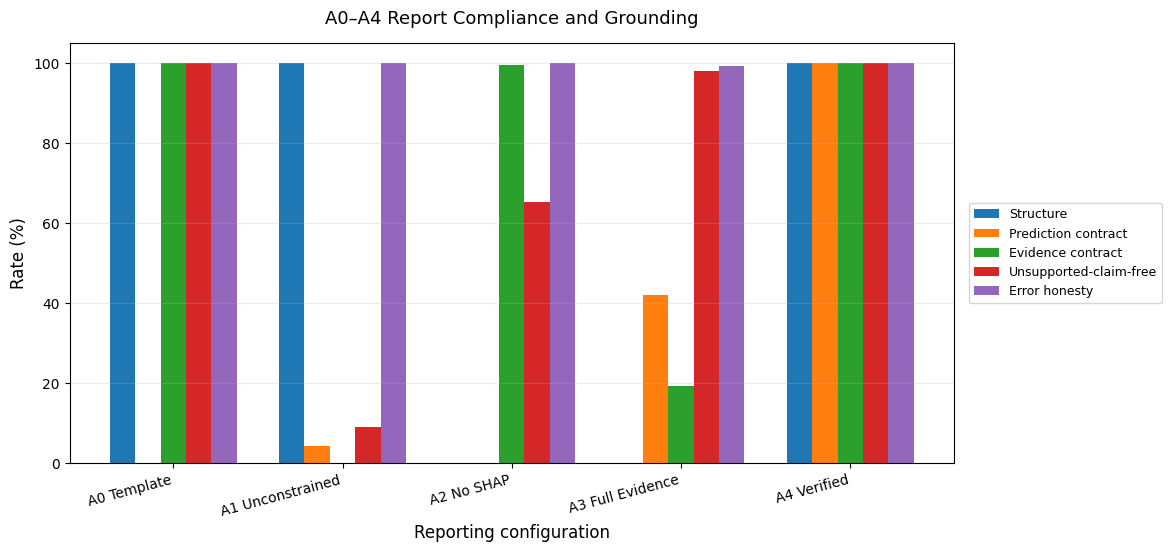

Updated figure:
/content/drive/MyDrive/UNSW_NB15_Project/results/10_manuscript_outputs/figures/Figure_A0_A4_compliance_1200dpi.png
/content/drive/MyDrive/UNSW_NB15_Project/results/10_manuscript_outputs/figures/Figure_A0_A4_compliance.pdf

Cleaned table:
/content/drive/MyDrive/UNSW_NB15_Project/results/10_manuscript_outputs/tables/Table_A4_paired_comparisons.csv

✅ Cell 50F completed. The title/legend overlap and negative-zero formatting were fixed.


In [5]:
# ============================================================
# CELL 50F — Final manuscript-output presentation fixes
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/UNSW_NB15_Project"
)

RESULTS_DIR = PROJECT_ROOT / "results"

EVALUATION_DIR = (
    RESULTS_DIR
    / "09_report_evaluation"
)

MANUSCRIPT_DIR = (
    RESULTS_DIR
    / "10_manuscript_outputs"
)

TABLE_DIR = MANUSCRIPT_DIR / "tables"
FIGURE_DIR = MANUSCRIPT_DIR / "figures"


CONFIGURATION_PATH = (
    EVALUATION_DIR
    / "A0_A4_configuration_summary_v2.csv"
)

PAIRED_TABLE_PATH = (
    TABLE_DIR
    / "Table_A4_paired_comparisons.csv"
)


CONFIGURATION_ORDER = [
    "A0_deterministic_template",
    "A1_unconstrained_full",
    "A2_constrained_no_shap",
    "A3_constrained_full",
    "A4_verified_full",
]

CONFIGURATION_LABELS = {
    "A0_deterministic_template":
        "A0 Template",
    "A1_unconstrained_full":
        "A1 Unconstrained",
    "A2_constrained_no_shap":
        "A2 No SHAP",
    "A3_constrained_full":
        "A3 Full Evidence",
    "A4_verified_full":
        "A4 Verified",
}


# ------------------------------------------------------------
# 1. Reload configuration results
# ------------------------------------------------------------

configuration = pd.read_csv(
    CONFIGURATION_PATH
)

configuration["configuration_label"] = (
    configuration[
        "configuration_id"
    ].map(CONFIGURATION_LABELS)
)

configuration["configuration_id"] = (
    pd.Categorical(
        configuration["configuration_id"],
        categories=CONFIGURATION_ORDER,
        ordered=True
    )
)

configuration = configuration.sort_values(
    "configuration_id"
).reset_index(drop=True)

configuration[
    "unsupported_claim_free_rate"
] = (
    1.0
    -
    configuration[
        "automatic_unsupported_claim_rate"
    ]
)


# ------------------------------------------------------------
# 2. Recreate only the compliance figure
# ------------------------------------------------------------

plot_metrics = {
    "Structure":
        "strict_structure_pass_rate",
    "Prediction contract":
        "prediction_contract_pass_rate",
    "Evidence contract":
        "evidence_contract_pass_rate",
    "Unsupported-claim-free":
        "unsupported_claim_free_rate",
    "Error honesty":
        "misclassification_honesty_rate",
}

x_positions = np.arange(
    len(configuration)
)

bar_width = 0.15

figure, axis = plt.subplots(
    figsize=(13.5, 6)
)

for metric_index, (
    metric_label,
    metric_column,
) in enumerate(
    plot_metrics.items()
):
    offset = (
        metric_index
        - (len(plot_metrics) - 1) / 2
    ) * bar_width

    axis.bar(
        x_positions + offset,
        configuration[
            metric_column
        ].to_numpy(dtype=float) * 100,
        width=bar_width,
        label=metric_label
    )


axis.set_title(
    "A0–A4 Report Compliance and Grounding",
    pad=14
)

axis.set_ylabel(
    "Rate (%)"
)

axis.set_xlabel(
    "Reporting configuration"
)

axis.set_xticks(
    x_positions
)

axis.set_xticklabels(
    configuration[
        "configuration_label"
    ],
    rotation=15,
    ha="right"
)

axis.set_ylim(
    0,
    105
)

axis.grid(
    axis="y",
    alpha=0.25
)

# Place legend outside the plotting area
axis.legend(
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True
)

figure.subplots_adjust(
    right=0.78,
    bottom=0.20,
    top=0.90
)


PNG_PATH = (
    FIGURE_DIR
    / "Figure_A0_A4_compliance_1200dpi.png"
)

PDF_PATH = (
    FIGURE_DIR
    / "Figure_A0_A4_compliance.pdf"
)

figure.savefig(
    PNG_PATH,
    dpi=1200,
    bbox_inches="tight"
)

figure.savefig(
    PDF_PATH,
    bbox_inches="tight"
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 3. Remove cosmetic negative zeros from paired table
# ------------------------------------------------------------

paired_table = pd.read_csv(
    PAIRED_TABLE_PATH,
    dtype=str
)

for column in paired_table.columns:
    paired_table[column] = (
        paired_table[column]
        .str.replace(
            "-0.0",
            "0.0",
            regex=False
        )
    )

paired_table.to_csv(
    PAIRED_TABLE_PATH,
    index=False
)


print("Updated figure:")
print(PNG_PATH)
print(PDF_PATH)

print("\nCleaned table:")
print(PAIRED_TABLE_PATH)

print(
    "\n✅ Cell 50F completed. "
    "The title/legend overlap and negative-zero formatting were fixed."
)